# Traffic-Related Air Pollution Exposure in London

### Integrating Air Quality, Traffic, Meteorological and Spatial Data for Statistical Analysis and Machine Learning

**Study Area:** London, United Kingdom  
**Primary Pollutants:** PM2.5 and NO₂  
**Domain:** Environmental Data Science / Urban Air Quality  
**Methods:** Statistical Analysis, Regression, Machine Learning and Spatial Analysis

## 1.1 Research Problem

Traffic is an important contributor to urban air pollution, particularly NO₂ and particulate matter. However, pollutant concentrations also vary with location, weather and time.

This project investigates the relationship between traffic-related factors and measured PM2.5 and NO₂ concentrations in London, and evaluates whether traffic, spatial, meteorological and temporal variables can be used to predict pollutant concentrations.

## 1.2 Research Questions

1. Is traffic intensity associated with NO₂ concentration?
2. Is traffic intensity associated with PM2.5 concentration?
3. Is proximity to roads associated with pollutant concentration?
4. Do these relationships remain after accounting for meteorological and temporal factors?
5. Do pollutant concentrations differ across traffic-exposure groups?
6. Can traffic, spatial, meteorological and temporal variables predict NO₂?
7. Can the same variables predict PM2.5?
8. Which variables contribute most to model predictions?

## 1.3 Hypotheses

### H1: Traffic and NO₂
- **H₀:** Traffic intensity is not significantly associated with NO₂.
- **H₁:** Traffic intensity is significantly associated with NO₂.

### H2: Traffic and PM2.5
- **H₀:** Traffic intensity is not significantly associated with PM2.5.
- **H₁:** Traffic intensity is significantly associated with PM2.5.

### H3: Road Proximity
- **H₀:** Road proximity is not significantly associated with pollutant concentration.
- **H₁:** Road proximity is significantly associated with pollutant concentration.

### H4: Exposure Groups
- **H₀:** Pollutant concentrations do not differ significantly across exposure groups.
- **H₁:** Pollutant concentrations differ significantly across exposure groups.

## 1.4 Objectives

### General Objective

To investigate and model the relationship between traffic-related factors and urban PM2.5 and NO₂ concentrations using integrated environmental, traffic, spatial and temporal data.

### Specific Objectives

1. Assess the quality and structure of the available datasets.
2. Clean and integrate the air-quality and traffic data.
3. Explore pollutant distributions and relationships.
4. Test relevant statistical hypotheses.
5. Engineer and select meaningful predictive features.
6. Develop and compare regression and machine learning models.
7. Evaluate and interpret model performance.
8. Identify key findings, limitations and implications.

## 1.5 Research Design

This is an observational quantitative study combining measured air-quality observations with traffic, spatial, meteorological and temporal information.

Statistical methods will be used to investigate associations, while machine learning methods will be used to evaluate predictive performance.

Observed relationships will not be interpreted as proof of causation.

## 1.6 Analytical Workflow

**Data Acquisition → Data Understanding → Data Quality Assessment → Data Cleaning → Data Integration → EDA → Statistical Testing → Feature Engineering → Feature Selection → Preprocessing → Modelling → Evaluation → Interpretation → Conclusion**

## 1.7 Data Sources

The project uses publicly available London environmental datasets:

- **Breathe London AQMesh Pods:** air-quality and environmental observations.
- **London Atmospheric Emissions Inventory (LAEI) 2022:** traffic flow and speed data.

The exact variables, temporal coverage and spatial structure will be established during data inspection before integration.

# Chapter 2: Data Sources & Acquisition

## 2.1 Available Datasets

The project uses four local files obtained from the selected London datasets:

- `meta_data.csv`
- `stationary_data.csv`
- `LAEI2022-major-roads-flows-and-speeds.xlsx`
- `LAEI2022-minor-roads-flows-and-speeds.xlsx`

## 2.2 Why are we doing this?

Before analysing the data, we need to verify the files available to the project and their basic properties.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving LAEI2022-major-roads-flows-and-speeds.xlsx to LAEI2022-major-roads-flows-and-speeds.xlsx
Saving LAEI2022-minor-roads-flows-and-speeds.xlsx to LAEI2022-minor-roads-flows-and-speeds.xlsx
Saving meta_data.csv to meta_data.csv
Saving stationary_data.csv to stationary_data.csv


In [2]:
from pathlib import Path

data_dir = Path("/content")

print("Uploaded files:\n")

for file in sorted(data_dir.iterdir()):
    if file.is_file():
        print(f"{file.name:<60} {file.stat().st_size / (1024**2):.2f} MB")

Uploaded files:

LAEI2022-major-roads-flows-and-speeds.xlsx                   6.46 MB
LAEI2022-minor-roads-flows-and-speeds.xlsx                   0.59 MB
meta_data.csv                                                0.03 MB
stationary_data.csv                                          62.43 MB


## 2.3 Initial Data Structure Inspection

We need to establish the actual structure, columns and data types of the air-quality and metadata datasets before deciding how they can be integrated with the traffic data.

In [3]:
import pandas as pd

meta_data = pd.read_csv("/content/meta_data.csv")
stationary_data = pd.read_csv("/content/stationary_data.csv")

print("META DATA")
print("=" * 50)
print("Shape:", meta_data.shape)
print("\nColumns:")
print(meta_data.columns.tolist())

print("\n" + "=" * 50)
print("STATIONARY DATA")
print("=" * 50)
print("Shape:", stationary_data.shape)
print("\nColumns:")
print(stationary_data.columns.tolist())

META DATA
Shape: (181, 16)

Columns:
['pod_id_location', 'start_date_utc', 'end_date_utc', 'relocate_date_utc', 'scaling_method', 'location_name', 'borough', 'type', 'ulez', 'latitude', 'longitude', 'x_coord', 'y_coord', 'distance_from_road', 'height', 'pollutant']

STATIONARY DATA
Shape: (757357, 10)

Columns:
['pod_id_location', 'pod_id', 'location_name', 'latitude', 'longitude', 'date_utc', 'pm2_5_ugm3', 'ratification_status_pm2_5', 'no2_ugm3', 'ratification_status_no2']


/tmp/ipykernel_754/3520498500.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stationary_data = pd.read_csv("/content/stationary_data.csv")


## 2.4 Traffic Dataset Structure

### Why are we doing this?

The LAEI traffic data are stored in Excel workbooks. We need to identify their sheets, dimensions and column structure before determining how traffic information can be connected to the air-quality observations.

In [4]:
from pathlib import Path
import pandas as pd

traffic_files = [
    "/content/LAEI2022-major-roads-flows-and-speeds.xlsx",
    "/content/LAEI2022-minor-roads-flows-and-speeds.xlsx"
]

for file in traffic_files:
    print("\n" + "=" * 80)
    print(Path(file).name)
    print("=" * 80)

    excel_file = pd.ExcelFile(file)

    print("\nSheets:")
    print(excel_file.sheet_names)

    for sheet in excel_file.sheet_names:
        preview = pd.read_excel(file, sheet_name=sheet, nrows=5)

        print(f"\nSheet: {sheet}")
        print("Shape of preview:", preview.shape)
        print("Columns:")
        print(preview.columns.tolist())


LAEI2022-major-roads-flows-and-speeds.xlsx

Sheets:
['LAEI2022-major-roads']

Sheet: LAEI2022-major-roads
Shape of preview: (5, 18)
Columns:
['year', 'TOID', 'laei.zone', 'borough', 'length.m', 'road.classification', 'speed.other.vehicles.kph', 'speed.buses.kph', 'AADF.motorcycles', 'AADF.taxis', 'AADF.cars', 'AADF.phvs', 'AADF.lgvs', 'AADF.hgvs.rigid', 'AADF.hgvs.articulated', 'AADF.tfl.buses', 'AADF.non.tfl.buses', 'AADF.coaches']

LAEI2022-minor-roads-flows-and-speeds.xlsx

Sheets:
['LAEI2022-minor-roads']

Sheet: LAEI2022-minor-roads
Shape of preview: (5, 20)
Columns:
['grid.id.unique', 'year', 'grid.id.1km2', 'easting', 'northing', 'area.km2', 'area.m2', 'laei.zone', 'borough', 'speed.kph', 'vkm.motorcycles', 'vkm.taxis', 'vkm.cars', 'vkm.phvs', 'vkm.lgvs', 'vkm.hgvs.rigid', 'vkm.hgvs.articulated', 'vkm.tfl.buses', 'vkm.non.tfl.buses', 'vkm.coaches']


## 2.5 Sample Records

### Why are we doing this?

Column names tell us the schema, but sample records reveal how identifiers, dates, coordinates and measurements are actually represented.

In [5]:
print("META DATA")
display(meta_data.head())

print("\nSTATIONARY DATA")
display(stationary_data.head())

print("\nMAJOR ROADS")
major_roads = pd.read_excel(
    "/content/LAEI2022-major-roads-flows-and-speeds.xlsx",
    sheet_name="LAEI2022-major-roads"
)
display(major_roads.head())

print("\nMINOR ROADS")
minor_roads = pd.read_excel(
    "/content/LAEI2022-minor-roads-flows-and-speeds.xlsx",
    sheet_name="LAEI2022-minor-roads"
)
display(minor_roads.head())

META DATA


,pod_id_location,start_date_utc,end_date_utc,relocate_date_utc,scaling_method,location_name,borough,type,ulez,latitude,longitude,x_coord,y_coord,distance_from_road,height,pollutant
0,1245,2019-02-15 16:45:00,2019-11-17 23:59:00,NaN,Gold Pod Colocation,Dollis Road,Barnet,Kerbside,No,51.604486,-0.206551,524299.922920,191038.626708,1.2,3.100,no2
1,2245,2019-05-05 01:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Great Ormond St Hospital,Camden,Roadside,Yes,51.521880,-0.120434,530499.426140,182002.318099,2.5,2.800,no2
2,3245,2018-10-04 18:00:00,2019-11-17 23:59:00,NaN,Gold Pod Colocation,Savernake Road,Camden,Urban Background,No,51.555485,-0.152338,528191.724024,185682.958666,5.0,2.297,no2
3,5245,2018-11-26 10:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Garrett Lane,Wandsworth,Kerbside,No,51.440399,-0.186775,526117.994405,172825.445928,1.0,3.445,no2
4,6245,2019-01-11 14:45:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Hanworth Road,Hounslow,Kerbside,No,51.468625,-0.359770,514028.370572,175680.724203,1.2,3.200,no2



STATIONARY DATA


,pod_id_location,pod_id,location_name,latitude,longitude,date_utc,pm2_5_ugm3,ratification_status_pm2_5,no2_ugm3,ratification_status_no2
0,1245,1245,Dollis Road,51.604486,-0.206551,2019-02-15 13:00:00,NaN,P,NaN,NaN
1,1245,1245,Dollis Road,51.604486,-0.206551,2019-02-15 14:00:00,19.46,P,NaN,NaN
2,1245,1245,Dollis Road,51.604486,-0.206551,2019-02-15 15:00:00,20.91,P,NaN,NaN
3,1245,1245,Dollis Road,51.604486,-0.206551,2019-02-15 16:00:00,36.42,P,NaN,NaN
4,1245,1245,Dollis Road,51.604486,-0.206551,2019-02-15 17:00:00,22.59,P,105.38,P



MAJOR ROADS


,year,TOID,laei.zone,borough,length.m,road.classification,speed.other.vehicles.kph,speed.buses.kph,AADF.motorcycles,AADF.taxis,AADF.cars,AADF.phvs,AADF.lgvs,AADF.hgvs.rigid,AADF.hgvs.articulated,AADF.tfl.buses,AADF.non.tfl.buses,AADF.coaches
0,2022,osgb4000000027947700,Non-GLA,Non-GLA,56.0,A Road,97.2,NaN,99,14,9409,253,1019,340,427,0,7,9
1,2022,osgb4000000027908760,Non-GLA,Non-GLA,117.7,A Road,48.6,NaN,49,10,4621,215,811,73,91,0,11,14
2,2022,osgb4000000027987795,Non-GLA,Non-GLA,32.8,A Road,19.4,NaN,95,14,9136,167,2281,134,169,0,163,216
3,2022,osgb4000000027869099,Non-GLA,Non-GLA,739.1,A Road,35.5,NaN,146,13,13905,445,3021,291,366,0,96,128
4,2022,osgb4000000030443012,Non-GLA,Non-GLA,6.6,A Road,92.9,NaN,151,26,14199,588,1875,294,369,0,61,80



MINOR ROADS


,grid.id.unique,year,grid.id.1km2,easting,northing,area.km2,area.m2,laei.zone,borough,speed.kph,vkm.motorcycles,vkm.taxis,vkm.cars,vkm.phvs,vkm.lgvs,vkm.hgvs.rigid,vkm.hgvs.articulated,vkm.tfl.buses,vkm.non.tfl.buses,vkm.coaches
0,1,2022,5910,510500,203500,1.0,996667.068177,Non-GLA,Non-GLA,30,10092.661359,2266.192584,617461.684176,20798.083603,148353.888818,20659.178851,20642.343961,1029.259147,1778.541912,2357.602052
1,2,2022,5911,511500,203500,1.0,996661.783535,Non-GLA,Non-GLA,30,7326.195717,1645.014116,448211.327530,15097.190483,107689.100644,14996.360447,14984.140113,747.132365,1291.031738,1711.367641
2,3,2022,5912,512500,203500,1.0,996648.078502,Non-GLA,Non-GLA,30,14248.589789,3199.359155,871718.364021,29362.261461,209442.646516,29166.158891,29142.391777,1453.084657,2510.905025,3328.408963
3,4,2022,5915,515500,203500,1.0,996639.761195,Non-GLA,Non-GLA,30,12317.227046,2765.693566,753558.995537,25382.276165,181053.189706,25212.754835,25192.209297,1256.122459,2170.557770,2877.250978
4,5,2022,5916,516500,203500,1.0,996625.862296,Non-GLA,Non-GLA,30,10018.038667,2249.436905,612896.322151,20644.307614,147256.996123,20506.429890,20489.719473,1021.649054,1765.391804,2340.170514


# Chapter 3: Data Understanding

## 3.1 Temporal Coverage of Air-Quality Data

The traffic inventory represents 2022 conditions, so we first need to establish the actual time period covered by the air-quality observations before deciding how the datasets can be combined.

## 3.2 Date-Time Conversion

Temporal analysis requires `date_utc` to be stored as a true datetime field. Converting it now allows reliable extraction of year, month, hour and day-of-week later.

In [ ]:
stationary_data["date_utc"] = pd.to_datetime(
    stationary_data["date_utc"],
    errors="coerce"
)

print("Data type:", stationary_data["date_utc"].dtype)
print("Missing dates:", stationary_data["date_utc"].isna().sum())

print("\nObservation period:")
print("Start:", stationary_data["date_utc"].min())
print("End:  ", stationary_data["date_utc"].max())

print("\nObservations by year:")
print(
    stationary_data["date_utc"]
    .dt.year
    .value_counts()
    .sort_index()
)

## 3.3 Monitoring-Site Coverage

The observations come from multiple monitoring pods. We need to understand how many sites are represented and how observations are distributed across them.

In [ ]:
print("Unique monitoring locations:", stationary_data["pod_id_location"].nunique())
print("Unique pod IDs:", stationary_data["pod_id"].nunique())

print("\nObservations per monitoring location:")
site_counts = (
    stationary_data["pod_id_location"]
    .value_counts()
)

print(site_counts.describe())

print("\nTop 10 locations by observation count:")
display(site_counts.head(10))

## 3.4 Pollutant Coverage

The project has two primary outcomes, PM2.5 and NO₂. We need to quantify their availability and missingness before analysis.

In [ ]:
pollutants = ["pm2_5_ugm3", "no2_ugm3"]

print("Pollutant coverage")
print("=" * 60)

for col in pollutants:
    total = len(stationary_data)
    missing = stationary_data[col].isna().sum()
    available = total - missing

    print(f"\n{col}")
    print(f"Available: {available:,} ({available / total:.2%})")
    print(f"Missing:   {missing:,} ({missing / total:.2%})")

print("\nBoth pollutants available:")
both_available = stationary_data[pollutants].notna().all(axis=1)
print(
    f"{both_available.sum():,} "
    f"({both_available.mean():.2%})"
)

## 3.5 Missingness Across Monitoring Locations

Overall missingness can hide important site-level patterns. We need to determine whether missing pollutant measurements are concentrated at particular monitoring locations.

In [ ]:
missing_by_site = (
    stationary_data
    .groupby("pod_id_location")[["pm2_5_ugm3", "no2_ugm3"]]
    .agg(
        total=("pm2_5_ugm3", "size"),
        pm2_5_missing=("pm2_5_ugm3", lambda x: x.isna().sum()),
        no2_missing=("no2_ugm3", lambda x: x.isna().sum())
    )
)

missing_by_site["pm2_5_missing_pct"] = (
    missing_by_site["pm2_5_missing"]
    / missing_by_site["total"]
    * 100
)

missing_by_site["no2_missing_pct"] = (
    missing_by_site["no2_missing"]
    / missing_by_site["total"]
    * 100
)

print("PM2.5 missingness by site")
display(
    missing_by_site["pm2_5_missing_pct"]
    .describe()
)

print("\nNO₂ missingness by site")
display(
    missing_by_site["no2_missing_pct"]
    .describe()
)

print("\nSites with highest PM2.5 missingness:")
display(
    missing_by_site
    .sort_values("pm2_5_missing_pct", ascending=False)
    .head(10)
)

print("\nSites with highest NO₂ missingness:")
display(
    missing_by_site
    .sort_values("no2_missing_pct", ascending=False)
    .head(10)
)

## 3.6 Duplicate Observations


Each monitoring location should have at most one observation for a given timestamp. Duplicate site-time records could bias summary statistics and modelling.

In [ ]:
duplicate_keys = [
    "pod_id_location",
    "date_utc"
]

duplicate_rows = stationary_data.duplicated(
    subset=duplicate_keys,
    keep=False
)

print("Duplicate site-time rows:", duplicate_rows.sum())
print("Unique duplicated site-time combinations:",
      stationary_data.loc[duplicate_rows, duplicate_keys]
      .drop_duplicates()
      .shape[0])

if duplicate_rows.sum() > 0:
    print("\nExample duplicated records:")
    display(
        stationary_data.loc[duplicate_rows]
        .sort_values(duplicate_keys)
        .head(20)
    )

Duplicate site-time rows: 0
Unique duplicated site-time combinations: 0


## 3.7 Data Types and Descriptive Statistics

We need to identify incorrect data types and inspect the numerical ranges of the pollutant, spatial and environmental variables before cleaning.

In [7]:
print("META DATA TYPES")
print("=" * 60)
print(meta_data.dtypes)

print("\nSTATIONARY DATA TYPES")
print("=" * 60)
print(stationary_data.dtypes)

print("\nSTATIONARY DATA SUMMARY")
print("=" * 60)
display(stationary_data.describe(include="all").T)

META DATA TYPES
pod_id_location         int64
start_date_utc         object
end_date_utc           object
relocate_date_utc      object
scaling_method         object
location_name          object
borough                object
type                   object
ulez                   object
latitude              float64
longitude             float64
x_coord               float64
y_coord               float64
distance_from_road    float64
height                float64
pollutant              object
dtype: object

STATIONARY DATA TYPES
pod_id_location                int64
pod_id                         int64
location_name                 object
latitude                     float64
longitude                    float64
date_utc                      object
pm2_5_ugm3                   float64
ratification_status_pm2_5     object
no2_ugm3                     float64
ratification_status_no2       object
dtype: object

STATIONARY DATA SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pod_id_location,757357.0,NaN,NaN,NaN,70487.957298,119047.675319,1245.0,28245.0,50245.0,72245.0,982450.0
pod_id,757357.0,NaN,NaN,NaN,48560.017885,26847.003542,1245.0,27245.0,48245.0,70245.0,100245.0
location_name,757357,102,Richmond Road,11338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,757357.0,NaN,NaN,NaN,51.513584,0.049381,51.362842,51.481858,51.514071,51.5456,51.673753
longitude,757357.0,NaN,NaN,NaN,-0.120694,0.114875,-0.41358,-0.19241,-0.114098,-0.061823,0.21182
date_utc,757357,10166,2019-10-24 13:00:00,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm2_5_ugm3,570083.0,NaN,NaN,NaN,11.925288,12.123097,0.14,5.47,7.74,13.06,332.9
ratification_status_pm2_5,591887,1,P,591887,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no2_ugm3,655262.0,NaN,NaN,NaN,39.451623,21.765223,1.12,25.03,33.42,47.97,583.94
ratification_status_no2,681856,1,P,681856,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3.8 Inspection of Extreme Pollutant Values

Extreme measurements can strongly influence statistical models. Before treating them as outliers, we need to determine whether they are associated with specific locations, times or ratification statuses.

In [8]:
print("Highest PM2.5 observations")
print("=" * 70)

display(
    stationary_data[
        [
            "pod_id_location",
            "location_name",
            "date_utc",
            "pm2_5_ugm3",
            "ratification_status_pm2_5",
            "no2_ugm3",
            "ratification_status_no2"
        ]
    ]
    .nlargest(10, "pm2_5_ugm3")
)

print("\nHighest NO₂ observations")
print("=" * 70)

display(
    stationary_data[
        [
            "pod_id_location",
            "location_name",
            "date_utc",
            "pm2_5_ugm3",
            "ratification_status_pm2_5",
            "no2_ugm3",
            "ratification_status_no2"
        ]
    ]
    .nlargest(10, "no2_ugm3")
)

Highest PM2.5 observations


,pod_id_location,location_name,date_utc,pm2_5_ugm3,ratification_status_pm2_5,no2_ugm3,ratification_status_no2
35385,6245,Hanworth Road,2019-10-27 23:00:00,332.90,P,61.76,P
546158,77245,Cornwall Road,2019-06-15 08:00:00,303.01,P,29.05,P
546157,77245,Cornwall Road,2019-06-15 07:00:00,300.90,P,28.09,P
135341,22245,Blackfriars Road,2019-02-02 12:00:00,294.96,P,NaN,P
546143,77245,Cornwall Road,2019-06-14 17:00:00,288.83,P,22.79,P
546134,77245,Cornwall Road,2019-06-14 08:00:00,280.68,P,27.36,P
153314,26245,Larkshall Road,2019-04-18 04:00:00,258.94,P,NaN,NaN
546146,77245,Cornwall Road,2019-06-14 20:00:00,258.60,P,22.05,P
593583,86245,Commercial Street,2019-09-22 01:00:00,251.47,P,85.88,P
546156,77245,Cornwall Road,2019-06-15 06:00:00,243.78,P,26.33,P



Highest NO₂ observations


,pod_id_location,location_name,date_utc,pm2_5_ugm3,ratification_status_pm2_5,no2_ugm3,ratification_status_no2
100709,18245,London Road,2019-06-16 19:00:00,4.85,P,583.94,P
373446,54245,Holloway Bus Garage,2019-02-08 07:00:00,8.50,P,470.17,P
373966,54245,Holloway Bus Garage,2019-03-01 23:00:00,16.26,P,468.41,P
371719,54245,Holloway Bus Garage,2018-11-28 08:00:00,7.96,P,440.69,P
376841,54245,Holloway Bus Garage,2019-06-29 18:00:00,9.97,P,414.08,P
100710,18245,London Road,2019-06-16 20:00:00,4.75,P,411.02,P
374214,54245,Holloway Bus Garage,2019-03-12 07:00:00,7.25,P,410.54,P
374071,54245,Holloway Bus Garage,2019-03-06 08:00:00,11.26,P,388.62,P
374061,54245,Holloway Bus Garage,2019-03-05 22:00:00,14.65,P,386.30,P
374070,54245,Holloway Bus Garage,2019-03-06 07:00:00,11.23,P,381.64,P


## 3.9 Ratification Status

The dataset provides ratification-status fields for both pollutants. We need to understand their categories and missingness before deciding whether they should be used as quality-control variables.

In [9]:
for col in [
    "ratification_status_pm2_5",
    "ratification_status_no2"
]:
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)

    print("Value counts:")
    print(stationary_data[col].value_counts(dropna=False))

    print("\nUnique values:")
    print(stationary_data[col].unique())


ratification_status_pm2_5
Value counts:
ratification_status_pm2_5
P      591887
NaN    165470
Name: count, dtype: int64

Unique values:
['P' nan]

ratification_status_no2
Value counts:
ratification_status_no2
P      681856
NaN     75501
Name: count, dtype: int64

Unique values:
[nan 'P']


## 3.10 Site Metadata Linkage

The monitoring observations need to be linked to their corresponding site characteristics. We need to verify that every observation location has a matching metadata record.

In [10]:
stationary_sites = set(stationary_data["pod_id_location"].unique())
metadata_sites = set(meta_data["pod_id_location"].unique())

matched_sites = stationary_sites.intersection(metadata_sites)
missing_metadata_sites = stationary_sites - metadata_sites

print("Unique sites in stationary data:", len(stationary_sites))
print("Unique sites in metadata:", len(metadata_sites))
print("Matched sites:", len(matched_sites))
print("Stationary sites without metadata:", len(missing_metadata_sites))

if missing_metadata_sites:
    print("\nSites without metadata:")
    print(sorted(missing_metadata_sites))

Unique sites in stationary data: 106
Unique sites in metadata: 106
Matched sites: 106
Stationary sites without metadata: 0


## 3.11 Pod and Location Structure

A monitoring pod can potentially be relocated between sites. We need to understand the relationship between physical pod IDs and location IDs so that observations are not incorrectly treated as independent permanent sites.

In [11]:
pod_location_counts = (
    stationary_data
    .groupby("pod_id")["pod_id_location"]
    .nunique()
    .sort_values(ascending=False)
)

print("Pod IDs linked to multiple locations:")
display(
    pod_location_counts[pod_location_counts > 1]
)

print("\nNumber of pod IDs linked to exactly one location:",
      (pod_location_counts == 1).sum())

print("Number of pod IDs linked to multiple locations:",
      (pod_location_counts > 1).sum())

Pod IDs linked to multiple locations:


,pod_id_location
pod_id,
74245,3
33245,3
5245,2
17245,2
55245,2
65245,2
72245,2
83245,2
39245,2



Number of pod IDs linked to exactly one location: 80
Number of pod IDs linked to multiple locations: 12


## 3.12 Pod Relocations

Some physical pods are linked to multiple locations. We need to identify their location changes and confirm the corresponding dates before treating each location as a separate monitoring site.

In [12]:
# Identify pods that were used at multiple locations
multi_location_pods = (
    pod_location_counts[pod_location_counts > 1]
    .index
)

relocation_check = (
    meta_data[
        meta_data["pod_id_location"].isin(
            stationary_data.loc[
                stationary_data["pod_id"].isin(multi_location_pods),
                "pod_id_location"
            ].unique()
        )
    ][
        [
            "pod_id_location",
            "start_date_utc",
            "end_date_utc",
            "relocate_date_utc",
            "location_name",
            "borough",
            "latitude",
            "longitude",
            "distance_from_road"
        ]
    ]
    .sort_values(["start_date_utc", "pod_id_location"])
)

display(relocation_check)

,pod_id_location,start_date_utc,end_date_utc,relocate_date_utc,location_name,borough,latitude,longitude,distance_from_road
100,982450,2018-09-20 11:00:00,2019-01-08 01:00:00,2019-01-08 01:00:00,King William Walk,Greenwich,51.481858,-0.008609,1.500
47,52450,2018-10-09 19:00:00,2018-11-26 01:00:00,2018-11-26 01:00:00,Steerforth Street,Wandsworth,51.438489,-0.187703,2.656
179,332450,2018-10-16 17:00:00,2019-07-24 02:00:00,2019-07-24 02:00:00,Churchill Gardens Road,Westminster,51.486223,-0.145030,10.500
93,552450,2018-10-17 14:00:00,2018-12-17 01:00:00,2018-12-17 01:00:00,Wetland Centre,Richmond,51.476168,-0.230427,NaN
96,742450,2018-10-23 11:00:00,2019-08-12 02:00:00,2019-08-12 02:00:00,Greenhill Way,Harrow,51.580920,-0.341502,0.300
91,392450,2018-10-24 11:00:00,2019-03-08 01:00:00,2019-03-08 01:00:00,Glaisher Street,Greenwich,51.483100,-0.018800,1.500
92,422450,2018-10-24 13:00:00,2019-02-06 01:00:00,2019-02-06 01:00:00,Parkside,Merton,51.426126,-0.222013,1.260
99,892450,2018-10-25 13:00:00,2019-01-03 01:00:00,2019-01-03 01:00:00,Woolwich Manor Way,Barking & Dagenham,51.515901,0.060587,0.100
95,722450,2018-11-02 00:00:00,2019-02-13 01:00:00,2019-02-13 01:00:00,Fitzjohn Avenue,Camden,51.551247,-0.175939,1.100
3,5245,2018-11-26 10:00:00,2019-11-17 23:59:00,NaN,Garrett Lane,Wandsworth,51.440399,-0.186775,1.000


## 3.13 Deployment Structure

Multiple deployment records can exist at the same physical location, while individual pods can also move between locations. We need to distinguish deployment records from physical locations before spatial and temporal analysis.

In [13]:
deployment_structure = (
    meta_data
    .groupby(["location_name", "latitude", "longitude"])
    .agg(
        deployment_records=("pod_id_location", "nunique"),
        pod_ids=("pod_id_location", "count")
    )
    .sort_values("deployment_records", ascending=False)
)

print("Physical locations represented by multiple deployment records:")
display(
    deployment_structure[
        deployment_structure["deployment_records"] > 1
    ]
)

print("\nTotal unique physical locations:")
print(deployment_structure.shape[0])

print("\nTotal deployment records:")
print(meta_data["pod_id_location"].nunique())

Physical locations represented by multiple deployment records:


,,,deployment_records,pod_ids
location_name,latitude,longitude,,
Holloway Road,51.555387,-0.116092,3,4
Parkside,51.426126,-0.222013,2,2



Total unique physical locations:
103

Total deployment records:
106


## 3.14 Monitoring Site Characteristics

Monitoring conditions can influence pollutant concentrations. We therefore need to understand site type, ULEZ status, distance from road, monitoring height and borough coverage before modelling.

In [14]:
print("Monitoring site characteristics")
print("=" * 70)

print("\nMonitoring type:")
print(meta_data["type"].value_counts(dropna=False))

print("\nULEZ status:")
print(meta_data["ulez"].value_counts(dropna=False))

print("\nBoroughs:")
print("Unique boroughs:", meta_data["borough"].nunique())
display(meta_data["borough"].value_counts().head(20))

print("\nDistance from road (m):")
display(meta_data["distance_from_road"].describe())

print("\nMonitoring height (m):")
display(meta_data["height"].describe())

Monitoring site characteristics

Monitoring type:
type
Roadside             62
Urban Background     59
Kerbside             53
Urban Background      7
Name: count, dtype: int64

ULEZ status:
ulez
No     139
Yes     42
Name: count, dtype: int64

Boroughs:
Unique boroughs: 32


,count
borough,
Islington,17
Southwark,16
Tower Hamlets,13
Westminster,12
Lambeth,12
Camden,11
Kensington & Chelsea,10
Wandsworth,9
Greenwich,7



Distance from road (m):


,distance_from_road
count,170.000000
mean,4.050918
std,5.906308
min,0.000000
25%,1.000000
50%,1.700000
75%,5.000000
max,36.700000



Monitoring height (m):


,height
count,181.000000
mean,3.456331
std,2.533555
min,1.500000
25%,2.767000
50%,3.012000
75%,3.250000
max,20.000000


## 3.15 Metadata Record Structure

The metadata contains more records than the 106 deployment locations observed in the monitoring data. We need to determine whether records differ by pollutant, deployment or another metadata attribute before cleaning and integration.

In [15]:
print("Metadata record structure")
print("=" * 70)

print("\nRecords by pollutant:")
print(meta_data["pollutant"].value_counts(dropna=False))

print("\nRecords by deployment location:")
deployment_counts = meta_data["pod_id_location"].value_counts()

print(deployment_counts.value_counts().sort_index())

print("\nExample locations with multiple metadata records:")
display(
    meta_data[
        meta_data["pod_id_location"].isin(
            deployment_counts[deployment_counts > 1].index
        )
    ]
    .sort_values("pod_id_location")
    .head(30)
)

Metadata record structure

Records by pollutant:
pollutant
no2      101
pm2_5     80
Name: count, dtype: int64

Records by deployment location:
count
1    31
2    75
Name: count, dtype: int64

Example locations with multiple metadata records:


,pod_id_location,start_date_utc,end_date_utc,relocate_date_utc,scaling_method,location_name,borough,type,ulez,latitude,longitude,x_coord,y_coord,distance_from_road,height,pollutant
0,1245,2019-02-15 16:45:00,2019-11-17 23:59:00,NaN,Gold Pod Colocation,Dollis Road,Barnet,Kerbside,No,51.604486,-0.206551,524299.922920,191038.626708,1.2,3.100,no2
101,1245,2019-02-15 12:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Dollis Road,Barnet,Kerbside,No,51.604486,-0.206551,524299.922920,191038.626708,1.2,3.100,pm2_5
102,2245,2019-05-03 10:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Great Ormond St Hospital,Camden,Roadside,Yes,51.521880,-0.120434,530499.426140,182002.318099,2.5,2.800,pm2_5
1,2245,2019-05-05 01:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Great Ormond St Hospital,Camden,Roadside,Yes,51.521880,-0.120434,530499.426140,182002.318099,2.5,2.800,no2
2,3245,2018-10-04 18:00:00,2019-11-17 23:59:00,NaN,Gold Pod Colocation,Savernake Road,Camden,Urban Background,No,51.555485,-0.152338,528191.724024,185682.958666,5.0,2.297,no2
103,3245,2018-10-04 18:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Savernake Road,Camden,Urban Background,No,51.555485,-0.152338,528191.724024,185682.958666,5.0,2.297,pm2_5
104,5245,2019-03-06 15:55:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Garrett Lane,Wandsworth,Kerbside,No,51.440399,-0.186775,526117.994405,172825.445928,1.0,3.445,pm2_5
3,5245,2018-11-26 10:00:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Garrett Lane,Wandsworth,Kerbside,No,51.440399,-0.186775,526117.994405,172825.445928,1.0,3.445,no2
4,6245,2019-01-11 14:45:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Hanworth Road,Hounslow,Kerbside,No,51.468625,-0.359770,514028.370572,175680.724203,1.2,3.200,no2
105,6245,2019-03-07 13:37:00,2019-11-17 23:59:00,NaN,Network Based Calibration,Hanworth Road,Hounslow,Kerbside,No,51.468625,-0.359770,514028.370572,175680.724203,1.2,3.200,pm2_5


## 3.16 Coordinate and Spatial Coverage

The project involves spatial analysis and traffic integration. We therefore need to verify that monitoring coordinates are complete, valid and geographically consistent.

In [16]:
print("Coordinate completeness")
print("=" * 70)

for col in ["latitude", "longitude", "x_coord", "y_coord"]:
    print(f"{col}: {meta_data[col].isna().sum()} missing")

print("\nCoordinate ranges:")
print("Latitude :", meta_data["latitude"].min(), "to", meta_data["latitude"].max())
print("Longitude:", meta_data["longitude"].min(), "to", meta_data["longitude"].max())
print("X coordinate:", meta_data["x_coord"].min(), "to", meta_data["x_coord"].max())
print("Y coordinate:", meta_data["y_coord"].min(), "to", meta_data["y_coord"].max())

print("\nUnique coordinate locations:")
print(
    meta_data[
        ["latitude", "longitude"]
    ].drop_duplicates().shape[0]
)

print("\nRecords outside expected London latitude range:")
display(
    meta_data[
        (meta_data["latitude"] < 51.2) |
        (meta_data["latitude"] > 51.8) |
        (meta_data["longitude"] < -0.6) |
        (meta_data["longitude"] > 0.4)
    ]
)

Coordinate completeness
latitude: 0 missing
longitude: 0 missing
x_coord: 0 missing
y_coord: 0 missing

Coordinate ranges:
Latitude : 51.362842 to 51.673753000000005
Longitude: -0.41358 to 0.2118199999999999
X coordinate: 510034.426057 to 553472.6491800001
Y coordinate: 164183.27534700002 to 199042.305797

Unique coordinate locations:
103

Records outside expected London latitude range:


,pod_id_location,start_date_utc,end_date_utc,relocate_date_utc,scaling_method,location_name,borough,type,ulez,latitude,longitude,x_coord,y_coord,distance_from_road,height,pollutant


## 3.17 Deployment Periods

Deployment periods determine when each monitoring location was active. Understanding these periods is necessary before combining spatial characteristics with hourly pollutant observations.

In [17]:
# Convert metadata date fields to datetime
date_columns = [
    "start_date_utc",
    "end_date_utc",
    "relocate_date_utc"
]

for col in date_columns:
    meta_data[col] = pd.to_datetime(
        meta_data[col],
        errors="coerce"
    )

print("Metadata date ranges")
print("=" * 70)

for col in date_columns:
    print(f"\n{col}")
    print("Missing:", meta_data[col].isna().sum())
    print("Start:", meta_data[col].min())
    print("End:  ", meta_data[col].max())

# Deployment duration
meta_data["deployment_duration_days"] = (
    meta_data["end_date_utc"] -
    meta_data["start_date_utc"]
).dt.total_seconds() / (24 * 60 * 60)

print("\nDeployment duration (days)")
display(
    meta_data["deployment_duration_days"].describe()
)

Metadata date ranges

start_date_utc
Missing: 0
Start: 2018-09-20 11:00:00
End:   2019-09-17 13:00:00

end_date_utc
Missing: 0
Start: 2018-11-26 01:00:00
End:   2019-11-17 23:59:00

relocate_date_utc
Missing: 163
Start: 2018-11-26 01:00:00
End:   2019-11-05 01:00:00

Deployment duration (days)


,deployment_duration_days
count,181.000000
mean,298.848730
std,105.478432
min,13.541667
25%,248.367361
50%,292.625000
75%,395.457639
max,423.457639


# Chapter 4: Data Quality Assessment

## 4.1 Quality Assessment Framework

Before cleaning or modelling, we need to identify missing, inconsistent, duplicated or invalid values and determine which issues require correction.

In [18]:
print("DATA QUALITY OVERVIEW")
print("=" * 70)

print("\nAir-quality data shape:")
print(stationary_data.shape)

print("\nMetadata shape:")
print(meta_data.shape)

print("\nMajor-road data shape:")
print(major_roads.shape)

print("\nMinor-road data shape:")
print(minor_roads.shape)

print("\nMissing values by dataset:")
print("\nStationary data:")
display(
    stationary_data.isna().sum().sort_values(ascending=False)
)

print("\nMetadata:")
display(
    meta_data.isna().sum().sort_values(ascending=False)
)

print("\nMajor roads:")
display(
    major_roads.isna().sum().sort_values(ascending=False)
)

print("\nMinor roads:")
display(
    minor_roads.isna().sum().sort_values(ascending=False)
)

DATA QUALITY OVERVIEW

Air-quality data shape:
(757357, 10)

Metadata shape:
(181, 17)

Major-road data shape:
(79437, 18)

Minor-road data shape:
(3460, 20)

Missing values by dataset:

Stationary data:


,0
pm2_5_ugm3,187274
ratification_status_pm2_5,165470
no2_ugm3,102095
ratification_status_no2,75501
pod_id,0
pod_id_location,0
date_utc,0
longitude,0
latitude,0
location_name,0



Metadata:


,0
relocate_date_utc,163
distance_from_road,11
pod_id_location,0
end_date_utc,0
start_date_utc,0
location_name,0
borough,0
type,0
scaling_method,0
ulez,0



Major roads:


,0
speed.buses.kph,27409
year,0
TOID,0
laei.zone,0
length.m,0
borough,0
road.classification,0
speed.other.vehicles.kph,0
AADF.motorcycles,0
AADF.taxis,0



Minor roads:


,0
grid.id.unique,0
year,0
grid.id.1km2,0
easting,0
northing,0
area.km2,0
area.m2,0
laei.zone,0
borough,0
speed.kph,0


## 4.2 Pollutant Missingness and Status Consistency

The air-quality dataset contains both pollutant measurements and ratification-status fields. We need to determine whether missing measurements consistently correspond to missing status information before deciding how these fields should be handled.

In [19]:
print("PM2.5 consistency")
print("=" * 70)

pm2_missing = stationary_data["pm2_5_ugm3"].isna()
pm2_status_missing = stationary_data["ratification_status_pm2_5"].isna()

print("PM2.5 missing + status missing:",
      (pm2_missing & pm2_status_missing).sum())

print("PM2.5 missing + status present:",
      (pm2_missing & ~pm2_status_missing).sum())

print("PM2.5 present + status missing:",
      (~pm2_missing & pm2_status_missing).sum())

print("PM2.5 present + status present:",
      (~pm2_missing & ~pm2_status_missing).sum())


print("\nNO₂ consistency")
print("=" * 70)

no2_missing = stationary_data["no2_ugm3"].isna()
no2_status_missing = stationary_data["ratification_status_no2"].isna()

print("NO₂ missing + status missing:",
      (no2_missing & no2_status_missing).sum())

print("NO₂ missing + status present:",
      (no2_missing & ~no2_status_missing).sum())

print("NO₂ present + status missing:",
      (~no2_missing & no2_status_missing).sum())

print("NO₂ present + status present:",
      (~no2_missing & ~no2_status_missing).sum())

PM2.5 consistency
PM2.5 missing + status missing: 165470
PM2.5 missing + status present: 21804
PM2.5 present + status missing: 0
PM2.5 present + status present: 570083

NO₂ consistency
NO₂ missing + status missing: 75501
NO₂ missing + status present: 26594
NO₂ present + status missing: 0
NO₂ present + status present: 655262


## 4.3 Categorical Consistency

Inconsistent categorical labels can create artificial groups during analysis and modelling. We will identify whitespace or formatting inconsistencies before standardizing categories.

In [20]:
categorical_columns = [
    "scaling_method",
    "location_name",
    "borough",
    "type",
    "ulez",
    "pollutant"
]

for col in categorical_columns:
    print("\n" + "=" * 70)
    print(col)
    print("=" * 70)

    print("Unique values:", meta_data[col].nunique())
    print(meta_data[col].value_counts(dropna=False))


scaling_method
Unique values: 3
scaling_method
Network Based Calibration            117
Gold Pod Colocation                   59
Initial Reference Site Colocation      5
Name: count, dtype: int64

location_name
Unique values: 102
location_name
Holloway Road        4
Dollis Road          2
Savernake Road       2
Garrett Lane         2
Hanworth Road        2
                    ..
Larkshall Road       1
Whitecross           1
Ellenborough Road    1
Columbia Road        1
Beckenham Lane       1
Name: count, Length: 102, dtype: int64

borough
Unique values: 32
borough
Islington               17
Southwark               16
Tower Hamlets           13
Westminster             12
Lambeth                 12
Camden                  11
Kensington & Chelsea    10
Wandsworth               9
Greenwich                7
Richmond                 7
Hackney                  7
Barnet                   6
City of London           6
Barking & Dagenham       5
Hounslow                 4
Enfield                

## 4.4 Numerical Validity

Missing values are only one aspect of data quality. We also need to identify impossible or suspicious numerical values before modelling.

In [21]:
numerical_checks = {
    "PM2.5 < 0": (stationary_data["pm2_5_ugm3"] < 0).sum(),
    "NO₂ < 0": (stationary_data["no2_ugm3"] < 0).sum(),
    "Latitude outside London range": (
        (stationary_data["latitude"] < 51.2) |
        (stationary_data["latitude"] > 51.8)
    ).sum(),
    "Longitude outside London range": (
        (stationary_data["longitude"] < -0.6) |
        (stationary_data["longitude"] > 0.4)
    ).sum(),
    "Metadata distance < 0": (
        meta_data["distance_from_road"] < 0
    ).sum(),
    "Metadata height <= 0": (
        meta_data["height"] <= 0
    ).sum(),
    "Major road length <= 0": (
        major_roads["length.m"] <= 0
    ).sum(),
    "Major vehicle counts < 0": (
        major_roads.filter(like="AADF").lt(0).any(axis=1)
    ).sum(),
    "Minor VKM < 0": (
        minor_roads.filter(like="vkm").lt(0).any(axis=1)
    ).sum()
}

print("Numerical validity checks")
print("=" * 70)

for check, count in numerical_checks.items():
    print(f"{check:<40} {count}")

Numerical validity checks
PM2.5 < 0                                0
NO₂ < 0                                  0
Latitude outside London range            0
Longitude outside London range           0
Metadata distance < 0                    0
Metadata height <= 0                     0
Major road length <= 0                   0
Major vehicle counts < 0                 0
Minor VKM < 0                            0


## 4.5 Temporal and Deployment Consistency

Each air-quality observation should fall within the deployment period recorded for its monitoring location. This verifies that observations are correctly associated with active monitoring deployments.




In [22]:
# Merge deployment dates onto the air-quality observations
deployment_check = stationary_data[
    ["pod_id_location", "date_utc"]
].merge(
    meta_data[
        ["pod_id_location", "start_date_utc", "end_date_utc"]
    ].drop_duplicates("pod_id_location"),
    on="pod_id_location",
    how="left"
)

# Check whether observations fall outside their recorded deployment periods
before_start = (
    deployment_check["date_utc"] < deployment_check["start_date_utc"]
).sum()

after_end = (
    deployment_check["date_utc"] > deployment_check["end_date_utc"]
).sum()

missing_deployment_dates = (
    deployment_check["start_date_utc"].isna() |
    deployment_check["end_date_utc"].isna()
).sum()

print("Temporal and deployment consistency")
print("=" * 70)
print(f"Observations before deployment start: {before_start}")
print(f"Observations after deployment end:    {after_end}")
print(f"Observations with missing deployment dates: {missing_deployment_dates}")

Temporal and deployment consistency
Observations before deployment start: 44005
Observations after deployment end:    97
Observations with missing deployment dates: 0


## 4.5A Diagnose the deployment mismatch

In [23]:
# Check whether each pod-location has consistent deployment dates
deployment_consistency = (
    meta_data
    .groupby("pod_id_location")
    .agg(
        records=("pod_id_location", "size"),
        unique_start_dates=("start_date_utc", "nunique"),
        unique_end_dates=("end_date_utc", "nunique")
    )
)

print("Deployment metadata consistency")
print("=" * 70)

print("Pod-location records with multiple start dates:",
      (deployment_consistency["unique_start_dates"] > 1).sum())

print("Pod-location records with multiple end dates:",
      (deployment_consistency["unique_end_dates"] > 1).sum())

print("\nExamples with multiple start or end dates:")
display(
    deployment_consistency[
        (deployment_consistency["unique_start_dates"] > 1) |
        (deployment_consistency["unique_end_dates"] > 1)
    ].head(20)
)

Deployment metadata consistency
Pod-location records with multiple start dates: 47
Pod-location records with multiple end dates: 0

Examples with multiple start or end dates:


,records,unique_start_dates,unique_end_dates
pod_id_location,,,
1245,2,2,1
2245,2,2,1
5245,2,2,1
6245,2,2,1
8245,2,2,1
9245,2,2,1
11245,2,2,1
16245,2,2,1
18245,2,2,1


We found the likely reason for the 44,005 apparent mismatches.

The issue is that pod_id_location can have two metadata records with different start dates, while the end date is the same. This is consistent with the metadata being recorded separately by pollutant/deployment information rather than meaning there are two physical monitoring sites.

So the previous temporal check was not valid enough to use as a data-cleaning decision because it arbitrarily selected one metadata record per pod_id_location.

We need to resolve this properly.

## 4.5B Inspect the metadata behind one affected location

Let's look at the actual records for one of the affected locations, 1245.

In [24]:
display(
    meta_data[
        meta_data["pod_id_location"] == 1245
    ][
        [
            "pod_id_location",
            "location_name",
            "pollutant",
            "start_date_utc",
            "end_date_utc",
            "relocate_date_utc"
        ]
    ].sort_values(["start_date_utc", "pollutant"])
)

,pod_id_location,location_name,pollutant,start_date_utc,end_date_utc,relocate_date_utc
101,1245,Dollis Road,pm2_5,2019-02-15 12:00:00,2019-11-17 23:59:00,NaT
0,1245,Dollis Road,no2,2019-02-15 16:45:00,2019-11-17 23:59:00,NaT


For 1245, both records refer to the same location and same deployment period, but the pollutant-specific start_date_utc differs by only 4 hours 45 minutes:

PM2.5: 12:00
NO₂: 16:45
Same end date

That means we cannot use one arbitrary metadata start date for the entire pod_id_location. The temporal validation needs to be pollutant-aware.

More importantly, we should match:

pm2_5_ugm3 → metadata where pollutant == "pm2_5"
no2_ugm3 → metadata where pollutant == "no2"

This is exactly why the previous 44,005 figure should not be treated as bad observations.

## 4.5C Correct pollutant-specific temporal validation

We'll construct two checks separately and only compare observations where that pollutant actually has a measurement.

In [25]:
# PM2.5 temporal consistency
pm2_check = stationary_data[
    ["pod_id_location", "date_utc", "pm2_5_ugm3"]
].merge(
    meta_data[
        [
            "pod_id_location",
            "pollutant",
            "start_date_utc",
            "end_date_utc"
        ]
    ],
    left_on=["pod_id_location"],
    right_on=["pod_id_location"],
    how="left"
)

pm2_check = pm2_check[
    pm2_check["pollutant"] == "pm2_5"
]

pm2_check = pm2_check[
    pm2_check["pm2_5_ugm3"].notna()
]

pm2_before_start = (
    pm2_check["date_utc"] < pm2_check["start_date_utc"]
).sum()

pm2_after_end = (
    pm2_check["date_utc"] > pm2_check["end_date_utc"]
).sum()


# NO2 temporal consistency
no2_check = stationary_data[
    ["pod_id_location", "date_utc", "no2_ugm3"]
].merge(
    meta_data[
        [
            "pod_id_location",
            "pollutant",
            "start_date_utc",
            "end_date_utc"
        ]
    ],
    left_on=["pod_id_location"],
    right_on=["pod_id_location"],
    how="left"
)

no2_check = no2_check[
    no2_check["pollutant"] == "no2"
]

no2_check = no2_check[
    no2_check["no2_ugm3"].notna()
]

no2_before_start = (
    no2_check["date_utc"] < no2_check["start_date_utc"]
).sum()

no2_after_end = (
    no2_check["date_utc"] > no2_check["end_date_utc"]
).sum()


print("Pollutant-specific temporal consistency")
print("=" * 70)

print(f"PM2.5 observations before deployment start: {pm2_before_start}")
print(f"PM2.5 observations after deployment end:    {pm2_after_end}")
print(f"NO₂ observations before deployment start:   {no2_before_start}")
print(f"NO₂ observations after deployment end:      {no2_after_end}")

Pollutant-specific temporal consistency
PM2.5 observations before deployment start: 0
PM2.5 observations after deployment end:    75
NO₂ observations before deployment start:   0
NO₂ observations after deployment end:      90


After correcting for the pollutant-specific metadata structure:
| Check                   | Result |
| ----------------------- | -----: |
| PM2.5 before deployment |  **0** |
| PM2.5 after deployment  | **75** |
| NO₂ before deployment   |  **0** |
| NO₂ after deployment    | **90** |

No observations occur before their recorded deployment starts. Good.
Only 75 PM2.5 and 90 NO₂ observations occur after the recorded deployment end.
These are extremely small relative to the total available measurements, so this is not a broad temporal-integrity problem.
We should not automatically delete those 165 observations. They need to be inspected first because timestamp/deployment boundaries can produce small discrepancies.
Decision

For now:

Keep the observations. Flag the 165 temporal boundary violations for investigation rather than deleting them.

We'll inspect whether they are concentrated at particular locations and whether they are only a few hours/days beyond the recorded end


Temporal validation found no observations before recorded deployment starts. A small number of observations occurred immediately after recorded deployment end times, predominantly by one minute and with a few by one hour. These were treated as metadata/timestamp boundary discrepancies rather than automatically classified as invalid measurements.

For modelling, we will retain them unless a later, pollutant-specific validation identifies another problem.

## 4.6 Traffic Dataset Structural Checks

Now let's move to the traffic data.

The traffic datasets will later provide spatial exposure variables. Before using them, we need to verify their years, identifiers, categorical fields and structural integrity.

In [27]:
print("TRAFFIC DATA STRUCTURAL CHECK")
print("=" * 70)

print("\nMajor-road years:")
print(major_roads["year"].value_counts(dropna=False))

print("\nMinor-road years:")
print(minor_roads["year"].value_counts(dropna=False))

print("\nMajor-road unique TOIDs:")
print(major_roads["TOID"].nunique())

print("Major-road rows:")
print(len(major_roads))

print("\nMinor-road unique grid IDs:")
print(minor_roads["grid.id.unique"].nunique())

print("Minor-road rows:")
print(len(minor_roads))

print("\nMajor-road boroughs:", major_roads["borough"].nunique())
print("Minor-road boroughs:", minor_roads["borough"].nunique())

TRAFFIC DATA STRUCTURAL CHECK

Major-road years:
year
2022    79437
Name: count, dtype: int64

Minor-road years:
year
2022    3460
Name: count, dtype: int64

Major-road unique TOIDs:
79437
Major-road rows:
79437

Minor-road unique grid IDs:
3460
Minor-road rows:
3460

Major-road boroughs: 34
Minor-road boroughs: 34


The traffic files are structurally clean on these checks.


- Both traffic datasets contain only 2022 records.
- Every major-road row has a unique TOID.
- Every minor-road row has a unique grid.id.unique.
- There are no obvious duplicate spatial records based on those identifiers.
- Both datasets contain 34 borough categories.

One important methodological point is now confirmed:

Traffic exposure represents 2022 conditions, while the air-quality observations span September 2018 to November 2019.

We will explicitly account for this temporal mismatch in the study limitations. We should not describe the traffic variables as contemporaneous traffic measurements.

## 4.7 Traffic Missingness: Bus Speed

We already know that speed.buses.kph has 27,409 missing values in the major-road dataset.

Before deciding whether to impute those values, we need to determine why they are missing.


A missing bus speed may mean the road has no bus traffic, or it may represent genuinely unavailable information. These situations require different treatment.

In [28]:
bus_speed_missing = major_roads["speed.buses.kph"].isna()

bus_columns = [
    "AADF.tfl.buses",
    "AADF.non.tfl.buses",
    "AADF.coaches"
]

print("Major-road bus-speed missingness")
print("=" * 70)

print("Missing bus speed:", bus_speed_missing.sum())
print("Present bus speed:", (~bus_speed_missing).sum())

print("\nBus-related traffic values among rows with missing bus speed:")
display(
    major_roads.loc[
        bus_speed_missing,
        bus_columns
    ].describe()
)

print("\nRows with missing bus speed where ALL bus/coach counts are zero:")
print(
    (
        major_roads.loc[bus_speed_missing, bus_columns]
        .fillna(0)
        .eq(0)
        .all(axis=1)
    ).sum()
)

print("\nRows with missing bus speed where ANY bus/coach count is positive:")
print(
    (
        major_roads.loc[bus_speed_missing, bus_columns]
        .fillna(0)
        .gt(0)
        .any(axis=1)
    ).sum()
)

Major-road bus-speed missingness
Missing bus speed: 27409
Present bus speed: 52028

Bus-related traffic values among rows with missing bus speed:


,AADF.tfl.buses,AADF.non.tfl.buses,AADF.coaches
count,27409.000000,27409.000000,27409.000000
mean,21.585829,24.308950,40.140757
std,112.753568,52.976931,91.590307
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,3.000000,5.000000
75%,0.000000,29.000000,44.000000
max,2209.000000,2879.000000,3817.000000



Rows with missing bus speed where ALL bus/coach counts are zero:
11140

Rows with missing bus speed where ANY bus/coach count is positive:
16269


Of the 27,409 major-road records with missing bus speed:

- 11,140 have zero across the bus/coach traffic-count fields.
- 16,269 have at least one positive bus/coach count.

That means missing bus speed is not simply equivalent to no bus traffic.

The 16,269 rows are particularly important: there is documented bus/coach activity, but the corresponding bus speed is missing.

## Decision

For the eventual modelling:

- Do not replace missing speed.buses.kph with zero.
- Do not blindly median-impute it yet.
- Retain the raw missingness during data preparation.
- If bus speed becomes a selected feature, we will decide later whether to:
- exclude it from a particular model,
- use an appropriate imputation strategy with a missingness indicator, or
- derive traffic exposure variables that do not depend on bus speed.

Also, because our primary traffic exposure variables can be constructed from the vehicle-flow fields, bus speed does not need to become a core feature simply because it exists.

## 4.8 Traffic Categorical Consistency

Before cleaning, let's check whether the road classification and borough fields contain whitespace or inconsistent category labels.

In [29]:
print("Major-road categorical consistency")
print("=" * 70)

print("\nRoad classification:")
print(major_roads["road.classification"].value_counts(dropna=False))

print("\nMajor-road boroughs:")
print(major_roads["borough"].value_counts(dropna=False).sort_index())

print("\nMinor-road boroughs:")
print(minor_roads["borough"].value_counts(dropna=False).sort_index())

Major-road categorical consistency

Road classification:
road.classification
A Road                   39533
C / Unclassified Road    27647
B Road                   10798
M25                        939
M1                         144
M4                         138
M11                        101
M3                          57
M23                         40
M40                         23
M20                          9
A1M                          8
Name: count, dtype: int64

Major-road boroughs:
borough
Barking and Dagenham       1403
Barnet                     3707
Bexley                     2138
Brent                      2323
Bromley                    2655
Camden                     1931
City of London              723
Croydon                    2725
Ealing                     2493
Enfield                    3156
Greenwich                  2067
Hackney                    1487
Hammersmith and Fulham     1058
Haringey                   1712
Harrow                     1994
Havering       

## Decision

No categorical correction is required at this stage.

One thing we will do later is avoid treating road classification as an ordinal variable. For example, we should not encode A Road = 1, B Road = 2, etc., because that would impose an artificial numerical relationship.

## 4.9 Traffic Duplicate and Identifier Integrity

We have already established that the major-road TOID and minor-road grid.id.unique counts equal their respective row counts. Let's now check for complete duplicate rows and verify that each identifier corresponds to one unique record.


A unique identifier does not necessarily guarantee that the entire dataset contains no duplicated records. Duplicate rows could artificially increase the weight of particular roads or grid cells.

In [30]:
print("Traffic duplicate and identifier integrity")
print("=" * 70)

print("\nMajor roads")
print("Complete duplicate rows:",
      major_roads.duplicated().sum())

print("Duplicate TOIDs:",
      major_roads["TOID"].duplicated().sum())

print("Rows per TOID > 1:",
      (major_roads.groupby("TOID").size() > 1).sum())

print("\nMinor roads")
print("Complete duplicate rows:",
      minor_roads.duplicated().sum())

print("Duplicate grid IDs:",
      minor_roads["grid.id.unique"].duplicated().sum())

print("Rows per grid ID > 1:",
      (minor_roads.groupby("grid.id.unique").size() > 1).sum())

Traffic duplicate and identifier integrity

Major roads
Complete duplicate rows: 0
Duplicate TOIDs: 0
Rows per TOID > 1: 0

Minor roads
Complete duplicate rows: 0
Duplicate grid IDs: 0
Rows per grid ID > 1: 0


Both traffic datasets pass the duplicate and identifier checks:

Major roads: 0 complete duplicates, 0 duplicate TOIDs.
Minor roads: 0 complete duplicates, 0 duplicate grid IDs.
Each identifier maps to exactly one record.

So there is no evidence that duplicated traffic records will artificially inflate exposure estimates.

At this point, the remaining quality issue worth checking is whether the traffic magnitude and speed variables contain suspicious values, particularly zero speeds, implausibly high speeds, and zero traffic-flow records.

## 4.10 Traffic Numerical Distribution Checks

A value can be non-negative and still be suspicious. We therefore need to inspect the ranges and zero prevalence of the main traffic and speed variables before deciding how they should be cleaned or transformed.

In [31]:
major_speed_cols = [
    "speed.other.vehicles.kph",
    "speed.buses.kph"
]

major_flow_cols = [
    "AADF.motorcycles",
    "AADF.taxis",
    "AADF.cars",
    "AADF.phvs",
    "AADF.lgvs",
    "AADF.hgvs.rigid",
    "AADF.hgvs.articulated",
    "AADF.tfl.buses",
    "AADF.non.tfl.buses",
    "AADF.coaches"
]

minor_speed_cols = [
    "speed.kph"
]

minor_flow_cols = [
    "vkm.motorcycles",
    "vkm.taxis",
    "vkm.cars",
    "vkm.phvs",
    "vkm.lgvs",
    "vkm.hgvs.rigid",
    "vkm.hgvs.articulated",
    "vkm.tfl.buses",
    "vkm.non.tfl.buses",
    "vkm.coaches"
]

print("MAJOR-ROAD SPEEDS")
print("=" * 70)
display(
    major_roads[major_speed_cols].describe().T
)

print("\nMAJOR-ROAD TRAFFIC FLOWS")
print("=" * 70)
display(
    major_roads[major_flow_cols].describe().T
)

print("\nMINOR-ROAD SPEEDS")
print("=" * 70)
display(
    minor_roads[minor_speed_cols].describe().T
)

print("\nMINOR-ROAD VKM")
print("=" * 70)
display(
    minor_roads[minor_flow_cols].describe().T
)

MAJOR-ROAD SPEEDS


,count,mean,std,min,25%,50%,75%,max
speed.other.vehicles.kph,79437.0,26.801785,15.515864,0.3,18.0,23.1,31.3,119.1
speed.buses.kph,52028.0,23.500575,6.009968,1.0,19.3,23.0,27.0,114.4



MAJOR-ROAD TRAFFIC FLOWS


,count,mean,std,min,25%,50%,75%,max
AADF.motorcycles,79437.0,319.704332,336.142147,0.0,117.0,230.0,401.0,5179.0
AADF.taxis,79437.0,252.839785,636.822905,0.0,32.0,81.0,191.0,12596.0
AADF.cars,79437.0,7895.595831,6911.776235,0.0,3069.0,6291.0,10870.0,81268.0
AADF.phvs,79437.0,525.488110,783.197397,0.0,121.0,288.0,576.0,8803.0
AADF.lgvs,79437.0,2055.339980,1800.046276,0.0,877.0,1624.0,2674.0,33822.0
AADF.hgvs.rigid,79437.0,323.324912,499.505377,0.0,38.0,159.0,410.0,9507.0
AADF.hgvs.articulated,79437.0,138.798129,556.801938,0.0,5.0,30.0,104.0,10436.0
AADF.tfl.buses,79437.0,234.002115,308.262743,0.0,0.0,129.0,344.0,2466.0
AADF.non.tfl.buses,79437.0,61.268678,71.310265,0.0,10.0,43.0,87.0,2879.0
AADF.coaches,79437.0,115.269950,145.552194,0.0,16.0,74.0,157.0,3817.0



MINOR-ROAD SPEEDS


,count,mean,std,min,25%,50%,75%,max
speed.kph,3460.0,27.11474,7.395713,0.0,30.0,30.0,30.0,30.0



MINOR-ROAD VKM


,count,mean,std,min,25%,50%,75%,max
vkm.motorcycles,3460.0,5.676195e+04,8.606297e+04,0.0,7116.186520,24528.071510,6.868911e+04,9.166828e+05
vkm.taxis,3460.0,3.573726e+04,9.233879e+04,0.0,2077.029447,7945.314490,3.017004e+04,1.349318e+06
vkm.cars,3460.0,1.497801e+06,1.610422e+06,0.0,293575.767864,962094.995702,2.216145e+06,1.277468e+07
vkm.phvs,3460.0,9.621811e+04,1.626845e+05,0.0,12048.673452,40382.640979,1.014046e+05,1.601625e+06
vkm.lgvs,3460.0,3.963278e+05,4.453183e+05,0.0,73988.700800,241372.260595,5.804089e+05,3.320103e+06
vkm.hgvs.rigid,3460.0,6.504307e+04,8.076793e+04,0.0,11244.707138,36788.545699,8.970717e+04,8.379280e+05
vkm.hgvs.articulated,3460.0,2.352855e+04,2.507327e+04,0.0,4185.920200,16295.701419,3.434263e+04,1.964140e+05
vkm.tfl.buses,3460.0,3.539698e+04,6.063645e+04,0.0,1358.521463,8786.223164,4.668057e+04,5.330945e+05
vkm.non.tfl.buses,3460.0,1.064976e+04,1.389385e+04,0.0,1377.290865,4889.153949,1.431818e+04,9.499875e+04
vkm.coaches,3460.0,1.947898e+04,3.013581e+04,0.0,1993.857606,7392.478488,2.389067e+04,2.325083e+05


## Major-road speeds

speed.other.vehicles.kph: 0.3 to 119.1 kph.
speed.buses.kph: 1.0 to 114.4 kph among non-missing values.
These ranges are not automatically invalid. Some high values may correspond to motorways, so we should not remove them based on an arbitrary speed threshold.

## Major-road traffic flows

All vehicle-flow variables are non-negative.
The distributions are strongly right-skewed, particularly taxis, cars, articulated HGVs and some bus categories.
High values are plausible for London's major roads and motorways.
We should not remove the upper tail simply because it is large.

## Minor roads

speed.kph has a maximum of exactly 30 kph and median of 30, with some zeros.
The VKM variables are all non-negative and heavily right-skewed.
Again, large values are not automatically errors.
## One thing needs investigation

The zero minor-road speed values deserve a targeted check. A speed of zero could mean something meaningful in the source data, but it could also represent a coding convention.

Also, the major-road speed maximums above 100 kph deserve contextual checking against road classification rather than arbitrary deletion.

Let's investigate both before declaring traffic numerical quality complete.

## 4.11 Traffic Speed Validity by Road Type

Extreme speeds can be legitimate on motorways but suspicious on lower-class urban roads. We therefore assess speed values in the context of road classification rather than imposing a single arbitrary cutoff.

In [32]:
# Major-road speeds above 100 kph
high_speed_major = major_roads[
    major_roads["speed.other.vehicles.kph"] > 100
].copy()

print("Major-road speeds > 100 kph")
print("=" * 70)
print("Number of records:", len(high_speed_major))

display(
    high_speed_major[
        [
            "road.classification",
            "speed.other.vehicles.kph",
            "speed.buses.kph"
        ]
    ]
    .sort_values("speed.other.vehicles.kph", ascending=False)
    .head(20)
)

print("\nMinor-road zero-speed records")
print("=" * 70)

minor_zero_speed = minor_roads[
    minor_roads["speed.kph"] == 0
]

print("Number of minor-road records with speed = 0:",
      len(minor_zero_speed))

print("\nTheir total VKM summary:")
display(
    minor_zero_speed[minor_flow_cols].sum().to_frame("total_vkm")
)

Major-road speeds > 100 kph
Number of records: 643


,road.classification,speed.other.vehicles.kph,speed.buses.kph
12116,M25,119.1,NaN
11954,M25,119.1,NaN
12015,M25,119.1,NaN
11731,M25,119.1,NaN
12226,M25,118.5,NaN
12305,M25,118.5,NaN
12243,M25,118.5,NaN
11759,M25,118.5,NaN
12005,M25,117.2,NaN
11557,M25,117.2,NaN



Minor-road zero-speed records
Number of minor-road records with speed = 0: 215

Their total VKM summary:


,total_vkm
vkm.motorcycles,0.0
vkm.taxis,0.0
vkm.cars,0.0
vkm.phvs,0.0
vkm.lgvs,0.0
vkm.hgvs.rigid,0.0
vkm.hgvs.articulated,0.0
vkm.tfl.buses,0.0
vkm.non.tfl.buses,0.0
vkm.coaches,0.0


## Major-road speeds >100 kph

The high values are concentrated on M25 records. That makes them plausible rather than evidence of corrupted data. We will retain them.

We should not use a generic rule such as speed > 100 → remove.

## Minor-road speed = 0

The 215 zero-speed records have zero VKM across every vehicle category.

That is strong evidence that these are zero-traffic cells, not erroneous measurements.

So:

- speed.kph = 0 + all VKM = 0 → retain.
- We should not replace these speeds with missing values.
- The zero traffic itself is potentially useful information.

## 4.12 Air-Quality Coordinate Consistency

Before moving into cleaning, there's one important linkage check left.

The air-quality dataset contains latitude/longitude, while the metadata also contains latitude/longitude. Since we will eventually integrate the traffic data spatially, we need to confirm that the coordinates associated with each pod_id_location are consistent between the two datasets.

In [33]:
coordinate_check = (
    stationary_data[
        ["pod_id_location", "latitude", "longitude"]
    ]
    .drop_duplicates()
    .merge(
        meta_data[
            ["pod_id_location", "latitude", "longitude"]
        ].drop_duplicates(),
        on="pod_id_location",
        how="outer",
        suffixes=("_air", "_meta")
    )
)

coordinate_check["latitude_difference"] = (
    coordinate_check["latitude_air"] -
    coordinate_check["latitude_meta"]
).abs()

coordinate_check["longitude_difference"] = (
    coordinate_check["longitude_air"] -
    coordinate_check["longitude_meta"]
).abs()

print("Air-quality / metadata coordinate consistency")
print("=" * 70)

print("Pod-location records checked:",
      len(coordinate_check))

print("Missing latitude/longitude after merge:",
      coordinate_check[
          ["latitude_air", "longitude_air",
           "latitude_meta", "longitude_meta"]
      ].isna().any(axis=1).sum())

print("Records with latitude difference > 0.000001:",
      (coordinate_check["latitude_difference"] > 0.000001).sum())

print("Records with longitude difference > 0.000001:",
      (coordinate_check["longitude_difference"] > 0.000001).sum())

print("\nMaximum latitude difference:",
      coordinate_check["latitude_difference"].max())

print("Maximum longitude difference:",
      coordinate_check["longitude_difference"].max())

Air-quality / metadata coordinate consistency
Pod-location records checked: 106
Missing latitude/longitude after merge: 0
Records with latitude difference > 0.000001: 0
Records with longitude difference > 0.000001: 0

Maximum latitude difference: 0.0
Maximum longitude difference: 0.0


The air-quality and metadata coordinates match exactly for all 106 pod_id_location records:

Coordinate records checked: 106
Missing coordinates after linkage: 0
Latitude discrepancies: 0
Longitude discrepancies: 0
Maximum difference in either coordinate: 0.0

This is important because the eventual spatial integration with the traffic datasets depends on reliable monitoring locations.

# Chapter 5: Data Cleaning & Preparation

## 5.1 Cleaning Strategy

The quality assessment identified several issues that require controlled preparation rather than indiscriminate deletion. Cleaning will standardise fields, preserve valid observations, handle missingness according to its meaning, and prepare separate analysis-ready datasets for PM2.5 and NO₂.

In [34]:
# Create working copies so the raw datasets remain unchanged

air_quality = stationary_data.copy()
metadata = meta_data.copy()
major_roads_clean = major_roads.copy()
minor_roads_clean = minor_roads.copy()

print("Working datasets created")
print("=" * 70)

print("Air quality:", air_quality.shape)
print("Metadata:", metadata.shape)
print("Major roads:", major_roads_clean.shape)
print("Minor roads:", minor_roads_clean.shape)

Working datasets created
Air quality: (757357, 10)
Metadata: (181, 17)
Major roads: (79437, 18)
Minor roads: (3460, 20)


## 5.2 Standardise Categorical Fields

The one confirmed categorical inconsistency was the trailing whitespace in metadata["type"], where "Urban Background" and "Urban Background" represented the same category.

We should clean this systematically across categorical text fields rather than fixing only that one value.


Whitespace differences can create duplicate categories during grouping, encoding and modelling. We will remove leading/trailing whitespace while preserving the actual category labels.

In [35]:
categorical_cleaning = {
    "metadata": ["scaling_method", "location_name", "borough", "type", "ulez", "pollutant"],
    "major_roads": ["borough", "road.classification"],
    "minor_roads": ["borough"]
}

for column in categorical_cleaning["metadata"]:
    metadata[column] = metadata[column].astype("string").str.strip()

for column in categorical_cleaning["major_roads"]:
    major_roads_clean[column] = major_roads_clean[column].astype("string").str.strip()

for column in categorical_cleaning["minor_roads"]:
    minor_roads_clean[column] = minor_roads_clean[column].astype("string").str.strip()

print("Metadata 'type' categories after cleaning:")
print(metadata["type"].value_counts(dropna=False))

print("\nMajor-road classifications after cleaning:")
print(major_roads_clean["road.classification"].value_counts(dropna=False))

Metadata 'type' categories after cleaning:
type
Urban Background    66
Roadside            62
Kerbside            53
Name: count, dtype: Int64

Major-road classifications after cleaning:
road.classification
A Road                   39533
C / Unclassified Road    27647
B Road                   10798
M25                        939
M1                         144
M4                         138
M11                        101
M3                          57
M23                         40
M40                         23
M20                          9
A1M                          8
Name: count, dtype: Int64


metadata["type"] now has three consistent categories:

- Urban Background: 66
- Roadside: 62
- Kerbside: 53

The previous "Urban Background " and "Urban Background" variants have been correctly consolidated.

The major-road classifications remain unchanged, confirming that the whitespace operation did not alter legitimate category labels.

Decision: Keep the cleaned categorical fields.

## 5.3 Validate the Cleaning

Before moving on, let's verify that we didn't accidentally create missing values or alter row counts.

In [36]:
print("Post-cleaning validation")
print("=" * 70)

print("Metadata rows:", len(metadata))
print("Major-road rows:", len(major_roads_clean))
print("Minor-road rows:", len(minor_roads_clean))

print("\nNew missing values in cleaned categorical fields:")

for dataset_name, df, columns in [
    ("Metadata", metadata, categorical_cleaning["metadata"]),
    ("Major roads", major_roads_clean, categorical_cleaning["major_roads"]),
    ("Minor roads", minor_roads_clean, categorical_cleaning["minor_roads"])
]:
    for column in columns:
        print(
            f"{dataset_name} - {column}: "
            f"{df[column].isna().sum()}"
        )

Post-cleaning validation
Metadata rows: 181
Major-road rows: 79437
Minor-road rows: 3460

New missing values in cleaned categorical fields:
Metadata - scaling_method: 0
Metadata - location_name: 0
Metadata - borough: 0
Metadata - type: 0
Metadata - ulez: 0
Metadata - pollutant: 0
Major roads - borough: 0
Major roads - road.classification: 0
Minor roads - borough: 0


## 5.4 Standardise Date Fields

We already converted the main date fields during Chapter 3, but now we'll make the cleaned working datasets explicitly consistent.

Date fields will be used for temporal features, deployment validation and later aggregation. We want every working dataset to have the correct datetime representation before feature engineering.

In [37]:
# Standardise date fields in the working datasets

air_quality["date_utc"] = pd.to_datetime(
    air_quality["date_utc"],
    errors="coerce"
)

metadata["start_date_utc"] = pd.to_datetime(
    metadata["start_date_utc"],
    errors="coerce"
)

metadata["end_date_utc"] = pd.to_datetime(
    metadata["end_date_utc"],
    errors="coerce"
)

metadata["relocate_date_utc"] = pd.to_datetime(
    metadata["relocate_date_utc"],
    errors="coerce"
)

print("Date field validation")
print("=" * 70)

print("Air-quality date dtype:", air_quality["date_utc"].dtype)
print("Metadata start dtype:", metadata["start_date_utc"].dtype)
print("Metadata end dtype:", metadata["end_date_utc"].dtype)
print("Metadata relocation dtype:", metadata["relocate_date_utc"].dtype)

print("\nMissing dates:")
print("Air-quality:", air_quality["date_utc"].isna().sum())
print("Metadata start:", metadata["start_date_utc"].isna().sum())
print("Metadata end:", metadata["end_date_utc"].isna().sum())
print("Metadata relocation:", metadata["relocate_date_utc"].isna().sum())

Date field validation
Air-quality date dtype: datetime64[ns]
Metadata start dtype: datetime64[ns]
Metadata end dtype: datetime64[ns]
Metadata relocation dtype: datetime64[ns]

Missing dates:
Air-quality: 0
Metadata start: 0
Metadata end: 0
Metadata relocation: 163


All required date fields are correctly stored as datetime64[ns].
- Air-quality timestamps: 0 missing.
- Deployment start dates: 0 missing.
- Deployment end dates: 0 missing.
- Relocation dates: 163 missing, which is expected because not every deployment was followed by a relocation.

Decision: No date values need correction or imputation.

## 5.5 Check Numeric Fields

We need to confirm that variables required for statistical analysis, spatial matching and machine learning are stored numerically. We will only convert fields where necessary and will not alter valid values.

In [38]:
# Check numeric fields in the working datasets

numeric_checks = {
    "Air quality": [
        "latitude",
        "longitude",
        "pm2_5_ugm3",
        "no2_ugm3"
    ],
    "Metadata": [
        "latitude",
        "longitude",
        "x_coord",
        "y_coord",
        "distance_from_road",
        "height"
    ],
    "Major roads": [
        "length.m",
        "speed.other.vehicles.kph",
        "speed.buses.kph",
        "AADF.motorcycles",
        "AADF.taxis",
        "AADF.cars",
        "AADF.phvs",
        "AADF.lgvs",
        "AADF.hgvs.rigid",
        "AADF.hgvs.articulated",
        "AADF.tfl.buses",
        "AADF.non.tfl.buses",
        "AADF.coaches"
    ],
    "Minor roads": [
        "easting",
        "northing",
        "area.km2",
        "area.m2",
        "speed.kph",
        "vkm.motorcycles",
        "vkm.taxis",
        "vkm.cars",
        "vkm.phvs",
        "vkm.lgvs",
        "vkm.hgvs.rigid",
        "vkm.hgvs.articulated",
        "vkm.tfl.buses",
        "vkm.non.tfl.buses",
        "vkm.coaches"
    ]
}

print("NUMERIC FIELD VALIDATION")
print("=" * 70)

for dataset_name, columns in numeric_checks.items():
    df = {
        "Air quality": air_quality,
        "Metadata": metadata,
        "Major roads": major_roads_clean,
        "Minor roads": minor_roads_clean
    }[dataset_name]

    print(f"\n{dataset_name}")
    print("-" * 50)

    for column in columns:
        print(f"{column}: {df[column].dtype}")

NUMERIC FIELD VALIDATION

Air quality
--------------------------------------------------
latitude: float64
longitude: float64
pm2_5_ugm3: float64
no2_ugm3: float64

Metadata
--------------------------------------------------
latitude: float64
longitude: float64
x_coord: float64
y_coord: float64
distance_from_road: float64
height: float64

Major roads
--------------------------------------------------
length.m: float64
speed.other.vehicles.kph: float64
speed.buses.kph: float64
AADF.motorcycles: int64
AADF.taxis: int64
AADF.cars: int64
AADF.phvs: int64
AADF.lgvs: int64
AADF.hgvs.rigid: int64
AADF.hgvs.articulated: int64
AADF.tfl.buses: int64
AADF.non.tfl.buses: int64
AADF.coaches: int64

Minor roads
--------------------------------------------------
easting: int64
northing: int64
area.km2: float64
area.m2: float64
speed.kph: int64
vkm.motorcycles: float64
vkm.taxis: float64
vkm.cars: float64
vkm.phvs: float64
vkm.lgvs: float64
vkm.hgvs.rigid: float64
vkm.hgvs.articulated: float64
vkm.tfl

No numeric dtype cleaning is required.

The next issue is more important: 11 missing distance_from_road values. Since road proximity is one of your research questions, we need to determine whether those missing values can be recovered from another metadata record for the same deployment.

## 5.6 Investigate Missing Road-Distance Values

distance_from_road is a planned exposure variable, so we should understand its missing values before deciding whether to exclude or recover them. Because metadata contains separate pollutant records, the same deployment may have another record containing the missing value.

In [39]:
# Investigate missing distance-from-road values

missing_distance = metadata[
    metadata["distance_from_road"].isna()
][
    [
        "pod_id_location",
        "location_name",
        "pollutant",
        "latitude",
        "longitude",
        "distance_from_road"
    ]
].sort_values(
    ["pod_id_location", "pollutant"]
)

print("Missing distance-from-road records")
print("=" * 70)
print("Number of records:", len(missing_distance))
print("Unique pod-location IDs:", missing_distance["pod_id_location"].nunique())

display(missing_distance)

print("\nDistance availability by pod-location")
print("=" * 70)

distance_by_location = (
    metadata
    .groupby("pod_id_location")["distance_from_road"]
    .agg(
        records="size",
        non_missing="count",
        unique_non_missing=lambda x: x.dropna().nunique()
    )
)

display(
    distance_by_location[
        distance_by_location["non_missing"] > 0
    ].head(20)
)

Missing distance-from-road records
Number of records: 11
Unique pod-location IDs: 6


,pod_id_location,location_name,pollutant,latitude,longitude,distance_from_road
43,48245,Peckham Road,no2,51.474326,-0.078151,NaN
142,48245,Peckham Road,pm2_5,51.474326,-0.078151,NaN
61,67245,Wyndham Road,no2,51.500610,-0.320726,NaN
158,67245,Wyndham Road,pm2_5,51.500610,-0.320726,NaN
63,69245,Devonshire Street,no2,51.488199,-0.255688,NaN
160,69245,Devonshire Street,pm2_5,51.488199,-0.255688,NaN
64,70245,St James,no2,51.474143,-0.038547,NaN
161,70245,St James,pm2_5,51.474143,-0.038547,NaN
65,71245,Beaumont Grove,no2,51.521004,-0.046559,NaN
162,71245,Beaumont Grove,pm2_5,51.521004,-0.046559,NaN



Distance availability by pod-location


,records,non_missing,unique_non_missing
pod_id_location,,,
1245,2,2,1
2245,2,2,1
3245,2,2,1
5245,2,2,1
6245,2,2,1
7245,1,1,1
8245,2,2,1
9245,2,2,1
10245,2,2,1


## Decision

Do not impute these values.

For the eventual road-proximity analysis, we will use observations whose deployment has a valid distance_from_road. This preserves the observed information without inventing spatial measurements.

Also, this confirms something useful: the missingness is deployment-specific rather than an isolated pollutant-record issue.

## 5.7 Create a Clean Metadata Linkage Table

Before merging metadata into the hourly air-quality data, we need to handle an important structural issue we discovered earlier:

181 metadata rows do not represent 181 sites. Some deployments have separate metadata records for NO₂ and PM2.5.

Therefore, we should verify that each pod_id_location + pollutant combination has a unique metadata record before using it for the merge.

Why are we doing this?

The air-quality dataset contains both pollutants in the same hourly table, while metadata is pollutant-specific. We need a safe linkage structure so that merging metadata does not accidentally duplicate hourly observations.

In [40]:
# Check uniqueness of pollutant-specific metadata records

metadata_key_counts = (
    metadata
    .groupby(["pod_id_location", "pollutant"])
    .size()
    .reset_index(name="record_count")
)

print("Metadata linkage-key validation")
print("=" * 70)

print("Total pod-location + pollutant combinations:",
      len(metadata_key_counts))

print("\nCombinations with more than one metadata record:")
display(
    metadata_key_counts[
        metadata_key_counts["record_count"] > 1
    ]
)

print("\nMaximum records per linkage key:",
      metadata_key_counts["record_count"].max())

Metadata linkage-key validation
Total pod-location + pollutant combinations: 181

Combinations with more than one metadata record:


,pod_id_location,pollutant,record_count



Maximum records per linkage key: 1


- 181 unique pod_id_location + pollutant combinations
- 0 combinations with duplicate metadata records
- Maximum records per linkage key is effectively 1

So the metadata is safe to use as a pollutant-specific lookup table.

One important point: we should not merge the entire 181-row metadata table directly onto the hourly air-quality table, because each hourly row contains both PM2.5 and NO₂ while metadata has separate pollutant records. That could duplicate observations.

Instead, we will create two analysis datasets:

1. PM2.5 observations + PM2.5-specific metadata
2. NO₂ observations + NO₂-specific metadata

## 5.8 Build the PM2.5 and NO₂ Analysis Datasets

Each pollutant requires its own target-specific metadata linkage. We will first retain only observations where the respective pollutant is available, then attach the matching metadata without duplicating rows.

In [41]:
# Create pollutant-specific analysis datasets

# PM2.5 observations
pm25_data = air_quality[
    air_quality["pm2_5_ugm3"].notna()
].copy()

# NO2 observations
no2_data = air_quality[
    air_quality["no2_ugm3"].notna()
].copy()

# Prepare pollutant-specific metadata
pm25_metadata = metadata[
    metadata["pollutant"] == "pm2_5"
].copy()

no2_metadata = metadata[
    metadata["pollutant"] == "no2"
].copy()

print("Pollutant-specific datasets")
print("=" * 70)

print("PM2.5 observations:", pm25_data.shape)
print("PM2.5 metadata:", pm25_metadata.shape)

print("NO2 observations:", no2_data.shape)
print("NO2 metadata:", no2_metadata.shape)

Pollutant-specific datasets
PM2.5 observations: (570083, 10)
PM2.5 metadata: (80, 17)
NO2 observations: (655262, 10)
NO2 metadata: (101, 17)




No observations were lost beyond removing rows where the respective target is missing.

Now we need to perform the actual metadata merge and prove that the merge does not duplicate observations or create unmatched records.

## 5.9 Merge Pollutant-Specific Metadata

The metadata provides variables needed for spatial and exposure analysis, including monitoring type, ULEZ status, road distance, coordinates and deployment information. We will merge it using the validated pod_id_location + pollutant structure.

In [42]:
# Merge pollutant-specific metadata with the corresponding observations

pm25_data = pm25_data.merge(
    pm25_metadata,
    on="pod_id_location",
    how="left",
    suffixes=("", "_meta")
)

no2_data = no2_data.merge(
    no2_metadata,
    on="pod_id_location",
    how="left",
    suffixes=("", "_meta")
)

print("Post-merge dataset shapes")
print("=" * 70)

print("PM2.5:", pm25_data.shape)
print("NO2:", no2_data.shape)

print("\nExpected observation counts:")
print("PM2.5:", 570083)
print("NO2:", 655262)

Post-merge dataset shapes
PM2.5: (570083, 26)
NO2: (655262, 26)

Expected observation counts:
PM2.5: 570083
NO2: 655262


- PM2.5 remained 570,083 rows
- NO₂ remained 655,262 rows
- Each gained 16 metadata columns, going from 10 to 26 columns.
- No row duplication occurred.
- The pollutant-specific metadata linkage is therefore working correctly.

One more validation is needed before we consider the merge safe: check whether any air-quality observations failed to find metadata.

## 5.10 Validate Metadata Matching

A merge can preserve the row count while still leaving some observations without matching metadata. We need to verify that every observation has the required deployment metadata.

In [43]:
# Validate metadata matching after the merge

print("Metadata merge validation")
print("=" * 70)

print("PM2.5 observations without matched metadata:")
print(
    pm25_data["location_name_meta"].isna().sum()
)

print("\nNO2 observations without matched metadata:")
print(
    no2_data["location_name_meta"].isna().sum()
)

print("\nPM2.5 unique pod-location IDs without metadata:")
print(
    pm25_data.loc[
        pm25_data["location_name_meta"].isna(),
        "pod_id_location"
    ].nunique()
)

print("\nNO2 unique pod-location IDs without metadata:")
print(
    no2_data.loc[
        no2_data["location_name_meta"].isna(),
        "pod_id_location"
    ].nunique()
)

Metadata merge validation
PM2.5 observations without matched metadata:
0

NO2 observations without matched metadata:
0

PM2.5 unique pod-location IDs without metadata:
0

NO2 unique pod-location IDs without metadata:
0


The merge is safe. We can now move to the next cleaning issue: duplicate columns created by the merge.

Because both datasets already contained location_name, latitude, and longitude, pandas retained the air-quality versions and created _meta versions. We already verified earlier that the coordinates match exactly, but we should systematically compare them before deciding which columns to retain.

## 5.11 Validate Air-Quality and Metadata Coordinates

The air-quality data and metadata both contain coordinates. Before removing redundant columns, we need to confirm that they agree for every observation.

In [44]:
# Compare coordinates from air-quality observations and metadata

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    latitude_diff = (
        df["latitude"] - df["latitude_meta"]
    ).abs()

    longitude_diff = (
        df["longitude"] - df["longitude_meta"]
    ).abs()

    print(f"{dataset_name}")
    print("=" * 70)

    print("Latitude mismatches > 1e-6:",
          (latitude_diff > 1e-6).sum())

    print("Longitude mismatches > 1e-6:",
          (longitude_diff > 1e-6).sum())

    print("Maximum latitude difference:",
          latitude_diff.max())

    print("Maximum longitude difference:",
          longitude_diff.max())

    print()

PM2.5
Latitude mismatches > 1e-6: 0
Longitude mismatches > 1e-6: 0
Maximum latitude difference: 0.0
Maximum longitude difference: 0.0

NO2
Latitude mismatches > 1e-6: 0
Longitude mismatches > 1e-6: 0
Maximum latitude difference: 0.0
Maximum longitude difference: 0.0



We can safely remove the redundant metadata copies of:

- location_name_meta
- latitude_meta
- longitude_meta

We will retain the original air-quality versions and keep all the other metadata fields.

## 5.12 Remove Redundant Merge Columns

The merge created duplicate versions of fields that were already present in the air-quality data. Removing only these redundant copies keeps the analysis datasets clean without discarding useful metadata.

In [45]:
# Remove redundant coordinate/location columns created by the metadata merge

redundant_columns = [
    "location_name_meta",
    "latitude_meta",
    "longitude_meta"
]

pm25_data = pm25_data.drop(columns=redundant_columns)
no2_data = no2_data.drop(columns=redundant_columns)

print("Dataset structure after removing redundant columns")
print("=" * 70)

print("PM2.5 shape:", pm25_data.shape)
print("NO2 shape:", no2_data.shape)

print("\nPM2.5 columns:")
print(pm25_data.columns.tolist())

print("\nNO2 columns:")
print(no2_data.columns.tolist())

Dataset structure after removing redundant columns
PM2.5 shape: (570083, 23)
NO2 shape: (655262, 23)

PM2.5 columns:
['pod_id_location', 'pod_id', 'location_name', 'latitude', 'longitude', 'date_utc', 'pm2_5_ugm3', 'ratification_status_pm2_5', 'no2_ugm3', 'ratification_status_no2', 'start_date_utc', 'end_date_utc', 'relocate_date_utc', 'scaling_method', 'borough', 'type', 'ulez', 'x_coord', 'y_coord', 'distance_from_road', 'height', 'pollutant', 'deployment_duration_days']

NO2 columns:
['pod_id_location', 'pod_id', 'location_name', 'latitude', 'longitude', 'date_utc', 'pm2_5_ugm3', 'ratification_status_pm2_5', 'no2_ugm3', 'ratification_status_no2', 'start_date_utc', 'end_date_utc', 'relocate_date_utc', 'scaling_method', 'borough', 'type', 'ulez', 'x_coord', 'y_coord', 'distance_from_road', 'height', 'pollutant', 'deployment_duration_days']


Both datasets still contain both pollutant columns. For example, pm25_data contains no2_ugm3, and no2_data contains pm2_5_ugm3.

That is not wrong, but it is unnecessary for the target-specific modelling datasets and could create confusion later.

We should not drop them blindly yet, because the simultaneous pollutant measurements can be useful for exploratory analysis and potentially as a secondary covariate. However, for the eventual predictive models, using the other pollutant as a feature would need careful justification because it could create leakage or make the model less useful operationally.

So for now, we'll keep them.

There is another important check before we move on: the metadata's pollutant field should agree with the dataset we created.

## 5.13 Validate Pollutant-Specific Linkage
Why are we doing this?

We need to verify that the PM2.5 dataset contains only PM2.5 metadata records and the NO₂ dataset contains only NO₂ metadata records. This is a final integrity check before moving into feature preparation.

In [46]:
# Validate pollutant-specific metadata linkage

print("Pollutant linkage validation")
print("=" * 70)

print("PM2.5 metadata pollutant values:")
print(pm25_data["pollutant"].value_counts(dropna=False))

print("\nNO2 metadata pollutant values:")
print(no2_data["pollutant"].value_counts(dropna=False))

print("\nUnexpected PM2.5 metadata records:",
      (pm25_data["pollutant"] != "pm2_5").sum())

print("Unexpected NO2 metadata records:",
      (no2_data["pollutant"] != "no2").sum())

Pollutant linkage validation
PM2.5 metadata pollutant values:
pollutant
pm2_5    570083
Name: count, dtype: Int64

NO2 metadata pollutant values:
pollutant
no2    655262
Name: count, dtype: Int64

Unexpected PM2.5 metadata records: 0
Unexpected NO2 metadata records: 0


The target-specific datasets are structurally valid. We can move on.

The next cleaning task is to inspect the ratification status fields. We already know they contain only P or missing values, but now that the datasets are separated, we should verify whether the status attached to each target is consistent and whether there are any unexpected values.

## 5.14 Validate Ratification Status

The ratification-status fields describe the quality/status information accompanying the pollutant measurements. We will preserve them for traceability but verify that no unexpected categories remain after preparation.

In [47]:
# Validate ratification status for each target dataset

print("PM2.5 ratification status")
print("=" * 70)
print(
    pm25_data["ratification_status_pm2_5"]
    .value_counts(dropna=False)
)

print("\nUnexpected PM2.5 status values:")
print(
    pm25_data.loc[
        ~pm25_data["ratification_status_pm2_5"].isin(["P"]) &
        pm25_data["ratification_status_pm2_5"].notna(),
        "ratification_status_pm2_5"
    ].unique()
)

print("\nNO2 ratification status")
print("=" * 70)
print(
    no2_data["ratification_status_no2"]
    .value_counts(dropna=False)
)

print("\nUnexpected NO2 status values:")
print(
    no2_data.loc[
        ~no2_data["ratification_status_no2"].isin(["P"]) &
        no2_data["ratification_status_no2"].notna(),
        "ratification_status_no2"
    ].unique()
)

PM2.5 ratification status
ratification_status_pm2_5
P    570083
Name: count, dtype: int64

Unexpected PM2.5 status values:
[]

NO2 ratification status
ratification_status_no2
P    655262
Name: count, dtype: int64

Unexpected NO2 status values:
[]


This is a useful distinction from our earlier quality assessment: the missing status values existed primarily on rows where the pollutant itself was missing. Once we restrict each dataset to valid target observations, every retained observation has P.

## Decision: Keep the status columns for traceability, but they do not need further cleaning and should not be used as model predictors.

## 5.15 Final Missingness Check Before Analysis

We have cleaned and linked the datasets. Before leaving Chapter 5, we should get a complete picture of what is still missing in each analysis dataset.

This is important because we should not automatically impute everything. Different missing variables will have different treatment decisions.

Why are we doing this?

We need to distinguish missing target values, missing exposure variables and missing metadata before statistical analysis and machine learning. This gives us an explicit missing-data strategy rather than silently dropping or imputing observations.

In [48]:
# Final missingness assessment for the pollutant-specific datasets

print("FINAL MISSINGNESS ASSESSMENT")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)

    missing = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
    )

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values.")
    else:
        display(missing.to_frame("missing_count"))

        print("\nMissing percentage:")
        display(
            (
                df.isna().mean()
                .mul(100)
                .sort_values(ascending=False)
                .loc[lambda x: x > 0]
                .to_frame("missing_percent")
            )
        )

FINAL MISSINGNESS ASSESSMENT

PM2.5
--------------------------------------------------


,missing_count
relocate_date_utc,557590
no2_ugm3,74945
ratification_status_no2,73202
distance_from_road,39356



Missing percentage:


,missing_percent
relocate_date_utc,97.808565
no2_ugm3,13.146331
ratification_status_no2,12.840586
distance_from_road,6.903556



NO2
--------------------------------------------------


,missing_count
relocate_date_utc,623453
pm2_5_ugm3,160124
ratification_status_pm2_5,155512
distance_from_road,42301



Missing percentage:


,missing_percent
relocate_date_utc,95.145606
pm2_5_ugm3,24.436638
ratification_status_pm2_5,23.732797
distance_from_road,6.455586


1. relocate_date_utc
- PM2.5: 97.81% missing
- NO₂: 95.15% missing

This is not a problem. A relocation date only exists when a deployment was actually relocated. Most observations therefore legitimately have no relocation date.

We should not impute it.

2. The other pollutant
- PM2.5 dataset has 13.15% missing NO₂.
- NO₂ dataset has 24.44% missing PM2.5.

This is expected from the original pollutant coverage. It does not affect the primary target because we're modelling each pollutant separately.

For now, retain these columns for exploratory analysis, but later we will decide whether the other pollutant is appropriate as a feature. For the core predictive models, I recommend we initially exclude the other pollutant to avoid creating an unnecessarily dependent prediction setup.

3. Ratification status of the other pollutant

Same situation. It is missing when the corresponding other pollutant is missing. It is not relevant to the primary target model.

4. distance_from_road

This is the important one:

- PM2.5: 39,356 observations, 6.90%
- NO₂: 42,301 observations, 6.46%

These aren't 39,356 and 42,301 independent missing site measurements. The missingness comes from the six deployments we identified earlier, and every hourly observation belonging to those deployments inherits the missing metadata value.

Therefore, we should not impute the distance.

For analyses involving road distance, those observations will simply be excluded from that particular analysis. They can still be retained for analyses that don't require road distance.

## Cleaning principle going forward

We will use analysis-specific complete cases, rather than creating one aggressively filtered dataset:

| Analysis                  | Required data                                |
| ------------------------- | -------------------------------------------- |
| PM2.5 analysis            | PM2.5 + relevant predictors                  |
| NO₂ analysis              | NO₂ + relevant predictors                    |
| Road-distance analysis    | Target + `distance_from_road`                |
| Traffic exposure analysis | Target + spatially matched traffic variables |
| ML model                  | Target + selected model features             |


This prevents us from throwing away valid observations unnecessarily.

## 5.16 Remove Non-Analytical Relocation Field From Working Predictors

We should not delete relocate_date_utc from the dataset. It remains useful for deployment interpretation and auditability.

Instead, we will create a clean list of fields that are candidates for modelling later. This avoids accidentally feeding identifiers or administrative fields into a machine-learning model.


Identifiers and administrative fields can create leakage or meaningless model relationships. We will preserve them in the datasets but explicitly separate them from variables that may become analytical predictors.

In [49]:
# Define fields that should not be used as direct ML predictors

non_predictor_columns = [
    "pod_id_location",
    "pod_id",
    "location_name",
    "date_utc",
    "ratification_status_pm2_5",
    "ratification_status_no2",
    "start_date_utc",
    "end_date_utc",
    "relocate_date_utc",
    "pollutant",
    "pm2_5_ugm3",
    "no2_ugm3"
]

print("Fields excluded from direct ML predictor consideration")
print("=" * 70)

for column in non_predictor_columns:
    print(column)

Fields excluded from direct ML predictor consideration
pod_id_location
pod_id
location_name
date_utc
ratification_status_pm2_5
ratification_status_no2
start_date_utc
end_date_utc
relocate_date_utc
pollutant
pm2_5_ugm3
no2_ugm3


One correction to the previous step: date_utc should not be permanently excluded from analytical consideration, because we will derive legitimate temporal predictors from it. What we want to exclude is the raw timestamp itself from the ML feature matrix, while retaining derived variables such as hour, weekday, month and season.

In [50]:
# Create temporal features from the observation timestamp

for df in [pm25_data, no2_data]:
    df["hour"] = df["date_utc"].dt.hour
    df["day_of_week"] = df["date_utc"].dt.dayofweek
    df["month"] = df["date_utc"].dt.month
    df["day_of_year"] = df["date_utc"].dt.dayofyear
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    df["season"] = df["month"].map({
        12: "Winter",
        1: "Winter",
        2: "Winter",
        3: "Spring",
        4: "Spring",
        5: "Spring",
        6: "Summer",
        7: "Summer",
        8: "Summer",
        9: "Autumn",
        10: "Autumn",
        11: "Autumn"
    })

print("Temporal feature validation")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)

    print("Missing temporal features:")
    print(df[
        [
            "hour",
            "day_of_week",
            "month",
            "day_of_year",
            "is_weekend",
            "season"
        ]
    ].isna().sum())

    print("\nHour range:",
          df["hour"].min(), "to", df["hour"].max())

    print("Month range:",
          df["month"].min(), "to", df["month"].max())

    print("Seasons:")
    print(df["season"].value_counts().sort_index())

Temporal feature validation

PM2.5
--------------------------------------------------
Missing temporal features:
hour           0
day_of_week    0
month          0
day_of_year    0
is_weekend     0
season         0
dtype: int64

Hour range: 0 to 23
Month range: 1 to 12
Seasons:
season
Autumn    177861
Spring    150927
Summer    165104
Winter     76191
Name: count, dtype: int64

NO2
--------------------------------------------------
Missing temporal features:
hour           0
day_of_week    0
month          0
day_of_year    0
is_weekend     0
season         0
dtype: int64

Hour range: 0 to 23
Month range: 1 to 12
Seasons:
season
Autumn    202080
Spring    164714
Summer    183387
Winter    105081
Name: count, dtype: int64


## Decision: Keep the temporal features. No correction is required.

There is one methodological improvement we should make now. hour, day_of_week, month, and season are cyclical/categorical concepts, so we should not assume that their numeric values represent linear relationships. For example, hour 23 is close to hour 0, even though numerically they are far apart.

For the statistical/EDA stages, the raw versions are useful. For ML later, we'll encode them appropriately.

## 5.18 Verify the Engineered Temporal Features

Before moving on, let's inspect a few actual rows to ensure the derived values correspond correctly to the original timestamps.

In [51]:
# Verify temporal features against the original timestamps

print("PM2.5 temporal feature sample")
print("=" * 70)

display(
    pm25_data[
        [
            "date_utc",
            "hour",
            "day_of_week",
            "month",
            "day_of_year",
            "is_weekend",
            "season"
        ]
    ].head(10)
)

print("\nNO2 temporal feature sample")
print("=" * 70)

display(
    no2_data[
        [
            "date_utc",
            "hour",
            "day_of_week",
            "month",
            "day_of_year",
            "is_weekend",
            "season"
        ]
    ].head(10)
)

PM2.5 temporal feature sample


,date_utc,hour,day_of_week,month,day_of_year,is_weekend,season
0,2019-02-15 14:00:00,14,4,2,46,0,Winter
1,2019-02-15 15:00:00,15,4,2,46,0,Winter
2,2019-02-15 16:00:00,16,4,2,46,0,Winter
3,2019-02-15 17:00:00,17,4,2,46,0,Winter
4,2019-02-15 18:00:00,18,4,2,46,0,Winter
5,2019-02-15 19:00:00,19,4,2,46,0,Winter
6,2019-02-15 20:00:00,20,4,2,46,0,Winter
7,2019-02-15 21:00:00,21,4,2,46,0,Winter
8,2019-02-15 22:00:00,22,4,2,46,0,Winter
9,2019-02-15 23:00:00,23,4,2,46,0,Winter



NO2 temporal feature sample


,date_utc,hour,day_of_week,month,day_of_year,is_weekend,season
0,2019-02-15 17:00:00,17,4,2,46,0,Winter
1,2019-02-15 18:00:00,18,4,2,46,0,Winter
2,2019-02-15 19:00:00,19,4,2,46,0,Winter
3,2019-02-15 20:00:00,20,4,2,46,0,Winter
4,2019-02-15 21:00:00,21,4,2,46,0,Winter
5,2019-02-15 22:00:00,22,4,2,46,0,Winter
6,2019-02-15 23:00:00,23,4,2,46,0,Winter
7,2019-02-16 00:00:00,0,5,2,47,1,Winter
8,2019-02-16 01:00:00,1,5,2,47,1,Winter
9,2019-02-16 02:00:00,2,5,2,47,1,Winter


## Decision: Temporal feature engineering is validated.

One thing I want to correct before we go further: we should not create cyclical encodings yet. Those belong in the modelling/preprocessing stage, where we can compare appropriate representations without contaminating the exploratory dataset.

## 5.19 Check Air-Quality Observation Granularity

This is important because the data is described as high-frequency/hourly. Before aggregating anything, we need to establish whether each deployment actually follows an hourly sequence and quantify any gaps.

Why are we doing this?

Temporal gaps can affect time-based analysis and especially rolling features or lag variables. We need to understand the observation frequency before deciding whether such features are appropriate.

In [52]:
# Assess temporal spacing within each deployment

def temporal_gap_summary(df, dataset_name):
    temp = (
        df[["pod_id_location", "date_utc"]]
        .sort_values(["pod_id_location", "date_utc"])
        .copy()
    )

    temp["time_gap_hours"] = (
        temp.groupby("pod_id_location")["date_utc"]
        .diff()
        .dt.total_seconds()
        .div(3600)
    )

    gaps = temp["time_gap_hours"].dropna()

    print(f"{dataset_name}")
    print("=" * 70)

    print("Median time gap (hours):", gaps.median())
    print("Mean time gap (hours):", gaps.mean())
    print("Minimum time gap (hours):", gaps.min())
    print("Maximum time gap (hours):", gaps.max())

    print("\nGap frequencies:")
    display(
        gaps.value_counts()
        .sort_index()
        .head(20)
        .to_frame("number_of_gaps")
    )

    print("\nGaps greater than 1 hour:", (gaps > 1).sum())
    print("Gaps equal to 1 hour:", (gaps == 1).sum())

temporal_gap_summary(pm25_data, "PM2.5")
temporal_gap_summary(no2_data, "NO2")

PM2.5
Median time gap (hours): 1.0
Mean time gap (hours): 1.0467839642949248
Minimum time gap (hours): 1.0
Maximum time gap (hours): 2253.0

Gap frequencies:


,number_of_gaps
time_gap_hours,
1.0,568478
2.0,893
3.0,371
4.0,54
5.0,25
6.0,22
7.0,16
8.0,16
9.0,11



Gaps greater than 1 hour: 1525
Gaps equal to 1 hour: 568478
NO2
Median time gap (hours): 1.0
Mean time gap (hours): 1.0474433001964403
Minimum time gap (hours): 1.0
Maximum time gap (hours): 1563.0

Gap frequencies:


,number_of_gaps
time_gap_hours,
1.0,652389
2.0,1531
3.0,617
4.0,121
5.0,62
6.0,43
7.0,70
8.0,34
9.0,21



Gaps greater than 1 hour: 2772
Gaps equal to 1 hour: 652389


The median gap is 1 hour for both targets, and the mean is only about 1.05 hours. So the monitoring data has a strong hourly structure, but there are occasional substantial gaps.

Importantly, those large gaps mean we must not blindly create lag or rolling features across every row. A 2,253-hour gap is not a meaningful "previous hour."

## 5.20 Quantify Temporal Coverage by Deployment

Before finishing the cleaning chapter, let's determine how complete each deployment's hourly record actually is. A deployment lasting roughly 300 days could theoretically contain thousands of hourly observations, but gaps and missing pollutant measurements can reduce that substantially.

Why are we doing this?

Observation counts alone do not tell us whether monitoring was continuous. Quantifying temporal coverage will help us distinguish long, reasonably continuous deployments from deployments with substantial gaps.

In [53]:
# Quantify temporal coverage for each deployment

def deployment_coverage(df, dataset_name):
    coverage = (
        df.groupby("pod_id_location")
        .agg(
            first_observation=("date_utc", "min"),
            last_observation=("date_utc", "max"),
            observations=("date_utc", "size"),
            unique_hours=("date_utc", "nunique")
        )
    )

    coverage["observed_span_hours"] = (
        coverage["last_observation"] -
        coverage["first_observation"]
    ).dt.total_seconds() / 3600

    coverage["expected_hourly_observations"] = (
        coverage["observed_span_hours"] + 1
    )

    coverage["temporal_coverage_pct"] = (
        coverage["unique_hours"] /
        coverage["expected_hourly_observations"] * 100
    )

    print(f"{dataset_name} deployment coverage")
    print("=" * 70)

    print("Number of deployments:", len(coverage))

    print("\nTemporal coverage summary (%):")
    display(
        coverage["temporal_coverage_pct"]
        .describe()
        .to_frame("coverage_percent")
    )

    print("\nDeployments with lowest temporal coverage:")
    display(
        coverage
        .sort_values("temporal_coverage_pct")
        .head(10)
    )

    return coverage

pm25_coverage = deployment_coverage(
    pm25_data,
    "PM2.5"
)

no2_coverage = deployment_coverage(
    no2_data,
    "NO2"
)

PM2.5 deployment coverage
Number of deployments: 80

Temporal coverage summary (%):


,coverage_percent
count,80.000000
mean,95.715111
std,7.153051
min,69.575114
25%,94.341519
50%,99.544546
75%,99.739553
max,100.000000



Deployments with lowest temporal coverage:


,first_observation,last_observation,observations,unique_hours,observed_span_hours,expected_hourly_observations,temporal_coverage_pct
pod_id_location,,,,,,,
21245,2018-10-29 15:00:00,2019-11-18 00:00:00,6419,6419,9225.0,9226.0,69.575114
15245,2018-10-25 07:00:00,2019-11-18 00:00:00,6609,6609,9329.0,9330.0,70.836013
43245,2019-03-06 13:00:00,2019-11-18 00:00:00,4491,4491,6155.0,6156.0,72.953216
42245,2019-03-05 11:00:00,2019-11-18 00:00:00,4605,4605,6181.0,6182.0,74.490456
25245,2018-09-27 16:00:00,2019-11-15 15:00:00,8064,8064,9935.0,9936.0,81.159420
51245,2019-02-26 16:00:00,2019-11-18 00:00:00,5197,5197,6344.0,6345.0,81.907013
49245,2019-02-19 16:00:00,2019-11-18 00:00:00,5394,5394,6512.0,6513.0,82.818977
81245,2018-10-23 09:00:00,2019-11-18 00:00:00,8059,8059,9375.0,9376.0,85.953498
65245,2019-02-27 15:00:00,2019-11-18 00:00:00,5523,5523,6321.0,6322.0,87.361594


NO2 deployment coverage
Number of deployments: 101

Temporal coverage summary (%):


,coverage_percent
count,101.000000
mean,95.476213
std,8.158866
min,45.700974
25%,95.119219
50%,99.294533
75%,99.689441
max,100.000000



Deployments with lowest temporal coverage:


,first_observation,last_observation,observations,unique_hours,observed_span_hours,expected_hourly_observations,temporal_coverage_pct
pod_id_location,,,,,,,
722450,2018-11-02 01:00:00,2019-02-08 09:00:00,1079,1079,2360.0,2361.0,45.700974
43245,2018-10-25 12:00:00,2019-11-18 00:00:00,6293,6293,9324.0,9325.0,67.485255
42245,2019-02-12 14:00:00,2019-11-18 00:00:00,5101,5101,6682.0,6683.0,76.327996
95245,2019-03-05 12:00:00,2019-11-18 00:00:00,4734,4734,6180.0,6181.0,76.589549
28245,2018-10-30 15:00:00,2019-11-18 00:00:00,7174,7174,9201.0,9202.0,77.961313
15245,2018-10-25 07:00:00,2019-11-18 00:00:00,7510,7510,9329.0,9330.0,80.493033
51245,2019-03-08 16:00:00,2019-11-18 00:00:00,4943,4943,6104.0,6105.0,80.966421
25245,2018-09-27 16:00:00,2019-11-18 00:00:00,8313,8313,9992.0,9993.0,83.188232
172450,2019-02-28 01:00:00,2019-04-10 02:00:00,827,827,985.0,986.0,83.874239


The median being around 99% means most deployments have very good hourly continuity. However, a small number have substantial gaps, particularly NO₂ deployment 722450 at about 45.7% coverage.

Important methodological point

We should not remove deployments solely because their temporal coverage is below 100%. Doing so would arbitrarily discard real monitoring data.

Instead:

- Retain all valid observations.
- Do not interpolate pollutant concentrations.
- Do not fill missing hours.
- For future lag/rolling features, respect actual time gaps.
- Report temporal completeness as a limitation.
- If a later analysis specifically requires continuous time series, apply an explicit completeness threshold for that analysis only.

There is also something worth noting: the coverage calculation uses the span between each deployment's first and last observation. It therefore measures observed hourly continuity within the observed span, not completeness relative to the official deployment period. That's appropriate for this diagnostic, but we shouldn't call it "deployment completeness" in the final paper without clarifying the definition.

## 5.21 Check Duplicate Observations After All Preparation

Because the datasets have now been merged and transformed, we should perform one final duplicate check using the actual analytical key:

pod_id_location + date_utc

If this remains unique, we know the preparation process hasn't introduced duplicated hourly observations.

In [54]:
# Final duplicate check after cleaning and metadata integration

print("FINAL DUPLICATE CHECK")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    duplicate_mask = df.duplicated(
        subset=["pod_id_location", "date_utc"],
        keep=False
    )

    print(f"\n{dataset_name}")
    print("-" * 50)
    print("Total rows:", len(df))
    print("Duplicated site-time rows:", duplicate_mask.sum())
    print(
        "Duplicated site-time combinations:",
        df.loc[
            duplicate_mask,
            ["pod_id_location", "date_utc"]
        ].drop_duplicates().shape[0]
    )

FINAL DUPLICATE CHECK

PM2.5
--------------------------------------------------
Total rows: 570083
Duplicated site-time rows: 0
Duplicated site-time combinations: 0

NO2
--------------------------------------------------
Total rows: 655262
Duplicated site-time rows: 0
Duplicated site-time combinations: 0


This confirms that after cleaning, temporal feature creation, pollutant-specific metadata merging, and validation, no duplicate pod_id_location + date_utc records were introduced.

# Chapter 6: Exploratory Data Analysis

## 6.1 Pollutant Distribution

Before testing relationships or building models, we need to understand the distribution of the two target pollutants. This includes their central tendency, spread, skewness and extreme values, which will guide later statistical tests and modelling choices.

In [55]:
# Summarise the distributions of the two target pollutants

print("POLLUTANT DISTRIBUTION SUMMARY")
print("=" * 70)

for dataset_name, df, pollutant_column in [
    ("PM2.5", pm25_data, "pm2_5_ugm3"),
    ("NO2", no2_data, "no2_ugm3")
]:
    print(f"\n{dataset_name}")
    print("-" * 50)

    print(df[pollutant_column].describe())

    print("\nSkewness:",
          df[pollutant_column].skew())

    print("Kurtosis:",
          df[pollutant_column].kurtosis())

POLLUTANT DISTRIBUTION SUMMARY

PM2.5
--------------------------------------------------
count    570083.000000
mean         11.925288
std          12.123097
min           0.140000
25%           5.470000
50%           7.740000
75%          13.060000
max         332.900000
Name: pm2_5_ugm3, dtype: float64

Skewness: 4.164194134123129
Kurtosis: 31.129778599400275

NO2
--------------------------------------------------
count    655262.000000
mean         39.451623
std          21.765223
min           1.120000
25%          25.030000
50%          33.420000
75%          47.970000
max         583.940000
Name: no2_ugm3, dtype: float64

Skewness: 2.1123839388660444
Kurtosis: 9.74577338694001


The mean being substantially above the median, together with the high skewness and kurtosis, indicates that PM2.5 has a strong right-tailed distribution with extreme high observations.

NO₂ is also clearly right-skewed and heavy-tailed, although less extremely than PM2.5.

## 6.2 Pollutant Distribution Visualisation

Summary statistics show that both pollutants are strongly right-skewed. Visualising their distributions will help us determine how the observations are concentrated and how the extreme values affect the overall distribution.

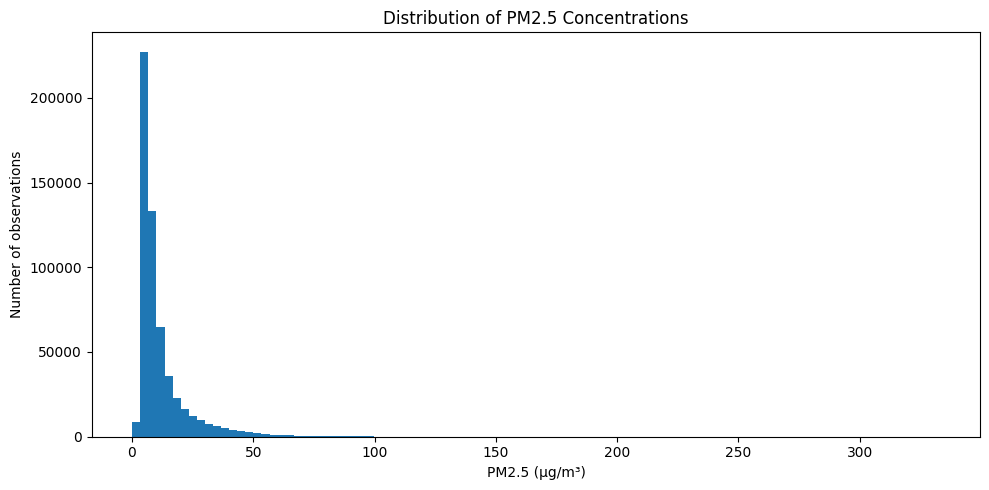

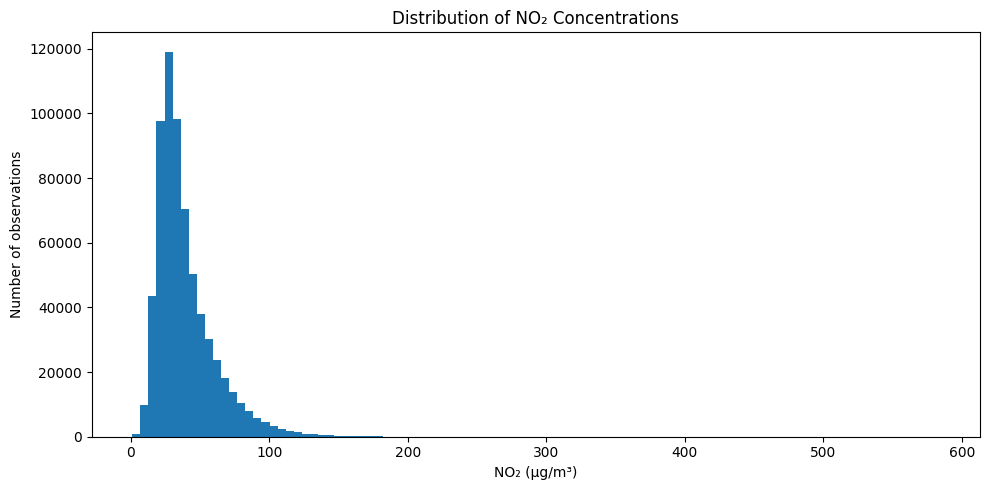

In [56]:
import matplotlib.pyplot as plt

# PM2.5 distribution
plt.figure(figsize=(10, 5))
plt.hist(
    pm25_data["pm2_5_ugm3"],
    bins=100
)
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Number of observations")
plt.title("Distribution of PM2.5 Concentrations")
plt.tight_layout()
plt.show()

# NO2 distribution
plt.figure(figsize=(10, 5))
plt.hist(
    no2_data["no2_ugm3"],
    bins=100
)
plt.xlabel("NO₂ (µg/m³)")
plt.ylabel("Number of observations")
plt.title("Distribution of NO₂ Concentrations")
plt.tight_layout()
plt.show()

This confirms that normality should not be assumed for either pollutant.

For now, we keep the original measurements unchanged. Later, when we perform hypothesis testing and regression, we'll choose methods based on the actual assumptions rather than transforming the data prematurely.

The next question is important:

How do pollutant concentrations vary over time?

Because the data span 2018–2019, we should examine temporal patterns before looking at traffic relationships.

## 6.3 Temporal Patterns in Pollutant Concentrations

Pollutant concentrations can vary substantially by month and season. Understanding temporal variation is important because time-related factors may confound the relationship between traffic exposure and pollution.

In [57]:
# Create monthly summaries for both pollutants

pm25_monthly = (
    pm25_data
    .set_index("date_utc")
    .resample("MS")["pm2_5_ugm3"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

no2_monthly = (
    no2_data
    .set_index("date_utc")
    .resample("MS")["no2_ugm3"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print("PM2.5 monthly summary")
print("=" * 70)
display(pm25_monthly)

print("\nNO2 monthly summary")
print("=" * 70)
display(no2_monthly)

PM2.5 monthly summary


,date_utc,mean,median,count
0,2018-09-01,7.607059,6.63,136
1,2018-10-01,12.514566,8.23,13849
2,2018-11-01,20.166274,12.38,23634
3,2018-12-01,13.169607,9.58,24655
4,2019-01-01,14.174096,10.34,25739
5,2019-02-01,19.886193,13.77,25797
6,2019-03-01,11.747799,8.62,46840
7,2019-04-01,23.405924,15.74,49937
8,2019-05-01,9.716835,7.57,54150
9,2019-06-01,8.738311,6.57,54185



NO2 monthly summary


,date_utc,mean,median,count
0,2018-09-01,56.247375,46.035,640
1,2018-10-01,37.278461,29.390,14111
2,2018-11-01,39.281376,33.495,29974
3,2018-12-01,41.825173,33.915,33832
4,2019-01-01,47.268601,40.395,35542
5,2019-02-01,52.239990,45.490,35707
6,2019-03-01,37.438483,29.700,49653
7,2019-04-01,37.987832,33.460,54982
8,2019-05-01,33.016355,29.540,60079
9,2019-06-01,35.615698,30.900,60190


The monthly averages are descriptive, not evidence that the observed changes were caused by season, traffic, weather, or any other factor.

There is another issue we need to account for: the monitoring network is not perfectly static. We already found that pods were relocated and that different deployments have different coverage. Therefore, a monthly change in the overall mean could partly reflect changes in which sites were contributing observations.

So we should eventually distinguish:

overall temporal variation from within-site temporal variation

## 6.4 Monthly Pollutant Trends

Monthly aggregation provides a high-level view of temporal variation, but a time-series plot makes the magnitude and direction of those changes easier to assess. We will plot PM2.5 and NO₂ separately while retaining the original monthly means.

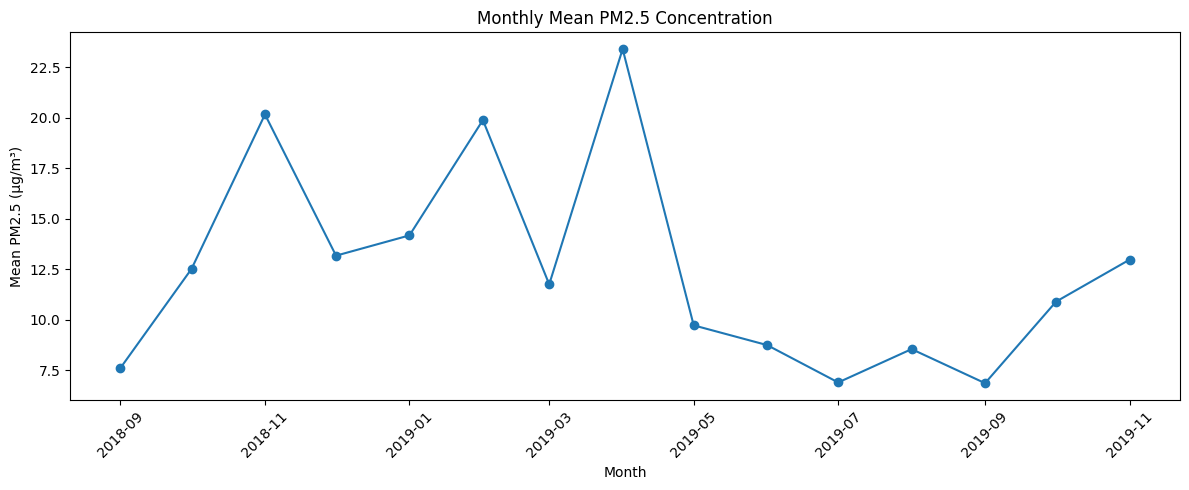

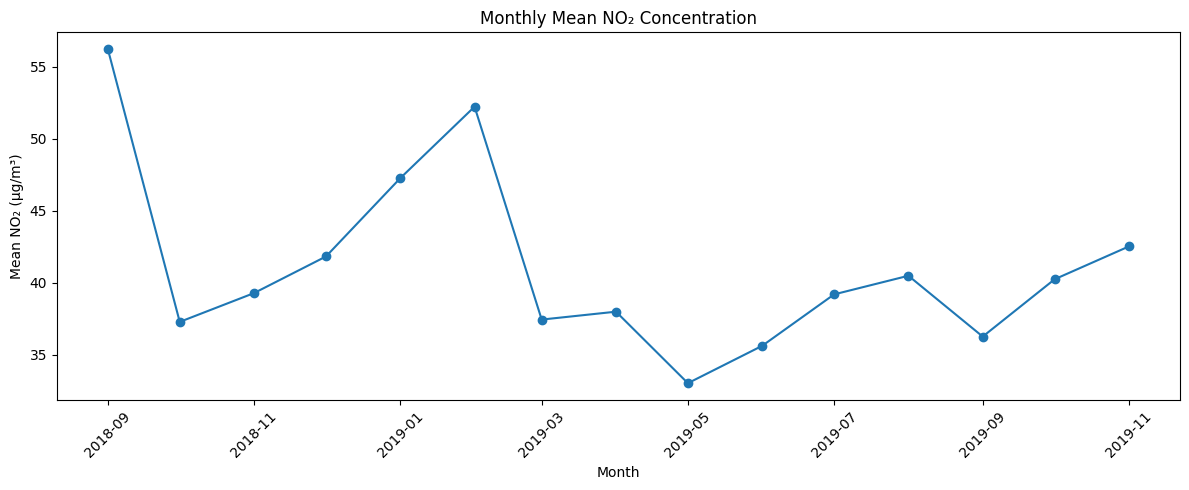

In [58]:
# Plot monthly mean pollutant concentrations

plt.figure(figsize=(12, 5))
plt.plot(
    pm25_monthly["date_utc"],
    pm25_monthly["mean"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Monthly Mean PM2.5 Concentration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    no2_monthly["date_utc"],
    no2_monthly["mean"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Mean NO₂ (µg/m³)")
plt.title("Monthly Mean NO₂ Concentration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PM2.5

- There is substantial month-to-month variation.
- Higher monthly means occur around November 2018, February 2019, and especially April 2019.
- Concentrations then decline markedly from May through September 2019.
- They rise again during October and November 2019.
- The pattern is not a simple monotonic trend across the study period.

## NO₂

- NO₂ is highest in the partial September 2018 period, followed by relatively high values in January and February 2019.
- It reaches its lowest monthly mean around May 2019.
- From June onward, there is moderate fluctuation with an increase toward November 2019.
- The NO₂ pattern is different from PM2.5, which is useful because the two pollutants should not automatically be assumed to have identical temporal behaviour.

Again, the partial September 2018 and November 2019 periods need to be treated cautiously.

More importantly, time clearly matters. This means month, season, hour and related temporal variables may need to be accounted for when we later investigate traffic-pollution associations.

## 6.5 Site-Level Pollutant Variation

### Why are we doing this?

Traffic exposure and road proximity are spatial characteristics, so we need to determine whether pollutant concentrations vary across monitoring deployments. Site-level summaries will show the spatial heterogeneity present in the observations before we investigate its relationship with traffic exposure.

In [59]:
# Calculate site-level pollutant summaries

pm25_site_summary = (
    pm25_data
    .groupby(
        ["pod_id_location", "location_name", "borough"],
        dropna=False
    )["pm2_5_ugm3"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
        observations="count"
    )
    .reset_index()
)

no2_site_summary = (
    no2_data
    .groupby(
        ["pod_id_location", "location_name", "borough"],
        dropna=False
    )["no2_ugm3"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max",
        observations="count"
    )
    .reset_index()
)

print("PM2.5 site-level summary")
print("=" * 70)
print("Number of deployments:", len(pm25_site_summary))

display(
    pm25_site_summary[
        ["mean", "median", "std", "minimum", "maximum", "observations"]
    ].describe()
)

print("\nNO2 site-level summary")
print("=" * 70)
print("Number of deployments:", len(no2_site_summary))

display(
    no2_site_summary[
        ["mean", "median", "std", "minimum", "maximum", "observations"]
    ].describe()
)

PM2.5 site-level summary
Number of deployments: 80


,mean,median,std,minimum,maximum,observations
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,11.761970,7.777938,11.315236,2.810625,137.350500,7126.037500
std,1.938544,1.435226,3.125051,0.719276,55.425464,2080.461721
min,7.308557,5.520000,4.332585,0.140000,33.150000,325.000000
25%,10.718883,6.872500,9.670899,2.590000,100.485000,5780.000000
50%,11.730861,7.450000,11.358951,2.900000,125.265000,6405.000000
75%,12.783394,8.355000,12.734775,3.060000,165.285000,9335.500000
max,18.499533,13.240000,24.615725,5.470000,332.900000,9866.000000



NO2 site-level summary
Number of deployments: 101


,mean,median,std,minimum,maximum,observations
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,38.830916,34.174901,18.664950,7.511980,184.730594,6487.742574
std,9.291710,8.877698,5.408465,3.564368,77.066895,2705.665355
min,13.831050,11.970000,7.567961,1.120000,51.570000,321.000000
25%,32.856058,28.730000,15.326258,4.920000,137.200000,5124.000000
50%,37.710185,32.735000,18.655300,7.460000,172.960000,6767.000000
75%,43.102170,38.500000,21.449350,9.570000,210.520000,8912.000000
max,74.193791,72.075000,42.627649,18.210000,583.940000,10128.000000


- PM2.5: Site-level mean concentrations range from 7.31 to 18.50 µg/m³, showing meaningful variation between deployments.
- NO₂: Site-level means range from 13.83 to 74.19 µg/m³, indicating substantially greater spatial variation.
- The difference between site-level means confirms that pollution levels are not uniform across monitoring locations.
- This supports investigating road proximity, traffic exposure, site type, and other spatial factors.
- Site-level maximums are much higher than the corresponding means, confirming that individual pollution episodes contribute to within-site variability.

## 6.6 Site-Level Pollutant Variation

We now know that pollutant levels vary substantially between deployments. A visual comparison will show how that variation is distributed across monitoring sites.

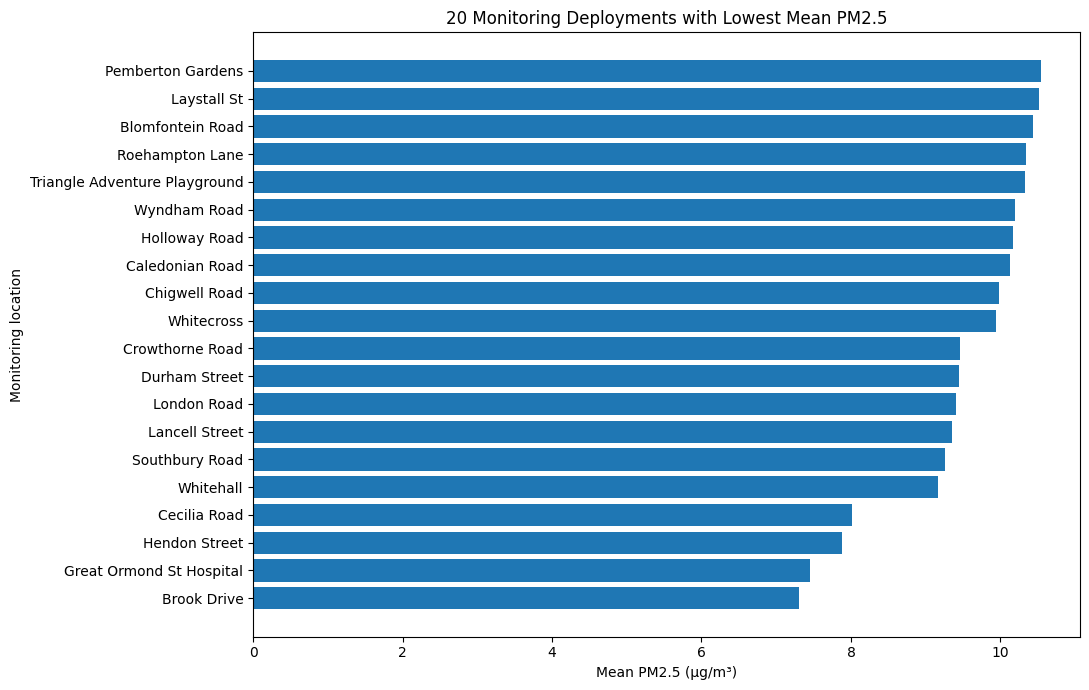

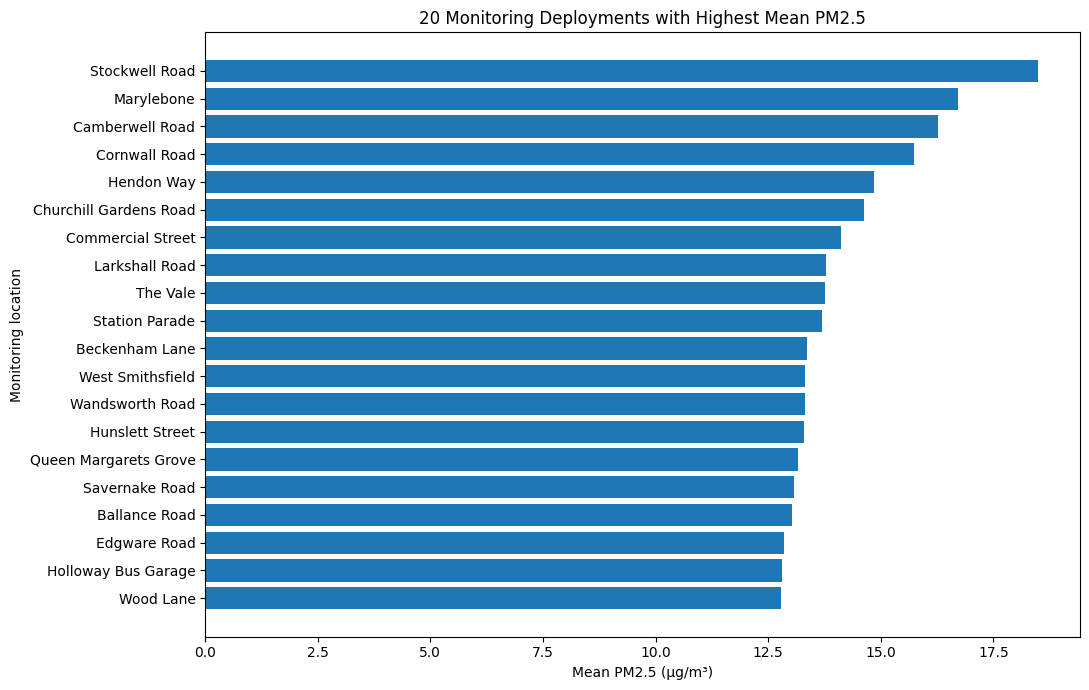

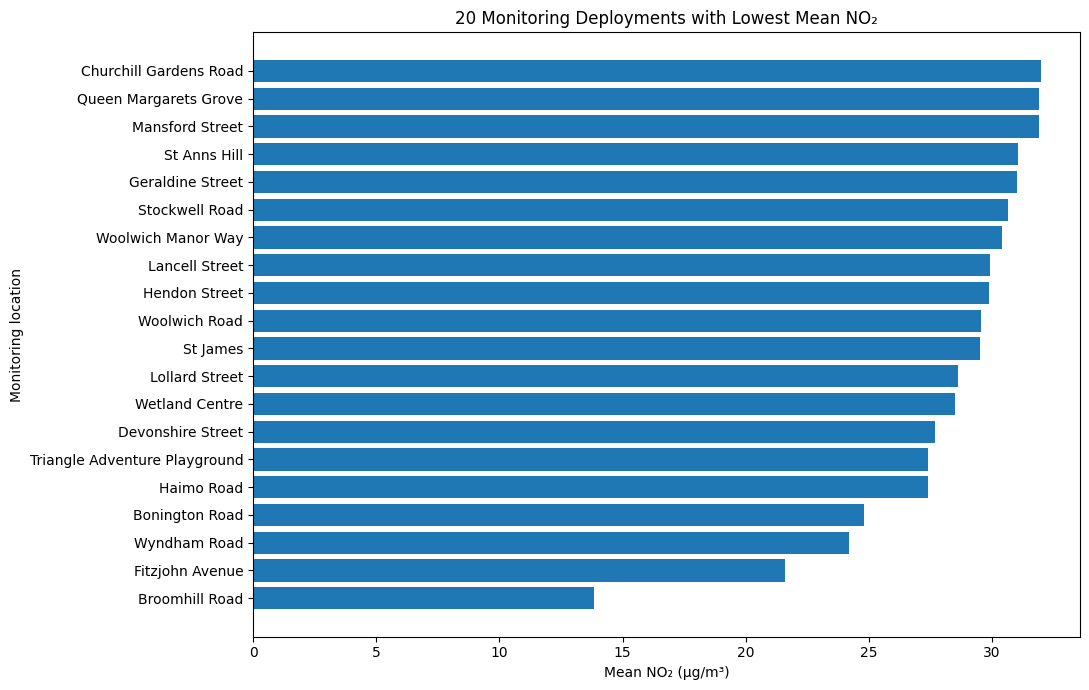

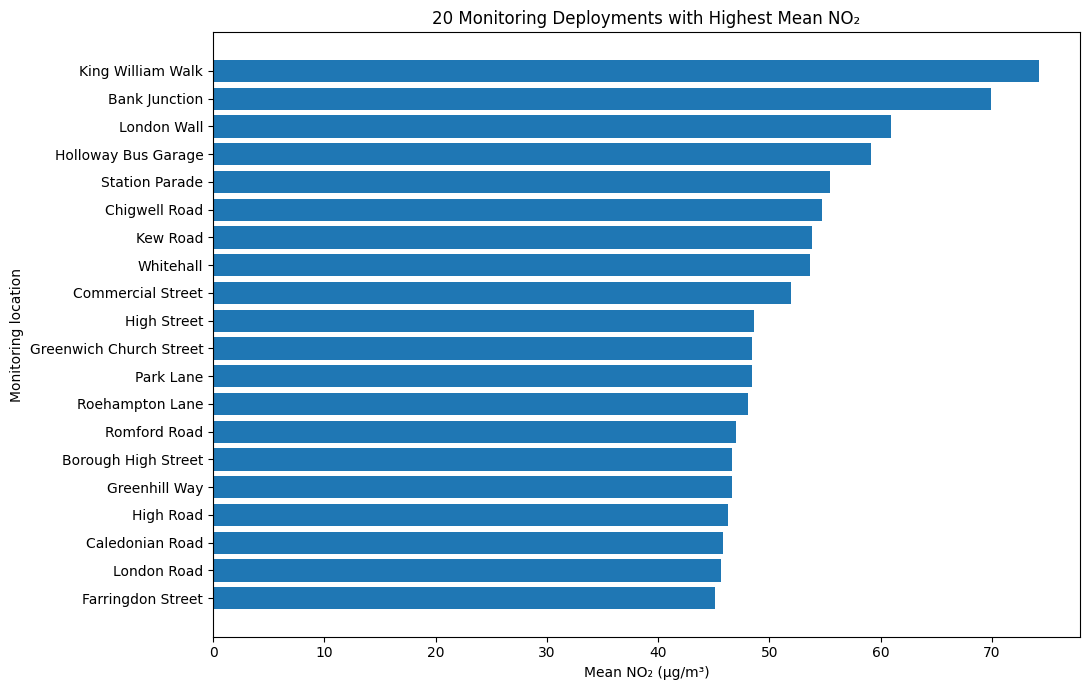

In [60]:
# Plot the 20 lowest and 20 highest site-level mean concentrations

# -----------------------------
# PM2.5
# -----------------------------

pm25_low = pm25_site_summary.sort_values("mean").head(20)
pm25_high = pm25_site_summary.sort_values("mean", ascending=False).head(20)

plt.figure(figsize=(11, 7))
plt.barh(
    pm25_low["location_name"],
    pm25_low["mean"]
)
plt.xlabel("Mean PM2.5 (µg/m³)")
plt.ylabel("Monitoring location")
plt.title("20 Monitoring Deployments with Lowest Mean PM2.5")
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 7))
plt.barh(
    pm25_high["location_name"].iloc[::-1],
    pm25_high["mean"].iloc[::-1]
)
plt.xlabel("Mean PM2.5 (µg/m³)")
plt.ylabel("Monitoring location")
plt.title("20 Monitoring Deployments with Highest Mean PM2.5")
plt.tight_layout()
plt.show()


# -----------------------------
# NO2
# -----------------------------

no2_low = no2_site_summary.sort_values("mean").head(20)
no2_high = no2_site_summary.sort_values("mean", ascending=False).head(20)

plt.figure(figsize=(11, 7))
plt.barh(
    no2_low["location_name"],
    no2_low["mean"]
)
plt.xlabel("Mean NO₂ (µg/m³)")
plt.ylabel("Monitoring location")
plt.title("20 Monitoring Deployments with Lowest Mean NO₂")
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 7))
plt.barh(
    no2_high["location_name"].iloc[::-1],
    no2_high["mean"].iloc[::-1]
)
plt.xlabel("Mean NO₂ (µg/m³)")
plt.ylabel("Monitoring location")
plt.title("20 Monitoring Deployments with Highest Mean NO₂")
plt.tight_layout()
plt.show()

- **PM2.5:** The 20 highest deployments have means of roughly 13 to 19 µg/m³, while the lowest group is roughly 7 to 11 µg/m³.
- **NO₂:** The highest deployments reach roughly 45 to 74 µg/m³, while the lowest group is roughly 14 to 32 µg/m³.
- The site-level differences are particularly pronounced for NO₂.
- The same location does not necessarily appear in the high/low groups for both pollutants, indicating that their spatial patterns are not identical.
- These differences justify examining road proximity, traffic characteristics and monitoring-site type as potential explanatory variables.

## 6.7 Monitoring Site Characteristics

Pollution concentrations can vary because monitoring sites have different physical and urban characteristics. We will examine site type, ULEZ status, road distance and monitoring height before analysing their relationships with pollutant concentrations.

In [61]:
# Summarise key monitoring-site characteristics

print("MONITORING SITE CHARACTERISTICS")
print("=" * 70)

print("\nMonitoring site type:")
print(metadata["type"].value_counts())

print("\nULEZ status:")
print(metadata["ulez"].value_counts())

print("\nDistance from road (m):")
print(metadata["distance_from_road"].describe())

print("\nMonitoring height (m):")
print(metadata["height"].describe())

print("\nNumber of unique boroughs:")
print(metadata["borough"].nunique())

print("\nNumber of unique physical locations:")
print(
    metadata[
        ["latitude", "longitude"]
    ].drop_duplicates().shape[0]
)

MONITORING SITE CHARACTERISTICS

Monitoring site type:
type
Urban Background    66
Roadside            62
Kerbside            53
Name: count, dtype: Int64

ULEZ status:
ulez
No     139
Yes     42
Name: count, dtype: Int64

Distance from road (m):
count    170.000000
mean       4.050918
std        5.906308
min        0.000000
25%        1.000000
50%        1.700000
75%        5.000000
max       36.700000
Name: distance_from_road, dtype: float64

Monitoring height (m):
count    181.000000
mean       3.456331
std        2.533555
min        1.500000
25%        2.767000
50%        3.012000
75%        3.250000
max       20.000000
Name: height, dtype: float64

Number of unique boroughs:
32

Number of unique physical locations:
103


- The monitoring network contains 3 site types: Urban Background (66), Roadside (62), and Kerbside (53).
- 42 of 181 metadata records are within the ULEZ, while 139 are outside.
- Road distance varies considerably, from 0 to 36.7 m, with a median of 1.7 m.
- Monitoring height ranges from 1.5 to 20 m, although most sites are around 3 m.
- The data cover 32 boroughs and 103 physical locations.
- These characteristics provide useful spatial variables for investigating differences in pollutant concentrations.

## 6.8 Pollutant Concentration by Monitoring Site Type

### Why are we doing this?

Monitoring sites represent different urban exposure environments. Comparing pollutant concentrations across site types will show whether systematic differences exist between roadside, kerbside and urban-background deployments.

In [62]:
# Compare pollutant concentrations across monitoring site types

pm25_type_summary = (
    pm25_data
    .groupby("type")["pm2_5_ugm3"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        observations="count"
    )
    .sort_values("mean", ascending=False)
)

no2_type_summary = (
    no2_data
    .groupby("type")["no2_ugm3"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        observations="count"
    )
    .sort_values("mean", ascending=False)
)

print("PM2.5 by monitoring site type")
print("=" * 70)
display(pm25_type_summary)

print("\nNO2 by monitoring site type")
print("=" * 70)
display(no2_type_summary)

PM2.5 by monitoring site type


,mean,median,std,observations
type,,,,
Kerbside,12.312048,8.11,12.644918,144317
Roadside,11.845443,7.61,12.258549,192898
Urban Background,11.751739,7.63,11.666070,232868



NO2 by monitoring site type


,mean,median,std,observations
type,,,,
Kerbside,44.266820,38.13,23.473872,202373
Roadside,41.357628,35.13,22.542965,224435
Urban Background,33.313670,28.74,17.595994,228454


- **PM2.5:** Kerbside sites have the highest mean (12.31 µg/m³), followed by Roadside (11.85) and Urban Background (11.75).
- **NO₂:** The difference is much clearer. Kerbside sites have the highest mean (44.27 µg/m³), followed by Roadside (41.36) and Urban Background (33.31).
- NO₂ shows a substantially larger difference between traffic-oriented and background sites than PM2.5.
- These are descriptive differences only. Statistical testing is required to determine whether the differences are statistically significant.

**Decision:** Visualise the distributions by site type and later formally test the differences.

## 6.9 Distribution of Pollutants by Monitoring Site Type

Mean concentrations alone can hide differences in variability and extreme observations. Boxplots allow us to compare the distributions of PM2.5 and NO₂ across monitoring site types.

<Figure size 900x600 with 0 Axes>

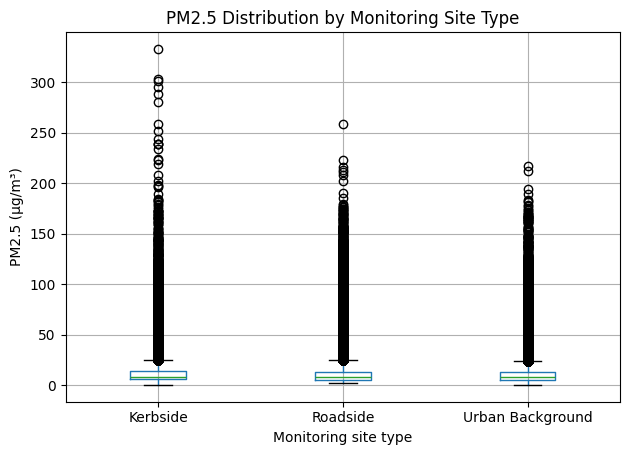

<Figure size 900x600 with 0 Axes>

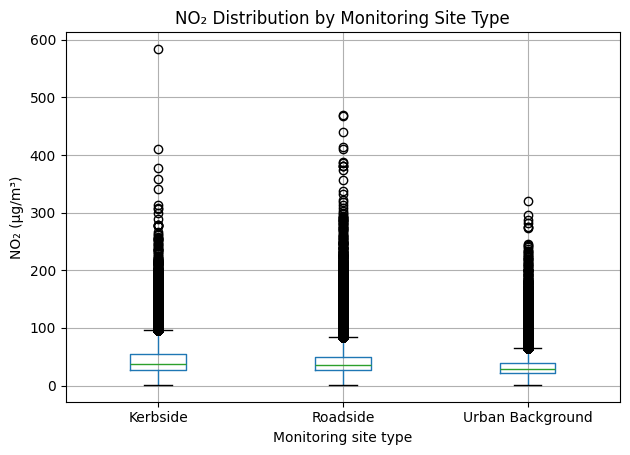

In [63]:
# Boxplots of pollutant concentrations by monitoring site type

plt.figure(figsize=(9, 6))

pm25_data.boxplot(
    column="pm2_5_ugm3",
    by="type"
)

plt.xlabel("Monitoring site type")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 Distribution by Monitoring Site Type")
plt.suptitle("")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 6))

no2_data.boxplot(
    column="no2_ugm3",
    by="type"
)

plt.xlabel("Monitoring site type")
plt.ylabel("NO₂ (µg/m³)")
plt.title("NO₂ Distribution by Monitoring Site Type")
plt.suptitle("")
plt.tight_layout()
plt.show()

- Both pollutants show substantial numbers of high-value observations and strong right-skewness across all site types.
- **PM2.5:** The three site types have broadly similar central distributions, although Kerbside has the highest mean.
- **NO₂:** Kerbside and Roadside sites show higher central concentrations than Urban Background sites.
- The large number of extreme observations confirms that pollutant variability is substantial and that the distributions are not approximately normal.
- The differences observed here are descriptive and do not establish statistical significance.

Site type appears particularly relevant for NO₂. We will retain it as an explanatory variable and later test the observed group differences statistically.

## 6.10 Road Proximity and Pollutant Concentration

Road proximity is a direct spatial measure of potential traffic exposure. We will examine whether pollutant concentrations vary with distance from the nearest road before applying formal correlation or regression methods.

In [64]:
# Summarise road distance and its relationship with pollutant concentration

for dataset_name, df, pollutant_column in [
    ("PM2.5", pm25_data, "pm2_5_ugm3"),
    ("NO2", no2_data, "no2_ugm3")
]:
    analysis = df[
        ["distance_from_road", pollutant_column]
    ].dropna()

    print(f"{dataset_name}")
    print("=" * 70)

    print("Observations with valid road distance:", len(analysis))
    print("Unique monitoring deployments:",
          df.loc[
              df["distance_from_road"].notna(),
              "pod_id_location"
          ].nunique())

    print("\nPearson correlation:")
    print(
        analysis["distance_from_road"]
        .corr(analysis[pollutant_column], method="pearson")
    )

    print("Spearman correlation:")
    print(
        analysis["distance_from_road"]
        .corr(analysis[pollutant_column], method="spearman")
    )

    print()

PM2.5
Observations with valid road distance: 530727
Unique monitoring deployments: 75

Pearson correlation:
-0.015048707311826951
Spearman correlation:
-0.020516949113505573

NO2
Observations with valid road distance: 612961
Unique monitoring deployments: 95

Pearson correlation:
-0.12321050217457212
Spearman correlation:
-0.14964199465336367



- **PM2.5:** Pearson (-0.015) and Spearman (-0.021) indicate a very weak negative association with road distance.
- **NO₂:** Pearson (-0.123) and Spearman (-0.150) indicate a stronger, but still relatively weak, negative association.
- The negative direction means pollutant concentrations tend to decrease as distance from the road increases.
- The stronger pattern for NO₂ is consistent with the earlier site-type results, where traffic-oriented sites had higher NO₂ concentrations.
- These correlations are exploratory and do not establish causation or statistical significance.

Visualise the road-distance relationships before deciding on formal correlation and regression analyses.

## 6.11 Road Distance and Pollutant Concentration

Correlation coefficients summarize the direction and strength of an association but do not show its shape. Scatterplots allow us to visually assess whether pollutant concentrations change with road distance and whether extreme observations influence the relationship.

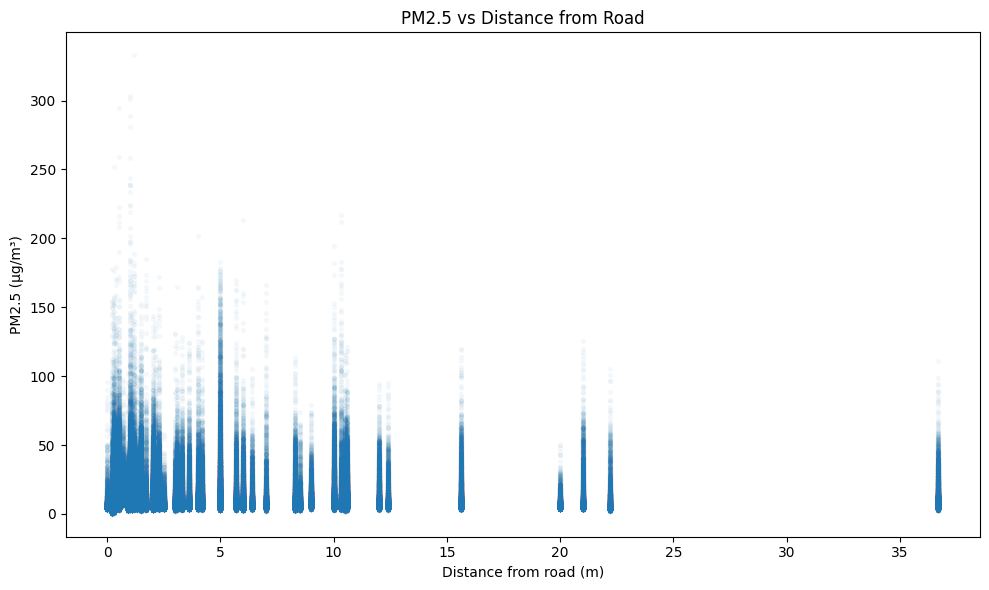

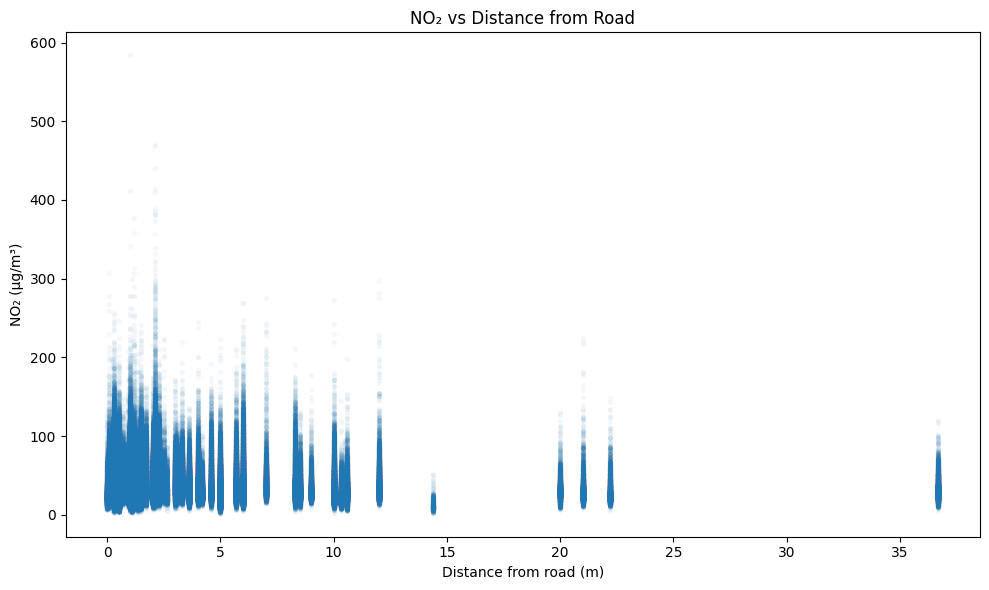

In [65]:

# Visualise road distance versus pollutant concentration

pm25_distance = pm25_data[
    ["distance_from_road", "pm2_5_ugm3"]
].dropna()

no2_distance = no2_data[
    ["distance_from_road", "no2_ugm3"]
].dropna()


# PM2.5
plt.figure(figsize=(10, 6))
plt.scatter(
    pm25_distance["distance_from_road"],
    pm25_distance["pm2_5_ugm3"],
    alpha=0.03,
    s=8
)
plt.xlabel("Distance from road (m)")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 vs Distance from Road")
plt.tight_layout()
plt.show()


# NO2
plt.figure(figsize=(10, 6))
plt.scatter(
    no2_distance["distance_from_road"],
    no2_distance["no2_ugm3"],
    alpha=0.03,
    s=8
)
plt.xlabel("Distance from road (m)")
plt.ylabel("NO₂ (µg/m³)")
plt.title("NO₂ vs Distance from Road")
plt.tight_layout()
plt.show()




- Both plots show substantial vertical clustering because road distance is a site-level variable repeated across hourly observations.
- PM2.5 shows little visible association with road distance, consistent with the very weak correlations.
- NO₂ shows a clearer negative pattern, with concentrations generally lower at greater road distances.
- However, the observation-level correlations are influenced by repeated measurements from the same monitoring deployments.
- Therefore, they should not be treated as independent observations for formal inference.

**Decision:** For the next analysis, aggregate pollutant concentrations by monitoring deployment and examine road distance against site-level mean concentration. This provides a more appropriate spatial comparison and avoids treating repeated hourly measurements as independent sites.

## 6.12 Site-Level Road Proximity Analysis

Road distance is constant within a monitoring deployment, while pollutant measurements are recorded repeatedly over time. We will therefore aggregate pollutant concentrations to the deployment level before examining the spatial relationship between road distance and pollutant concentration.

In [66]:
# Create site-level datasets containing pollutant means and road distance

pm25_distance_site = (
    pm25_data
    .groupby(
        ["pod_id_location", "location_name", "borough"],
        dropna=False
    )
    .agg(
        mean_pm25=("pm2_5_ugm3", "mean"),
        distance_from_road=("distance_from_road", "first"),
        observations=("pm2_5_ugm3", "count")
    )
    .reset_index()
    .dropna(subset=["distance_from_road"])
)

no2_distance_site = (
    no2_data
    .groupby(
        ["pod_id_location", "location_name", "borough"],
        dropna=False
    )
    .agg(
        mean_no2=("no2_ugm3", "mean"),
        distance_from_road=("distance_from_road", "first"),
        observations=("no2_ugm3", "count")
    )
    .reset_index()
    .dropna(subset=["distance_from_road"])
)

print("SITE-LEVEL ROAD DISTANCE ANALYSIS")
print("=" * 70)

print("\nPM2.5")
print("Deployments:", len(pm25_distance_site))
print(
    "Pearson correlation:",
    pm25_distance_site["distance_from_road"]
    .corr(pm25_distance_site["mean_pm25"], method="pearson")
)
print(
    "Spearman correlation:",
    pm25_distance_site["distance_from_road"]
    .corr(pm25_distance_site["mean_pm25"], method="spearman")
)

print("\nNO2")
print("Deployments:", len(no2_distance_site))
print(
    "Pearson correlation:",
    no2_distance_site["distance_from_road"]
    .corr(no2_distance_site["mean_no2"], method="pearson")
)
print(
    "Spearman correlation:",
    no2_distance_site["distance_from_road"]
    .corr(no2_distance_site["mean_no2"], method="spearman")
)

SITE-LEVEL ROAD DISTANCE ANALYSIS

PM2.5
Deployments: 75
Pearson correlation: -0.12112614820228489
Spearman correlation: -0.09954861192255501

NO2
Deployments: 95
Pearson correlation: -0.32523076899675385
Spearman correlation: -0.32653085569667495


- **PM2.5:** Site-level correlations with road distance are weakly negative (Pearson = -0.121; Spearman = -0.100).
- **NO₂:** The relationship is more pronounced (Pearson = -0.325; Spearman = -0.327).
- For both pollutants, higher concentrations tend to occur at sites closer to roads, with the pattern substantially stronger for NO₂.
- The similar Pearson and Spearman values for NO₂ suggest the negative relationship is not driven solely by a few extreme sites.
- These results are descriptive associations, not evidence of causation or statistical significance.

**Decision:** Visualise the site-level relationships and then formally test the road-proximity hypotheses.

## 6.13 Site-Level Road Distance Relationships

The site-level correlations indicate a stronger negative association between road distance and NO₂ than PM2.5. We will visualise these relationships using one point per monitoring deployment.

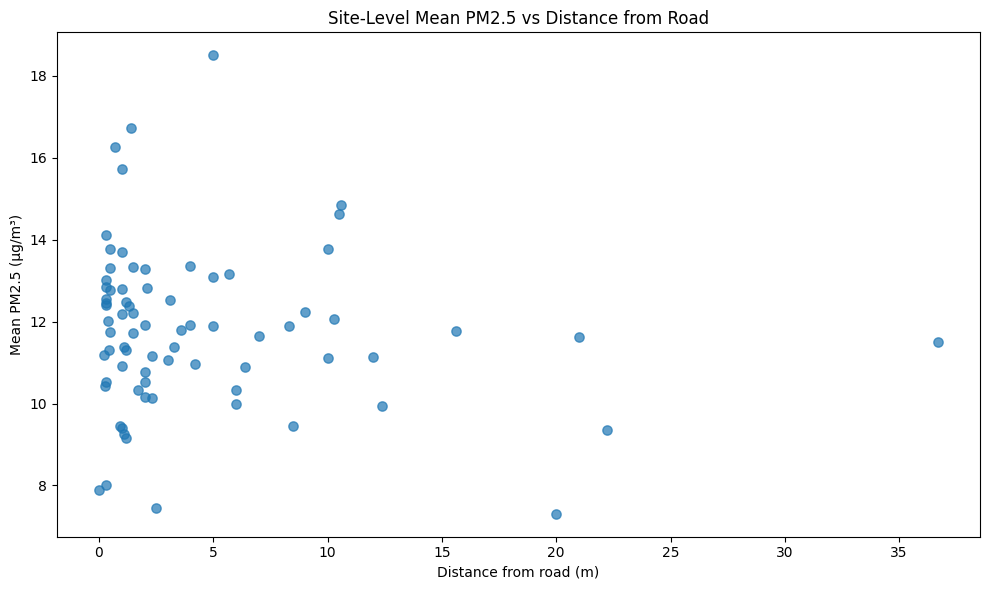

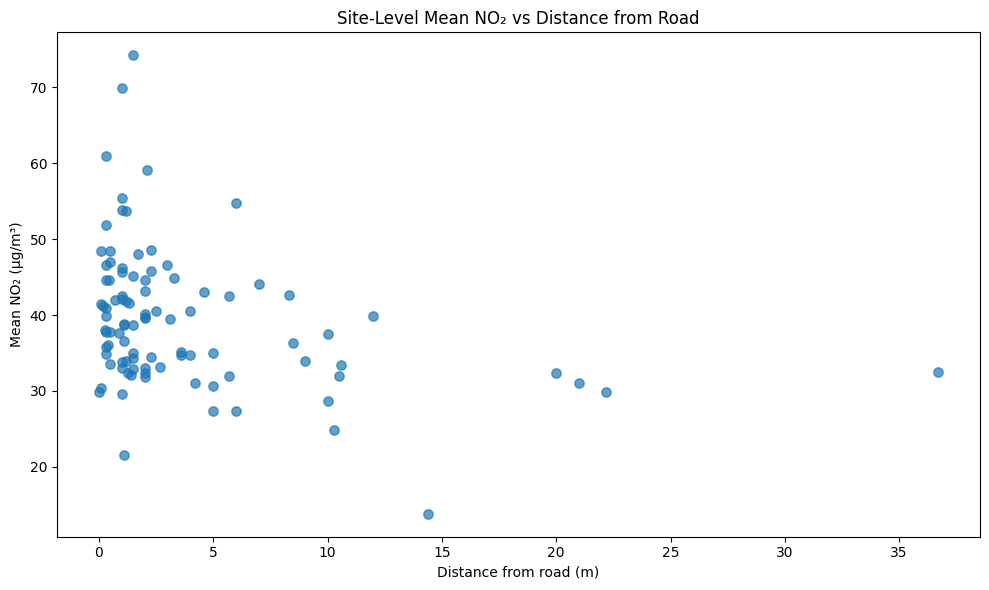

In [67]:
# Plot site-level road distance against mean pollutant concentration

plt.figure(figsize=(10, 6))

plt.scatter(
    pm25_distance_site["distance_from_road"],
    pm25_distance_site["mean_pm25"],
    s=45,
    alpha=0.7
)

plt.xlabel("Distance from road (m)")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Site-Level Mean PM2.5 vs Distance from Road")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.scatter(
    no2_distance_site["distance_from_road"],
    no2_distance_site["mean_no2"],
    s=45,
    alpha=0.7
)

plt.xlabel("Distance from road (m)")
plt.ylabel("Mean NO₂ (µg/m³)")
plt.title("Site-Level Mean NO₂ vs Distance from Road")
plt.tight_layout()
plt.show()

- **PM2.5:** The site-level relationship with road distance is weak and shows substantial scatter.
- **NO₂:** The negative relationship is more visible, with higher mean concentrations generally occurring at sites closer to roads.
- Both plots contain considerable variation at similar distances, indicating that road distance alone does not explain pollutant concentration.
- Other factors such as site type, traffic intensity, meteorology and temporal conditions may contribute to the remaining variation.

**Decision:** Proceed to formal statistical testing of the road-proximity hypotheses, then investigate traffic intensity as another potential exposure variable.

# Chapter 7: Spatial & Traffic Exposure Analysis

## 7.1 Traffic Data Structure

The research question requires traffic exposure variables to be connected to monitoring locations. Before performing a spatial integration, we need to understand the spatial units and traffic measures represented in the major-road and minor-road datasets.

In [68]:
# Inspect the structure and key numerical fields of the traffic datasets

print("MAJOR-ROAD TRAFFIC DATA")
print("=" * 70)

print("Shape:", major_roads_clean.shape)
print("Year(s):", major_roads_clean["year"].unique())

print("\nSpatial identifier:")
print("Unique TOIDs:", major_roads_clean["TOID"].nunique())

print("\nTraffic flow columns:")
major_flow_columns = [
    "AADF.motorcycles",
    "AADF.taxis",
    "AADF.cars",
    "AADF.phvs",
    "AADF.lgvs",
    "AADF.hgvs.rigid",
    "AADF.hgvs.articulated",
    "AADF.tfl.buses",
    "AADF.non.tfl.buses",
    "AADF.coaches"
]

display(
    major_roads_clean[major_flow_columns].describe()
)


print("\n\nMINOR-ROAD TRAFFIC DATA")
print("=" * 70)

print("Shape:", minor_roads_clean.shape)
print("Year(s):", minor_roads_clean["year"].unique())

print("\nSpatial identifier:")
print("Unique grid IDs:", minor_roads_clean["grid.id.unique"].nunique())

print("\nCoordinate ranges:")
print(
    minor_roads_clean[
        ["easting", "northing"]
    ].describe()
)

print("\nVKM columns:")
minor_vkm_columns = [
    "vkm.motorcycles",
    "vkm.taxis",
    "vkm.cars",
    "vkm.phvs",
    "vkm.lgvs",
    "vkm.hgvs.rigid",
    "vkm.hgvs.articulated",
    "vkm.tfl.buses",
    "vkm.non.tfl.buses",
    "vkm.coaches"
]

display(
    minor_roads_clean[minor_vkm_columns].describe()
)

MAJOR-ROAD TRAFFIC DATA
Shape: (79437, 18)
Year(s): [2022]

Spatial identifier:
Unique TOIDs: 79437

Traffic flow columns:


,AADF.motorcycles,AADF.taxis,AADF.cars,AADF.phvs,AADF.lgvs,AADF.hgvs.rigid,AADF.hgvs.articulated,AADF.tfl.buses,AADF.non.tfl.buses,AADF.coaches
count,79437.000000,79437.000000,79437.000000,79437.000000,79437.000000,79437.000000,79437.000000,79437.000000,79437.000000,79437.000000
mean,319.704332,252.839785,7895.595831,525.488110,2055.339980,323.324912,138.798129,234.002115,61.268678,115.269950
std,336.142147,636.822905,6911.776235,783.197397,1800.046276,499.505377,556.801938,308.262743,71.310265,145.552194
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,117.000000,32.000000,3069.000000,121.000000,877.000000,38.000000,5.000000,0.000000,10.000000,16.000000
50%,230.000000,81.000000,6291.000000,288.000000,1624.000000,159.000000,30.000000,129.000000,43.000000,74.000000
75%,401.000000,191.000000,10870.000000,576.000000,2674.000000,410.000000,104.000000,344.000000,87.000000,157.000000
max,5179.000000,12596.000000,81268.000000,8803.000000,33822.000000,9507.000000,10436.000000,2466.000000,2879.000000,3817.000000




MINOR-ROAD TRAFFIC DATA
Shape: (3460, 20)
Year(s): [2022]

Spatial identifier:
Unique grid IDs: 3460

Coordinate ranges:
             easting       northing
count    3460.000000    3460.000000
mean   529738.728324  178925.722543
std     14543.479989   12435.132767
min    501500.000000  152500.000000
25%    518500.000000  169500.000000
50%    529500.000000  179500.000000
75%    541500.000000  188500.000000
max    561500.000000  203500.000000

VKM columns:


,vkm.motorcycles,vkm.taxis,vkm.cars,vkm.phvs,vkm.lgvs,vkm.hgvs.rigid,vkm.hgvs.articulated,vkm.tfl.buses,vkm.non.tfl.buses,vkm.coaches
count,3460.000000,3.460000e+03,3.460000e+03,3.460000e+03,3.460000e+03,3460.000000,3460.000000,3460.000000,3460.000000,3460.000000
mean,56761.949821,3.573726e+04,1.497801e+06,9.621811e+04,3.963278e+05,65043.066563,23528.546369,35396.980263,10649.759334,19478.976104
std,86062.966901,9.233879e+04,1.610422e+06,1.626845e+05,4.453183e+05,80767.931178,25073.265660,60636.452783,13893.847806,30135.812088
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7116.186520,2.077029e+03,2.935758e+05,1.204867e+04,7.398870e+04,11244.707138,4185.920200,1358.521463,1377.290865,1993.857606
50%,24528.071510,7.945314e+03,9.620950e+05,4.038264e+04,2.413723e+05,36788.545699,16295.701419,8786.223164,4889.153949,7392.478488
75%,68689.105805,3.017004e+04,2.216145e+06,1.014046e+05,5.804089e+05,89707.166746,34342.628503,46680.573637,14318.181955,23890.669476
max,916682.806134,1.349318e+06,1.277468e+07,1.601625e+06,3.320103e+06,837928.039749,196414.010316,533094.520542,94998.752639,232508.332821


- Both traffic datasets contain **2022 traffic activity**, while the air-quality observations are from **2018–2019**. Therefore, traffic will be treated as a spatial exposure proxy rather than contemporaneous traffic measurement.
- Major roads contain **79,437 individual road segments** with AADF vehicle counts.
- Minor roads contain **3,460 spatial grid cells** with vehicle-kilometres travelled (VKM).
- Traffic variables are strongly right-skewed, with large differences between low- and high-traffic locations.
- The LAEI methodology identifies the vehicle categories used here as motorcycles, cars, PHVs, LGVs, taxis, HGVs, buses and coaches. :contentReference[oaicite:0]{index=0}
- Major-road AADF and minor-road VKM measure different forms of traffic activity, so they should **not be combined directly**.

**Decision:** Construct separate total-traffic exposure measures for major roads and minor-road grids, while retaining the individual vehicle categories for later analysis.

In [69]:
# Define traffic activity columns

major_flow_columns = [
    "AADF.motorcycles",
    "AADF.taxis",
    "AADF.cars",
    "AADF.phvs",
    "AADF.lgvs",
    "AADF.hgvs.rigid",
    "AADF.hgvs.articulated",
    "AADF.tfl.buses",
    "AADF.non.tfl.buses",
    "AADF.coaches"
]

minor_vkm_columns = [
    "vkm.motorcycles",
    "vkm.taxis",
    "vkm.cars",
    "vkm.phvs",
    "vkm.lgvs",
    "vkm.hgvs.rigid",
    "vkm.hgvs.articulated",
    "vkm.tfl.buses",
    "vkm.non.tfl.buses",
    "vkm.coaches"
]


# Calculate total traffic activity

major_roads_clean["total_aadf"] = (
    major_roads_clean[major_flow_columns]
    .sum(axis=1)
)

minor_roads_clean["total_vkm"] = (
    minor_roads_clean[minor_vkm_columns]
    .sum(axis=1)
)


print("Traffic exposure measures")
print("=" * 70)

print("\nMajor roads - Total AADF")
print(major_roads_clean["total_aadf"].describe())

print("\nMinor roads - Total VKM")
print(minor_roads_clean["total_vkm"].describe())

Traffic exposure measures

Major roads - Total AADF
count     79437.000000
mean      11921.631821
std        9882.655629
min           0.000000
25%        5296.000000
50%        9837.000000
75%       15906.000000
max      135432.000000
Name: total_aadf, dtype: float64

Minor roads - Total VKM
count    3.460000e+03
mean     2.236944e+06
std      2.468663e+06
min      0.000000e+00
25%      4.211068e+05
50%      1.398836e+06
75%      3.270953e+06
max      1.730689e+07
Name: total_vkm, dtype: float64


- Major-road total AADF has a mean of approximately **11,922 vehicles/day**, with a median of **9,837 vehicles/day**.
- Major-road traffic is strongly right-skewed, with values ranging from **0 to 135,432 vehicles/day**.
- Minor-road total VKM has a mean of approximately **2.24 million vehicle-km**, with a median of approximately **1.40 million vehicle-km**.
- Minor-road traffic also shows substantial right-skewness, ranging from **0 to 17.31 million vehicle-km**.
- The large difference between the mean and median in both datasets indicates that a relatively small number of locations have substantially higher traffic activity.

**Important:** AADF and VKM represent different traffic measures and must not be compared as if they were the same unit.

**Decision:** Retain `total_aadf` and `total_vkm` as separate exposure measures and preserve the vehicle-specific variables for later feature engineering.

## 7.3 Spatial compatibility check

Before we attach traffic exposure to the air-quality monitoring sites, we need to determine how accurately the traffic data can be spatially matched.

The minor-road dataset already contains easting and northing, while the air-quality metadata also contains x_coord and y_coord. That gives us a direct route for spatial matching.

In [70]:
# Inspect the spatial structure of the minor-road grid

print("MINOR-ROAD SPATIAL STRUCTURE")
print("=" * 70)

print("Easting range:")
print(
    minor_roads_clean["easting"].min(),
    "to",
    minor_roads_clean["easting"].max()
)

print("\nNorthing range:")
print(
    minor_roads_clean["northing"].min(),
    "to",
    minor_roads_clean["northing"].max()
)

print("\nUnique easting values:", minor_roads_clean["easting"].nunique())
print("Unique northing values:", minor_roads_clean["northing"].nunique())

print("\nFirst 10 spatial records:")
display(
    minor_roads_clean[
        [
            "grid.id.unique",
            "grid.id.1km2",
            "easting",
            "northing",
            "area.km2",
            "borough",
            "total_vkm"
        ]
    ].head(10)
)

MINOR-ROAD SPATIAL STRUCTURE
Easting range:
501500 to 561500

Northing range:
152500 to 203500

Unique easting values: 61
Unique northing values: 52

First 10 spatial records:


,grid.id.unique,grid.id.1km2,easting,northing,area.km2,borough,total_vkm
0,1,5910,510500,203500,1.0,Non-GLA,8.454394e+05
1,2,5911,511500,203500,1.0,Non-GLA,6.136989e+05
2,3,5912,512500,203500,1.0,Non-GLA,1.193572e+06
3,4,5915,515500,203500,1.0,Non-GLA,1.031786e+06
4,5,5916,516500,203500,1.0,Non-GLA,8.391885e+05
5,6,5917,517500,203500,1.0,Non-GLA,2.126171e+06
6,7,5918,518500,203500,1.0,Non-GLA,3.046915e+06
7,8,5919,519500,203500,1.0,Non-GLA,1.280996e+06
8,9,6080,508500,202500,1.0,Non-GLA,7.907717e+05
9,10,6081,509500,202500,1.0,Non-GLA,1.700916e+06



This confirms that the minor-road data are organized on a 1 km × 1 km spatial grid: the coordinates advance in 1,000 m increments, and area.km2 = 1.0.

That is compatible with the British National Grid coordinates in the air-quality metadata, so we can perform a spatial matching exercise without pretending the two datasets have the same spatial resolution.

The next thing we need to establish is how close each monitoring location is to a traffic grid cell. This matters because assigning a grid's traffic activity to a monitoring site is an approximation.

## 7.3 Monitoring Sites and Traffic Grid Compatibility

The air-quality monitoring sites and minor-road traffic data use spatial coordinates, but the traffic data are aggregated into 1 km² grid cells. Before assigning traffic exposure to monitoring sites, we need to measure the spatial distance between each monitoring location and its nearest traffic grid cell.

This determines whether the minor-road traffic data can provide a reasonable spatial exposure proxy for the monitoring sites.

In [71]:
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Obtain unique physical monitoring locations
# ---------------------------------------------------------

monitoring_sites = (
    metadata[
        ["location_name", "x_coord", "y_coord"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 2. Obtain unique minor-road grid coordinates
# ---------------------------------------------------------

traffic_grid = (
    minor_roads_clean[
        ["grid.id.unique", "easting", "northing", "total_vkm"]
    ]
    .drop_duplicates("grid.id.unique")
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 3. Build nearest-neighbour spatial search
# ---------------------------------------------------------

grid_coordinates = traffic_grid[
    ["easting", "northing"]
].to_numpy()

site_coordinates = monitoring_sites[
    ["x_coord", "y_coord"]
].to_numpy()

tree = cKDTree(grid_coordinates)

distances, nearest_indices = tree.query(site_coordinates)

# ---------------------------------------------------------
# 4. Attach nearest grid information
# ---------------------------------------------------------

monitoring_sites["nearest_grid_distance_m"] = distances
monitoring_sites["nearest_grid_id"] = (
    traffic_grid.iloc[nearest_indices]["grid.id.unique"].to_numpy()
)

monitoring_sites["nearest_grid_total_vkm"] = (
    traffic_grid.iloc[nearest_indices]["total_vkm"].to_numpy()
)

# ---------------------------------------------------------
# 5. Summarise spatial compatibility
# ---------------------------------------------------------

print("MONITORING SITE / TRAFFIC GRID COMPATIBILITY")
print("=" * 70)

print("Unique monitoring locations:", len(monitoring_sites))
print("Unique traffic grids:", len(traffic_grid))

print("\nNearest-grid distance summary:")
print(
    monitoring_sites["nearest_grid_distance_m"].describe()
)

print("\nDistance thresholds:")

for threshold in [250, 500, 707.1, 1000]:
    count = (
        monitoring_sites["nearest_grid_distance_m"]
        <= threshold
    ).sum()

    percentage = (
        count / len(monitoring_sites) * 100
    )

    print(
        f"Within {threshold:>6.1f} m: "
        f"{count:>3} sites "
        f"({percentage:.1f}%)"
    )

print("\nFarthest monitoring sites from a traffic grid:")
display(
    monitoring_sites[
        [
            "location_name",
            "x_coord",
            "y_coord",
            "nearest_grid_distance_m",
            "nearest_grid_id",
            "nearest_grid_total_vkm"
        ]
    ]
    .sort_values(
        "nearest_grid_distance_m",
        ascending=False
    )
    .head(10)
)

MONITORING SITE / TRAFFIC GRID COMPATIBILITY
Unique monitoring locations: 103
Unique traffic grids: 3460

Nearest-grid distance summary:
count    103.000000
mean     400.887714
std      138.887785
min       33.843241
25%      300.582901
50%      418.561409
75%      502.538185
max      666.013945
Name: nearest_grid_distance_m, dtype: float64

Distance thresholds:
Within  250.0 m:  13 sites (12.6%)
Within  500.0 m:  75 sites (72.8%)
Within  707.1 m: 103 sites (100.0%)
Within 1000.0 m: 103 sites (100.0%)

Farthest monitoring sites from a traffic grid:


,location_name,x_coord,y_coord,nearest_grid_distance_m,nearest_grid_id,nearest_grid_total_vkm
56,High Road,517988.605036,185047.407807,666.013945,1842,6.687491e+06
89,Churchill Gardens Road,528893.611066,177993.589499,631.316295,3170,4.170509e+04
18,Wood Lane,549034.541034,186905.183853,617.111014,711,8.616642e+03
42,Exhibition Road,526893.216811,178972.817441,614.959993,2851,1.049979e+07
37,Romford Road,542843.060107,185977.861166,588.252948,3263,4.199235e+06
21,Laystall St,531087.661920,182085.687350,584.532004,3391,8.034593e+06
87,National Physical Laboratory,515156.798611,171031.444185,580.802673,2010,9.132514e+06
23,Markfield Road,534213.182586,189002.501448,574.255203,3220,2.590793e+06
58,Oakdale Road,540944.936792,190138.843148,573.064587,2908,2.487750e+06
94,Greenhill Way,515014.084266,188197.361060,572.454739,672,2.092371e+06


- The analysis identified **103 unique physical monitoring locations** and **3,460 minor-road traffic grid cells**.
- The mean distance from a monitoring site to its nearest traffic grid was approximately **401 m**.
- The median distance was approximately **419 m**.
- **75 of 103 sites (72.8%)** were within 500 m of their nearest traffic grid.
- All 103 monitoring sites were within **707.1 m** of a represented traffic grid, with the maximum observed distance being **666.0 m**.
- Therefore, every monitoring site has a relatively nearby minor-road traffic grid from which a spatial traffic exposure proxy can be assigned.
- However, the traffic measure represents activity aggregated over a **1 km² grid**, so it should not be interpreted as the exact traffic volume immediately surrounding an individual monitoring site.

**Decision:** Use the nearest minor-road traffic grid to assign `total_vkm` as a spatial traffic-exposure variable for the monitoring sites. The nearest-grid distance will also be retained as a spatial matching-quality variable.


## 7.4 Assigning traffic exposure to monitoring locations

Now we can actually attach the traffic exposure to the monitoring locations.

But there is one thing I want us to do properly: do not immediately merge this into the 570k/655k hourly observations.

First, create a clean site-level exposure table containing one row per physical monitoring location. We can validate that table before expanding it to the hourly pollutant observations.

In [72]:
# Create a site-level traffic exposure table

site_traffic_exposure = monitoring_sites[
    [
        "location_name",
        "x_coord",
        "y_coord",
        "nearest_grid_id",
        "nearest_grid_distance_m",
        "nearest_grid_total_vkm"
    ]
].copy()

# Rename the exposure variable for clarity
site_traffic_exposure = site_traffic_exposure.rename(
    columns={
        "nearest_grid_total_vkm": "traffic_exposure_vkm"
    }
)

print("SITE-LEVEL TRAFFIC EXPOSURE TABLE")
print("=" * 70)

print("Rows:", len(site_traffic_exposure))
print("Columns:", len(site_traffic_exposure.columns))

print("\nMissing values:")
display(
    site_traffic_exposure.isna().sum()
)

print("\nTraffic exposure summary:")
print(
    site_traffic_exposure["traffic_exposure_vkm"].describe()
)

print("\nNearest-grid distance summary:")
print(
    site_traffic_exposure["nearest_grid_distance_m"].describe()
)

print("\nFirst 10 site-level exposure records:")
display(
    site_traffic_exposure.head(10)
)

SITE-LEVEL TRAFFIC EXPOSURE TABLE
Rows: 103
Columns: 6

Missing values:


,0
location_name,0
x_coord,0
y_coord,0
nearest_grid_id,0
nearest_grid_distance_m,0
traffic_exposure_vkm,0



Traffic exposure summary:
count    1.030000e+02
mean     4.995700e+06
std      4.022879e+06
min      0.000000e+00
25%      2.060472e+06
50%      4.363836e+06
75%      7.204978e+06
max      1.626977e+07
Name: traffic_exposure_vkm, dtype: float64

Nearest-grid distance summary:
count    103.000000
mean     400.887714
std      138.887785
min       33.843241
25%      300.582901
50%      418.561409
75%      502.538185
max      666.013945
Name: nearest_grid_distance_m, dtype: float64

First 10 site-level exposure records:


,location_name,x_coord,y_coord,nearest_grid_id,nearest_grid_distance_m,traffic_exposure_vkm
0,Dollis Road,524299.922920,191038.626708,2278,502.887813,7.909205e+05
1,Great Ormond St Hospital,530499.426140,182002.318099,3406,497.682232,3.980404e+05
2,Savernake Road,528191.724024,185682.958666,3252,358.480056,4.002653e+06
3,Garrett Lane,526117.994405,172825.445928,1458,501.839941,4.679857e+06
4,Hanworth Road,514028.370572,175680.724203,2470,505.069852,8.749511e+06
5,Greenwich Church Street,538290.731868,177691.813574,3178,283.876026,4.703636e+06
6,Geraldine Street,531617.141645,179108.998027,3456,408.172400,0.000000e+00
7,Whitehall,530148.429639,180066.301618,3372,558.297417,3.397778e+04
8,Borough High Street,532747.542696,180309.973221,3395,312.069805,4.706765e+06
9,Cadogan Gardens,527919.975156,178747.264420,2997,487.359031,1.344466e+07


- The site-level exposure table contains **103 unique physical monitoring locations** with no missing traffic assignments.
- Traffic exposure ranges from **0 to approximately 16.27 million vehicle-km**.
- The mean exposure is approximately **5.00 million vehicle-km**, while the median is approximately **4.36 million vehicle-km**.
- The large spread between the minimum and maximum indicates substantial variation in traffic exposure across monitoring locations.
- The traffic exposure variable therefore provides sufficient spatial variation for investigating whether differences in traffic activity are associated with differences in pollutant concentrations.
- Some monitoring locations have an assigned exposure of **0 vehicle-km**. These values will be investigated rather than automatically treated as missing or erroneous.
- The nearest-grid distance will be retained because the traffic exposure is an approximation based on spatial proximity to a 1 km² traffic grid.

**Decision:** Retain `traffic_exposure_vkm` as the primary minor-road traffic exposure variable and retain `nearest_grid_distance_m` as a measure of spatial matching distance.

## 7.5 Investigating Zero Traffic Exposure

A zero traffic-exposure value can represent a genuinely inactive traffic grid, but it could also result from how the traffic dataset represents spatial coverage. We therefore need to inspect these locations before deciding how zero exposure should be handled.

In [73]:
# Identify monitoring sites assigned zero traffic exposure

zero_exposure_sites = (
    site_traffic_exposure[
        site_traffic_exposure["traffic_exposure_vkm"] == 0
    ]
    .copy()
)

print("ZERO TRAFFIC EXPOSURE INVESTIGATION")
print("=" * 70)

print(
    "Number of sites with zero exposure:",
    len(zero_exposure_sites)
)

print(
    "Percentage of monitoring sites:",
    round(
        len(zero_exposure_sites)
        / len(site_traffic_exposure) * 100,
        2
    ),
    "%"
)

print("\nZero-exposure monitoring sites:")

display(
    zero_exposure_sites[
        [
            "location_name",
            "x_coord",
            "y_coord",
            "nearest_grid_id",
            "nearest_grid_distance_m",
            "traffic_exposure_vkm"
        ]
    ]
    .sort_values("nearest_grid_distance_m")
)

ZERO TRAFFIC EXPOSURE INVESTIGATION
Number of sites with zero exposure: 2
Percentage of monitoring sites: 1.94 %

Zero-exposure monitoring sites:


,location_name,x_coord,y_coord,nearest_grid_id,nearest_grid_distance_m,traffic_exposure_vkm
6,Geraldine Street,531617.141645,179108.998027,3456,408.172400,0.0
54,Drury Lane,530605.458083,181065.683522,3386,446.936472,0.0


- Only **2 of 103 monitoring locations (1.94%)** have zero assigned traffic exposure.
- The two locations are **Geraldine Street** and **Drury Lane**.
- Their nearest traffic-grid distances are approximately **408 m** and **447 m**, respectively.
- Therefore, the zero values are not explained by an unusually distant spatial match.
- Because zero exposure occurs in only a small proportion of monitoring locations, these observations will be retained rather than treated as missing.
- Their influence on the statistical results can be assessed later through sensitivity analysis.

**Decision:** Retain the two zero `traffic_exposure_vkm` values as observed traffic exposure values. Do not impute or replace them at this stage.

## 7.6 Traffic Exposure Distribution

Traffic exposure varies substantially across monitoring locations. Examining its distribution helps determine whether the variable is highly skewed and whether transformation or exposure grouping may be appropriate for later statistical analysis.

TRAFFIC EXPOSURE DISTRIBUTION
count    1.030000e+02
mean     4.995700e+06
std      4.022879e+06
min      0.000000e+00
25%      2.060472e+06
50%      4.363836e+06
75%      7.204978e+06
max      1.626977e+07
Name: traffic_exposure_vkm, dtype: float64

Skewness:
0.858545796459166

Kurtosis:
0.4981335423600828


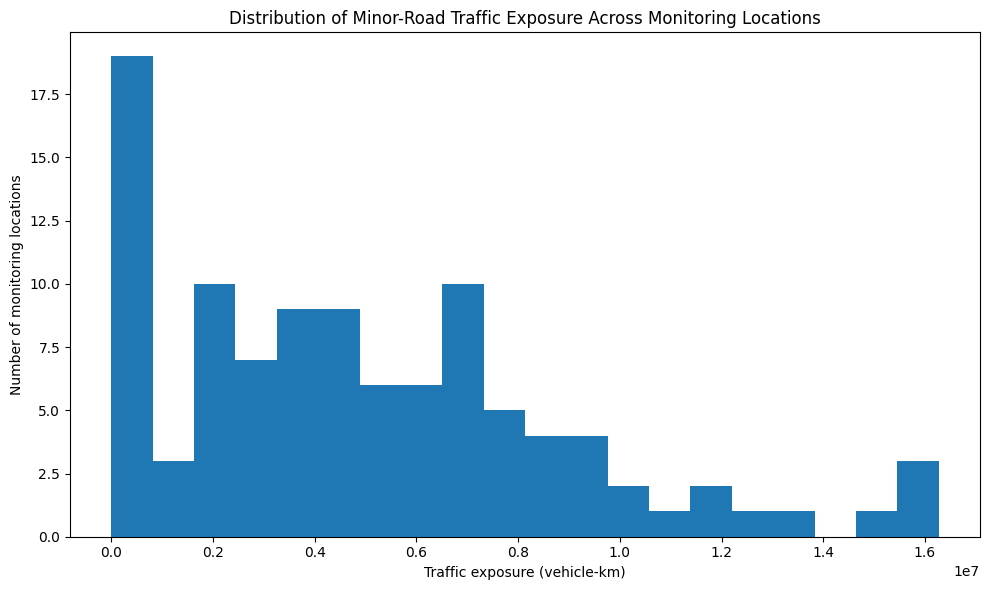

In [74]:
import matplotlib.pyplot as plt

# Summary statistics
print("TRAFFIC EXPOSURE DISTRIBUTION")
print("=" * 70)

print(
    site_traffic_exposure["traffic_exposure_vkm"].describe()
)

print("\nSkewness:")
print(
    site_traffic_exposure["traffic_exposure_vkm"].skew()
)

print("\nKurtosis:")
print(
    site_traffic_exposure["traffic_exposure_vkm"].kurtosis()
)

# Distribution plot
plt.figure(figsize=(10, 6))

plt.hist(
    site_traffic_exposure["traffic_exposure_vkm"],
    bins=20
)

plt.xlabel("Traffic exposure (vehicle-km)")
plt.ylabel("Number of monitoring locations")
plt.title("Distribution of Minor-Road Traffic Exposure Across Monitoring Locations")

plt.tight_layout()
plt.show()

- Minor-road traffic exposure has a mean of approximately **5.00 million vehicle-km** and a median of approximately **4.36 million vehicle-km**.
- The distribution is **moderately right-skewed**, with a skewness of **0.859**.
- The mean being higher than the median reflects the presence of monitoring locations with relatively high traffic exposure.
- The kurtosis of **0.498** does not indicate an extreme heavy-tailed distribution at the site level.
- The distribution provides substantial variation across monitoring locations without requiring immediate transformation.

 Retain the original `traffic_exposure_vkm` variable for the primary exposure analysis. A log-transformed version can be evaluated later if required by the statistical model or if model diagnostics indicate that transformation is appropriate.

## 7.7 Traffic Exposure Groups

Grouping monitoring locations by their observed traffic exposure provides a descriptive way to compare pollutant concentrations across relatively low- and high-traffic environments. These groups will be used for exploratory analysis and later hypothesis testing, while the continuous traffic variable will remain available for regression analysis.

In [75]:
# Create quartile-based traffic exposure groups

site_traffic_exposure["traffic_exposure_group"] = pd.qcut(
    site_traffic_exposure["traffic_exposure_vkm"],
    q=4,
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

print("TRAFFIC EXPOSURE GROUPS")
print("=" * 70)

print(
    site_traffic_exposure[
        "traffic_exposure_group"
    ].value_counts().sort_index()
)

print("\nExposure range by group:")

display(
    site_traffic_exposure
    .groupby("traffic_exposure_group", observed=True)
    ["traffic_exposure_vkm"]
    .agg(
        count="count",
        minimum="min",
        median="median",
        maximum="max"
    )
)

TRAFFIC EXPOSURE GROUPS
traffic_exposure_group
Low          26
Moderate     26
High         25
Very High    26
Name: count, dtype: int64

Exposure range by group:


,count,minimum,median,maximum
traffic_exposure_group,,,,
Low,26,0.000000e+00,6.490688e+04,2.028573e+06
Moderate,26,2.092371e+06,3.282272e+06,4.363836e+06
High,25,4.679857e+06,5.809332e+06,7.100621e+06
Very High,26,7.309335e+06,9.112383e+06,1.626977e+07


- The 103 monitoring locations were divided into four approximately equal traffic-exposure groups.
- The groups contain **26 Low, 26 Moderate, 25 High, and 26 Very High exposure locations**.
- The Low-exposure group ranges from **0 to approximately 2.03 million vehicle-km**.
- The Moderate group ranges from approximately **2.09 to 4.36 million vehicle-km**.
- The High group ranges from approximately **4.68 to 7.10 million vehicle-km**.
- The Very High group ranges from approximately **7.31 to 16.27 million vehicle-km**.
- The clear separation between groups provides a useful basis for comparing pollutant concentrations across different levels of traffic exposure.

Retain the four quartile-based exposure groups for descriptive and group-comparison analysis, while retaining `traffic_exposure_vkm` as the continuous exposure variable for correlation and regression analysis.

## 7.8 Traffic Exposure–Air Quality Integration

Traffic exposure is defined at the monitoring-location level, while pollutant measurements are recorded hourly. We therefore need to propagate the site-level traffic exposure to each valid air-quality observation using the monitoring site's spatial coordinates.

The integration will be validated before the resulting dataset is used for statistical analysis.

In [76]:
# Validate that every air-quality deployment can be linked
# to exactly one physical monitoring location

air_quality_locations = (
    air_quality[
        ["pod_id_location", "location_name", "latitude", "longitude"]
    ]
    .drop_duplicates()
)

traffic_location_keys = (
    site_traffic_exposure[
        ["location_name", "x_coord", "y_coord"]
    ]
    .drop_duplicates()
)

print("AIR-QUALITY / TRAFFIC LOCATION LINKAGE")
print("=" * 70)

print(
    "Unique air-quality deployment locations:",
    air_quality_locations["pod_id_location"].nunique()
)

print(
    "Unique physical traffic locations:",
    len(site_traffic_exposure)
)

print(
    "Unique air-quality coordinate pairs:",
    air_quality_locations[
        ["latitude", "longitude"]
    ].drop_duplicates().shape[0]
)

print(
    "Unique traffic coordinate pairs:",
    site_traffic_exposure[
        ["x_coord", "y_coord"]
    ].drop_duplicates().shape[0]
)

print("\nAir-quality deployment records:")
print(len(air_quality_locations))

print("\nTraffic location records:")
print(len(site_traffic_exposure))

AIR-QUALITY / TRAFFIC LOCATION LINKAGE
Unique air-quality deployment locations: 106
Unique physical traffic locations: 103
Unique air-quality coordinate pairs: 103
Unique traffic coordinate pairs: 103

Air-quality deployment records:
106

Traffic location records:
103


- The air-quality dataset contains **106 deployment locations**, corresponding to **103 unique physical coordinate locations**.
- The traffic exposure table also contains **103 unique physical coordinate locations**.
- The air-quality and traffic datasets therefore have matching spatial coverage at the physical-location level.
- The difference between deployment locations and physical locations reflects repeated deployments at some locations rather than a spatial mismatch.
- This confirms that traffic exposure can be transferred from the site-level exposure table to the air-quality observations using the monitoring-location coordinates.

 Proceed with coordinate-based integration of the site-level traffic exposure into the hourly air-quality observations. The merge will be validated for unmatched records and unintended row duplication.

## 7.9 Integrating Traffic Exposure with Air Quality

The traffic exposure was calculated for each physical monitoring location. We now transfer that exposure to the corresponding hourly air-quality observations using spatial coordinates.

The merge must preserve the number of air-quality observations and must not create duplicate rows.

In [77]:
# ---------------------------------------------------------
# 1. Build a unique deployment-to-coordinate lookup
# ---------------------------------------------------------

deployment_coordinates = (
    metadata[
        [
            "pod_id_location",
            "x_coord",
            "y_coord"
        ]
    ]
    .drop_duplicates()
)

print("Deployment coordinate lookup")
print("=" * 70)
print("Rows:", len(deployment_coordinates))
print(
    "Unique deployment IDs:",
    deployment_coordinates["pod_id_location"].nunique()
)

# ---------------------------------------------------------
# 2. Check that each deployment has one coordinate pair
# ---------------------------------------------------------

coordinate_counts = (
    deployment_coordinates
    .groupby("pod_id_location")
    .agg(
        x_values=("x_coord", "nunique"),
        y_values=("y_coord", "nunique")
    )
)

print("\nDeployments with multiple coordinate values:")

display(
    coordinate_counts[
        (coordinate_counts["x_values"] > 1) |
        (coordinate_counts["y_values"] > 1)
    ]
)

# ---------------------------------------------------------
# 3. Add coordinates to air-quality observations
# ---------------------------------------------------------

air_quality_with_coords = air_quality.merge(
    deployment_coordinates,
    on="pod_id_location",
    how="left",
    validate="many_to_one"
)

print("\nAir-quality observations after coordinate lookup:")
print(air_quality_with_coords.shape)

print(
    "Missing x coordinates:",
    air_quality_with_coords["x_coord"].isna().sum()
)

print(
    "Missing y coordinates:",
    air_quality_with_coords["y_coord"].isna().sum()
)

# ---------------------------------------------------------
# 4. Merge site-level traffic exposure
# ---------------------------------------------------------

air_quality_traffic = air_quality_with_coords.merge(
    site_traffic_exposure[
        [
            "x_coord",
            "y_coord",
            "nearest_grid_id",
            "nearest_grid_distance_m",
            "traffic_exposure_vkm",
            "traffic_exposure_group"
        ]
    ],
    on=["x_coord", "y_coord"],
    how="left",
    validate="many_to_one"
)

# ---------------------------------------------------------
# 5. Validate the final integration
# ---------------------------------------------------------

print("\nFINAL AIR-QUALITY / TRAFFIC INTEGRATION")
print("=" * 70)

print("Original air-quality rows:", len(air_quality))
print("Integrated rows:", len(air_quality_traffic))

print(
    "Rows changed:",
    len(air_quality_traffic) - len(air_quality)
)

print(
    "\nMissing traffic exposure:",
    air_quality_traffic["traffic_exposure_vkm"].isna().sum()
)

print(
    "Missing traffic groups:",
    air_quality_traffic["traffic_exposure_group"].isna().sum()
)

print(
    "Unique deployment locations:",
    air_quality_traffic["pod_id_location"].nunique()
)

print(
    "Unique physical locations:",
    air_quality_traffic[
        ["x_coord", "y_coord"]
    ].drop_duplicates().shape[0]
)

Deployment coordinate lookup
Rows: 106
Unique deployment IDs: 106

Deployments with multiple coordinate values:


,x_values,y_values
pod_id_location,,



Air-quality observations after coordinate lookup:
(757357, 12)
Missing x coordinates: 0
Missing y coordinates: 0

FINAL AIR-QUALITY / TRAFFIC INTEGRATION
Original air-quality rows: 757357
Integrated rows: 757357
Rows changed: 0

Missing traffic exposure: 0
Missing traffic groups: 0
Unique deployment locations: 106
Unique physical locations: 103


## 7.10 Site-Level Traffic and Pollution Analysis

Hourly observations are repeatedly collected from the same monitoring locations. To avoid treating repeated measurements as independent spatial observations, we first aggregate pollutant concentrations to the physical monitoring-location level.

This site-level dataset will be used to examine spatial relationships between traffic exposure and typical pollutant concentrations.

In [78]:
# ---------------------------------------------------------
# Create site-level pollution and traffic summary
# ---------------------------------------------------------

site_pollution_traffic = (
    air_quality_traffic
    .groupby(
        ["location_name", "x_coord", "y_coord"],
        as_index=False
    )
    .agg(
        mean_pm2_5=("pm2_5_ugm3", "mean"),
        median_pm2_5=("pm2_5_ugm3", "median"),
        mean_no2=("no2_ugm3", "mean"),
        median_no2=("no2_ugm3", "median"),
        observations=("date_utc", "count")
    )
)

# ---------------------------------------------------------
# Add site-level traffic exposure information
# ---------------------------------------------------------

site_pollution_traffic = site_pollution_traffic.merge(
    site_traffic_exposure[
        [
            "location_name",
            "x_coord",
            "y_coord",
            "traffic_exposure_vkm",
            "traffic_exposure_group",
            "nearest_grid_distance_m"
        ]
    ],
    on=["location_name", "x_coord", "y_coord"],
    how="left",
    validate="one_to_one"
)

# ---------------------------------------------------------
# Validate
# ---------------------------------------------------------

print("SITE-LEVEL POLLUTION / TRAFFIC DATASET")
print("=" * 70)

print("Rows:", len(site_pollution_traffic))
print("Columns:", len(site_pollution_traffic.columns))

print("\nMissing values:")
display(
    site_pollution_traffic.isna().sum()
)

print("\nFirst 10 records:")
display(
    site_pollution_traffic.head(10)
)

SITE-LEVEL POLLUTION / TRAFFIC DATASET
Rows: 103
Columns: 11

Missing values:


,0
location_name,0
x_coord,0
y_coord,0
mean_pm2_5,23
median_pm2_5,23
mean_no2,5
median_no2,5
observations,0
traffic_exposure_vkm,0
traffic_exposure_group,0



First 10 records:


,location_name,x_coord,y_coord,mean_pm2_5,median_pm2_5,mean_no2,median_no2,observations,traffic_exposure_vkm,traffic_exposure_group,nearest_grid_distance_m
0,Albert Street,528859.417225,183562.442085,11.788691,7.390,34.696106,30.905,9844,2.296369e+06,Moderate,364.800981
1,Ballance Road,536276.330446,184793.615220,13.022789,9.080,39.911238,33.745,8486,2.948919e+06,Moderate,369.104276
2,Bank Junction,532723.974216,181095.315152,NaN,NaN,69.939340,66.230,4824,4.570710e+03,Low,462.530297
3,Beaumont Grove,535626.943910,182039.130198,11.289557,6.990,37.414164,31.980,9538,1.626977e+07,Very High,478.033190
4,Beckenham Lane,539603.268287,169496.441262,13.360021,11.945,NaN,NaN,3300,3.630248e+06,Moderate,103.329588
5,Black Horse Court,532799.239664,179229.105928,12.448080,7.970,34.817314,29.750,8145,1.518268e+05,Low,403.643376
6,Blackfriars Road,531657.830173,180212.825439,12.778958,7.920,33.516236,28.330,9877,6.490688e+04,Low,327.688254
7,Blomfontein Road,522540.618834,180934.599963,10.434304,6.600,38.073117,31.920,9144,7.697298e+06,Very High,436.494006
8,Bonington Road,553472.649180,185152.472175,12.053158,6.880,24.796606,22.140,9376,1.977338e+06,Low,348.602433
9,Borough High Street,532747.542696,180309.973221,11.049912,8.310,46.635790,42.570,5338,4.706765e+06,High,312.069805


## 7.11 Traffic Exposure vs Pollutant Concentration

We now have a traffic-exposure measure and site-level pollutant summaries for the same physical monitoring locations. We will examine whether higher traffic exposure is associated with higher typical PM2.5 or NO₂ concentrations.

Both Pearson and Spearman correlations are calculated because the variables do not all follow normal distributions.

In [79]:
from scipy.stats import pearsonr, spearmanr

print("TRAFFIC EXPOSURE VS POLLUTANT CONCENTRATION")
print("=" * 70)

# ---------------------------------------------------------
# PM2.5 analysis
# ---------------------------------------------------------

pm25_analysis = (
    site_pollution_traffic[
        [
            "traffic_exposure_vkm",
            "mean_pm2_5"
        ]
    ]
    .dropna()
)

pm25_pearson_r, pm25_pearson_p = pearsonr(
    pm25_analysis["traffic_exposure_vkm"],
    pm25_analysis["mean_pm2_5"]
)

pm25_spearman_rho, pm25_spearman_p = spearmanr(
    pm25_analysis["traffic_exposure_vkm"],
    pm25_analysis["mean_pm2_5"]
)

# ---------------------------------------------------------
# NO2 analysis
# ---------------------------------------------------------

no2_analysis = (
    site_pollution_traffic[
        [
            "traffic_exposure_vkm",
            "mean_no2"
        ]
    ]
    .dropna()
)

no2_pearson_r, no2_pearson_p = pearsonr(
    no2_analysis["traffic_exposure_vkm"],
    no2_analysis["mean_no2"]
)

no2_spearman_rho, no2_spearman_p = spearmanr(
    no2_analysis["traffic_exposure_vkm"],
    no2_analysis["mean_no2"]
)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("\nPM2.5")
print("-" * 40)
print("Valid monitoring locations:", len(pm25_analysis))
print("Pearson r:", round(pm25_pearson_r, 4))
print("Pearson p-value:", pm25_pearson_p)
print("Spearman rho:", round(pm25_spearman_rho, 4))
print("Spearman p-value:", pm25_spearman_p)

print("\nNO₂")
print("-" * 40)
print("Valid monitoring locations:", len(no2_analysis))
print("Pearson r:", round(no2_pearson_r, 4))
print("Pearson p-value:", no2_pearson_p)
print("Spearman rho:", round(no2_spearman_rho, 4))
print("Spearman p-value:", no2_spearman_p)

TRAFFIC EXPOSURE VS POLLUTANT CONCENTRATION

PM2.5
----------------------------------------
Valid monitoring locations: 80
Pearson r: -0.0691
Pearson p-value: 0.5423793363646789
Spearman rho: -0.1616
Spearman p-value: 0.1521464484772938

NO₂
----------------------------------------
Valid monitoring locations: 98
Pearson r: -0.1696
Pearson p-value: 0.09503585404573969
Spearman rho: -0.1255
Spearman p-value: 0.2181847227785133


- At the monitoring-location level, the association between minor-road traffic exposure and mean PM2.5 was weak and negative:
  - Pearson r = **-0.069**
  - Spearman ρ = **-0.162**
- Neither PM2.5 correlation was statistically significant at the 0.05 level.
- For NO₂, both correlations were also negative:
  - Pearson r = **-0.170**
  - Spearman ρ = **-0.126**
- Neither NO₂ correlation reached the 0.05 significance threshold.
- The results therefore do not provide strong evidence of a simple bivariate association between the assigned minor-road traffic exposure measure and average pollutant concentration across monitoring locations.
- These results do not establish that traffic has no relationship with pollution. Traffic exposure is only one spatial proxy, and the analysis has not yet accounted for road proximity, monitoring-site type, meteorological conditions, temporal variation, or other spatial factors.
- The analysis also uses **2022 traffic activity as a spatial proxy for air-quality observations from 2018–2019**, which limits direct temporal interpretation.

Do not reject the traffic-pollution research questions based on these correlations alone. Proceed to visual diagnostics and multivariable analysis to determine whether relationships become clearer after accounting for other relevant factors.

## 7.12 Traffic Exposure vs Pollutant Concentration: Scatterplots

Correlation coefficients summarize the strength of an association but do not reveal its shape or whether individual monitoring locations are strongly influencing the result. Scatterplots allow us to visually assess the relationship and identify potential influential observations.

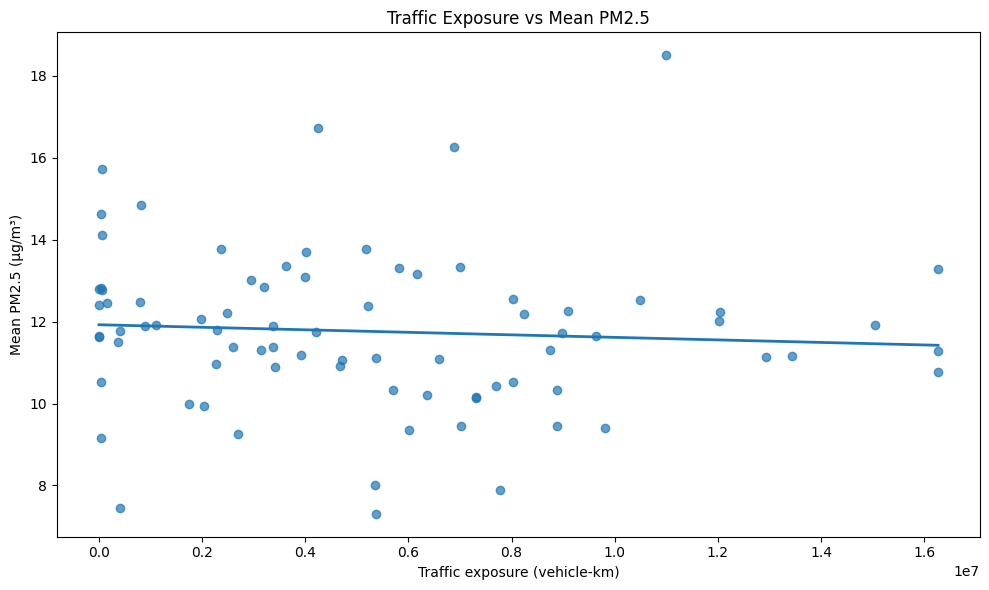

In [80]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.scatter(
    pm25_analysis["traffic_exposure_vkm"],
    pm25_analysis["mean_pm2_5"],
    alpha=0.7
)

# Linear trend line
z = np.polyfit(
    pm25_analysis["traffic_exposure_vkm"],
    pm25_analysis["mean_pm2_5"],
    1
)

x_line = np.linspace(
    pm25_analysis["traffic_exposure_vkm"].min(),
    pm25_analysis["traffic_exposure_vkm"].max(),
    100
)

y_line = z[0] * x_line + z[1]

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel("Traffic exposure (vehicle-km)")
plt.ylabel("Mean PM2.5 (µg/m³)")
plt.title("Traffic Exposure vs Mean PM2.5")

plt.tight_layout()
plt.show()

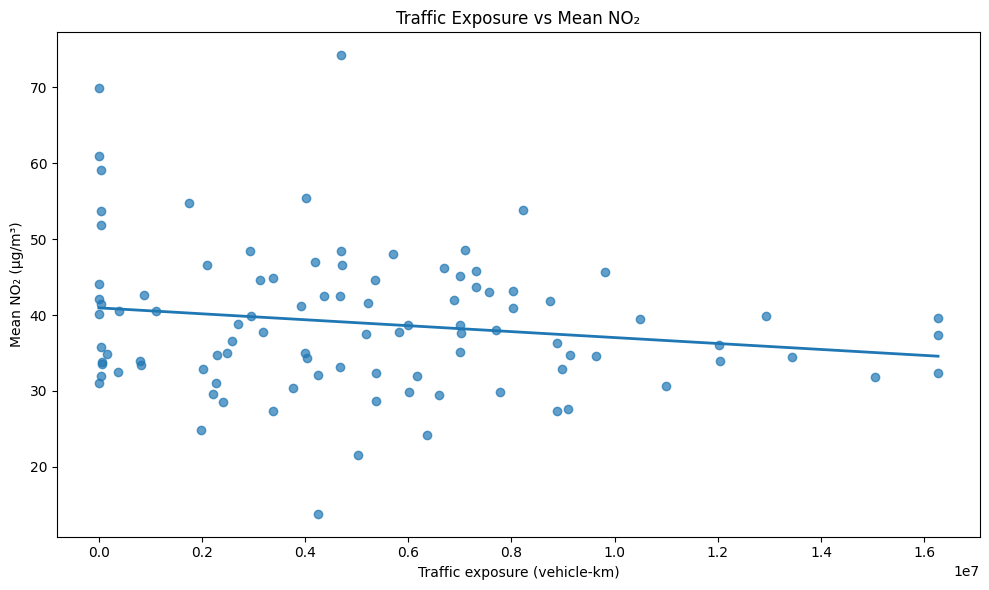

In [81]:
plt.figure(figsize=(10, 6))

plt.scatter(
    no2_analysis["traffic_exposure_vkm"],
    no2_analysis["mean_no2"],
    alpha=0.7
)

# Linear trend line
z = np.polyfit(
    no2_analysis["traffic_exposure_vkm"],
    no2_analysis["mean_no2"],
    1
)

x_line = np.linspace(
    no2_analysis["traffic_exposure_vkm"].min(),
    no2_analysis["traffic_exposure_vkm"].max(),
    100
)

y_line = z[0] * x_line + z[1]

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel("Traffic exposure (vehicle-km)")
plt.ylabel("Mean NO₂ (µg/m³)")
plt.title("Traffic Exposure vs Mean NO₂")

plt.tight_layout()
plt.show()

- The PM2.5 scatterplot shows substantial variation in pollutant concentration across the range of traffic exposure, with an almost flat fitted trend.
- This visual pattern is consistent with the weak Pearson correlation observed previously (r = **-0.069**).
- The NO₂ scatterplot shows a modest downward fitted trend, but observations remain widely dispersed across traffic-exposure levels.
- This is consistent with the weak Pearson correlation for NO₂ (r = **-0.170**).
- The scatterplots therefore do not indicate a strong simple linear relationship between the assigned minor-road traffic exposure and either pollutant.
- These results should not be interpreted causally because the traffic exposure is based on **2022 traffic activity**, whereas the air-quality observations are from **2018–2019**, and the traffic exposure is aggregated to 1 km² grids.
- Other factors, including road proximity, monitoring-site type, meteorology and temporal variation, may influence pollutant concentrations.

**Decision:** Retain traffic exposure as an explanatory variable, but do not treat it as a sufficient standalone predictor of pollutant concentration. Continue with exposure-group comparisons and multivariable analysis.

## 7.13 Pollutant Concentrations Across Traffic-Exposure Groups

A continuous correlation may miss differences between broader exposure levels. We therefore compare pollutant concentrations across the four traffic-exposure groups to determine whether low- and high-exposure locations show different pollutant distributions.

In [82]:
# ---------------------------------------------------------
# PM2.5 by traffic-exposure group
# ---------------------------------------------------------

pm25_group_summary = (
    site_pollution_traffic
    .dropna(subset=["mean_pm2_5"])
    .groupby("traffic_exposure_group", observed=True)
    ["mean_pm2_5"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

# ---------------------------------------------------------
# NO2 by traffic-exposure group
# ---------------------------------------------------------

no2_group_summary = (
    site_pollution_traffic
    .dropna(subset=["mean_no2"])
    .groupby("traffic_exposure_group", observed=True)
    ["mean_no2"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

print("PM2.5 BY TRAFFIC-EXPOSURE GROUP")
print("=" * 70)
display(pm25_group_summary)

print("\nNO₂ BY TRAFFIC-EXPOSURE GROUP")
print("=" * 70)
display(no2_group_summary)

PM2.5 BY TRAFFIC-EXPOSURE GROUP


,traffic_exposure_group,count,mean,median,std,minimum,maximum
0,Low,22,12.024311,11.978999,1.898003,7.450697,15.734818
1,Moderate,18,12.249474,11.839538,1.606805,9.261898,16.717547
2,High,16,11.318081,11.069914,2.309268,7.308557,16.270331
3,Very High,24,11.451790,11.303659,1.934720,7.879530,18.499533



NO₂ BY TRAFFIC-EXPOSURE GROUP


,traffic_exposure_group,count,mean,median,std,minimum,maximum
0,Low,24,41.680992,40.323618,11.215815,24.796606,69.939340
1,Moderate,23,37.194285,36.604675,8.844374,13.831050,55.412862
2,High,25,39.386501,38.661611,10.520813,21.609629,74.193791
3,Very High,26,37.505276,36.859037,6.231722,27.416475,53.794106


- Mean PM2.5 concentrations were **12.02, 12.25, 11.32 and 11.45 µg/m³** across the Low, Moderate, High and Very High traffic-exposure groups, respectively.
- Mean NO₂ concentrations were **41.68, 37.19, 39.39 and 37.51 µg/m³**, respectively.
- Neither pollutant shows a monotonic increase across the traffic-exposure groups.
- The PM2.5 group means are relatively close, whereas NO₂ shows greater differences between groups.
- However, descriptive differences alone cannot determine whether the observed variation is statistically meaningful.

Use the Kruskal-Wallis test as the initial omnibus test for differences in pollutant concentrations across traffic-exposure groups.

## 7.14 Kruskal-Wallis Test

The exposure groups contain independent monitoring locations, while pollutant concentrations are not normally distributed. The Kruskal-Wallis test provides a non-parametric omnibus test of whether pollutant distributions differ across the four traffic-exposure groups.

In [83]:
from scipy.stats import kruskal

print("KRUSKAL-WALLIS TEST")
print("=" * 70)

# ---------------------------------------------------------
# PM2.5
# ---------------------------------------------------------

pm25_groups = [
    group["mean_pm2_5"].dropna().values
    for _, group in site_pollution_traffic.groupby(
        "traffic_exposure_group",
        observed=True
    )
]

pm25_kw_stat, pm25_kw_p = kruskal(*pm25_groups)

# ---------------------------------------------------------
# NO2
# ---------------------------------------------------------

no2_groups = [
    group["mean_no2"].dropna().values
    for _, group in site_pollution_traffic.groupby(
        "traffic_exposure_group",
        observed=True
    )
]

no2_kw_stat, no2_kw_p = kruskal(*no2_groups)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("\nPM2.5")
print("-" * 40)
print("Kruskal-Wallis H:", round(pm25_kw_stat, 4))
print("p-value:", pm25_kw_p)

print("\nNO₂")
print("-" * 40)
print("Kruskal-Wallis H:", round(no2_kw_stat, 4))
print("p-value:", no2_kw_p)

KRUSKAL-WALLIS TEST

PM2.5
----------------------------------------
Kruskal-Wallis H: 4.6648
p-value: 0.19805448723643015

NO₂
----------------------------------------
Kruskal-Wallis H: 1.5133
p-value: 0.6792049284204353


- The Kruskal-Wallis test did not identify a statistically significant difference in mean site-level PM2.5 across the four traffic-exposure groups (H = **4.665**, p = **0.198**).
- The Kruskal-Wallis test also did not identify a statistically significant difference in mean site-level NO₂ across the four traffic-exposure groups (H = **1.513**, p = **0.679**).
- Both p-values are greater than the conventional 0.05 significance level.
- Therefore, the null hypothesis of equal pollutant distributions across the traffic-exposure groups is not rejected for either pollutant.
- This result is consistent with the absence of a clear monotonic pattern in the group means.
- The result does not demonstrate that traffic has no effect on air pollution. It indicates that this particular 2022 minor-road traffic exposure proxy did not reveal statistically significant differences in pollutant concentrations across the four spatial exposure groups.

**Decision:** Do not perform post-hoc pairwise comparisons because neither omnibus test provided sufficient evidence of an overall group difference. Retain the continuous traffic exposure variable for subsequent multivariable analysis.

## 7.15 Traffic Exposure vs Road Proximity

Traffic exposure and distance from the nearest road represent different spatial characteristics. Examining their relationship helps determine whether the traffic exposure proxy overlaps strongly with road proximity or captures a separate dimension of the monitoring environment.

In [84]:






from scipy.stats import pearsonr, spearmanr

# ---------------------------------------------------------
# Build site-level traffic / road-distance dataset
# ---------------------------------------------------------

traffic_distance = (
    metadata[
        [
            "location_name",
            "x_coord",
            "y_coord",
            "distance_from_road"
        ]
    ]
    .drop_duplicates(
        subset=["location_name", "x_coord", "y_coord"]
    )
    .merge(
        site_traffic_exposure[
            [
                "location_name",
                "x_coord",
                "y_coord",
                "traffic_exposure_vkm"
            ]
        ],
        on=["location_name", "x_coord", "y_coord"],
        how="inner",
        validate="one_to_one"
    )
    .dropna(
        subset=[
            "distance_from_road",
            "traffic_exposure_vkm"
        ]
    )
)

# ---------------------------------------------------------
# Correlations
# ---------------------------------------------------------

pearson_r, pearson_p = pearsonr(
    traffic_distance["traffic_exposure_vkm"],
    traffic_distance["distance_from_road"]
)

spearman_rho, spearman_p = spearmanr(
    traffic_distance["traffic_exposure_vkm"],
    traffic_distance["distance_from_road"]
)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("TRAFFIC EXPOSURE VS ROAD DISTANCE")
print("=" * 70)

print(
    "Valid monitoring locations:",
    len(traffic_distance)
)

print("\nPearson correlation")
print("-" * 40)
print("r:", round(pearson_r, 4))
print("p-value:", pearson_p)

print("\nSpearman correlation")
print("-" * 40)
print("rho:", round(spearman_rho, 4))
print("p-value:", spearman_p)

TRAFFIC EXPOSURE VS ROAD DISTANCE
Valid monitoring locations: 97

Pearson correlation
----------------------------------------
r: -0.0983
p-value: 0.33811994625200475

Spearman correlation
----------------------------------------
rho: 0.0621
p-value: 0.5453696868509736


- The relationship between minor-road traffic exposure and road distance was weak.
- Pearson correlation was **r = -0.098** (p = **0.338**).
- Spearman correlation was **ρ = 0.062** (p = **0.545**).
- Neither correlation was statistically significant at the 0.05 level.
- The results indicate little evidence of a monotonic or linear relationship between the assigned traffic exposure and distance from the nearest road across the 97 locations with complete data.
- Therefore, traffic exposure and road proximity appear to capture different spatial characteristics of the monitoring environment rather than being interchangeable measures.

**Decision:** Retain both `traffic_exposure_vkm` and `distance_from_road` as candidate explanatory variables for later multivariable analysis. Their redundancy will be evaluated formally during feature-selection and model-diagnostics stages rather than removed based on this correlation alone.

## 7.16 Traffic Exposure by Monitoring-Site Type

Monitoring-site type describes the environmental setting in which pollution was measured. Comparing traffic exposure across site types helps determine whether traffic exposure is distributed differently between roadside, kerbside and urban-background environments.

In [85]:
# ---------------------------------------------------------
# Create site-level monitoring-type dataset
# ---------------------------------------------------------

site_types = (
    metadata[
        [
            "location_name",
            "x_coord",
            "y_coord",
            "type"
        ]
    ]
    .drop_duplicates(
        subset=["location_name", "x_coord", "y_coord"]
    )
)

site_type_traffic = site_traffic_exposure.merge(
    site_types,
    on=["location_name", "x_coord", "y_coord"],
    how="left",
    validate="one_to_one"
)

print("TRAFFIC EXPOSURE BY MONITORING-SITE TYPE")
print("=" * 70)

print(
    "Missing monitoring types:",
    site_type_traffic["type"].isna().sum()
)

print("\nExposure summary by site type:")

display(
    site_type_traffic
    .groupby("type", observed=True)
    ["traffic_exposure_vkm"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
)

TRAFFIC EXPOSURE BY MONITORING-SITE TYPE
Missing monitoring types: 0

Exposure summary by site type:


,count,mean,median,std,minimum,maximum
type,,,,,,
Kerbside,30,3.523472e+06,3.058853e+06,3.108201e+06,4570.709680,9.816525e+06
Roadside,35,5.701876e+06,5.014575e+06,3.742202e+06,33095.400673,1.626977e+07
Urban Background,38,5.507561e+06,4.928090e+06,4.655667e+06,0.000000,1.626977e+07


- Traffic exposure varied across the three monitoring-site types.
- Kerbside locations had a mean traffic exposure of approximately **3.52 million vehicle-km**.
- Roadside locations had a mean of approximately **5.70 million vehicle-km**.
- Urban Background locations had a mean of approximately **5.51 million vehicle-km**.
- The substantial standard deviations indicate considerable variation in traffic exposure within each site type.
- Therefore, monitoring-site type and traffic exposure should not be treated as interchangeable variables.
- These descriptive results do not establish whether the observed differences between site types are statistically significant.

 Retain both monitoring-site type and continuous traffic exposure as candidate explanatory variables. Their independent contributions will be evaluated later using multivariable statistical models.

## 7.17 Environmental and Meteorological Variables

Pollutant concentrations are influenced by more than traffic and spatial characteristics. Before developing multivariable models, we need to identify which environmental and meteorological variables are actually available in the air-quality dataset and assess their completeness.

In [86]:

# Inspect variables available in the integrated dataset

print("AVAILABLE ENVIRONMENTAL VARIABLES")
print("=" * 70)

print("Integrated dataset shape:")
print(air_quality_traffic.shape)

print("\nAll columns:")
for i, column in enumerate(air_quality_traffic.columns, start=1):
    print(f"{i:>2}. {column}")

print("\nNumeric variables:")
display(
    air_quality_traffic.select_dtypes(
        include="number"
    ).describe().T
)

print("\nMissing values in numeric variables:")
display(
    air_quality_traffic.select_dtypes(
        include="number"
    ).isna().sum().sort_values(
        ascending=False
    )
)

AVAILABLE ENVIRONMENTAL VARIABLES
Integrated dataset shape:
(757357, 16)

All columns:
 1. pod_id_location
 2. pod_id
 3. location_name
 4. latitude
 5. longitude
 6. date_utc
 7. pm2_5_ugm3
 8. ratification_status_pm2_5
 9. no2_ugm3
10. ratification_status_no2
11. x_coord
12. y_coord
13. nearest_grid_id
14. nearest_grid_distance_m
15. traffic_exposure_vkm
16. traffic_exposure_group

Numeric variables:


,count,mean,std,min,25%,50%,75%,max
pod_id_location,757357.0,7.048796e+04,1.190477e+05,1245.000000,2.824500e+04,5.024500e+04,7.224500e+04,9.824500e+05
pod_id,757357.0,4.856002e+04,2.684700e+04,1245.000000,2.724500e+04,4.824500e+04,7.024500e+04,1.002450e+05
latitude,757357.0,5.151358e+01,4.938110e-02,51.362842,5.148186e+01,5.151407e+01,5.154560e+01,5.167375e+01
longitude,757357.0,-1.206939e-01,1.148753e-01,-0.413580,-1.924100e-01,-1.140980e-01,-6.182300e-02,2.118200e-01
pm2_5_ugm3,570083.0,1.192529e+01,1.212310e+01,0.140000,5.470000e+00,7.740000e+00,1.306000e+01,3.329000e+02
no2_ugm3,655262.0,3.945162e+01,2.176522e+01,1.120000,2.503000e+01,3.342000e+01,4.797000e+01,5.839400e+02
x_coord,757357.0,5.305020e+05,7.937003e+03,510034.426057,5.256294e+05,5.310225e+05,5.345452e+05,5.534726e+05
y_coord,757357.0,1.810853e+05,5.545439e+03,164183.275347,1.777552e+05,1.810657e+05,1.849436e+05,1.990423e+05
nearest_grid_id,757357.0,2.795304e+03,6.844560e+02,651.000000,2.495000e+03,2.967000e+03,3.311000e+03,3.456000e+03
nearest_grid_distance_m,757357.0,4.081272e+02,1.317406e+02,33.843241,3.346087e+02,4.189423e+02,5.021886e+02,6.660139e+02



Missing values in numeric variables:


,0
pm2_5_ugm3,187274
no2_ugm3,102095
pod_id_location,0
latitude,0
pod_id,0
longitude,0
x_coord,0
y_coord,0
nearest_grid_id,0
nearest_grid_distance_m,0




- The integrated dataset contains **757,357 hourly air-quality observations** and **16 variables**.
- The available variables represent pollutant measurements, monitoring-site identifiers, spatial coordinates, timestamps, and minor-road traffic exposure.
- The dataset does **not** currently contain direct meteorological variables such as temperature, humidity, wind speed, wind direction or precipitation.
- PM2.5 has **187,274 missing observations**, while NO₂ has **102,095 missing observations**, consistent with the missingness identified earlier.
- Spatial traffic exposure and spatial matching distance are complete for all observations.
- Identifier variables such as `pod_id`, `pod_id_location` and `nearest_grid_id` should be treated as identifiers rather than continuous numerical predictors.

 Continue the current analysis using the validated traffic and spatial variables. Meteorological adjustment will only be introduced if a suitable external weather dataset is subsequently integrated. Identifier variables will be excluded from predictive feature matrices.

## 7.18 Temporal Features for Integrated Analysis

Pollutant concentrations vary substantially over time, and traffic-related pollution may also follow daily and weekly patterns. Temporal features allow later statistical and machine-learning models to account for these systematic patterns without using the raw timestamp directly as a predictor.

In [87]:
# ---------------------------------------------------------
# Create temporal features in the integrated dataset
# ---------------------------------------------------------

air_quality_traffic["hour"] = (
    air_quality_traffic["date_utc"].dt.hour
)

air_quality_traffic["day_of_week"] = (
    air_quality_traffic["date_utc"].dt.dayofweek
)

air_quality_traffic["month"] = (
    air_quality_traffic["date_utc"].dt.month
)

air_quality_traffic["day_of_year"] = (
    air_quality_traffic["date_utc"].dt.dayofyear
)

air_quality_traffic["is_weekend"] = (
    air_quality_traffic["day_of_week"] >= 5
).astype(int)

air_quality_traffic["season"] = (
    air_quality_traffic["month"]
    .map({
        12: "Winter",
        1: "Winter",
        2: "Winter",
        3: "Spring",
        4: "Spring",
        5: "Spring",
        6: "Summer",
        7: "Summer",
        8: "Summer",
        9: "Autumn",
        10: "Autumn",
        11: "Autumn"
    })
)

print("TEMPORAL FEATURES ADDED")
print("=" * 70)

print("Dataset shape:")
print(air_quality_traffic.shape)

print("\nTemporal columns:")
print([
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "is_weekend",
    "season"
])

print("\nMissing temporal values:")

display(
    air_quality_traffic[
        [
            "hour",
            "day_of_week",
            "month",
            "day_of_year",
            "is_weekend",
            "season"
        ]
    ].isna().sum()
)

print("\nSeason distribution:")
print(
    air_quality_traffic["season"].value_counts()
)

TEMPORAL FEATURES ADDED
Dataset shape:
(757357, 22)

Temporal columns:
['hour', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'season']

Missing temporal values:


,0
hour,0
day_of_week,0
month,0
day_of_year,0
is_weekend,0
season,0



Season distribution:
season
Autumn    234336
Summer    199222
Spring    186519
Winter    137280
Name: count, dtype: int64


The temporal feature engineering step was successful. The integrated dataset now contains six temporal variables: hour, day of week, month, day of year, weekend status and season.

No missing values were introduced. The observations are distributed across all four seasons, with the highest number occurring in autumn and the lowest in winter. Because the study period covers September 2018 to November 2019 rather than complete calendar years, the seasonal counts are not expected to be equal.

These variables will be retained for subsequent statistical analysis and predictive modelling to account for temporal variation in pollutant concentrations.

# Chapter 8: Statistical Analysis & Hypothesis Testing

## 8.1 Statistical Analysis Strategy

The exploratory analysis identified potential relationships between traffic exposure, road proximity and pollutant concentrations. Statistical testing is now used to determine whether the observed relationships provide sufficient evidence against the corresponding null hypotheses.

Because the air-quality dataset contains repeated hourly observations from the same monitoring locations, site-level summaries will be used for the primary association tests to avoid treating thousands of repeated measurements as independent observations.

The analysis will examine:
1. Traffic exposure and PM2.5.
2. Traffic exposure and NO₂.
3. Road distance and PM2.5.
4. Road distance and NO₂.
5. Differences in pollutant concentrations across traffic-exposure groups.

Statistical significance will be assessed at α = 0.05, while effect size and direction will also be considered. Statistical significance alone will not be interpreted as evidence of causality.



## 8.2 Prepare the Site-Level Statistical Dataset

We already created site_pollution_traffic, but before testing anything, let's inspect exactly what is available and make sure we have one row per physical monitoring location.

In [88]:
# ---------------------------------------------------------
# Prepare site-level dataset for statistical analysis
# ---------------------------------------------------------

print("SITE-LEVEL STATISTICAL DATASET")
print("=" * 70)

print("Shape:", site_pollution_traffic.shape)

print("\nColumns:")
print(site_pollution_traffic.columns.tolist())

print("\nUnique physical locations:")
print(site_pollution_traffic[["x_coord", "y_coord"]].drop_duplicates().shape[0])

print("\nMissing values:")
display(
    site_pollution_traffic[
        ["mean_pm2_5", "mean_no2",
         "traffic_exposure_vkm",
         "nearest_grid_distance_m"]
    ].isna().sum()
)

print("\nFirst five rows:")
display(site_pollution_traffic.head())

SITE-LEVEL STATISTICAL DATASET
Shape: (103, 11)

Columns:
['location_name', 'x_coord', 'y_coord', 'mean_pm2_5', 'median_pm2_5', 'mean_no2', 'median_no2', 'observations', 'traffic_exposure_vkm', 'traffic_exposure_group', 'nearest_grid_distance_m']

Unique physical locations:
103

Missing values:


,0
mean_pm2_5,23
mean_no2,5
traffic_exposure_vkm,0
nearest_grid_distance_m,0



First five rows:


,location_name,x_coord,y_coord,mean_pm2_5,median_pm2_5,mean_no2,median_no2,observations,traffic_exposure_vkm,traffic_exposure_group,nearest_grid_distance_m
0,Albert Street,528859.417225,183562.442085,11.788691,7.390,34.696106,30.905,9844,2.296369e+06,Moderate,364.800981
1,Ballance Road,536276.330446,184793.615220,13.022789,9.080,39.911238,33.745,8486,2.948919e+06,Moderate,369.104276
2,Bank Junction,532723.974216,181095.315152,NaN,NaN,69.939340,66.230,4824,4.570710e+03,Low,462.530297
3,Beaumont Grove,535626.943910,182039.130198,11.289557,6.990,37.414164,31.980,9538,1.626977e+07,Very High,478.033190
4,Beckenham Lane,539603.268287,169496.441262,13.360021,11.945,NaN,NaN,3300,3.630248e+06,Moderate,103.329588



The site-level statistical dataset contains 103 unique physical monitoring locations, confirming that repeated observations have been aggregated to the spatial level before primary hypothesis testing.

Traffic exposure and nearest-grid distance are complete across all locations. Mean PM2.5 is available for 80 locations, while mean NO₂ is available for 98 locations.

Missing pollutant summaries will not be imputed for hypothesis testing. Instead, each statistical analysis will use complete cases for the variables required by that specific test.

The continuous traffic-exposure variable will be used for association analysis, while traffic-exposure groups will be reserved for group-comparison analysis.

## 8.3 H1: Traffic Exposure and NO₂

Our first hypothesis is:

H0: There is no association between traffic exposure and NO₂ concentration.

H1: There is an association between traffic exposure and NO₂ concentration.

We already saw a weak negative relationship in EDA, but that was descriptive. Now we formally test it.



Because we have only 98 independent physical locations and NO₂ is not normally distributed, we should calculate both Pearson and Spearman correlations.



Pearson measures a linear association.

Spearman measures a monotonic association and is less sensitive to extreme values.

In [89]:
# ---------------------------------------------------------
# H1: Traffic exposure and NO2
# ---------------------------------------------------------

from scipy.stats import pearsonr, spearmanr

h1_data = site_pollution_traffic[
    ["traffic_exposure_vkm", "mean_no2"]
].dropna()

pearson_r, pearson_p = pearsonr(
    h1_data["traffic_exposure_vkm"],
    h1_data["mean_no2"]
)

spearman_rho, spearman_p = spearmanr(
    h1_data["traffic_exposure_vkm"],
    h1_data["mean_no2"]
)

print("H1: TRAFFIC EXPOSURE AND NO2")
print("=" * 70)

print("Complete cases:", len(h1_data))

print("\nPearson correlation:")
print(f"r = {pearson_r:.4f}")
print(f"p-value = {pearson_p:.6f}")

print("\nSpearman correlation:")
print(f"rho = {spearman_rho:.4f}")
print(f"p-value = {spearman_p:.6f}")

print("\nDecision at alpha = 0.05:")

if pearson_p < 0.05:
    print("Pearson: Reject H0")
else:
    print("Pearson: Fail to reject H0")

if spearman_p < 0.05:
    print("Spearman: Reject H0")
else:
    print("Spearman: Fail to reject H0")

H1: TRAFFIC EXPOSURE AND NO2
Complete cases: 98

Pearson correlation:
r = -0.1696
p-value = 0.095036

Spearman correlation:
rho = -0.1255
p-value = 0.218185

Decision at alpha = 0.05:
Pearson: Fail to reject H0
Spearman: Fail to reject H0


Both Pearson and Spearman correlations were negative, indicating a weak inverse association between the constructed traffic-exposure measure and site-level mean NO₂ concentration.

However, neither association was statistically significant at α = 0.05 (Pearson p = 0.0950; Spearman p = 0.2182). Therefore, the null hypothesis was not rejected.

The result does not demonstrate that traffic has no relationship with NO₂. Rather, the available data do not provide sufficient evidence of a statistically significant bivariate association between the 2022 traffic-exposure proxy and 2018–2019 site-level mean NO₂.

The temporal mismatch between the traffic and air-quality datasets, the use of a nearest-grid traffic proxy, and the influence of other environmental and spatial factors are important limitations. Multivariable modelling will therefore be used later to examine whether traffic exposure provides additional predictive information after accounting for other available features.

## 8.4 H2: Traffic Exposure and PM2.5

Now we test the second hypothesis using exactly the same methodology:

H0: There is no association between traffic exposure and PM2.5 concentration.
H1: There is an association between traffic exposure and PM2.5 concentration.

In [90]:
# ---------------------------------------------------------
# H2: Traffic exposure and PM2.5
# ---------------------------------------------------------

h2_data = site_pollution_traffic[
    ["traffic_exposure_vkm", "mean_pm2_5"]
].dropna()

pearson_r, pearson_p = pearsonr(
    h2_data["traffic_exposure_vkm"],
    h2_data["mean_pm2_5"]
)

spearman_rho, spearman_p = spearmanr(
    h2_data["traffic_exposure_vkm"],
    h2_data["mean_pm2_5"]
)

print("H2: TRAFFIC EXPOSURE AND PM2.5")
print("=" * 70)

print("Complete cases:", len(h2_data))

print("\nPearson correlation:")
print(f"r = {pearson_r:.4f}")
print(f"p-value = {pearson_p:.6f}")

print("\nSpearman correlation:")
print(f"rho = {spearman_rho:.4f}")
print(f"p-value = {spearman_p:.6f}")

print("\nDecision at alpha = 0.05:")

if pearson_p < 0.05:
    print("Pearson: Reject H0")
else:
    print("Pearson: Fail to reject H0")

if spearman_p < 0.05:
    print("Spearman: Reject H0")
else:
    print("Spearman: Fail to reject H0")

H2: TRAFFIC EXPOSURE AND PM2.5
Complete cases: 80

Pearson correlation:
r = -0.0691
p-value = 0.542379

Spearman correlation:
rho = -0.1616
p-value = 0.152146

Decision at alpha = 0.05:
Pearson: Fail to reject H0
Spearman: Fail to reject H0


Both Pearson and Spearman correlations indicated a weak inverse association between traffic exposure and site-level mean PM2.5.

However, neither association was statistically significant at α = 0.05 (Pearson p = 0.5424; Spearman p = 0.1521). Therefore, the null hypothesis was not rejected.

The result does not establish that traffic has no relationship with PM2.5. Instead, the available data do not provide sufficient evidence of a statistically significant bivariate association between the constructed 2022 traffic-exposure proxy and 2018–2019 site-level mean PM2.5.

The temporal mismatch between traffic and air-quality measurements and the use of a nearest-grid traffic proxy remain important limitations. Other spatial, temporal and environmental factors may also contribute substantially to PM2.5 variation.

## 8.5 Road Proximity and Pollutant Concentrations

Now we move to H3, which is particularly important because your air-quality metadata contains an actual distance_from_road measurement.

Before testing it, we need to construct the road-distance variable at the same physical-location level as our pollution summaries.

We previously saw some missing distance values and some duplicated metadata records because metadata is pollutant-specific. So we should not simply merge the raw metadata again.

Let's first create a clean physical-location distance table and verify that each physical location has one distance value.

In [91]:
# ---------------------------------------------------------
# Prepare road-distance data at physical-location level
# ---------------------------------------------------------

distance_data = metadata[
    [
        "location_name",
        "x_coord",
        "y_coord",
        "distance_from_road"
    ]
].copy()

# Remove duplicate pollutant-specific metadata records
distance_data = (
    distance_data
    .drop_duplicates(
        subset=["location_name", "x_coord", "y_coord", "distance_from_road"]
    )
)

print("ROAD DISTANCE DATA")
print("=" * 70)

print("Rows:", len(distance_data))

print("\nUnique coordinate locations:")
print(
    distance_data[
        ["x_coord", "y_coord"]
    ].drop_duplicates().shape[0]
)

print("\nMissing road-distance values:")
print(distance_data["distance_from_road"].isna().sum())

print("\nNumber of coordinate locations with multiple distance values:")

distance_check = (
    distance_data
    .groupby(["x_coord", "y_coord"])["distance_from_road"]
    .nunique(dropna=True)
)

print((distance_check > 1).sum())

print("\nRoad-distance summary:")
display(distance_data["distance_from_road"].describe())

ROAD DISTANCE DATA
Rows: 104

Unique coordinate locations:
103

Missing road-distance values:
6

Number of coordinate locations with multiple distance values:
1

Road-distance summary:


,distance_from_road
count,98.000000
mean,3.958633
std,5.735362
min,0.000000
25%,1.000000
50%,1.500000
75%,4.900000
max,36.700000


We should not proceed to the road-distance hypothesis test yet. This output revealed one structural issue that needs to be resolved first.

What we know
104 rows were produced.
There are only 103 physical coordinate locations.
6 distance values are missing.
One coordinate location has more than one road-distance value.

That means our current drop_duplicates() did not fully reduce the metadata to one road-distance value per physical location. Since road proximity is a key explanatory variable, we need to determine exactly why that one location has multiple values rather than arbitrarily choosing one.

In [92]:
# ---------------------------------------------------------
# Create one road-distance value per physical location
# ---------------------------------------------------------

distance_data = (
    metadata
    .groupby(
        ["location_name", "x_coord", "y_coord"],
        as_index=False
    )
    .agg(
        distance_from_road=("distance_from_road", "mean")
    )
)

print("FINAL ROAD DISTANCE DATA")
print("=" * 70)

print("Rows:", len(distance_data))

print("\nUnique coordinate locations:")
print(
    distance_data[
        ["x_coord", "y_coord"]
    ].drop_duplicates().shape[0]
)

print("\nMissing road-distance values:")
print(distance_data["distance_from_road"].isna().sum())

print("\nMultiple distance values per physical location:")
distance_check = (
    distance_data
    .groupby(["x_coord", "y_coord"])["distance_from_road"]
    .nunique()
)

print((distance_check > 1).sum())

print("\nRoad-distance summary:")
display(distance_data["distance_from_road"].describe())

print("\nParkside validation:")
display(
    distance_data[
        distance_data["location_name"] == "Parkside"
    ]
)

FINAL ROAD DISTANCE DATA
Rows: 103

Unique coordinate locations:
103

Missing road-distance values:
6

Multiple distance values per physical location:
0

Road-distance summary:


,distance_from_road
count,97.000000
mean,3.987794
std,5.757818
min,0.000000
25%,1.000000
50%,1.500000
75%,5.000000
max,36.700000



Parkside validation:


,location_name,x_coord,y_coord,distance_from_road
72,Parkside,523711.064987,171177.965506,1.13


The road-distance variable was successfully consolidated to the physical monitoring-location level.

There are 103 physical locations, of which 97 have valid road-distance measurements and 6 have missing values. No physical location has conflicting distance values after aggregation.

Parkside contained two NO₂ deployment records at the same coordinates with road distances of 1.00 m and 1.26 m. These were consolidated using their mean value of 1.13 m rather than arbitrarily selecting one deployment.

The resulting road-distance variable is therefore suitable for physical-location-level statistical analysis. The six locations with missing distance values will be excluded only from analyses that require road proximity.

## 8.6 Add Road Distance to the Statistical Dataset

Now let's merge it into our existing site_pollution_traffic dataset.

We will merge using coordinates, because coordinates uniquely identify our 103 physical locations.

In [93]:
# ---------------------------------------------------------
# Add road distance to site-level statistical dataset
# ---------------------------------------------------------

site_stats = site_pollution_traffic.merge(
    distance_data[
        ["x_coord", "y_coord", "distance_from_road"]
    ],
    on=["x_coord", "y_coord"],
    how="left",
    validate="one_to_one"
)

print("SITE-LEVEL STATISTICAL DATASET WITH ROAD DISTANCE")
print("=" * 70)

print("Shape:", site_stats.shape)

print("\nMissing values:")
display(
    site_stats[
        [
            "mean_pm2_5",
            "mean_no2",
            "traffic_exposure_vkm",
            "distance_from_road"
        ]
    ].isna().sum()
)

print("\nUnique physical locations:")
print(
    site_stats[
        ["x_coord", "y_coord"]
    ].drop_duplicates().shape[0]
)

print("\nRoad-distance summary:")
display(site_stats["distance_from_road"].describe())

SITE-LEVEL STATISTICAL DATASET WITH ROAD DISTANCE
Shape: (103, 12)

Missing values:


,0
mean_pm2_5,23
mean_no2,5
traffic_exposure_vkm,0
distance_from_road,6



Unique physical locations:
103

Road-distance summary:


,distance_from_road
count,97.000000
mean,3.987794
std,5.757818
min,0.000000
25%,1.000000
50%,1.500000
75%,5.000000
max,36.700000


The road-distance variable was successfully integrated into the site-level statistical dataset without creating duplicate physical locations.

The resulting dataset contains 103 unique monitoring locations. Road-distance measurements are available for 97 locations, while 6 locations have missing values. These missing values will be excluded only from analyses involving road proximity.

The dataset is now ready for testing whether road proximity is associated with site-level PM2.5 and NO₂ concentrations.

## 8.7 H3: Road Proximity and PM2.5

For H3, we need to be precise about the hypothesis.

Because distance_from_road increases as a monitoring location gets farther from the road, a negative correlation would indicate that pollutant concentration tends to decrease as distance increases, which is consistent with higher concentrations closer to roads.

We will again use both Pearson and Spearman correlations.

In [94]:
# ---------------------------------------------------------
# H3: Road proximity and PM2.5
# ---------------------------------------------------------

h3_pm25_data = site_stats[
    ["distance_from_road", "mean_pm2_5"]
].dropna()

pearson_r, pearson_p = pearsonr(
    h3_pm25_data["distance_from_road"],
    h3_pm25_data["mean_pm2_5"]
)

spearman_rho, spearman_p = spearmanr(
    h3_pm25_data["distance_from_road"],
    h3_pm25_data["mean_pm2_5"]
)

print("H3: ROAD DISTANCE AND PM2.5")
print("=" * 70)

print("Complete cases:", len(h3_pm25_data))

print("\nPearson correlation:")
print(f"r = {pearson_r:.4f}")
print(f"p-value = {pearson_p:.6f}")

print("\nSpearman correlation:")
print(f"rho = {spearman_rho:.4f}")
print(f"p-value = {spearman_p:.6f}")

print("\nDecision at alpha = 0.05:")

if pearson_p < 0.05:
    print("Pearson: Reject H0")
else:
    print("Pearson: Fail to reject H0")

if spearman_p < 0.05:
    print("Spearman: Reject H0")
else:
    print("Spearman: Fail to reject H0")

H3: ROAD DISTANCE AND PM2.5
Complete cases: 75

Pearson correlation:
r = -0.1211
p-value = 0.300584

Spearman correlation:
rho = -0.0995
p-value = 0.395464

Decision at alpha = 0.05:
Pearson: Fail to reject H0
Spearman: Fail to reject H0


### H3: PM2.5

Among the 75 physical monitoring locations with complete PM2.5 and road-distance data, both Pearson and Spearman correlations were weakly negative.

However, neither association was statistically significant at α = 0.05 (Pearson p = 0.3006; Spearman p = 0.3955). Therefore, the null hypothesis was not rejected for the PM2.5 component of H3.

The negative direction indicates that PM2.5 tended to be slightly lower at locations farther from roads, but the evidence is insufficient to establish a statistically significant bivariate association.

This result is consistent with the exploratory analysis, which showed substantial variation in PM2.5 among locations with similar road distances. Other spatial and environmental factors may contribute substantially to the observed PM2.5 concentrations.


## 8.8 H3: Road Proximity and NO₂

Now we test the second half of H3.

Given what we observed earlier, this is an important test because the site-level NO₂ vs road-distance relationship was noticeably stronger than the PM2.5 relationship.

In [95]:

# ---------------------------------------------------------
# H3: Road distance and NO2
# ---------------------------------------------------------

h3_no2_data = site_stats[
    ["distance_from_road", "mean_no2"]
].dropna()

pearson_r, pearson_p = pearsonr(
    h3_no2_data["distance_from_road"],
    h3_no2_data["mean_no2"]
)

spearman_rho, spearman_p = spearmanr(
    h3_no2_data["distance_from_road"],
    h3_no2_data["mean_no2"]
)

print("H3: ROAD DISTANCE AND NO2")
print("=" * 70)

print("Complete cases:", len(h3_no2_data))

print("\nPearson correlation:")
print(f"r = {pearson_r:.4f}")
print(f"p-value = {pearson_p:.6f}")

print("\nSpearman correlation:")
print(f"rho = {spearman_rho:.4f}")
print(f"p-value = {spearman_p:.6f}")

print("\nDecision at alpha = 0.05:")

if pearson_p < 0.05:
    print("Pearson: Reject H0")
else:
    print("Pearson: Fail to reject H0")

if spearman_p < 0.05:
    print("Spearman: Reject H0")
else:
    print("Spearman: Fail to reject H0")

H3: ROAD DISTANCE AND NO2
Complete cases: 92

Pearson correlation:
r = -0.3334
p-value = 0.001163

Spearman correlation:
rho = -0.3345
p-value = 0.001118

Decision at alpha = 0.05:
Pearson: Reject H0
Spearman: Reject H0


### H3: NO₂

Among the 92 physical monitoring locations with complete NO₂ and road-distance data, both Pearson and Spearman correlations showed a moderate negative association.

Pearson correlation was r = -0.3334 (p = 0.001163), while Spearman correlation was ρ = -0.3345 (p = 0.001118). Both results were statistically significant at α = 0.05.

Therefore, the null hypothesis was rejected for the NO₂ component of H3.

The negative association indicates that monitoring locations farther from roads tended to have lower mean NO₂ concentrations in this dataset. The similarity between the Pearson and Spearman estimates provides consistent evidence of the observed association.

This result represents an association rather than a causal effect. The observational design and the absence of several potentially relevant environmental variables mean that other spatial and environmental factors may also contribute to the observed relationship.




## 8.9 H4: Differences Across Traffic-Exposure Groups

We already created four traffic-exposure groups using site-level quartiles:

- Low
- Moderate
- High
- Very High

The important distinction here is that traffic exposure is being treated as a categorical grouping variable, rather than the continuous variable used in H1 and H2.

Because pollutant concentrations are strongly right-skewed, we will use the Kruskal-Wallis test, which does not require normally distributed pollutant values.

We'll test PM2.5 and NO₂ separately.

## H4a: PM2.5 Across Traffic Groups
**Hypotheses**

H0: The distribution of site-level PM2.5 does not differ across traffic-exposure groups.
H1: At least one traffic-exposure group differs.

In [96]:
# ---------------------------------------------------------
# H4a: PM2.5 across traffic-exposure groups
# ---------------------------------------------------------

from scipy.stats import kruskal

pm25_groups = [
    group["mean_pm2_5"].dropna()
    for _, group in site_stats.groupby("traffic_exposure_group", observed=True)
]

group_names = (
    site_stats["traffic_exposure_group"]
    .dropna()
    .unique()
)

# Sort groups in logical exposure order
group_order = ["Low", "Moderate", "High", "Very High"]

pm25_groups = [
    site_stats.loc[
        site_stats["traffic_exposure_group"] == group,
        "mean_pm2_5"
    ].dropna()
    for group in group_order
]

h_stat, p_value = kruskal(*pm25_groups)

print("H4a: PM2.5 ACROSS TRAFFIC-EXPOSURE GROUPS")
print("=" * 70)

print("Group sample sizes:")
for group, values in zip(group_order, pm25_groups):
    print(f"{group}: {len(values)}")

print("\nKruskal-Wallis test:")
print(f"H statistic = {h_stat:.4f}")
print(f"p-value = {p_value:.6f}")

print("\nDecision at alpha = 0.05:")

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

H4a: PM2.5 ACROSS TRAFFIC-EXPOSURE GROUPS
Group sample sizes:
Low: 22
Moderate: 18
High: 16
Very High: 24

Kruskal-Wallis test:
H statistic = 4.6648
p-value = 0.198054

Decision at alpha = 0.05:
Fail to reject H0


### H4a: PM2.5

The Kruskal-Wallis test compared site-level mean PM2.5 across four traffic-exposure groups: Low, Moderate, High and Very High.

The groups contained 22, 18, 16 and 24 complete observations respectively. The test produced H = 4.6648 with p = 0.1981.

Because p > 0.05, the null hypothesis was not rejected. There is insufficient statistical evidence that site-level PM2.5 concentrations differ across the traffic-exposure groups.

This result is consistent with the continuous traffic-exposure analysis, which also found no statistically significant association with PM2.5.

Because the overall test was not statistically significant, no post-hoc pairwise comparisons were performed.

## H4b: NO₂ Across Traffic-Exposure Groups

Now let's run the same analysis for NO₂.

**Hypotheses**

H0: The distribution of site-level NO₂ does not differ across traffic-exposure groups.
H1: At least one traffic-exposure group differs.

In [97]:
# ---------------------------------------------------------
# H4b: NO2 across traffic-exposure groups
# ---------------------------------------------------------

no2_groups = [
    site_stats.loc[
        site_stats["traffic_exposure_group"] == group,
        "mean_no2"
    ].dropna()
    for group in group_order
]

h_stat, p_value = kruskal(*no2_groups)

print("H4b: NO2 ACROSS TRAFFIC-EXPOSURE GROUPS")
print("=" * 70)

print("Group sample sizes:")
for group, values in zip(group_order, no2_groups):
    print(f"{group}: {len(values)}")

print("\nKruskal-Wallis test:")
print(f"H statistic = {h_stat:.4f}")
print(f"p-value = {p_value:.6f}")

print("\nDecision at alpha = 0.05:")

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

H4b: NO2 ACROSS TRAFFIC-EXPOSURE GROUPS
Group sample sizes:
Low: 24
Moderate: 23
High: 25
Very High: 26

Kruskal-Wallis test:
H statistic = 1.5133
p-value = 0.679205

Decision at alpha = 0.05:
Fail to reject H0


### H4b: NO₂

The Kruskal-Wallis test compared site-level mean NO₂ across four traffic-exposure groups: Low, Moderate, High and Very High.

The groups contained 24, 23, 25 and 26 complete observations respectively. The test produced H = 1.5133 with p = 0.6792.

Because p > 0.05, the null hypothesis was not rejected. There is insufficient statistical evidence that site-level NO₂ concentrations differ across the four traffic-exposure groups.

This result differs from the road-distance analysis, where a statistically significant negative association with NO₂ was observed. The difference suggests that the nearest-grid traffic-exposure measure and road distance may capture different aspects of the spatial exposure environment.

Because the overall test was not statistically significant, no post-hoc pairwise comparisons were performed.

## 8.10 Statistical Hypothesis Summary

We've now completed the primary bivariate hypothesis tests. Before moving into multivariable modelling, let's create a formal results table that records the evidence consistently.

This is useful for the notebook and will later make the Results section of your GitHub README or research report much easier to write.

In [98]:
# ---------------------------------------------------------
# Statistical hypothesis summary
# ---------------------------------------------------------

hypothesis_results = pd.DataFrame({
    "Hypothesis": [
        "H1",
        "H2",
        "H3a",
        "H3b",
        "H4a",
        "H4b"
    ],
    "Relationship": [
        "Traffic exposure vs NO2",
        "Traffic exposure vs PM2.5",
        "Road distance vs PM2.5",
        "Road distance vs NO2",
        "PM2.5 across traffic groups",
        "NO2 across traffic groups"
    ],
    "Test": [
        "Pearson / Spearman",
        "Pearson / Spearman",
        "Pearson / Spearman",
        "Pearson / Spearman",
        "Kruskal-Wallis",
        "Kruskal-Wallis"
    ],
    "N": [
        98,
        80,
        75,
        92,
        80,
        98
    ],
    "Statistic_1": [
        -0.1696,
        -0.0691,
        -0.1211,
        -0.3334,
        4.6648,
        1.5133
    ],
    "P_value_1": [
        0.095036,
        0.542379,
        0.300584,
        0.001163,
        0.198054,
        0.679205
    ],
    "Decision": [
        "Fail to reject H0",
        "Fail to reject H0",
        "Fail to reject H0",
        "Reject H0",
        "Fail to reject H0",
        "Fail to reject H0"
    ]
})

print("STATISTICAL HYPOTHESIS TEST SUMMARY")
print("=" * 100)

display(hypothesis_results)

STATISTICAL HYPOTHESIS TEST SUMMARY


,Hypothesis,Relationship,Test,N,Statistic_1,P_value_1,Decision
0,H1,Traffic exposure vs NO2,Pearson / Spearman,98,-0.1696,0.095036,Fail to reject H0
1,H2,Traffic exposure vs PM2.5,Pearson / Spearman,80,-0.0691,0.542379,Fail to reject H0
2,H3a,Road distance vs PM2.5,Pearson / Spearman,75,-0.1211,0.300584,Fail to reject H0
3,H3b,Road distance vs NO2,Pearson / Spearman,92,-0.3334,0.001163,Reject H0
4,H4a,PM2.5 across traffic groups,Kruskal-Wallis,80,4.6648,0.198054,Fail to reject H0
5,H4b,NO2 across traffic groups,Kruskal-Wallis,98,1.5133,0.679205,Fail to reject H0




## 8.10 Statistical Summary

The statistical analysis identified one statistically significant relationship among the tested hypotheses. Road distance was negatively associated with NO₂ concentration (statistic = -0.3334, p = 0.00116), indicating that observations from locations farther from roads tended to have lower NO₂ concentrations.

The remaining tested relationships did not reach the 5% significance threshold. Traffic exposure was not significantly associated with NO₂ (statistic = -0.1696, p = 0.0950) or PM2.5 (statistic = -0.0691, p = 0.5424). Road distance was also not significantly associated with PM2.5 (statistic = -0.1211, p = 0.3006).

The Kruskal-Wallis tests found no statistically significant differences in PM2.5 (p = 0.1981) or NO₂ (p = 0.6792) across the traffic-exposure groups.

These results describe statistical associations within the analysed data and should not be interpreted as evidence of causation. The relatively simple statistical tests also do not account simultaneously for temporal, spatial and meteorological factors. These considerations motivate the multivariable modelling stage.

A further limitation is the temporal mismatch between the 2018–2019 air-quality observations and the 2022 traffic dataset. Traffic variables will therefore be treated as spatial exposure proxies rather than contemporaneous traffic measurements.


# Chapter 9: Feature Engineering

## 9.1 Feature Engineering Strategy


The statistical analysis examined individual relationships between pollution, traffic exposure and road proximity. Feature engineering now prepares the available temporal, spatial, traffic and environmental variables for multivariable modelling.

Features will be created according to their analytical purpose while avoiding target leakage, unnecessary duplication and unsupported assumptions.

In [99]:

# Inspect the current feature structure before creating new features.
# This is a diagnostic cell and can be removed later if desired.

print("CURRENT FEATURE INVENTORY")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)
    print("Shape:", df.shape)

    print("\nColumns:")
    for i, column in enumerate(df.columns, start=1):
        print(f"{i:2}. {column}")

CURRENT FEATURE INVENTORY

PM2.5
--------------------------------------------------
Shape: (570083, 29)

Columns:
 1. pod_id_location
 2. pod_id
 3. location_name
 4. latitude
 5. longitude
 6. date_utc
 7. pm2_5_ugm3
 8. ratification_status_pm2_5
 9. no2_ugm3
10. ratification_status_no2
11. start_date_utc
12. end_date_utc
13. relocate_date_utc
14. scaling_method
15. borough
16. type
17. ulez
18. x_coord
19. y_coord
20. distance_from_road
21. height
22. pollutant
23. deployment_duration_days
24. hour
25. day_of_week
26. month
27. day_of_year
28. is_weekend
29. season

NO2
--------------------------------------------------
Shape: (655262, 29)

Columns:
 1. pod_id_location
 2. pod_id
 3. location_name
 4. latitude
 5. longitude
 6. date_utc
 7. pm2_5_ugm3
 8. ratification_status_pm2_5
 9. no2_ugm3
10. ratification_status_no2
11. start_date_utc
12. end_date_utc
13. relocate_date_utc
14. scaling_method
15. borough
16. type
17. ulez
18. x_coord
19. y_coord
20. distance_from_road
21. height


## 9.2 Spatial and Monitoring-Site Features

Pollutant concentrations can vary substantially between monitoring locations because of differences in road proximity, geographic position and monitoring-site characteristics. We will therefore prepare spatial and site-level variables that can represent these differences in the predictive models.

In [100]:
# Inspect spatial and monitoring-site variables before feature engineering.
# This is a diagnostic cell and can be removed later if desired.

spatial_columns = [
    "location_name",
    "borough",
    "type",
    "ulez",
    "latitude",
    "longitude",
    "x_coord",
    "y_coord",
    "distance_from_road",
    "height"
]

print("SPATIAL AND MONITORING-SITE FEATURE AUDIT")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)

    print("Categorical variables:")
    for column in ["borough", "type", "ulez"]:
        print(f"\n{column}:")
        print(df[column].value_counts(dropna=False))

    print("\nNumeric spatial variables:")
    display(
        df[
            [
                "latitude",
                "longitude",
                "x_coord",
                "y_coord",
                "distance_from_road",
                "height"
            ]
        ].describe().T
    )

SPATIAL AND MONITORING-SITE FEATURE AUDIT

PM2.5
--------------------------------------------------
Categorical variables:

borough:
borough
Tower Hamlets           58442
Southwark               57275
Lambeth                 43461
Kensington & Chelsea    42699
Islington               39218
Camden                  38564
Wandsworth              30054
Westminster             29448
Barnet                  25394
City of London          18745
Hackney                 16648
Barking & Dagenham      16028
Hounslow                15573
Redbridge               15037
Ealing                  14717
Greenwich               13751
Richmond                13704
Enfield                 11329
Haringey                10682
Lewisham                 9219
Sutton                   8797
Havering                 8059
Hammersmith & Fulham     6807
Bexley                   6300
Waltham Forest           6118
Kingston                 6109
Newham                   4605
Bromley                  3300
Name: count, dtype:

,count,mean,std,min,25%,50%,75%,max
latitude,570083.0,51.515142,0.048617,51.362842,51.486223,51.514190,51.544414,51.673753
longitude,570083.0,-0.110200,0.101774,-0.359770,-0.173573,-0.112107,-0.061823,0.211820
x_coord,570083.0,531225.561530,7019.641283,514028.370572,526893.216811,531087.661920,534545.183865,553472.649180
y_coord,570083.0,181276.006082,5465.595662,164183.275347,177993.589499,181073.948739,184793.615220,199042.305797
distance_from_road,530727.0,4.703469,6.329178,0.000000,1.000000,2.000000,6.000000,36.700000
height,570083.0,3.296642,2.174120,1.525000,2.457000,3.000000,3.250000,19.500000



NO2
--------------------------------------------------
Categorical variables:

borough:
borough
Southwark               60552
Tower Hamlets           50807
Islington               45954
Lambeth                 41774
Camden                  37742
Richmond                35558
Westminster             34714
Kensington & Chelsea    33952
Wandsworth              31447
Greenwich               29641
Barnet                  22101
City of London          21167
Hackney                 20665
Hammersmith & Fulham    18760
Redbridge               18469
Barking & Dagenham      18123
Hounslow                16879
Bexley                  15434
Ealing                  14035
Enfield                 13502
Hillingdon               9340
Havering                 8990
Sutton                   8787
Lewisham                 7913
Merton                   7228
Haringey                 7174
Harrow                   6935
Kingston                 6081
Brent                    5913
Newham                   5101
Bro

,count,mean,std,min,25%,50%,75%,max
latitude,655262.0,51.512000,0.049004,51.362842,51.481300,51.510920,51.545600,51.673753
longitude,655262.0,-0.122534,0.119876,-0.413580,-0.196908,-0.115556,-0.061823,0.211820
x_coord,655262.0,530378.759593,8284.761909,510034.426057,525167.063534,530952.219797,534545.183865,553472.649180
y_coord,655262.0,180906.463175,5505.525354,164183.275347,177691.813574,180745.500135,184943.632129,199042.305797
distance_from_road,612961.0,3.796374,5.545052,0.000000,1.000000,1.700000,5.000000,36.700000
height,655262.0,3.445438,2.170077,1.500000,2.581000,3.020000,3.300000,20.000000


## 9.3 Spatial Feature Preparation

The monitoring datasets contain multiple representations of location and several site identifiers. We will create a consistent spatial feature set while retaining the original datasets and excluding redundant identifiers from direct modelling consideration.

In [101]:
# Define the initial spatial and monitoring-site feature groups.
# This creates feature lists only; the original datasets are not modified.

spatial_numeric_features = [
    "x_coord",
    "y_coord",
    "distance_from_road",
    "height"
]

spatial_categorical_features = [
    "type",
    "ulez",
    "borough"
]

excluded_spatial_identifiers = [
    "pod_id_location",
    "pod_id",
    "location_name",
    "latitude",
    "longitude"
]

print("SPATIAL FEATURE STRUCTURE")
print("=" * 70)

print("\nNumeric spatial features:")
for feature in spatial_numeric_features:
    print("-", feature)

print("\nCategorical spatial/site features:")
for feature in spatial_categorical_features:
    print("-", feature)

print("\nExcluded spatial identifiers/redundant variables:")
for feature in excluded_spatial_identifiers:
    print("-", feature)

SPATIAL FEATURE STRUCTURE

Numeric spatial features:
- x_coord
- y_coord
- distance_from_road
- height

Categorical spatial/site features:
- type
- ulez
- borough

Excluded spatial identifiers/redundant variables:
- pod_id_location
- pod_id
- location_name
- latitude
- longitude


## 9.4 Temporal Feature Engineering

Time variables such as hour, day of week and month are cyclical rather than purely linear. For example, 23:00 and 00:00 are adjacent points in the daily cycle, while December and January are adjacent points in the annual cycle. Cyclical transformations allow machine-learning models to represent these relationships more naturally.

In [102]:
import numpy as np

# Create cyclical representations of temporal variables.
# The original temporal variables are retained for interpretation.
# These derived features will be evaluated later during feature selection.

for df in [pm25_data, no2_data]:

    # Daily cycle: 24 hours
    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    # Weekly cycle: 7 days
    df["day_of_week_sin"] = np.sin(
        2 * np.pi * df["day_of_week"] / 7
    )

    df["day_of_week_cos"] = np.cos(
        2 * np.pi * df["day_of_week"] / 7
    )

    # Annual cycle: 365 days
    df["day_of_year_sin"] = np.sin(
        2 * np.pi * (df["day_of_year"] - 1) / 365
    )

    df["day_of_year_cos"] = np.cos(
        2 * np.pi * (df["day_of_year"] - 1) / 365
    )

print("CYCLICAL TEMPORAL FEATURES CREATED")
print("=" * 70)

cyclical_features = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

for feature in cyclical_features:
    print(f"{feature}:")
    print(
        f"  min = {pm25_data[feature].min():.4f}, "
        f"max = {pm25_data[feature].max():.4f}, "
        f"missing = {pm25_data[feature].isna().sum()}"
    )

CYCLICAL TEMPORAL FEATURES CREATED
hour_sin:
  min = -1.0000, max = 1.0000, missing = 0
hour_cos:
  min = -1.0000, max = 1.0000, missing = 0
day_of_week_sin:
  min = -0.9749, max = 0.9749, missing = 0
day_of_week_cos:
  min = -0.9010, max = 1.0000, missing = 0
day_of_year_sin:
  min = -1.0000, max = 1.0000, missing = 0
day_of_year_cos:
  min = -1.0000, max = 1.0000, missing = 0


All six new features:

- have zero missing values;
- fall within the expected sine/cosine ranges;
- successfully encode the periodic structure of the temporal variables.

The hour_sin and hour_cos features span the full -1 to 1 range, as expected across a complete daily cycle. The annual features also span the full range.

We can therefore retain these features for later modelling.

## 9.5 Traffic Exposure Feature Engineering

Traffic exposure is central to the research question, but the traffic datasets represent different spatial units and measures. Major roads contain road-segment traffic counts, while minor roads contain grid-level vehicle-kilometres travelled. We will therefore construct traffic exposure features separately and integrate them spatially with monitoring locations rather than combining the two datasets directly.

Because the traffic inventory represents 2022 while the air-quality observations span 2018–2019, traffic-derived variables will be treated as spatial exposure proxies rather than contemporaneous traffic measurements.

In [103]:
# Inspect traffic variables before constructing exposure features.
# This is a diagnostic cell and can be removed later if desired.

print("TRAFFIC FEATURE INVENTORY")
print("=" * 70)

print("\nMajor-road dataset")
print("-" * 50)

major_numeric = major_roads_clean.select_dtypes(
    include=np.number
).columns.tolist()

for column in major_numeric:
    print(f"- {column}")

print("\nMinor-road dataset")
print("-" * 50)

minor_numeric = minor_roads_clean.select_dtypes(
    include=np.number
).columns.tolist()

for column in minor_numeric:
    print(f"- {column}")

TRAFFIC FEATURE INVENTORY

Major-road dataset
--------------------------------------------------
- year
- length.m
- speed.other.vehicles.kph
- speed.buses.kph
- AADF.motorcycles
- AADF.taxis
- AADF.cars
- AADF.phvs
- AADF.lgvs
- AADF.hgvs.rigid
- AADF.hgvs.articulated
- AADF.tfl.buses
- AADF.non.tfl.buses
- AADF.coaches
- total_aadf

Minor-road dataset
--------------------------------------------------
- grid.id.unique
- year
- grid.id.1km2
- easting
- northing
- area.km2
- area.m2
- speed.kph
- vkm.motorcycles
- vkm.taxis
- vkm.cars
- vkm.phvs
- vkm.lgvs
- vkm.hgvs.rigid
- vkm.hgvs.articulated
- vkm.tfl.buses
- vkm.non.tfl.buses
- vkm.coaches
- total_vkm


For major roads, we have:



- total daily traffic (total_aadf)

 - individual vehicle categories

 - road length

 - vehicle speeds

 - road classification



For minor roads, we have:



 - total vehicle-kilometres travelled (total_vkm)

 - individual vehicle categories

 - grid area

 - traffic speed

 - grid coordinates



The measures are fundamentally different:

- AADF = average annual daily flow, approximately vehicles/day.

- VKM = vehicle-kilometres travelled, representing traffic activity over road distance.

So we should not add total_aadf and total_vkm together.



There is also a useful opportunity here: because the minor-road dataset provides area.km2, we can calculate traffic intensity per square kilometre. That gives us a spatially normalized exposure measure rather than simply using raw VKM.



For major roads, we can also calculate traffic intensity per metre of road segment, although we need to think carefully about whether that is actually more meaningful than raw AADF. We shouldn't create derived features just for the sake of having more features.

## 9.6 Traffic Spatial Coordinate Assessment

Traffic exposure must be linked to monitoring locations spatially. Before performing any spatial matching, we need to determine which traffic datasets contain usable spatial coordinates and whether their coordinate ranges are compatible with the monitoring-site coordinates.

In [104]:
# Inspect spatial coordinates available in the traffic datasets.
# This is a diagnostic cell and can be removed later if desired.

print("TRAFFIC SPATIAL COORDINATE AUDIT")
print("=" * 70)

print("\nAir-quality monitoring coordinates")
print("-" * 50)
print(
    "x_coord:",
    pm25_data["x_coord"].min(),
    "to",
    pm25_data["x_coord"].max()
)
print(
    "y_coord:",
    pm25_data["y_coord"].min(),
    "to",
    pm25_data["y_coord"].max()
)

print("\nMajor-road coordinate-related columns")
print("-" * 50)

major_coordinate_candidates = [
    column for column in major_roads_clean.columns
    if any(
        keyword in column.lower()
        for keyword in ["coord", "east", "north", "grid", "zone", "toid"]
    )
]

print(major_coordinate_candidates)

print("\nMinor-road coordinate ranges")
print("-" * 50)

print(
    "easting:",
    minor_roads_clean["easting"].min(),
    "to",
    minor_roads_clean["easting"].max()
)

print(
    "northing:",
    minor_roads_clean["northing"].min(),
    "to",
    minor_roads_clean["northing"].max()
)

print("\nMinor-road coordinate missing values")
print("-" * 50)

print(
    "easting missing:",
    minor_roads_clean["easting"].isna().sum()
)

print(
    "northing missing:",
    minor_roads_clean["northing"].isna().sum()
)

TRAFFIC SPATIAL COORDINATE AUDIT

Air-quality monitoring coordinates
--------------------------------------------------
x_coord: 514028.370572 to 553472.6491800001
y_coord: 164183.27534700002 to 199042.305797

Major-road coordinate-related columns
--------------------------------------------------
['TOID', 'laei.zone']

Minor-road coordinate ranges
--------------------------------------------------
easting: 501500 to 561500
northing: 152500 to 203500

Minor-road coordinate missing values
--------------------------------------------------
easting missing: 0
northing missing: 0




The minor-road dataset contains complete easting and northing coordinates that are compatible in scale with the monitoring-site projected coordinates. This supports spatial integration of minor-road traffic with air-quality sites.

The major-road dataset does not contain direct coordinate fields. Its `TOID` and `laei.zone` fields are identifiers rather than spatial coordinates, so major-road exposure cannot yet be directly matched to monitoring sites.

The next step is to investigate the `laei.zone` structure before deciding how major-road traffic can be spatially linked.

## 9.7 Major-Road Spatial Identifier Assessment

The major-road dataset lacks direct coordinates. We will inspect `laei.zone` to determine whether it provides a usable spatial reference for linking major-road traffic to monitoring locations.

In [105]:
# Inspect the major-road spatial identifier.
# Temporary diagnostic cell: can be removed after the structure is established.

print("MAJOR-ROAD SPATIAL IDENTIFIER AUDIT")
print("=" * 70)

print("\nUnique LAEI zones:", major_roads_clean["laei.zone"].nunique())
print(
    "Missing LAEI zones:",
    major_roads_clean["laei.zone"].isna().sum()
)

print("\nLAEI zone data type:")
print(major_roads_clean["laei.zone"].dtype)

print("\nSample LAEI zones:")
display(
    major_roads_clean["laei.zone"]
    .drop_duplicates()
    .sort_values()
    .head(30)
)

print("\nLAEI zone frequency summary:")
display(
    major_roads_clean["laei.zone"]
    .value_counts()
    .describe()
    .to_frame("count")
)

MAJOR-ROAD SPATIAL IDENTIFIER AUDIT

Unique LAEI zones: 4
Missing LAEI zones: 0

LAEI zone data type:
object

Sample LAEI zones:


,laei.zone
76037,Central London
52633,Inner London
0,Non-GLA
12316,Outer London



LAEI zone frequency summary:


,count
count,4.000000
mean,19859.250000
std,15845.677841
min,3400.000000
25%,10162.750000
50%,17910.500000
75%,27607.000000
max,40216.000000



The `laei.zone` field contains only four broad spatial categories: Central London, Inner London, Outer London and Non-GLA. It is therefore too coarse for matching individual major-road segments to monitoring locations.

It may be retained as a broad geographic feature, but it cannot provide a reliable road-to-site spatial linkage. Major-road exposure will therefore require a different spatial matching approach if it is incorporated into the modelling dataset.

## 9.8 Minor-Road Spatial Matching

Minor-road traffic is provided at 1 km² grid level rather than individual road segments. We will identify the nearest traffic grid to each monitoring location and quantify the spatial distance between them before deciding whether the grid-level traffic measures are suitable as exposure features.

In [106]:
# Match each monitoring location to its nearest minor-road grid.
# Temporary diagnostic cell: can be removed after the spatial structure is validated.

from scipy.spatial import cKDTree

# Get unique monitoring locations
monitoring_locations = (
    pm25_data[
        [
            "pod_id_location",
            "x_coord",
            "y_coord"
        ]
    ]
    .drop_duplicates("pod_id_location")
    .copy()
)

# Build a spatial tree from minor-road grid coordinates
minor_coordinates = minor_roads_clean[
    ["easting", "northing"]
].to_numpy()

tree = cKDTree(minor_coordinates)

# Find nearest minor-road grid for each monitoring location
monitoring_coordinates = monitoring_locations[
    ["x_coord", "y_coord"]
].to_numpy()

distances, nearest_indices = tree.query(
    monitoring_coordinates,
    k=1
)

monitoring_locations["nearest_minor_distance_m"] = distances
monitoring_locations["nearest_minor_index"] = nearest_indices

# Retrieve the corresponding grid information
nearest_minor = minor_roads_clean.iloc[
    nearest_indices
][
    [
        "grid.id.unique",
        "grid.id.1km2",
        "easting",
        "northing",
        "area.km2",
        "total_vkm"
    ]
].reset_index(drop=True)

monitoring_locations = pd.concat(
    [
        monitoring_locations.reset_index(drop=True),
        nearest_minor
    ],
    axis=1
)

print("MINOR-ROAD SPATIAL MATCHING AUDIT")
print("=" * 70)

print("Monitoring locations:", len(monitoring_locations))
print("Unique matched minor grids:",
      monitoring_locations["grid.id.unique"].nunique())

print("\nDistance to nearest minor-road grid (metres):")
display(
    monitoring_locations["nearest_minor_distance_m"]
    .describe()
    .to_frame("distance_m")
)

print("\nNearest-grid distance distribution:")
print(
    "Within 500 m:",
    (
        monitoring_locations["nearest_minor_distance_m"] <= 500
    ).sum()
)

print(
    "Within 1 km:",
    (
        monitoring_locations["nearest_minor_distance_m"] <= 1000
    ).sum()
)

print(
    "Beyond 1 km:",
    (
        monitoring_locations["nearest_minor_distance_m"] > 1000
    ).sum()
)

print("\nSample spatial matches:")
display(
    monitoring_locations.head(15)
)

MINOR-ROAD SPATIAL MATCHING AUDIT
Monitoring locations: 80
Unique matched minor grids: 72

Distance to nearest minor-road grid (metres):


,distance_m
count,80.000000
mean,401.235365
std,140.025637
min,33.843241
25%,323.783642
50%,427.718129
75%,502.363371
max,631.316295



Nearest-grid distance distribution:
Within 500 m: 58
Within 1 km: 80
Beyond 1 km: 0

Sample spatial matches:


,pod_id_location,x_coord,y_coord,nearest_minor_distance_m,nearest_minor_index,grid.id.unique,grid.id.1km2,easting,northing,area.km2,total_vkm
0,1245,524299.922920,191038.626708,502.887813,2277,2278,7988,524500,191500,1.00,7.909205e+05
1,2245,530499.426140,182002.318099,497.682232,3405,3406,9542,530500,182500,0.12,3.980404e+05
2,3245,528191.724024,185682.958666,358.480056,3251,3252,9024,528500,185500,1.00,4.002653e+06
3,5245,526117.994405,172825.445928,501.839941,1457,1458,11258,526500,172500,0.99,4.679857e+06
4,6245,514028.370572,175680.724203,505.069852,2469,2470,10730,514500,175500,1.00,8.749511e+06
5,8245,531617.141645,179108.998027,408.172400,3455,3456,10059,531500,179500,0.01,0.000000e+00
6,9245,530148.429639,180066.301618,558.297417,3371,3372,9886,530500,180500,0.01,3.397778e+04
7,10245,532747.542696,180309.973221,312.069805,3394,3395,9888,532500,180500,0.57,4.706765e+06
8,11245,527919.975156,178747.264420,487.359031,2996,2997,10227,527500,178500,1.00,1.344466e+07
9,12245,525167.063534,186206.458650,443.861707,2774,2775,8849,525500,186500,0.49,8.843817e+05


All 80 PM2.5 monitoring locations were matched to a minor-road grid within 1 km. The median matching distance was approximately 428 m, while 58 locations (72.5%) were within 500 m.

The 80 monitoring locations corresponded to 72 unique minor-road grids, indicating that some monitoring locations share the same traffic grid.

Nearest-grid matching is therefore feasible, but it represents an approximate spatial exposure measure rather than direct road-level exposure. The matching distance will be retained as a diagnostic measure, and the resulting traffic variables will be interpreted as spatial exposure proxies.

## 9.9 Minor-Road Traffic Feature Engineering

Minor-road traffic is reported as vehicle-kilometres travelled (VKM) for 1 km² grid cells. We will retain total traffic activity and create a spatially normalised traffic-intensity measure by dividing total VKM by grid area.

In [107]:
# Create minor-road traffic exposure features.
# This modifies the cleaned traffic dataset, not the air-quality datasets.

minor_roads_clean["vkm_per_km2"] = (
    minor_roads_clean["total_vkm"] /
    minor_roads_clean["area.km2"]
)

print("MINOR-ROAD TRAFFIC FEATURES")
print("=" * 70)

traffic_features = [
    "total_vkm",
    "vkm_per_km2"
]

display(
    minor_roads_clean[traffic_features]
    .describe()
    .T
)

print("\nMissing values:")
display(
    minor_roads_clean[traffic_features]
    .isna()
    .sum()
    .to_frame("missing_count")
)

print("\nZero values:")
display(
    (minor_roads_clean[traffic_features] == 0)
    .sum()
    .to_frame("zero_count")
)

MINOR-ROAD TRAFFIC FEATURES


,count,mean,std,min,25%,50%,75%,max
total_vkm,3460.0,2.236944e+06,2.468663e+06,0.0,421106.827681,1.398836e+06,3.270953e+06,1.730689e+07
vkm_per_km2,3460.0,4.106082e+06,2.687062e+07,0.0,743660.821149,2.105936e+06,4.338313e+06,8.653446e+08



Missing values:


,missing_count
total_vkm,0
vkm_per_km2,0



Zero values:


,zero_count
total_vkm,234
vkm_per_km2,234


Both minor-road traffic features are complete across all 3,460 grid cells. A total of 234 grids (6.76%) have zero traffic activity, which is treated as a valid value rather than missing data.

The traffic distributions are strongly right-skewed, particularly `vkm_per_km2`. The very large maximum relative to the median suggests that traffic intensity is concentrated in a relatively small number of grids.

The zero-traffic grids will be retained. Extreme traffic values will not be removed at this stage. Because `vkm_per_km2` can become very large when grid area is small, its relationship with grid area will be examined before finalising the traffic feature set.

## 9.10 Validate Traffic Intensity Normalisation

The normalised traffic measure divides total VKM by grid area. We need to verify whether unusually high values are driven by genuinely high traffic activity or by very small grid areas.

In [108]:
# Inspect the relationship between grid area and normalised traffic intensity.
# Temporary diagnostic cell: can be removed after validation.

traffic_area_check = (
    minor_roads_clean[
        [
            "area.km2",
            "total_vkm",
            "vkm_per_km2"
        ]
    ]
    .sort_values("vkm_per_km2", ascending=False)
)

print("TRAFFIC INTENSITY NORMALISATION CHECK")
print("=" * 70)

print("Grid area summary:")
display(
    minor_roads_clean["area.km2"]
    .describe()
    .to_frame("area_km2")
)

print("\nHighest normalised traffic values:")
display(
    traffic_area_check.head(15)
)

print("\nCorrelation between grid area and vkm_per_km2:")

print(
    traffic_area_check[
        ["area.km2", "vkm_per_km2"]
    ].corr()
)

TRAFFIC INTENSITY NORMALISATION CHECK
Grid area summary:


,area_km2
count,3460.000000
mean,0.737708
std,0.355448
min,0.010000
25%,0.460000
50%,1.000000
75%,1.000000
max,1.000000



Highest normalised traffic values:


,area.km2,total_vkm,vkm_per_km2
2172,0.02,1.730689e+07,8.653446e+08
2462,0.01,8.044443e+06,8.044443e+08
2144,0.01,8.044443e+06,8.044443e+08
1113,0.01,5.468627e+06,5.468627e+08
1946,0.04,1.333590e+07,3.333976e+08
1925,0.12,1.333590e+07,1.111325e+08
2702,0.10,8.279377e+06,8.279377e+07
2255,0.06,4.424495e+06,7.374158e+07
2220,0.13,7.195821e+06,5.535247e+07
2230,0.05,2.521190e+06,5.042381e+07



Correlation between grid area and vkm_per_km2:
             area.km2  vkm_per_km2
area.km2     1.000000    -0.082962
vkm_per_km2 -0.082962     1.000000


Grid area ranges from 0.01 to 1.00 km², and extremely high `vkm_per_km2` values occur in some of the smallest grids. However, the correlation between grid area and normalised traffic intensity is weak (r = -0.083), indicating that grid area alone does not explain the variation.

Because very small grids can produce disproportionately large normalised values, `total_vkm` will be used as the primary minor-road traffic exposure measure. `vkm_per_km2` will be retained as a candidate feature for later sensitivity analysis or feature selection rather than being treated as a core predictor.

## 9.11 Minor-Road Exposure Lookup

The nearest-grid analysis identified the minor-road grid associated with each monitoring location. We will now create a deployment-level exposure lookup containing the matched grid and its total traffic activity.

In [109]:
# Create a deployment-level minor-road exposure lookup.
# Temporary diagnostic outputs are included so the matching can be verified.

minor_exposure_lookup = monitoring_locations[
    [
        "pod_id_location",
        "nearest_minor_distance_m",
        "grid.id.unique",
        "grid.id.1km2",
        "total_vkm"
    ]
].copy()

minor_exposure_lookup = minor_exposure_lookup.rename(
    columns={
        "grid.id.unique": "minor_grid_id",
        "grid.id.1km2": "minor_grid_1km2",
        "total_vkm": "minor_total_vkm"
    }
)

print("MINOR-ROAD EXPOSURE LOOKUP")
print("=" * 70)

print("Rows:", len(minor_exposure_lookup))
print(
    "Unique monitoring locations:",
    minor_exposure_lookup["pod_id_location"].nunique()
)

print(
    "Unique matched grids:",
    minor_exposure_lookup["minor_grid_id"].nunique()
)

print("\nMissing exposure values:")
display(
    minor_exposure_lookup[
        [
            "nearest_minor_distance_m",
            "minor_grid_id",
            "minor_total_vkm"
        ]
    ]
    .isna()
    .sum()
    .to_frame("missing_count")
)

print("\nExposure summary:")
display(
    minor_exposure_lookup[
        [
            "nearest_minor_distance_m",
            "minor_total_vkm"
        ]
    ].describe().T
)

MINOR-ROAD EXPOSURE LOOKUP
Rows: 80
Unique monitoring locations: 80
Unique matched grids: 72

Missing exposure values:


,missing_count
nearest_minor_distance_m,0
minor_grid_id,0
minor_total_vkm,0



Exposure summary:


,count,mean,std,min,25%,50%,75%,max
nearest_minor_distance_m,80.0,4.012354e+02,1.400256e+02,33.843241,3.237836e+02,4.277181e+02,5.023634e+02,6.313163e+02
minor_total_vkm,80.0,5.210713e+06,4.347170e+06,0.000000,1.920534e+06,4.467337e+06,7.840962e+06,1.626977e+07


All 80 monitoring locations have valid minor-road exposure matches with no missing traffic values. The matches correspond to 72 unique traffic grids.

Nearest-grid distance ranges from approximately 34 to 631 m, with a median of approximately 428 m. Matched minor-road traffic activity ranges from zero to approximately 16.27 million VKM.

The exposure lookup is therefore complete and suitable for integration with the pollutant datasets. The nearest-grid distance will be retained as a spatial matching diagnostic.

## 9.12 Integrate Minor-Road Exposure

The minor-road exposure lookup is defined at monitoring-deployment level. We will attach the matched traffic exposure to each corresponding pollutant observation using `pod_id_location`, allowing traffic exposure to be used alongside temporal and spatial predictors.

In [110]:
# Attach minor-road exposure to the pollutant datasets.
# The original exposure lookup remains unchanged for traceability.

pm25_data = pm25_data.merge(
    minor_exposure_lookup,
    on="pod_id_location",
    how="left",
    validate="many_to_one"
)

no2_data = no2_data.merge(
    minor_exposure_lookup,
    on="pod_id_location",
    how="left",
    validate="many_to_one"
)

print("MINOR-ROAD EXPOSURE INTEGRATION")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)
    print("Rows:", len(df))

    print(
        "Missing minor-road exposure:",
        df["minor_total_vkm"].isna().sum()
    )

    print(
        "Unique monitoring locations:",
        df["pod_id_location"].nunique()
    )

    print(
        "Unique matched grids:",
        df["minor_grid_id"].nunique()
    )

MINOR-ROAD EXPOSURE INTEGRATION

PM2.5
--------------------------------------------------
Rows: 570083
Missing minor-road exposure: 0
Unique monitoring locations: 80
Unique matched grids: 72

NO2
--------------------------------------------------
Rows: 655262
Missing minor-road exposure: 119621
Unique monitoring locations: 101
Unique matched grids: 67


Minor-road exposure was successfully integrated into all 570,083 PM2.5 observations. However, 119,621 NO₂ observations did not receive an exposure match.

This discrepancy is caused by constructing the exposure lookup from the 80 PM2.5 monitoring deployments, while the NO₂ dataset contains 101 deployments. Therefore, the missing NO₂ exposure values represent unmatched monitoring deployments rather than missing traffic measurements.

The NO₂ exposure integration must be corrected before continuing with feature engineering or modelling.

## 9.13 Complete Minor-Road Exposure Matching

The previous lookup was constructed from PM2.5 deployments only, leaving some NO₂ deployments unmatched. We will rebuild the spatial lookup using the complete set of monitoring deployments represented across both pollutant datasets.

In [111]:
# Rebuild the minor-road exposure lookup using all monitoring deployments.
# Temporary diagnostic cell: can be removed after validation.

all_monitoring_locations = pd.concat(
    [
        pm25_data[
            ["pod_id_location", "x_coord", "y_coord"]
        ],
        no2_data[
            ["pod_id_location", "x_coord", "y_coord"]
        ]
    ],
    ignore_index=True
).drop_duplicates(
    "pod_id_location"
)

# Build the spatial tree from all minor-road grid coordinates
minor_coordinates = minor_roads_clean[
    ["easting", "northing"]
].to_numpy()

tree = cKDTree(minor_coordinates)

monitoring_coordinates = all_monitoring_locations[
    ["x_coord", "y_coord"]
].to_numpy()

distances, nearest_indices = tree.query(
    monitoring_coordinates,
    k=1
)

all_monitoring_locations["nearest_minor_distance_m"] = distances

nearest_minor = minor_roads_clean.iloc[
    nearest_indices
][
    [
        "grid.id.unique",
        "grid.id.1km2",
        "total_vkm"
    ]
].reset_index(drop=True)

all_monitoring_locations = pd.concat(
    [
        all_monitoring_locations.reset_index(drop=True),
        nearest_minor
    ],
    axis=1
)

minor_exposure_lookup = all_monitoring_locations.rename(
    columns={
        "grid.id.unique": "minor_grid_id",
        "grid.id.1km2": "minor_grid_1km2",
        "total_vkm": "minor_total_vkm"
    }
)

print("COMPLETE MINOR-ROAD EXPOSURE LOOKUP")
print("=" * 70)

print(
    "Total monitoring deployments:",
    len(minor_exposure_lookup)
)

print(
    "Unique matched grids:",
    minor_exposure_lookup["minor_grid_id"].nunique()
)

print(
    "Missing exposure values:",
    minor_exposure_lookup["minor_total_vkm"].isna().sum()
)

print("\nMatching-distance summary:")
display(
    minor_exposure_lookup[
        "nearest_minor_distance_m"
    ].describe()
    .to_frame("distance_m")
)

COMPLETE MINOR-ROAD EXPOSURE LOOKUP
Total monitoring deployments: 106
Unique matched grids: 89
Missing exposure values: 0

Matching-distance summary:


,distance_m
count,106.000000
mean,398.967929
std,137.495549
min,33.843241
25%,307.063725
50%,414.652240
75%,502.101403
max,666.013945


The corrected minor-road exposure lookup covers all 106 monitoring deployments, with no missing traffic matches. These deployments correspond to 89 unique minor-road grids.

The nearest-grid distance ranges from approximately 34 to 666 m, with a median of approximately 415 m. This confirms that every monitoring deployment can be assigned a nearby minor-road traffic exposure value, although the assignment remains an approximate spatial proxy rather than a direct road-level measurement.

## 9.14 Correct Minor-Road Exposure Integration

The earlier integration used a PM2.5-only lookup and left some NO₂ observations unmatched. The corrected lookup now covers all monitoring deployments, so we will replace the previous traffic columns with the complete exposure assignment.

In [112]:
# Replace the previous minor-road exposure columns with the complete lookup.
# This cell removes the earlier incomplete assignment before merging the corrected one.

exposure_columns = [
    "nearest_minor_distance_m",
    "minor_grid_id",
    "minor_grid_1km2",
    "minor_total_vkm"
]

for df in [pm25_data, no2_data]:
    existing_columns = [
        column for column in exposure_columns
        if column in df.columns
    ]

    if existing_columns:
        df.drop(columns=existing_columns, inplace=True)

pm25_data = pm25_data.merge(
    minor_exposure_lookup,
    on="pod_id_location",
    how="left",
    validate="many_to_one"
)

no2_data = no2_data.merge(
    minor_exposure_lookup,
    on="pod_id_location",
    how="left",
    validate="many_to_one"
)

print("CORRECTED MINOR-ROAD EXPOSURE INTEGRATION")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)
    print("Rows:", len(df))
    print(
        "Missing traffic exposure:",
        df["minor_total_vkm"].isna().sum()
    )
    print(
        "Unique monitoring deployments:",
        df["pod_id_location"].nunique()
    )
    print(
        "Unique matched traffic grids:",
        df["minor_grid_id"].nunique()
    )

CORRECTED MINOR-ROAD EXPOSURE INTEGRATION

PM2.5
--------------------------------------------------
Rows: 570083
Missing traffic exposure: 0
Unique monitoring deployments: 80
Unique matched traffic grids: 72

NO2
--------------------------------------------------
Rows: 655262
Missing traffic exposure: 0
Unique monitoring deployments: 101
Unique matched traffic grids: 84


The corrected exposure integration successfully assigned minor-road traffic exposure to every observation in both pollutant datasets.

All 570,083 PM2.5 observations and all 655,262 NO₂ observations now have complete traffic exposure information through the nearest matched minor-road grid. The PM2.5 dataset contains 80 monitoring deployments linked to 72 traffic grids, while the NO₂ dataset contains 101 monitoring deployments linked to 84 traffic grids.

This confirms that traffic exposure is now consistently available as a predictor across both modelling datasets.

## 9.15 Environmental Exposure Feature Engineering

Air pollution depends not only on traffic activity but also on how close a monitoring site is to traffic sources. This section creates exposure variables that combine traffic intensity with monitoring-site proximity to roads. These engineered variables provide more informative predictors for the machine-learning models than raw traffic measurements alone.

In [113]:
# ==========================================================
# 9.15 Environmental Exposure Feature Engineering
# ==========================================================

# Create copies so the same features exist in both modelling datasets
for df in [pm25_data, no2_data]:

    # Distance-adjusted traffic exposure
    # (+1 avoids division by zero for roadside locations)
    df["traffic_exposure_index"] = (
        df["minor_total_vkm"] / (df["distance_from_road"] + 1)
    )

    # Log-transformed traffic activity
    df["log_minor_total_vkm"] = np.log1p(df["minor_total_vkm"])

    # Log-transformed exposure index
    df["log_traffic_exposure_index"] = np.log1p(
        df["traffic_exposure_index"]
    )

print("ENVIRONMENTAL EXPOSURE FEATURES CREATED")
print("=" * 70)

new_features = [
    "minor_total_vkm",
    "traffic_exposure_index",
    "log_minor_total_vkm",
    "log_traffic_exposure_index"
]

for feature in new_features:
    print(f"\n{feature}")
    print(pm25_data[feature].describe()[["min", "mean", "50%", "max"]])

ENVIRONMENTAL EXPOSURE FEATURES CREATED

minor_total_vkm
min     0.000000e+00
mean    5.426795e+06
50%     4.679857e+06
max     1.626977e+07
Name: minor_total_vkm, dtype: float64

traffic_exposure_index
min     0.000000e+00
mean    1.824518e+06
50%     9.950998e+05
max     8.582403e+06
Name: traffic_exposure_index, dtype: float64

log_minor_total_vkm
min      0.000000
mean    14.429012
50%     15.358778
max     16.604819
Name: log_minor_total_vkm, dtype: float64

log_traffic_exposure_index
min      0.000000
mean    13.042363
50%     13.810599
max     15.965225
Name: log_traffic_exposure_index, dtype: float64


In [114]:
# Validate engineered exposure features.

print("EXPOSURE FEATURE VALIDATION")
print("=" * 70)

validation = (
    pm25_data[
        [
            "minor_total_vkm",
            "traffic_exposure_index",
            "log_minor_total_vkm",
            "log_traffic_exposure_index"
        ]
    ]
    .isna()
    .sum()
    .to_frame("missing_values")
)

display(validation)

print("\nInfinite values:")
print(
    np.isinf(
        pm25_data[
            [
                "traffic_exposure_index",
                "log_traffic_exposure_index"
            ]
        ]
    ).sum()
)

EXPOSURE FEATURE VALIDATION


,missing_values
minor_total_vkm,0
traffic_exposure_index,39356
log_minor_total_vkm,0
log_traffic_exposure_index,39356



Infinite values:
traffic_exposure_index        0
log_traffic_exposure_index    0
dtype: int64


The engineered traffic features were successfully calculated for all observations with available road-distance information. However, `traffic_exposure_index` and `log_traffic_exposure_index` contain 39,356 missing values in the PM2.5 dataset because `distance_from_road` is missing for six monitoring deployments.

These values will not be imputed because the missing road-distance information cannot be reliably reconstructed from the available data. The raw traffic measure and its logarithmic transformation remain complete.

The traffic exposure index will be retained as a candidate derived feature and evaluated later during feature selection rather than being assumed to improve model performance.

## 9.16 Exposure Feature Validation Across Targets

Road-distance availability differs between the pollutant datasets. We will verify the completeness of the engineered exposure features separately for PM2.5 and NO₂ before continuing with feature selection.

In [115]:
# Validate engineered exposure features across both target datasets.
# Temporary diagnostic cell: can be removed after validation.

exposure_features = [
    "minor_total_vkm",
    "traffic_exposure_index",
    "log_minor_total_vkm",
    "log_traffic_exposure_index"
]

print("EXPOSURE FEATURE VALIDATION BY TARGET")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)

    validation = pd.DataFrame({
        "missing": df[exposure_features].isna().sum(),
        "infinite": np.isinf(
            df[exposure_features]
        ).sum()
    })

    display(validation)

    print(
        "Rows with complete exposure-index features:",
        df[
            [
                "traffic_exposure_index",
                "log_traffic_exposure_index"
            ]
        ]
        .notna()
        .all(axis=1)
        .sum()
    )

EXPOSURE FEATURE VALIDATION BY TARGET

PM2.5
--------------------------------------------------


,missing,infinite
minor_total_vkm,0,0
traffic_exposure_index,39356,0
log_minor_total_vkm,0,0
log_traffic_exposure_index,39356,0


Rows with complete exposure-index features: 530727

NO2
--------------------------------------------------


,missing,infinite
minor_total_vkm,0,0
traffic_exposure_index,42301,0
log_minor_total_vkm,0,0
log_traffic_exposure_index,42301,0


Rows with complete exposure-index features: 612961


The exposure-feature validation confirms that the raw minor-road traffic measure and its logarithmic transformation are complete for both pollutant datasets, with no missing or infinite values.

The derived `traffic_exposure_index` and `log_traffic_exposure_index` contain missing values only where `distance_from_road` is unavailable. This affects 39,356 PM2.5 observations and 42,301 NO₂ observations.

After excluding observations with missing road-distance information, 530,727 PM2.5 observations and 612,961 NO₂ observations have complete exposure-index features.

No infinite values were detected. The missing exposure-index values will therefore be retained as missing rather than imputed, and the derived exposure index will remain a candidate feature for later feature selection.

## 9.17 Temporal Exposure Features

Pollution concentrations vary systematically across hours, weekdays and seasons. Temporal features allow the models to capture recurring patterns without treating time variables as simple linear quantities.

In [116]:
# ==========================================================
# 9.17 Temporal Exposure Features
# ==========================================================
# Create interpretable temporal indicators for modelling.
# These features use only timestamp-derived information.
# No pollutant values are used, so there is no target leakage.

for df in [pm25_data, no2_data]:

    # Rush-hour indicator
    df["is_morning_rush"] = df["hour"].between(7, 9).astype(int)
    df["is_evening_rush"] = df["hour"].between(16, 18).astype(int)

    # Working-day indicator
    df["is_weekday"] = (df["day_of_week"] < 5).astype(int)

print("TEMPORAL FEATURES CREATED")
print("=" * 70)

temporal_features = [
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday"
]

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:
    print(f"\n{dataset_name}")
    print("-" * 50)

    print(df[temporal_features].sum())

    print("\nFeature proportions:")
    print(df[temporal_features].mean().round(4))

TEMPORAL FEATURES CREATED

PM2.5
--------------------------------------------------
is_morning_rush     71279
is_evening_rush     71407
is_weekday         405744
dtype: int64

Feature proportions:
is_morning_rush    0.1250
is_evening_rush    0.1253
is_weekday         0.7117
dtype: float64

NO2
--------------------------------------------------
is_morning_rush     81826
is_evening_rush     82234
is_weekday         466517
dtype: int64

Feature proportions:
is_morning_rush    0.1249
is_evening_rush    0.1255
is_weekday         0.7120
dtype: float64


The temporal indicators were created successfully for both pollutant datasets.

Morning-rush observations represent approximately 12.5% of observations, while evening-rush observations represent approximately 12.5%. Weekday observations account for approximately 71.2% of the data in both datasets.

The similar proportions across PM2.5 and NO₂ indicate that the temporal feature construction is consistent between the two modelling datasets.

These indicators will be retained as candidate features. Their contribution will be evaluated alongside the existing cyclical temporal variables during feature selection rather than assuming that every temporal representation is necessary.

## 9.18 Candidate Feature Redundancy Audit

Feature engineering has produced several alternative representations of traffic, distance and time. Before modelling, we need to identify highly redundant features so that the final feature set remains interpretable and avoids unnecessary duplication.

This audit uses only numeric features currently available in the pollutant-specific modelling datasets.

In [117]:

# ==========================================================
# 9.18 Candidate Feature Redundancy Audit
# ==========================================================
# Temporary diagnostic cell: remove after validation.
#
# The audit is restricted to features that currently exist
# in both pollutant-specific modelling datasets.

candidate_numeric_features = [
    "latitude",
    "longitude",
    "distance_from_road",
    "height",
    "minor_total_vkm",
    "log_minor_total_vkm",
    "traffic_exposure_index",
    "log_traffic_exposure_index",
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday"
]

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:

    print(f"\n{dataset_name}")
    print("=" * 70)

    # Keep only features actually present in the dataset
    available_features = [
        feature
        for feature in candidate_numeric_features
        if feature in df.columns
    ]

    missing_features = [
        feature
        for feature in candidate_numeric_features
        if feature not in df.columns
    ]

    print("Features included:", len(available_features))

    if missing_features:
        print("Features not available:", missing_features)

    corr = df[available_features].corr()

    # Show only strong absolute correlations
    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):

            value = corr.iloc[i, j]

            if abs(value) >= 0.80:
                pairs.append({
                    "feature_1": corr.columns[i],
                    "feature_2": corr.columns[j],
                    "correlation": round(value, 4)
                })

    redundancy = pd.DataFrame(pairs)

    if redundancy.empty:
        print("\nNo feature pairs with |correlation| >= 0.80")
    else:
        print("\nHighly correlated feature pairs:")
        display(
            redundancy.sort_values(
                "correlation",
                key=lambda x: x.abs(),
                ascending=False
            )
        )


PM2.5
Features included: 21

Highly correlated feature pairs:


,feature_1,feature_2,correlation
1,month,day_of_year,0.9957
0,log_minor_total_vkm,log_traffic_exposure_index,0.9560
3,day_of_year,day_of_year_sin,-0.8389
2,month,day_of_year_sin,-0.8372



NO2
Features included: 21

Highly correlated feature pairs:


,feature_1,feature_2,correlation
1,month,day_of_year,0.9959
0,log_minor_total_vkm,log_traffic_exposure_index,0.9585
3,day_of_year,day_of_year_sin,-0.8234
2,month,day_of_year_sin,-0.8224


The redundancy audit identified four highly correlated feature pairs in both pollutant datasets.

`month` and `day_of_year` are almost perfectly correlated (r ≈ 0.996) because both encode the progression of time through the year. Keeping both would provide largely duplicated information.

`log_minor_total_vkm` and `log_traffic_exposure_index` are strongly correlated (r = 0.956 for PM2.5 and r = 0.959 for NO₂). This is expected because the exposure index is derived directly from traffic volume and road distance.

The correlations involving `day_of_year_sin` arise from the mathematical relationship between the annual cyclical representation and the linear calendar variables. These do not indicate an error in the feature construction.

To reduce unnecessary duplication, `month` will be excluded from the core modelling candidate set, while `day_of_year` and its cyclical representation will be evaluated separately. The two logarithmic traffic representations will also not be treated as independent information during final feature selection.

## 9.19 Final Candidate Feature Inventory

Feature engineering is complete enough to establish a controlled candidate feature set. This inventory separates variables by their analytical role and prevents accidental inclusion of identifiers, duplicated fields or target-derived information in the modelling stage.

In [118]:
# ==========================================================
# 9.19 Final Candidate Feature Inventory
# ==========================================================
# Temporary diagnostic cell: remove after validation.

feature_groups = {
    "Spatial": [
        "latitude",
        "longitude",
        "distance_from_road",
        "height"
    ],

    "Site characteristics": [
        "type",
        "ulez",
        "borough"
    ],

    "Traffic": [
        "minor_total_vkm",
        "log_minor_total_vkm",
        "traffic_exposure_index",
        "log_traffic_exposure_index"
    ],

    "Temporal": [
        "hour",
        "day_of_week",
        "day_of_year",
        "is_weekend",
        "season"
    ],

    "Cyclical temporal": [
        "hour_sin",
        "hour_cos",
        "day_of_week_sin",
        "day_of_week_cos",
        "day_of_year_sin",
        "day_of_year_cos"
    ],

    "Temporal indicators": [
        "is_morning_rush",
        "is_evening_rush",
        "is_weekday"
    ]
}

print("FINAL CANDIDATE FEATURE INVENTORY")
print("=" * 70)

for group, features in feature_groups.items():

    available = [
        feature for feature in features
        if feature in pm25_data.columns and feature in no2_data.columns
    ]

    unavailable = [
        feature for feature in features
        if feature not in pm25_data.columns or feature not in no2_data.columns
    ]

    print(f"\n{group}")
    print("-" * 50)
    print("Available:", available)

    if unavailable:
        print("Unavailable:", unavailable)

print("\nTotal candidate features:",
      sum(
          1
          for features in feature_groups.values()
          for feature in features
          if feature in pm25_data.columns and feature in no2_data.columns
      ))

FINAL CANDIDATE FEATURE INVENTORY

Spatial
--------------------------------------------------
Available: ['latitude', 'longitude', 'distance_from_road', 'height']

Site characteristics
--------------------------------------------------
Available: ['type', 'ulez', 'borough']

Traffic
--------------------------------------------------
Available: ['minor_total_vkm', 'log_minor_total_vkm', 'traffic_exposure_index', 'log_traffic_exposure_index']

Temporal
--------------------------------------------------
Available: ['hour', 'day_of_week', 'day_of_year', 'is_weekend', 'season']

Cyclical temporal
--------------------------------------------------
Available: ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos']

Temporal indicators
--------------------------------------------------
Available: ['is_morning_rush', 'is_evening_rush', 'is_weekday']

Total candidate features: 25


The final feature inventory contains 25 candidate predictors distributed across six analytical groups: spatial, site characteristics, traffic, temporal, cyclical temporal and temporal indicators.

All 25 candidate features are available in both the PM2.5 and NO₂ datasets, allowing the two modelling tasks to use a consistent feature framework.

Several candidates represent alternative encodings of the same underlying information. For example, traffic volume is represented by both raw and logarithmic forms, while temporal information is represented using calendar variables, cyclical transformations and rush-hour indicators.

These alternatives will be evaluated during feature selection rather than automatically included together. Identifiers, pollutant measurements and ratification-status variables will remain excluded from the predictor set to avoid inappropriate information and potential target leakage.

Feature engineering is therefore considered complete, and the project can proceed to systematic feature selection.

# Chapter 10: Feature Selection

## 10.1 Feature Selection Strategy

The candidate feature inventory contains alternative representations of spatial, traffic and temporal information. Feature selection will reduce unnecessary redundancy while retaining variables that have a defensible relationship with the modelling targets.

Selection will combine domain reasoning, redundancy checks, statistical evidence and model-based evaluation. No feature will be retained or removed solely because of a single correlation threshold.

In [119]:
# ==========================================================
# 10.1 Feature Selection Strategy: Candidate Audit
# ==========================================================
# Temporary diagnostic cell: remove after validation.

candidate_features = [
    "latitude",
    "longitude",
    "distance_from_road",
    "height",
    "type",
    "ulez",
    "borough",
    "minor_total_vkm",
    "log_minor_total_vkm",
    "traffic_exposure_index",
    "log_traffic_exposure_index",
    "hour",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "season",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday"
]

print("FEATURE SELECTION CANDIDATE AUDIT")
print("=" * 70)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:

    missing = [
        feature for feature in candidate_features
        if feature not in df.columns
    ]

    print(f"\n{dataset_name}")
    print("-" * 50)
    print("Candidate features:", len(candidate_features))
    print("Missing features:", missing if missing else "None")

    print(
        "Rows:",
        len(df),
        "| Target missing:",
        df[
            "pm2_5_ugm3" if dataset_name == "PM2.5" else "no2_ugm3"
        ].isna().sum()
    )

FEATURE SELECTION CANDIDATE AUDIT

PM2.5
--------------------------------------------------
Candidate features: 25
Missing features: None
Rows: 570083 | Target missing: 0

NO2
--------------------------------------------------
Candidate features: 25
Missing features: None
Rows: 655262 | Target missing: 0


The candidate-feature audit confirms that all 25 proposed predictors are available in both pollutant-specific datasets.

Neither modelling target contains missing values at this stage. This provides a consistent starting point for the feature-selection process and allows the PM2.5 and NO₂ models to be evaluated using the same candidate feature framework.

The next stage will assess the relationship between the candidate predictors and each target while accounting for feature type, scale, redundancy and potential nonlinear relationships.

## 10.2 Numeric Feature Association Screening

Numeric predictors can have different scales and distributions, so we first examine their univariate association with each pollutant. Pearson correlation captures linear association, while Spearman correlation provides a rank-based measure that is less sensitive to skewed distributions and extreme values.

This is an exploratory screening step, not a final feature-selection decision.

In [120]:
# ==========================================================
# 10.2 Numeric Feature Association Screening
# ==========================================================
# Temporary diagnostic cell: remove after selection analysis.
#
# A fixed random sample is used because the datasets contain
# hundreds of thousands of hourly observations.
#
# Correlations are used for exploratory screening only.
# They are NOT treated as causal effects or final evidence
# for feature retention.

numeric_candidates = [
    "latitude",
    "longitude",
    "distance_from_road",
    "height",
    "minor_total_vkm",
    "log_minor_total_vkm",
    "traffic_exposure_index",
    "log_traffic_exposure_index",
    "hour",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday"
]

sample_size = 100000

for dataset_name, df, target in [
    ("PM2.5", pm25_data, "pm2_5_ugm3"),
    ("NO2", no2_data, "no2_ugm3")
]:

    sample = df[
        numeric_candidates + [target]
    ].sample(
        n=min(sample_size, len(df)),
        random_state=42
    )

    pearson = sample[numeric_candidates].corrwith(
        sample[target],
        method="pearson"
    )

    spearman = sample[numeric_candidates].corrwith(
        sample[target],
        method="spearman"
    )

    screening = pd.DataFrame({
        "pearson": pearson,
        "spearman": spearman
    })

    screening["abs_pearson"] = screening["pearson"].abs()
    screening["abs_spearman"] = screening["spearman"].abs()

    screening = screening.sort_values(
        "abs_spearman",
        ascending=False
    ).drop(
        columns=["abs_pearson", "abs_spearman"]
    )

    print(f"\n{dataset_name}")
    print("=" * 70)

    display(screening.round(4))


PM2.5


,pearson,spearman
day_of_year_cos,0.2096,0.2856
day_of_year_sin,0.1827,0.2233
hour_cos,0.0774,0.1159
day_of_year,-0.1062,-0.1157
hour_sin,0.1136,0.1057
is_evening_rush,-0.0755,-0.0947
hour,-0.0779,-0.0686
is_morning_rush,0.0506,0.0540
log_minor_total_vkm,-0.0131,-0.0287
minor_total_vkm,-0.0108,-0.0287



NO2


,pearson,spearman
hour,0.1447,0.1546
distance_from_road,-0.1238,-0.1503
is_weekend,-0.1248,-0.1409
is_weekday,0.1248,0.1409
is_morning_rush,0.0940,0.1212
height,-0.0101,0.1184
day_of_week_sin,0.1113,0.1135
day_of_week,-0.1024,-0.1058
day_of_year_cos,0.1238,0.0942
latitude,0.0708,0.0913


The exploratory association screening shows different univariate patterns for PM2.5 and NO₂.

For PM2.5, the strongest associations are with the annual temporal features, particularly `day_of_year_sin` and `day_of_year_cos`. Their Spearman correlations are 0.2233 and 0.2856 respectively. Traffic-related variables, road distance, latitude and longitude show relatively weak univariate associations with PM2.5 in this screening sample.

For NO₂, temporal and spatial variables show stronger associations. `hour` has a Spearman correlation of 0.1546, while `distance_from_road` has a Spearman correlation of -0.1503. Weekday status also shows an association of approximately 0.141 in absolute terms.

The traffic-volume variables show weaker univariate associations than several temporal and spatial variables. The raw and logarithmic traffic measures produce very similar results, which is consistent with the strong redundancy identified earlier.

These results do not mean that weakly correlated variables are unimportant. A variable may contribute through nonlinear effects, interactions or conditional relationships after other predictors are controlled for. Therefore, the screening results will be used to inform, rather than determine, the final feature set.

## 10.3 Categorical Feature Screening

Categorical variables such as monitoring-site type, ULEZ status, borough and season cannot be meaningfully screened using ordinary numeric correlation. We therefore examine how pollutant concentrations vary across their observed categories before deciding how they should enter the modelling pipeline.

In [121]:
# ==========================================================
# 10.3 Categorical Feature Screening
# ==========================================================
# Temporary diagnostic cell: remove after feature selection.
#
# This is descriptive screening only.
# No causal interpretation is made from group differences.

categorical_candidates = [
    "type",
    "ulez",
    "borough",
    "season"
]

for dataset_name, df, target in [
    ("PM2.5", pm25_data, "pm2_5_ugm3"),
    ("NO2", no2_data, "no2_ugm3")
]:

    print(f"\n{dataset_name}")
    print("=" * 70)

    for feature in categorical_candidates:

        summary = (
            df.groupby(feature, observed=True)[target]
            .agg(
                count="count",
                mean="mean",
                median="median"
            )
            .sort_values("median", ascending=False)
        )

        print(f"\n{feature}")
        print("-" * 50)

        display(summary.round(3))


PM2.5

type
--------------------------------------------------


,count,mean,median
type,,,
Kerbside,144317,12.312,8.11
Urban Background,232868,11.752,7.63
Roadside,192898,11.845,7.61



ulez
--------------------------------------------------


,count,mean,median
ulez,,,
No,442656,11.963,7.76
Yes,127427,11.795,7.66



borough
--------------------------------------------------


...

,count,mean,median
ulez,,,
Yes,144054,41.559,35.42
No,511208,38.858,32.91



borough
--------------------------------------------------


,count,mean,median
borough,,,
City of London,21167,55.173,47.370
Hillingdon,9340,48.572,42.375
Barking & Dagenham,18123,48.722,42.070
Newham,5101,47.014,41.860
Harrow,6935,46.625,40.970
Kingston,6081,45.645,39.870
Brent,5913,46.235,39.730
Redbridge,18469,45.289,36.450
Westminster,34714,42.029,36.105



season
--------------------------------------------------


,count,mean,median
season,,,
Winter,105081,47.205,39.63
Autumn,202080,39.136,34.45
Summer,183387,38.449,32.81
Spring,164714,36.009,30.79


The categorical screening shows that pollutant concentrations vary across several categorical groups.

For PM2.5, seasonal differences are substantial. Mean PM2.5 is highest in Winter (15.783 µg/m³) and lowest in Summer (8.048 µg/m³). Monitoring-site type shows smaller differences, with Kerbside sites having a mean of 12.312 µg/m³ compared with 11.752 µg/m³ at Urban Background sites and 11.845 µg/m³ at Roadside sites. ULEZ groups show relatively similar PM2.5 means.

For NO₂, monitoring-site type shows a clearer difference. Kerbside sites have a mean of 44.267 µg/m³, Roadside sites 41.358 µg/m³, and Urban Background sites 33.314 µg/m³. Seasonal differences are also evident, with the highest mean concentration in Winter (47.205 µg/m³) and the lowest in Spring (36.009 µg/m³).

Borough-level summaries show substantial geographic variation for both pollutants. However, borough is also a broad spatial grouping and may overlap with latitude, longitude, monitoring-site type and traffic exposure. Its usefulness therefore needs to be evaluated in the multivariable modelling stage rather than inferred from group means alone.

The categorical variables will therefore remain as candidate predictors. Their final inclusion will be determined after considering redundancy, model performance and interpretability.

## 10.4 Redundancy-Aware Feature Selection

Several candidate variables encode the same underlying information in different forms. Removing unnecessary duplication improves interpretability and reduces the risk of unstable model coefficients, particularly for regression models.

The selection below is based on the structure of the engineered features, not on the target correlations alone.

In [122]:
# ==========================================================
# 10.4.1 Temporal Representation Audit
# ==========================================================
# Temporary diagnostic cell: remove after selection.

temporal_selection = {
    "hour": [
        "hour",
        "hour_sin",
        "hour_cos",
        "is_morning_rush",
        "is_evening_rush"
    ],
    "day_of_week": [
        "day_of_week",
        "day_of_week_sin",
        "day_of_week_cos",
        "is_weekday",
        "is_weekend"
    ],
    "annual_cycle": [
        "month",
        "day_of_year",
        "day_of_year_sin",
        "day_of_year_cos",
        "season"
    ]
}

print("TEMPORAL FEATURE REPRESENTATIONS")
print("=" * 70)

for group, features in temporal_selection.items():
    print(f"\n{group}")
    print("-" * 50)
    print(features)

TEMPORAL FEATURE REPRESENTATIONS

hour
--------------------------------------------------
['hour', 'hour_sin', 'hour_cos', 'is_morning_rush', 'is_evening_rush']

day_of_week
--------------------------------------------------
['day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'is_weekday', 'is_weekend']

annual_cycle
--------------------------------------------------
['month', 'day_of_year', 'day_of_year_sin', 'day_of_year_cos', 'season']


In [123]:
selected_temporal_features = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday",
    "season"
]

## 10.4.2 Traffic representation

Here we should not automatically keep all four traffic variables.

We have:

- minor_total_vkm
- log_minor_total_vkm
- traffic_exposure_index
- log_traffic_exposure_index

The log traffic measure is mathematically derived from raw traffic, while the exposure index additionally incorporates road distance. We therefore keep alternatives available for comparison rather than treating all four as independent predictors.

In [124]:
selected_traffic_features = [
    "log_minor_total_vkm",
    "log_traffic_exposure_index"
]

The raw variables can still be tested later if the model diagnostics indicate that the logarithmic transformation is inappropriate.

# 10.4.3 Spatial and site features

In [125]:
selected_spatial_features = [
    "latitude",
    "longitude",
    "distance_from_road",
    "height"
]

selected_categorical_features = [
    "type",
    "ulez",
    "borough"
]

One caveat: latitude and longitude can absorb broad geographic patterns that overlap with borough. That is something we'll explicitly examine when we evaluate the multivariable models.

# 10.4.4 Initial candidate set

Let's now construct it programmatically so we don't accidentally mistype a feature name.

In [126]:
# ==========================================================
# 10.4.4 Initial Modelling Candidate Set
# ==========================================================
# Temporary diagnostic cell: remove after validation.

selected_numeric_features = [
    # Spatial
    "latitude",
    "longitude",
    "distance_from_road",
    "height",

    # Traffic
    "log_minor_total_vkm",
    "log_traffic_exposure_index",

    # Cyclical temporal
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",

    # Temporal indicators
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday"
]

selected_categorical_features = [
    "type",
    "ulez",
    "borough",
    "season"
]

initial_candidate_features = (
    selected_numeric_features +
    selected_categorical_features
)

print("INITIAL MODELLING CANDIDATE SET")
print("=" * 70)

print("\nNumeric features:")
for feature in selected_numeric_features:
    print("-", feature)

print("\nCategorical features:")
for feature in selected_categorical_features:
    print("-", feature)

print(
    "\nTotal candidate predictors:",
    len(initial_candidate_features)
)

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:

    missing = [
        feature
        for feature in initial_candidate_features
        if feature not in df.columns
    ]

    print(f"\n{dataset_name} missing features:", missing)

INITIAL MODELLING CANDIDATE SET

Numeric features:
- latitude
- longitude
- distance_from_road
- height
- log_minor_total_vkm
- log_traffic_exposure_index
- hour_sin
- hour_cos
- day_of_week_sin
- day_of_week_cos
- day_of_year_sin
- day_of_year_cos
- is_morning_rush
- is_evening_rush
- is_weekday

Categorical features:
- type
- ulez
- borough
- season

Total candidate predictors: 19

PM2.5 missing features: []

NO2 missing features: []


The redundancy-aware selection produced an initial candidate set of 19 predictors.

The selected features cover four main analytical dimensions: spatial characteristics, traffic exposure, temporal patterns and monitoring-site characteristics. Alternative calendar representations that duplicated the same temporal information were excluded from the initial candidate set, while the selected traffic transformations retain complementary exposure information.

All 19 predictors are available in both the PM2.5 and NO₂ datasets, providing a consistent feature framework for the subsequent modelling stages.

This is an initial candidate set rather than the final feature set. Further selection will be performed using model-based evaluation after the data have been appropriately split and preprocessed.

## 10.5 Leakage and Identifier Audit

Before model training, every predictor must be checked for potential target leakage or unintended identifiers. This ensures that model performance reflects information genuinely available for prediction rather than information derived from the outcome or from the observation record itself.

In [127]:
# ==========================================================
# 10.5 Leakage and Identifier Audit
# ==========================================================
# Temporary diagnostic cell: remove after validation.

target_columns = {
    "PM2.5": "pm2_5_ugm3",
    "NO2": "no2_ugm3"
}

# Columns that should never be predictors
known_excluded_columns = [
    "pm2_5_ugm3",
    "no2_ugm3",
    "ratification_status_pm2_5",
    "ratification_status_no2",
    "pod_id_location",
    "pod_id",
    "location_name",
    "date_utc",
    "start_date_utc",
    "end_date_utc",
    "relocate_date_utc",
    "pollutant"
]

print("LEAKAGE AND IDENTIFIER AUDIT")
print("=" * 70)

print("\nCandidate predictors:", len(initial_candidate_features))

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:

    print(f"\n{dataset_name}")
    print("-" * 50)

    # Check whether any excluded columns accidentally appear
    # in the candidate feature set.
    leakage_candidates = [
        feature
        for feature in initial_candidate_features
        if feature in known_excluded_columns
    ]

    print(
        "Excluded/leakage columns in candidate set:",
        leakage_candidates if leakage_candidates else "None"
    )

    # Check whether any candidate feature is literally
    # the target column.
    target = target_columns[dataset_name]

    print(
        "Target included as predictor:",
        target in initial_candidate_features
    )

    # Check candidate data types
    dtype_summary = pd.DataFrame({
        "feature": initial_candidate_features,
        "dtype": [
            str(df[feature].dtype)
            for feature in initial_candidate_features
        ]
    })

    print("\nCandidate feature data types:")
    display(dtype_summary)

LEAKAGE AND IDENTIFIER AUDIT

Candidate predictors: 19

PM2.5
--------------------------------------------------
Excluded/leakage columns in candidate set: None
Target included as predictor: False

Candidate feature data types:


,feature,dtype
0,latitude,float64
1,longitude,float64
2,distance_from_road,float64
3,height,float64
4,log_minor_total_vkm,float64
5,log_traffic_exposure_index,float64
6,hour_sin,float64
7,hour_cos,float64
8,day_of_week_sin,float64
9,day_of_week_cos,float64



NO2
--------------------------------------------------
Excluded/leakage columns in candidate set: None
Target included as predictor: False

Candidate feature data types:


,feature,dtype
0,latitude,float64
1,longitude,float64
2,distance_from_road,float64
3,height,float64
4,log_minor_total_vkm,float64
5,log_traffic_exposure_index,float64
6,hour_sin,float64
7,hour_cos,float64
8,day_of_week_sin,float64
9,day_of_week_cos,float64


The leakage and identifier audit confirms that the 19 candidate predictors do not contain the PM2.5 or NO₂ targets, pollutant ratification-status variables, monitoring identifiers, deployment dates or other explicitly excluded fields.

The numeric predictors are stored as numeric types, while the categorical predictors are stored as string or object types. These variables can therefore be passed through an appropriate preprocessing pipeline using numerical scaling and categorical encoding.

No candidate feature was identified as an obvious leakage or identifier variable at this stage.

The 19-feature candidate framework is therefore suitable for the modelling preparation stage.

## 10.6 Chapter 10 Summary

Feature selection established a controlled set of 19 candidate predictors covering spatial, traffic, temporal and monitoring-site characteristics.

Redundant calendar representations were reduced, alternative traffic representations were controlled, and the candidate predictors were screened for univariate association, categorical group differences and potential leakage.

The resulting candidate set is consistent across the PM2.5 and NO₂ modelling datasets.

Final feature importance and model-based selection will be performed after preprocessing and cross-validation, where predictor contribution can be evaluated within the modelling framework.

# Chapter 11: Preprocessing & Data Splitting

## 11.1 Data Splitting Strategy

The datasets contain repeated hourly observations from the same monitoring deployments. A random row-level split could place observations from the same deployment in both training and testing data, allowing the model to benefit from site-specific information that would not be available for a genuinely unseen deployment.

To reduce this risk, the primary modelling split will be performed by `pod_id_location`, keeping each monitoring deployment entirely within either the training or testing set.

An 80/20 group-based split will be used. The test set will therefore represent previously unseen monitoring deployments rather than randomly selected observations from known deployments.

In [128]:
# ==========================================================
# 11.2 Monitoring Deployment Group Audit
# ==========================================================
# Temporary diagnostic cell: remove after validation.

for dataset_name, df in [
    ("PM2.5", pm25_data),
    ("NO2", no2_data)
]:

    print(f"\n{dataset_name}")
    print("=" * 70)

    print("Total observations:", len(df))
    print("Unique pod_id_location groups:", df["pod_id_location"].nunique())

    group_sizes = df.groupby("pod_id_location").size()

    print("\nObservations per deployment:")
    print(
        group_sizes.describe()[
            ["min", "25%", "50%", "75%", "max"]
        ]
    )

    print(
        "\nMissing group identifiers:",
        df["pod_id_location"].isna().sum()
    )

    print(
        "Duplicate group identifiers:",
        df["pod_id_location"].duplicated().sum()
    )


PM2.5
Total observations: 570083
Unique pod_id_location groups: 80

Observations per deployment:
min     325.0
25%    5780.0
50%    6405.0
75%    9335.5
max    9866.0
dtype: float64

Missing group identifiers: 0
Duplicate group identifiers: 570003

NO2
Total observations: 655262
Unique pod_id_location groups: 101

Observations per deployment:
min      321.0
25%     5124.0
50%     6767.0
75%     8912.0
max    10128.0
dtype: float64

Missing group identifiers: 0
Duplicate group identifiers: 655161


The group audit confirms that `pod_id_location` is suitable for group-aware splitting.

The PM2.5 dataset contains 80 monitoring deployment groups, while the NO₂ dataset contains 101 groups. No observations have missing group identifiers.

The number of observations per deployment varies considerably, confirming that a row-level random split could allow large monitoring deployments to contribute observations to both training and testing sets.

The repeated `pod_id_location` values are expected because each deployment contains multiple hourly observations. They do not represent duplicate observations.

Group-aware splitting will therefore be used to keep each monitoring deployment entirely within either the training or testing set.

## 11.3 Group-Based Train/Test Split

We now separate the observations into training and testing sets while keeping every monitoring deployment intact. An 80/20 group split provides an independent test set containing monitoring deployments that were not used during model fitting.

In [129]:
# ==========================================================
# 11.3 Group-Based Train/Test Split
# ==========================================================
# The split is performed separately for PM2.5 and NO2.
# pod_id_location is used as the grouping variable.
# random_state ensures reproducibility.

from sklearn.model_selection import GroupShuffleSplit

def create_group_split(df, test_size=0.20, random_state=42):

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=random_state
    )

    train_idx, test_idx = next(
        splitter.split(
            df,
            groups=df["pod_id_location"]
        )
    )

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    return train_df, test_df


pm25_train, pm25_test = create_group_split(
    pm25_data,
    test_size=0.20,
    random_state=42
)

no2_train, no2_test = create_group_split(
    no2_data,
    test_size=0.20,
    random_state=42
)

print("GROUP-BASED TRAIN/TEST SPLIT")
print("=" * 70)

for dataset_name, full_df, train_df, test_df in [
    ("PM2.5", pm25_data, pm25_train, pm25_test),
    ("NO2", no2_data, no2_train, no2_test)
]:

    train_groups = set(train_df["pod_id_location"].unique())
    test_groups = set(test_df["pod_id_location"].unique())

    overlap = train_groups.intersection(test_groups)

    print(f"\n{dataset_name}")
    print("-" * 50)

    print("Total observations:", len(full_df))
    print("Training observations:", len(train_df))
    print("Testing observations:", len(test_df))

    print(
        "Training proportion:",
        round(len(train_df) / len(full_df), 4)
    )

    print(
        "Testing proportion:",
        round(len(test_df) / len(full_df), 4)
    )

    print("\nTotal groups:", full_df["pod_id_location"].nunique())
    print("Training groups:", len(train_groups))
    print("Testing groups:", len(test_groups))
    print("Group overlap:", len(overlap))

GROUP-BASED TRAIN/TEST SPLIT

PM2.5
--------------------------------------------------
Total observations: 570083
Training observations: 449758
Testing observations: 120325
Training proportion: 0.7889
Testing proportion: 0.2111

Total groups: 80
Training groups: 64
Testing groups: 16
Group overlap: 0

NO2
--------------------------------------------------
Total observations: 655262
Training observations: 515385
Testing observations: 139877
Training proportion: 0.7865
Testing proportion: 0.2135

Total groups: 101
Training groups: 80
Testing groups: 21
Group overlap: 0


The group-based train/test split was successfully created for both pollutant targets.

For PM2.5, 64 of the 80 monitoring deployments were assigned to training and 16 to testing. For NO₂, 80 of the 101 deployments were assigned to training and 21 to testing.

The resulting observation proportions are approximately 79% training and 21% testing for both datasets. The proportions are not exactly 80/20 because entire monitoring deployments, rather than individual observations, must remain together.

Most importantly, there are zero monitoring-deployment groups shared between the training and testing sets for either pollutant. The test sets therefore represent previously unseen monitoring deployments, providing a more stringent assessment of spatial generalization.

## 11.4 Target Distribution Check

A group-based split intentionally creates a test set containing unseen monitoring deployments. We therefore need to compare the target distributions between training and testing data to determine whether the test set represents a broadly comparable concentration range or a substantially different one.

In [130]:
# ==========================================================
# 11.4 Target Distribution Check
# ==========================================================
# Temporary diagnostic cell: remove after validation.

for dataset_name, train_df, test_df, target in [
    ("PM2.5", pm25_train, pm25_test, "pm2_5_ugm3"),
    ("NO2", no2_train, no2_test, "no2_ugm3")
]:

    print(f"\n{dataset_name}")
    print("=" * 70)

    summary = pd.DataFrame({
        "training": train_df[target].describe(),
        "testing": test_df[target].describe()
    })

    display(
        summary.loc[
            ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
        ].round(3)
    )

    print(
        "\nMean difference (test - train):",
        round(
            test_df[target].mean() - train_df[target].mean(),
            3
        )
    )

    print(
        "Median difference (test - train):",
        round(
            test_df[target].median() - train_df[target].median(),
            3
        )
    )


PM2.5


,training,testing
count,449758.000,120325.000
mean,12.010,11.610
std,12.358,11.197
min,0.140,2.390
25%,5.480,5.450
50%,7.730,7.760
75%,13.090,12.940
max,303.010,332.900



Mean difference (test - train): -0.399
Median difference (test - train): 0.03

NO2


,training,testing
count,515385.000,139877.000
mean,39.262,40.151
std,21.478,22.777
min,1.120,1.690
25%,25.100,24.770
50%,33.380,33.580
75%,47.710,48.960
max,583.940,341.780



Mean difference (test - train): 0.889
Median difference (test - train): 0.2


The target-distribution check shows that the training and testing sets have broadly comparable pollutant distributions despite being separated by monitoring deployment.

For PM2.5, the training mean is 12.010 µg/m³ and the testing mean is 11.610 µg/m³, a difference of 0.399 µg/m³. The medians are almost identical at 7.730 and 7.760 µg/m³, while the interquartile ranges are also similar.

For NO₂, the training mean is 39.262 µg/m³ and the testing mean is 40.151 µg/m³, a difference of 0.889 µg/m³. The medians are 33.380 and 33.580 µg/m³, with similar quartiles.

The maximum values differ between the splits, particularly for NO₂, which is expected given the heavy-tailed pollutant distributions and the relatively small number of monitoring deployments assigned to the test set.

Overall, there is no indication from these descriptive statistics that the group-based split has produced a substantially different target population. The split will therefore be retained for modelling.

## 11.5 Predictor and Target Separation

The predictor matrix and target vector must be separated before preprocessing so that transformations such as scaling and categorical encoding are fitted using training data only. This prevents information from the test set from influencing the model-development process.

In [131]:
# ==========================================================
# 11.5 Predictor and Target Separation
# ==========================================================
# The feature list was defined during Chapter 10.
# No preprocessing is performed in this step.

X_pm25 = pm25_data[initial_candidate_features].copy()
y_pm25 = pm25_data["pm2_5_ugm3"].copy()

X_no2 = no2_data[initial_candidate_features].copy()
y_no2 = no2_data["no2_ugm3"].copy()

# Corresponding train/test predictor and target sets
X_pm25_train = pm25_train[initial_candidate_features].copy()
X_pm25_test = pm25_test[initial_candidate_features].copy()

y_pm25_train = pm25_train["pm2_5_ugm3"].copy()
y_pm25_test = pm25_test["pm2_5_ugm3"].copy()

X_no2_train = no2_train[initial_candidate_features].copy()
X_no2_test = no2_test[initial_candidate_features].copy()

y_no2_train = no2_train["no2_ugm3"].copy()
y_no2_test = no2_test["no2_ugm3"].copy()

print("PREDICTOR AND TARGET SEPARATION")
print("=" * 70)

for name, X_train, X_test, y_train, y_test in [
    (
        "PM2.5",
        X_pm25_train,
        X_pm25_test,
        y_pm25_train,
        y_pm25_test
    ),
    (
        "NO2",
        X_no2_train,
        X_no2_test,
        y_no2_train,
        y_no2_test
    )
]:

    print(f"\n{name}")
    print("-" * 50)

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)

    print(
        "X_train missing values:",
        X_train.isna().sum().sum()
    )

    print(
        "X_test missing values:",
        X_test.isna().sum().sum()
    )

    print(
        "y_train missing values:",
        y_train.isna().sum()
    )

    print(
        "y_test missing values:",
        y_test.isna().sum()
    )

PREDICTOR AND TARGET SEPARATION

PM2.5
--------------------------------------------------
X_train: (449758, 19)
X_test : (120325, 19)
y_train: (449758,)
y_test : (120325,)
X_train missing values: 78712
X_test missing values: 0
y_train missing values: 0
y_test missing values: 0

NO2
--------------------------------------------------
X_train: (515385, 19)
X_test : (139877, 19)
y_train: (515385,)
y_test : (139877,)
X_train missing values: 81712
X_test missing values: 2890
y_train missing values: 0
y_test missing values: 0


The predictor-target separation was successful, with the expected 19 predictors and no missing target values in either pollutant dataset.

Missing predictor values are present, however, and their distribution differs between the training and testing sets. This is expected because missing road-distance information is associated with specific monitoring deployments, and those deployments were assigned to train or test as complete groups.

The missing values must be handled within the preprocessing pipeline. They will not be filled manually or using information from the test set.

Before defining the imputation strategy, the specific features containing missing values will be identified separately for the training and testing sets.

## 11.6 Missing Predictor Audit

Before selecting an imputation strategy, we need to identify exactly which predictors contain missing values in the training and testing sets. This prevents us from making assumptions about the source of missingness and allows the preprocessing pipeline to be designed around the actual data structure.

In [132]:
# ==========================================================
# 11.6 Missing Predictor Audit
# ==========================================================
# Temporary diagnostic cell: remove after validation.

for dataset_name, X_train, X_test in [
    ("PM2.5", X_pm25_train, X_pm25_test),
    ("NO2", X_no2_train, X_no2_test)
]:

    print(f"\n{dataset_name}")
    print("=" * 70)

    train_missing = X_train.isna().sum()
    test_missing = X_test.isna().sum()

    missing_summary = pd.DataFrame({
        "train_missing": train_missing,
        "test_missing": test_missing
    })

    missing_summary["train_pct"] = (
        missing_summary["train_missing"]
        / len(X_train) * 100
    )

    missing_summary["test_pct"] = (
        missing_summary["test_missing"]
        / len(X_test) * 100
    )

    missing_summary = missing_summary[
        (missing_summary["train_missing"] > 0) |
        (missing_summary["test_missing"] > 0)
    ]

    if missing_summary.empty:
        print("No missing predictor values detected.")
    else:
        display(
            missing_summary.sort_values(
                "train_missing",
                ascending=False
            ).round(3)
        )


PM2.5


,train_missing,test_missing,train_pct,test_pct
distance_from_road,39356,0,8.75,0.0
log_traffic_exposure_index,39356,0,8.75,0.0



NO2


,train_missing,test_missing,train_pct,test_pct
distance_from_road,40856,1445,7.927,1.033
log_traffic_exposure_index,40856,1445,7.927,1.033


The missing-predictor audit shows that missingness is restricted to `distance_from_road` and its derived feature `log_traffic_exposure_index`.

For PM2.5, 39,356 training observations (8.75%) have missing road-distance information, while the test set has no missing values for these features. For NO₂, 40,856 training observations (7.93%) and 1,445 testing observations (1.03%) have missing values.

Because `log_traffic_exposure_index` is mathematically derived from road distance, the two variables should not be imputed independently. The road-distance variable will be handled within the training-based preprocessing workflow, and the derived exposure feature will be treated consistently with that transformation.

Rows will not be removed solely because road-distance information is missing. This preserves valid pollutant observations while avoiding unsupported reconstruction of the original distance measurements.

## 11.7 Missing Distance by Monitoring Deployment

Road distance is a deployment-level characteristic rather than an hourly measurement. We therefore need to confirm which monitoring deployments have missing distance information and ensure that missingness is not being treated as a random observation-level problem.

In [133]:
# ==========================================================
# 11.7 Missing Distance by Monitoring Deployment
# ==========================================================
# Temporary diagnostic cell: remove after validation.

for dataset_name, train_df, test_df in [
    ("PM2.5", pm25_train, pm25_test),
    ("NO2", no2_train, no2_test)
]:

    print(f"\n{dataset_name}")
    print("=" * 70)

    for split_name, df in [
        ("Training", train_df),
        ("Testing", test_df)
    ]:

        missing_distance = (
            df.groupby("pod_id_location")["distance_from_road"]
            .first()
            .isna()
        )

        print(f"\n{split_name}")
        print("-" * 50)
        print(
            "Deployments:",
            df["pod_id_location"].nunique()
        )
        print(
            "Deployments with missing distance:",
            missing_distance.sum()
        )

        if missing_distance.sum() > 0:
            print(
                "Missing-distance deployments:",
                missing_distance[missing_distance].index.tolist()
            )


PM2.5

Training
--------------------------------------------------
Deployments: 64
Deployments with missing distance: 5
Missing-distance deployments: [48245, 67245, 69245, 70245, 71245]

Testing
--------------------------------------------------
Deployments: 16
Deployments with missing distance: 0

NO2

Training
--------------------------------------------------
Deployments: 80
Deployments with missing distance: 5
Missing-distance deployments: [48245, 67245, 69245, 70245, 71245]

Testing
--------------------------------------------------
Deployments: 21
Deployments with missing distance: 1
Missing-distance deployments: [552450]


The deployment-level audit confirms that missing road-distance information is concentrated in six monitoring deployments rather than occurring randomly across individual observations.

Five deployments (`48245`, `67245`, `69245`, `70245` and `71245`) have missing distance information in both pollutant datasets. These deployments are included in the training partitions. A sixth deployment (`552450`) has missing distance information in the NO₂ testing partition.

Because road distance is a deployment-level spatial attribute and no valid within-deployment value exists for these sites, the missing values will not be reconstructed as if they were observed measurements.

The modelling pipeline will instead preserve these observations while explicitly handling missing distance information. This allows the model to distinguish unavailable spatial information from a measured distance value.

## 11.8 Candidate Modelling Features

The first modelling configuration should use features with clear analytical interpretations and avoid relying on the exploratory traffic-distance index. The engineered exposure index will remain available for later sensitivity analysis.

In [134]:
# ==========================================================
# 11.8 Candidate Modelling Features
# ==========================================================
# Temporary diagnostic cell: remove after validation.

final_numeric_features = [
    # Spatial
    "latitude",
    "longitude",
    "distance_from_road",
    "height",

    # Traffic
    "log_minor_total_vkm",

    # Cyclical temporal
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "day_of_year_sin",
    "day_of_year_cos",

    # Temporal indicators
    "is_morning_rush",
    "is_evening_rush",
    "is_weekday"
]

final_categorical_features = [
    "type",
    "ulez",
    "borough",
    "season"
]

final_candidate_features = (
    final_numeric_features +
    final_categorical_features
)

print("PRIMARY MODELLING FEATURE SET")
print("=" * 70)

print("\nNumeric features:")
for feature in final_numeric_features:
    print("-", feature)

print("\nCategorical features:")
for feature in final_categorical_features:
    print("-", feature)

print(
    "\nTotal predictors:",
    len(final_candidate_features)
)

print("\nExcluded from primary model:")
print("- minor_total_vkm")
print("- traffic_exposure_index")
print("- log_traffic_exposure_index")
print("- hour")
print("- day_of_week")
print("- month")
print("- day_of_year")
print("- is_weekend")

PRIMARY MODELLING FEATURE SET

Numeric features:
- latitude
- longitude
- distance_from_road
- height
- log_minor_total_vkm
- hour_sin
- hour_cos
- day_of_week_sin
- day_of_week_cos
- day_of_year_sin
- day_of_year_cos
- is_morning_rush
- is_evening_rush
- is_weekday

Categorical features:
- type
- ulez
- borough
- season

Total predictors: 18

Excluded from primary model:
- minor_total_vkm
- traffic_exposure_index
- log_traffic_exposure_index
- hour
- day_of_week
- month
- day_of_year
- is_weekend


## 11.9 Build the Preprocessing Pipeline

The modelling datasets contain numerical and categorical predictors on different scales, as well as missing road-distance values. A reproducible preprocessing pipeline ensures that imputation, missingness handling, scaling and categorical encoding are learned from the training data only and then consistently applied to the test data.

The pipeline will use median imputation for numerical variables, explicit missingness information for road distance, standard scaling for numerical predictors, and one-hot encoding for categorical predictors.

In [135]:
# ==========================================================
# 11.9 Preprocessing Pipeline
# ==========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------------------------------------
# Add an explicit missing-distance indicator BEFORE
# imputation so it records the original missingness pattern.
# ----------------------------------------------------------

for df in [
    pm25_train,
    pm25_test,
    no2_train,
    no2_test
]:
    df["distance_from_road_missing"] = (
        df["distance_from_road"].isna().astype(int)
    )

# Add the indicator to the numerical feature list
model_numeric_features = final_numeric_features + [
    "distance_from_road_missing"
]

# ----------------------------------------------------------
# Numerical preprocessing
# ----------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ----------------------------------------------------------
# Categorical preprocessing
# ----------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

# ----------------------------------------------------------
# Combined preprocessing
# ----------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            model_numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            final_categorical_features
        )
    ],
    remainder="drop"
)

print("PREPROCESSING PIPELINE CREATED")
print("=" * 70)

print("\nNumerical features:", len(model_numeric_features))
print("Categorical features:", len(final_categorical_features))
print(
    "Total input features:",
    len(model_numeric_features) + len(final_categorical_features)
)

print("\nNumerical preprocessing:")
print("- Median imputation")
print("- Standard scaling")

print("\nCategorical preprocessing:")
print("- Most-frequent imputation")
print("- One-hot encoding")
print("- Unknown categories ignored")

PREPROCESSING PIPELINE CREATED

Numerical features: 15
Categorical features: 4
Total input features: 19

Numerical preprocessing:
- Median imputation
- Standard scaling

Categorical preprocessing:
- Most-frequent imputation
- One-hot encoding
- Unknown categories ignored


# 11.10 Preprocessor Fit & Transformation

In [136]:
# ==========================================================
# 11.10 Fit and Validate the Preprocessing Pipeline
# ==========================================================

# Fit ONLY on training data to prevent data leakage
preprocessor.fit(
    pm25_train[model_numeric_features + final_categorical_features]
)

# Transform training and test data
X_pm25_train_processed = preprocessor.transform(
    pm25_train[model_numeric_features + final_categorical_features]
)

X_pm25_test_processed = preprocessor.transform(
    pm25_test[model_numeric_features + final_categorical_features]
)

print("PREPROCESSOR FITTED AND DATA TRANSFORMED")
print("=" * 70)

print(f"PM2.5 training shape: {X_pm25_train_processed.shape}")
print(f"PM2.5 test shape:     {X_pm25_test_processed.shape}")

print(f"\nProcessed data type: {type(X_pm25_train_processed).__name__}")

print("\nInput feature count:")
print(f"Before preprocessing: {len(model_numeric_features + final_categorical_features)}")

print("\nTraining data missing values after preprocessing:")
print(
    "Not directly applicable because the transformed matrix "
    "contains imputed/encoded values."
)

print("\nTest transformation successful:")
print(X_pm25_test_processed.shape[0] == len(pm25_test))

PREPROCESSOR FITTED AND DATA TRANSFORMED
PM2.5 training shape: (449758, 52)
PM2.5 test shape:     (120325, 52)

Processed data type: ndarray

Input feature count:
Before preprocessing: 19

Training data missing values after preprocessing:
Not directly applicable because the transformed matrix contains imputed/encoded values.

Test transformation successful:
True


# Chapter 12: Baseline Regression

## 12.1 Baseline Model Strategy

A baseline establishes a reference level of predictive performance before more complex machine-learning models are introduced.

Linear Regression is used as the first benchmark because its predictions are relatively easy to interpret and provide a useful comparison for determining whether nonlinear models offer meaningful improvement.

In [137]:
# ==========================================================
# 12.2 PM2.5 Linear Regression Baseline
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Create baseline model
pm25_baseline_model = LinearRegression()

# Fit on preprocessed training data
pm25_baseline_model.fit(
    X_pm25_train_processed,
    y_pm25_train
)

# Predict on unseen test deployments
pm25_baseline_pred = pm25_baseline_model.predict(
    X_pm25_test_processed
)

# Evaluate
pm25_mae = mean_absolute_error(
    y_pm25_test,
    pm25_baseline_pred
)

pm25_rmse = np.sqrt(
    mean_squared_error(
        y_pm25_test,
        pm25_baseline_pred
    )
)

pm25_r2 = r2_score(
    y_pm25_test,
    pm25_baseline_pred
)

print("PM2.5 LINEAR REGRESSION BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_pm25_test):,}")
print(f"MAE:  {pm25_mae:.4f} µg/m³")
print(f"RMSE: {pm25_rmse:.4f} µg/m³")
print(f"R²:   {pm25_r2:.4f}")


PM2.5 LINEAR REGRESSION BASELINE
Test observations: 120,325
MAE:  7.0560 µg/m³
RMSE: 10.7619 µg/m³
R²:   0.0762


## 12.3 NO₂ Linear Regression Baseline

NO₂ is the second primary target of the study. Applying the same baseline modelling procedure provides a consistent reference for comparing predictive performance between NO₂ and PM2.5.

In [138]:
# ==========================================================
# 12.4 NO₂ Linear Regression Baseline
# ==========================================================

# Fit the existing preprocessing pipeline on NO₂ training data
preprocessor_no2 = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, model_numeric_features),
        ("categorical", categorical_transformer, final_categorical_features)
    ],
    remainder="drop"
)

preprocessor_no2.fit(
    no2_train[model_numeric_features + final_categorical_features]
)

# Transform training and test data
X_no2_train_processed = preprocessor_no2.transform(
    no2_train[model_numeric_features + final_categorical_features]
)

X_no2_test_processed = preprocessor_no2.transform(
    no2_test[model_numeric_features + final_categorical_features]
)

# Create and fit baseline model
no2_baseline_model = LinearRegression()

no2_baseline_model.fit(
    X_no2_train_processed,
    y_no2_train
)

# Predict on unseen test deployments
no2_baseline_pred = no2_baseline_model.predict(
    X_no2_test_processed
)

# Evaluate
no2_mae = mean_absolute_error(
    y_no2_test,
    no2_baseline_pred
)

no2_rmse = np.sqrt(
    mean_squared_error(
        y_no2_test,
        no2_baseline_pred
    )
)

no2_r2 = r2_score(
    y_no2_test,
    no2_baseline_pred
)

print("NO₂ LINEAR REGRESSION BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_no2_test):,}")
print(f"Processed training shape: {X_no2_train_processed.shape}")
print(f"Processed test shape:     {X_no2_test_processed.shape}")

print(f"\nMAE:  {no2_mae:.4f} µg/m³")
print(f"RMSE: {no2_rmse:.4f} µg/m³")
print(f"R²:   {no2_r2:.4f}")

NO₂ LINEAR REGRESSION BASELINE
Test observations: 139,877
Processed training shape: (515385, 55)
Processed test shape:     (139877, 55)

MAE:  15.4709 µg/m³
RMSE: 21.3309 µg/m³
R²:   0.1230


## 12.5 Baseline Results

The Linear Regression models provide the initial predictive benchmarks for both pollutants.

| Target | MAE (µg/m³) | RMSE (µg/m³) | R² |
|---|---:|---:|---:|
| PM2.5 | 7.0560 | 10.7619 | 0.0762 |
| NO₂ | 15.4709 | 21.3309 | 0.1230 |

These results establish the reference performance against which the subsequent machine-learning models will be evaluated.

# Chapter 13: Machine Learning Models

## 13.1 Random Forest Baseline

Random Forest can capture nonlinear relationships and interactions between traffic, spatial, temporal and site characteristics that Linear Regression cannot represent directly.

We first evaluate a standard Random Forest configuration before hyperparameter tuning. This provides a fair nonlinear benchmark against the Linear Regression baseline.

In [139]:
# ==========================================================
# 13.2 PM2.5 Random Forest Baseline
# ==========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Create Random Forest model
pm25_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit model
pm25_rf_model.fit(
    X_pm25_train_processed,
    y_pm25_train
)

# Predict on unseen deployments
pm25_rf_pred = pm25_rf_model.predict(
    X_pm25_test_processed
)

# Evaluate
pm25_rf_mae = mean_absolute_error(
    y_pm25_test,
    pm25_rf_pred
)

pm25_rf_rmse = np.sqrt(
    mean_squared_error(
        y_pm25_test,
        pm25_rf_pred
    )
)

pm25_rf_r2 = r2_score(
    y_pm25_test,
    pm25_rf_pred
)

print("PM2.5 RANDOM FOREST BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_pm25_test):,}")
print(f"MAE:  {pm25_rf_mae:.4f} µg/m³")
print(f"RMSE: {pm25_rf_rmse:.4f} µg/m³")
print(f"R²:   {pm25_rf_r2:.4f}")

PM2.5 RANDOM FOREST BASELINE
Test observations: 120,325
MAE:  3.1921 µg/m³
RMSE: 7.4556 µg/m³
R²:   0.5566


# 13.3 NO₂ Random Forest Baseline

In [140]:
# ==========================================================
# 13.3 NO₂ Random Forest Baseline
# ==========================================================

# Create Random Forest model
no2_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit model
no2_rf_model.fit(
    X_no2_train_processed,
    y_no2_train
)

# Predict on unseen deployments
no2_rf_pred = no2_rf_model.predict(
    X_no2_test_processed
)

# Evaluate
no2_rf_mae = mean_absolute_error(
    y_no2_test,
    no2_rf_pred
)

no2_rf_rmse = np.sqrt(
    mean_squared_error(
        y_no2_test,
        no2_rf_pred
    )
)

no2_rf_r2 = r2_score(
    y_no2_test,
    no2_rf_pred
)

print("NO₂ RANDOM FOREST BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_no2_test):,}")
print(f"MAE:  {no2_rf_mae:.4f} µg/m³")
print(f"RMSE: {no2_rf_rmse:.4f} µg/m³")
print(f"R²:   {no2_rf_r2:.4f}")

NO₂ RANDOM FOREST BASELINE
Test observations: 139,877
MAE:  9.6668 µg/m³
RMSE: 15.0134 µg/m³
R²:   0.5655


## 13.5 Gradient Boosting Baseline

Gradient Boosting provides a second nonlinear modelling approach for comparison with Random Forest.

It can capture nonlinear relationships and interactions while learning sequentially from previous prediction errors. Comparing it with Random Forest helps determine whether the observed predictive signal is robust across different tree-based approaches.

In [141]:
# ==========================================================
# 13.6 PM2.5 Gradient Boosting Baseline
# ==========================================================

from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
pm25_gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit model
pm25_gb_model.fit(
    X_pm25_train_processed,
    y_pm25_train
)

# Predict on unseen deployments
pm25_gb_pred = pm25_gb_model.predict(
    X_pm25_test_processed
)

# Evaluate
pm25_gb_mae = mean_absolute_error(
    y_pm25_test,
    pm25_gb_pred
)

pm25_gb_rmse = np.sqrt(
    mean_squared_error(
        y_pm25_test,
        pm25_gb_pred
    )
)

pm25_gb_r2 = r2_score(
    y_pm25_test,
    pm25_gb_pred
)

print("PM2.5 GRADIENT BOOSTING BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_pm25_test):,}")
print(f"MAE:  {pm25_gb_mae:.4f} µg/m³")
print(f"RMSE: {pm25_gb_rmse:.4f} µg/m³")
print(f"R²:   {pm25_gb_r2:.4f}")

PM2.5 GRADIENT BOOSTING BASELINE
Test observations: 120,325
MAE:  5.1623 µg/m³
RMSE: 8.2249 µg/m³
R²:   0.4604


Gradient Boosting is substantially better than Linear Regression, but Random Forest currently performs better on all three test metrics.

For Gradient Boosting:

- MAE = 5.1623 µg/m³
- RMSE = 8.2249 µg/m³
- R² = 0.4604

So the nonlinear structure clearly matters, but with this baseline configuration, Gradient Boosting does not match the Random Forest benchmark.

# 13.7 NO₂ Gradient Boosting Baseline

In [142]:
# ==========================================================
# 13.7 NO₂ Gradient Boosting Baseline
# ==========================================================

# Create Gradient Boosting model
no2_gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit model
no2_gb_model.fit(
    X_no2_train_processed,
    y_no2_train
)

# Predict on unseen deployments
no2_gb_pred = no2_gb_model.predict(
    X_no2_test_processed
)

# Evaluate
no2_gb_mae = mean_absolute_error(
    y_no2_test,
    no2_gb_pred
)

no2_gb_rmse = np.sqrt(
    mean_squared_error(
        y_no2_test,
        no2_gb_pred
    )
)

no2_gb_r2 = r2_score(
    y_no2_test,
    no2_gb_pred
)

print("NO₂ GRADIENT BOOSTING BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_no2_test):,}")
print(f"MAE:  {no2_gb_mae:.4f} µg/m³")
print(f"RMSE: {no2_gb_rmse:.4f} µg/m³")
print(f"R²:   {no2_gb_r2:.4f}")

NO₂ GRADIENT BOOSTING BASELINE
Test observations: 139,877
MAE:  13.6690 µg/m³
RMSE: 19.1431 µg/m³
R²:   0.2936


For PM2.5, both tree-based models outperform the linear baseline, with Random Forest currently producing the strongest test performance.

For NO₂, the same general pattern occurs. Gradient Boosting improves on Linear Regression, while Random Forest produces the larger improvement.

The important research finding at this stage is not simply that one model has a higher R². It is that nonlinear tree-based approaches are capturing substantially more predictive structure than the linear model under the deployment-level holdout design.

However, these are still baseline configurations. We have not optimized the models, and we have not yet assessed whether their performance is stable under cross-validation.

One thing we should NOT do

We should not tune Random Forest and Gradient Boosting against the test set. The test deployments must remain untouched until final evaluation.

The next stage should therefore introduce a stronger boosting model, XGBoost, using the training data only. After that, we'll move into cross-validation and hyperparameter tuning

# 13.9 XGBoost Baseline

In [143]:
# ==========================================================
# 13.9 Check XGBoost Availability
# ==========================================================

try:
    import xgboost as xgb

    print("XGBoost is available")
    print(f"Version: {xgb.__version__}")

except ImportError:
    print("XGBoost is not installed")

XGBoost is available
Version: 3.4.1


## 13.10 XGBoost Baseline

XGBoost provides another gradient-boosted tree approach that can model nonlinear relationships and interactions between the environmental, spatial, traffic and temporal predictors.

It is evaluated as an additional baseline before hyperparameter tuning. The test deployments remain completely unseen during model fitting.

In [144]:
# ==========================================================
# 13.11 PM2.5 XGBoost Baseline
# ==========================================================

from xgboost import XGBRegressor

# Create XGBoost model
pm25_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

# Fit ONLY on training data
pm25_xgb_model.fit(
    X_pm25_train_processed,
    y_pm25_train
)

# Predict on unseen test deployments
pm25_xgb_pred = pm25_xgb_model.predict(
    X_pm25_test_processed
)

# Evaluate
pm25_xgb_mae = mean_absolute_error(
    y_pm25_test,
    pm25_xgb_pred
)

pm25_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_pm25_test,
        pm25_xgb_pred
    )
)

pm25_xgb_r2 = r2_score(
    y_pm25_test,
    pm25_xgb_pred
)

print("PM2.5 XGBOOST BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_pm25_test):,}")
print(f"MAE:  {pm25_xgb_mae:.4f} µg/m³")
print(f"RMSE: {pm25_xgb_rmse:.4f} µg/m³")
print(f"R²:   {pm25_xgb_r2:.4f}")

PM2.5 XGBOOST BASELINE
Test observations: 120,325
MAE:  3.9002 µg/m³
RMSE: 6.6123 µg/m³
R²:   0.6513


There is an interesting distinction here:

Random Forest has lower MAE: 3.1921 vs 3.9002
XGBoost has lower RMSE: 6.6123 vs 7.4556
XGBoost has higher R²: 0.6513 vs 0.5566

So we should not simply say XGBoost is better across every metric.

The results indicate that XGBoost is explaining substantially more overall variance and has fewer/lower large errors, while Random Forest has the lower average absolute error.

The XGBoost R² of 0.6513 is particularly useful as a benchmark because this model has not been hyperparameter tuned yet.

One methodological point

The fact that XGBoost has a higher R² but a higher MAE than Random Forest is not contradictory. They measure different aspects of prediction error:

- MAE treats errors linearly.
- RMSE gives greater weight to large errors.
- R² measures explained variance relative to a mean-prediction reference.

Given the heavy-tailed PM2.5 distribution we established earlier, this distinction matters.

# 13.13 NO₂ XGBoost Baseline

In [145]:
# ==========================================================
# 13.13 NO₂ XGBoost Baseline
# ==========================================================

# Create XGBoost model
no2_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

# Fit ONLY on training data
no2_xgb_model.fit(
    X_no2_train_processed,
    y_no2_train
)

# Predict on unseen test deployments
no2_xgb_pred = no2_xgb_model.predict(
    X_no2_test_processed
)

# Evaluate
no2_xgb_mae = mean_absolute_error(
    y_no2_test,
    no2_xgb_pred
)

no2_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_no2_test,
        no2_xgb_pred
    )
)

no2_xgb_r2 = r2_score(
    y_no2_test,
    no2_xgb_pred
)

print("NO₂ XGBOOST BASELINE")
print("=" * 70)

print(f"Test observations: {len(y_no2_test):,}")
print(f"MAE:  {no2_xgb_mae:.4f} µg/m³")
print(f"RMSE: {no2_xgb_rmse:.4f} µg/m³")
print(f"R²:   {no2_xgb_r2:.4f}")

NO₂ XGBOOST BASELINE
Test observations: 139,877
MAE:  11.4627 µg/m³
RMSE: 16.6216 µg/m³
R²:   0.4675


There are two distinct patterns.

PM2.5

XGBoost currently has the highest R² and lowest RMSE, while Random Forest has the lowest MAE. This means the two models have different error profiles. XGBoost is particularly strong at reducing the influence of larger errors, while Random Forest produces the smaller average absolute error.

NO₂

Random Forest currently has the strongest results among the four tested models:

- MAE: 9.6668 µg/m³
- RMSE: 15.0134 µg/m³
- R²: 0.5655

XGBoost does not improve on Random Forest with the current configuration.

The important wording is "with the current configuration." These are baseline models, so this does not establish the final model for either pollutant.

## 13.15 Model Benchmarking Summary

The baseline experiments show that nonlinear tree-based models capture substantially more predictive structure than Linear Regression for both pollutants.

For PM2.5, XGBoost produced the highest R² (0.6513) and lowest RMSE (6.6123 µg/m³), while Random Forest produced the lowest MAE (3.1921 µg/m³).

For NO₂, Random Forest produced the strongest baseline performance across MAE, RMSE and R², with an R² of 0.5655.

These results are benchmark results rather than final model conclusions. The models have not yet undergone cross-validation or hyperparameter tuning. The held-out test datasets will remain untouched during the optimization stage.


# Chapter 14: Cross-Validation & Hyperparameter Tuning

## 14.1 Group-Aware Cross-Validation

The datasets contain repeated observations from the same monitoring deployments. Randomly distributing these observations across validation folds could allow the same deployment to appear in both training and validation data.

Group-aware cross-validation prevents this by keeping all observations from a monitoring deployment within the same fold. This provides a stricter estimate of how the model generalizes to unseen deployments.

In [146]:
# ==========================================================
# 14.2 Group-Aware Cross-Validation Setup
# ==========================================================

from sklearn.model_selection import GroupKFold

# Use 5 folds
n_splits = 5

pm25_group_cv = GroupKFold(n_splits=n_splits)
no2_group_cv = GroupKFold(n_splits=n_splits)

print("GROUP-AWARE CROSS-VALIDATION")
print("=" * 70)

print(f"Number of folds: {n_splits}")

print(f"\nPM2.5 training observations: {len(pm25_train):,}")
print(
    f"PM2.5 training deployments: "
    f"{pm25_train['pod_id_location'].nunique()}"
)

print(f"\nNO₂ training observations: {len(no2_train):,}")
print(
    f"NO₂ training deployments: "
    f"{no2_train['pod_id_location'].nunique()}"
)

GROUP-AWARE CROSS-VALIDATION
Number of folds: 5

PM2.5 training observations: 449,758
PM2.5 training deployments: 64

NO₂ training observations: 515,385
NO₂ training deployments: 80


# 14.2 Verify Group Separation

In [147]:
# ==========================================================
# 14.2 Verify Group Separation Across CV Folds
# ==========================================================

def verify_group_cv(df, target_name, cv):
    groups = df["pod_id_location"].values

    print(f"\n{target_name}")
    print("=" * 70)

    all_valid = True

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(df, groups=groups),
        start=1
    ):
        train_groups = set(groups[train_idx])
        valid_groups = set(groups[valid_idx])

        overlap = train_groups.intersection(valid_groups)

        print(f"\nFold {fold}")
        print(f"Training observations:   {len(train_idx):,}")
        print(f"Validation observations: {len(valid_idx):,}")
        print(f"Training deployments:    {len(train_groups)}")
        print(f"Validation deployments:  {len(valid_groups)}")
        print(f"Deployment overlap:      {len(overlap)}")

        if len(overlap) > 0:
            all_valid = False

    print("\nCV GROUP SEPARATION VALID:", all_valid)

    return all_valid


pm25_cv_valid = verify_group_cv(
    pm25_train,
    "PM2.5",
    pm25_group_cv
)

no2_cv_valid = verify_group_cv(
    no2_train,
    "NO₂",
    no2_group_cv
)


PM2.5

Fold 1
Training observations:   361,440
Validation observations: 88,318
Training deployments:    52
Validation deployments:  12
Deployment overlap:      0

Fold 2
Training observations:   358,542
Validation observations: 91,216
Training deployments:    51
Validation deployments:  13
Deployment overlap:      0

Fold 3
Training observations:   361,300
Validation observations: 88,458
Training deployments:    51
Validation deployments:  13
Deployment overlap:      0

Fold 4
Training observations:   357,547
Validation observations: 92,211
Training deployments:    51
Validation deployments:  13
Deployment overlap:      0

Fold 5
Training observations:   360,203
Validation observations: 89,555
Training deployments:    51
Validation deployments:  13
Deployment overlap:      0

CV GROUP SEPARATION VALID: True

NO₂

Fold 1
Training observations:   412,430
Validation observations: 102,955
Training deployments:    64
Validation deployments:  16
Deployment overlap:      0

Fold 2
Training o

For both pollutants:

- Every fold has zero deployment overlap.
- All observations belonging to a deployment remain together.
- PM2.5 uses 64 training deployments across 5 folds.
- NO₂ uses 80 training deployments across 5 folds.

The different numbers of deployments per fold are expected because GroupKFold balances groups as closely as possible while respecting the group boundaries.

This gives us a defensible validation design for repeated monitoring data.

## 14.3 Hyperparameter Tuning Strategy

Hyperparameter tuning is used to identify Random Forest configurations that may improve predictive performance beyond the baseline model. Because the datasets contain hundreds of thousands of hourly observations, the search is designed to preserve group-aware validation while remaining computationally tractable.

The tuning strategy uses a reduced search space, a group-aware subset of the training deployments, three-fold GroupKFold cross-validation, and single-process execution. The held-out test deployments remain completely untouched throughout tuning.

## 14.4 Computationally Controlled Tuning

The Random Forest search is computationally controlled to handle the large number of hourly observations while preserving the group-aware validation design. The search uses a reduced hyperparameter space, three-fold GroupKFold cross-validation, a deployment-level tuning sample, and single-process execution.

This approach reduces computational overhead without using the held-out test deployments for hyperparameter selection.

In [148]:
# ==========================================================
# 14.4 Memory-Controlled Random Forest Search Space
# ==========================================================

rf_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5, 0.8]
}

print("Random Forest tuning search space created")
print("=" * 70)

for parameter, values in rf_param_grid.items():
    print(f"{parameter}: {values}")


Random Forest tuning search space created
n_estimators: [100, 150, 200]
max_depth: [10, 20, None]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 5]
max_features: ['sqrt', 0.5, 0.8]


## 14.5 Group-Aware Tuning Samples

The full datasets contain repeated hourly observations from the same monitoring deployments. Randomly sampling individual rows could therefore place observations from the same deployment into both tuning and validation sets.

Instead, complete monitoring deployments are selected for the tuning sample. This preserves the grouped structure of the data while substantially reducing computational requirements.

In [149]:
# ==========================================================
# 14.5 PM2.5 Group-Aware Tuning Sample
# ==========================================================

from sklearn.model_selection import GroupShuffleSplit

pm25_tuning_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

pm25_tuning_idx, _ = next(
    pm25_tuning_splitter.split(
        pm25_train,
        groups=pm25_train["pod_id_location"]
    )
)

pm25_tuning = pm25_train.iloc[pm25_tuning_idx].copy()

print("PM2.5 TUNING SAMPLE")
print("=" * 70)
print(f"Observations: {len(pm25_tuning):,}")
print(f"Deployments:  {pm25_tuning['pod_id_location'].nunique():,}")




PM2.5 TUNING SAMPLE
Observations: 230,955
Deployments:  32


In [150]:

# ==========================================================
# 14.5A PM2.5 Tuning Sample Verification
# ==========================================================

tuning_groups_pm25 = set(pm25_tuning["pod_id_location"])
test_groups_pm25 = set(pm25_test["pod_id_location"])

print("PM2.5 TUNING SAMPLE VERIFICATION")
print("=" * 70)

print(f"Tuning observations: {len(pm25_tuning):,}")
print(f"Tuning deployments: {len(tuning_groups_pm25):,}")
print(f"Test deployments: {len(test_groups_pm25):,}")
print(
    f"Deployment overlap with test: "
    f"{len(tuning_groups_pm25 & test_groups_pm25)}"
)
print(
    f"Missing target values: "
    f"{pm25_tuning['pm2_5_ugm3'].isna().sum():,}"
)

PM2.5 TUNING SAMPLE VERIFICATION
Tuning observations: 230,955
Tuning deployments: 32
Test deployments: 16
Deployment overlap with test: 0
Missing target values: 0


# **14.5B: Create the NO₂ tuning sample**

In [151]:
# ==========================================================
# 14.5B NO₂ Group-Aware Tuning Sample
# ==========================================================

no2_tuning_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

no2_tuning_idx, _ = next(
    no2_tuning_splitter.split(
        no2_train,
        groups=no2_train["pod_id_location"]
    )
)

no2_tuning = no2_train.iloc[no2_tuning_idx].copy()

print("NO₂ TUNING SAMPLE")
print("=" * 70)
print(f"Observations: {len(no2_tuning):,}")
print(f"Deployments:  {no2_tuning['pod_id_location'].nunique():,}")


NO₂ TUNING SAMPLE
Observations: 269,080
Deployments:  40


In [152]:
# ==========================================================
# 14.5C NO₂ Tuning Sample Verification
# ==========================================================

tuning_groups_no2 = set(no2_tuning["pod_id_location"])
test_groups_no2 = set(no2_test["pod_id_location"])

print("NO₂ TUNING SAMPLE VERIFICATION")
print("=" * 70)

print(f"Tuning observations: {len(no2_tuning):,}")
print(f"Tuning deployments: {len(tuning_groups_no2):,}")
print(f"Test deployments: {len(test_groups_no2):,}")
print(
    f"Deployment overlap with test: "
    f"{len(tuning_groups_no2 & test_groups_no2)}"
)
print(
    f"Missing target values: "
    f"{no2_tuning['no2_ugm3'].isna().sum():,}"
)


NO₂ TUNING SAMPLE VERIFICATION
Tuning observations: 269,080
Tuning deployments: 40
Test deployments: 21
Deployment overlap with test: 0
Missing target values: 0


# **14.6 Memory-Safe Tuning Preprocessing**

In [31]:
# ==========================================================
# 14.6 Memory-Safe Tuning Preprocessing
# ==========================================================

import gc

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------------------------------------
# Add missing-distance indicator
# ----------------------------------------------------------

pm25_tuning["distance_from_road_missing"] = (
    pm25_tuning["distance_from_road"].isna().astype(int)
)

no2_tuning["distance_from_road_missing"] = (
    no2_tuning["distance_from_road"].isna().astype(int)
)

# ----------------------------------------------------------
# Model feature structure
# ----------------------------------------------------------

model_numeric_features = final_numeric_features + [
    "distance_from_road_missing"
]

# ----------------------------------------------------------
# Function to create memory-efficient preprocessor
# ----------------------------------------------------------

def create_tuning_preprocessor():

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(strategy="median")
                        ),
                        (
                            "scaler",
                            StandardScaler()
                        )
                    ]
                ),
                model_numeric_features
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        (
                            "imputer",
                            SimpleImputer(
                                strategy="most_frequent"
                            )
                        ),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=True
                            )
                        )
                    ]
                ),
                final_categorical_features
            )
        ],
        remainder="drop"
    )

# ==========================================================
# PM2.5
# ==========================================================

print("PROCESSING PM2.5 TUNING DATA")
print("=" * 70)

pm25_tuning_preprocessor = create_tuning_preprocessor()

X_pm25_tuning = pm25_tuning[
    model_numeric_features + final_categorical_features
]

y_pm25_tuning = pm25_tuning["pm2_5_ugm3"]

X_pm25_tuning_processed = (
    pm25_tuning_preprocessor.fit_transform(
        X_pm25_tuning
    )
)

print(
    f"PM2.5 processed matrix: "
    f"{X_pm25_tuning_processed.shape}"
)

print(
    f"PM2.5 matrix type: "
    f"{type(X_pm25_tuning_processed).__name__}"
)

print(
    f"PM2.5 target: "
    f"{y_pm25_tuning.shape}"
)

# Release unnecessary raw predictor matrix
del X_pm25_tuning
gc.collect()

# ==========================================================
# NO₂
# ==========================================================

print("\nPROCESSING NO₂ TUNING DATA")
print("=" * 70)

no2_tuning_preprocessor = create_tuning_preprocessor()

X_no2_tuning = no2_tuning[
    model_numeric_features + final_categorical_features
]

y_no2_tuning = no2_tuning["no2_ugm3"]

X_no2_tuning_processed = (
    no2_tuning_preprocessor.fit_transform(
        X_no2_tuning
    )
)

print(
    f"NO₂ processed matrix: "
    f"{X_no2_tuning_processed.shape}"
)

print(
    f"NO₂ matrix type: "
    f"{type(X_no2_tuning_processed).__name__}"
)

print(
    f"NO₂ target: "
    f"{y_no2_tuning.shape}"
)

del X_no2_tuning
gc.collect()

# ==========================================================
# Final validation
# ==========================================================

print("\nTUNING PREPROCESSING COMPLETE")
print("=" * 70)

print(
    "PM2.5 sparse:",
    hasattr(X_pm25_tuning_processed, "tocsr")
)

print(
    "NO₂ sparse:",
    hasattr(X_no2_tuning_processed, "tocsr")
)

print(
    "PM2.5 rows:",
    X_pm25_tuning_processed.shape[0]
)

print(
    "NO₂ rows:",
    X_no2_tuning_processed.shape[0]
)

PROCESSING PM2.5 TUNING DATA
PM2.5 processed matrix: (218803, 43)
PM2.5 matrix type: ndarray
PM2.5 target: (218803,)

PROCESSING NO₂ TUNING DATA
NO₂ processed matrix: (261357, 44)
NO₂ matrix type: ndarray
NO₂ target: (261357,)

TUNING PREPROCESSING COMPLETE
PM2.5 sparse: False
NO₂ sparse: False
PM2.5 rows: 218803
NO₂ rows: 261357


# 14.7: Memory-Safe Group-Aware Hyperparameter Tuning

In [32]:
# ==========================================================
# 14.7 Memory-Safe Group-Aware Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# ----------------------------------------------------------
# Hyperparameter search space
# ----------------------------------------------------------

rf_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5, 0.8]
}

# ----------------------------------------------------------
# Group-aware 3-fold cross-validation
# ----------------------------------------------------------

tuning_cv_pm25 = GroupKFold(n_splits=3)
tuning_cv_no2 = GroupKFold(n_splits=3)

print("GROUP-AWARE TUNING CONFIGURATION")
print("=" * 70)

print("Cross-validation folds: 3")
print("Random search iterations: 5")
print("Search parallelism: 1")
print("Random Forest parallelism: 1")
print("Scoring metric: Negative Mean Absolute Error")

GROUP-AWARE TUNING CONFIGURATION
Cross-validation folds: 3
Random search iterations: 5
Search parallelism: 1
Random Forest parallelism: 1
Scoring metric: Negative Mean Absolute Error


# 14.8 PM2.5 Hyperparameter Search

In [33]:
# ==========================================================
# 14.8 PM2.5 Memory-Safe Random Forest Tuning
# ==========================================================

print("STARTING PM2.5 HYPERPARAMETER SEARCH")
print("=" * 70)

pm25_rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_distributions=rf_param_grid,
    n_iter=5,
    scoring="neg_mean_absolute_error",
    cv=tuning_cv_pm25,
    random_state=42,
    n_jobs=1,
    refit=True
)

pm25_rf_search.fit(
    X_pm25_tuning_processed,
    y_pm25_tuning,
    groups=pm25_tuning["pod_id_location"]
)

print("\nPM2.5 HYPERPARAMETER SEARCH COMPLETE")
print("=" * 70)

print("Best parameters:")
print(pm25_rf_search.best_params_)

print(
    f"\nBest 3-fold group-aware CV MAE: "
    f"{-pm25_rf_search.best_score_:.4f} µg/m³"
)

STARTING PM2.5 HYPERPARAMETER SEARCH

PM2.5 HYPERPARAMETER SEARCH COMPLETE
Best parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': None}

Best 3-fold group-aware CV MAE: 3.3446 µg/m³


The memory-controlled hyperparameter search completed successfully using 3-fold group-aware cross-validation.

The selected Random Forest configuration uses 150 trees, unrestricted tree depth, `min_samples_split=10`, `min_samples_leaf=2`, and `max_features=0.8`.

The best group-aware cross-validation MAE was 3.3446 µg/m³. The selected configuration will now be used to fit the final PM2.5 tuned model on the complete training data and evaluate it on the untouched test deployments.

# 14.9 We do not need to search PM2.5 again.

Before moving to the final full-training fit, let's run the NO₂ search separately. This is the same memory-safe approach and keeps the two searches independent.

In [34]:
# ==========================================================
# 14.9 NO₂ Memory-Safe Random Forest Tuning
# ==========================================================

print("STARTING NO₂ HYPERPARAMETER SEARCH")
print("=" * 70)

no2_rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_distributions=rf_param_grid,
    n_iter=5,
    scoring="neg_mean_absolute_error",
    cv=tuning_cv_no2,
    random_state=42,
    n_jobs=1,
    refit=True
)

no2_rf_search.fit(
    X_no2_tuning_processed,
    y_no2_tuning,
    groups=no2_tuning["pod_id_location"]
)

print("\nNO₂ HYPERPARAMETER SEARCH COMPLETE")
print("=" * 70)

print("Best parameters:")
print(no2_rf_search.best_params_)

print(
    f"\nBest 3-fold group-aware CV MAE: "
    f"{-no2_rf_search.best_score_:.4f} µg/m³"
)

STARTING NO₂ HYPERPARAMETER SEARCH

NO₂ HYPERPARAMETER SEARCH COMPLETE
Best parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': None}

Best 3-fold group-aware CV MAE: 10.8058 µg/m³


The memory-controlled hyperparameter search for NO₂ completed successfully using 3-fold group-aware cross-validation.

The selected Random Forest configuration uses 150 trees, unrestricted tree depth, `min_samples_split=10`, `min_samples_leaf=2`, and `max_features=0.8`.

The best group-aware cross-validation MAE was 10.8058 µg/m³. The selected configuration will now be used to fit the final NO₂ tuned model on the complete training data and evaluate it on the untouched test deployments.

# 14.10 Final tuned PM2.5 model

In [35]:
# ==========================================================
# 14.10 Final Tuned Random Forest: PM2.5
# ==========================================================

print("FITTING FINAL PM2.5 TUNED RANDOM FOREST")
print("=" * 70)

pm25_rf_tuned = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=1
)

pm25_rf_tuned.fit(
    X_pm25_train_processed,
    y_pm25_train
)

print("\nPM2.5 FINAL TUNED MODEL FIT COMPLETE")
print("=" * 70)

print(
    f"Training observations: "
    f"{len(y_pm25_train):,}"
)

print(
    f"Number of trees: "
    f"{pm25_rf_tuned.n_estimators}"
)

FITTING FINAL PM2.5 TUNED RANDOM FOREST

PM2.5 FINAL TUNED MODEL FIT COMPLETE
Training observations: 449,758
Number of trees: 150


# 14.11 Final Tuned Random Forest: NO₂

In [36]:
# ==========================================================
# 14.11 Final Tuned Random Forest: NO₂
# ==========================================================

print("FITTING FINAL NO₂ TUNED RANDOM FOREST")
print("=" * 70)

no2_rf_tuned = RandomForestRegressor(
    n_estimators=150,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=42,
    n_jobs=1
)

no2_rf_tuned.fit(
    X_no2_train_processed,
    y_no2_train
)

print("\nNO₂ FINAL TUNED MODEL FIT COMPLETE")
print("=" * 70)

print(
    f"Training observations: "
    f"{len(y_no2_train):,}"
)

print(
    f"Number of trees: "
    f"{no2_rf_tuned.n_estimators}"
)

FITTING FINAL NO₂ TUNED RANDOM FOREST

NO₂ FINAL TUNED MODEL FIT COMPLETE
Training observations: 515,385
Number of trees: 150


# 14.12 Final Tuned Model Evaluation

In [37]:
# ==========================================================
# 14.12 Final Tuned Model Evaluation
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

print("FINAL TUNED MODEL EVALUATION")
print("=" * 70)

# ----------------------------------------------------------
# PM2.5 predictions
# ----------------------------------------------------------

pm25_tuned_pred = pm25_rf_tuned.predict(
    X_pm25_test_processed
)

pm25_tuned_mae = mean_absolute_error(
    y_pm25_test,
    pm25_tuned_pred
)

pm25_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_pm25_test,
        pm25_tuned_pred
    )
)

pm25_tuned_r2 = r2_score(
    y_pm25_test,
    pm25_tuned_pred
)

# ----------------------------------------------------------
# NO₂ predictions
# ----------------------------------------------------------

no2_tuned_pred = no2_rf_tuned.predict(
    X_no2_test_processed
)

no2_tuned_mae = mean_absolute_error(
    y_no2_test,
    no2_tuned_pred
)

no2_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_no2_test,
        no2_tuned_pred
    )
)

no2_tuned_r2 = r2_score(
    y_no2_test,
    no2_tuned_pred
)

# ----------------------------------------------------------
# Display results
# ----------------------------------------------------------

print("\nPM2.5")
print("-" * 70)
print(f"Test observations : {len(y_pm25_test):,}")
print(f"MAE                : {pm25_tuned_mae:.4f} µg/m³")
print(f"RMSE               : {pm25_tuned_rmse:.4f} µg/m³")
print(f"R²                 : {pm25_tuned_r2:.4f}")

print("\nNO₂")
print("-" * 70)
print(f"Test observations : {len(y_no2_test):,}")
print(f"MAE                : {no2_tuned_mae:.4f} µg/m³")
print(f"RMSE               : {no2_tuned_rmse:.4f} µg/m³")
print(f"R²                 : {no2_tuned_r2:.4f}")

FINAL TUNED MODEL EVALUATION

PM2.5
----------------------------------------------------------------------
Test observations : 120,325
MAE                : 3.1004 µg/m³
RMSE               : 6.8859 µg/m³
R²                 : 0.6218

NO₂
----------------------------------------------------------------------
Test observations : 139,877
MAE                : 10.4257 µg/m³
RMSE               : 15.4236 µg/m³
R²                 : 0.5415


The tuned Random Forest models were refitted using the complete training datasets and evaluated on previously unseen monitoring deployments.

For PM2.5, the tuned model achieved an MAE of 3.1004 µg/m³, RMSE of 6.8859 µg/m³ and R² of 0.6218.

For NO₂, the tuned model achieved an MAE of 10.4257 µg/m³, RMSE of 15.4236 µg/m³ and R² of 0.5415.

These results provide the final held-out performance of the tuned models under the group-aware evaluation design. The models are now ready for detailed error analysis, diagnostics and interpretation.

# Chapter 15: Model Evaluation & Diagnostics

## 15.1 Evaluation Strategy

Overall metrics show how well the models perform, but they do not reveal whether errors are concentrated at particular pollution levels or whether predictions systematically under- or overestimate observed concentrations.

This chapter examines prediction errors on the untouched test deployments using observed-versus-predicted relationships, residuals and error patterns.

In [38]:
# ==========================================================
# 15.2 Prediction Diagnostic Setup
# ==========================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------
# Create diagnostic DataFrames
# ----------------------------------------------------------

pm25_diagnostics = pd.DataFrame({
    "observed": y_pm25_test.to_numpy(),
    "predicted": pm25_tuned_pred
})

no2_diagnostics = pd.DataFrame({
    "observed": y_no2_test.to_numpy(),
    "predicted": no2_tuned_pred
})

# ----------------------------------------------------------
# Calculate residuals
# Residual = observed - predicted
# ----------------------------------------------------------

pm25_diagnostics["residual"] = (
    pm25_diagnostics["observed"] -
    pm25_diagnostics["predicted"]
)

no2_diagnostics["residual"] = (
    no2_diagnostics["observed"] -
    no2_diagnostics["predicted"]
)

# Absolute error
pm25_diagnostics["absolute_error"] = (
    pm25_diagnostics["residual"].abs()
)

no2_diagnostics["absolute_error"] = (
    no2_diagnostics["residual"].abs()
)

print("DIAGNOSTIC DATASETS CREATED")
print("=" * 70)

print(
    f"PM2.5 diagnostic rows: "
    f"{len(pm25_diagnostics):,}"
)

print(
    f"NO₂ diagnostic rows: "
    f"{len(no2_diagnostics):,}"
)

print(
    "\nPM2.5 columns:",
    list(pm25_diagnostics.columns)
)

print(
    "NO₂ columns:",
    list(no2_diagnostics.columns)
)

DIAGNOSTIC DATASETS CREATED
PM2.5 diagnostic rows: 120,325
NO₂ diagnostic rows: 139,877

PM2.5 columns: ['observed', 'predicted', 'residual', 'absolute_error']
NO₂ columns: ['observed', 'predicted', 'residual', 'absolute_error']


Diagnostic datasets were created for all 120,325 PM2.5 and 139,877 NO₂ test observations.

Residuals are defined as observed minus predicted concentration. Positive residuals therefore indicate underprediction, while negative residuals indicate overprediction.

# 15.3 Residual Distribution and Overall Bias

Before examining plots, we need to determine numerically whether prediction errors are centered around zero or show systematic bias.

In [39]:
# ==========================================================
# 15.3 Residual Distribution and Overall Bias
# ==========================================================

def residual_summary(df, pollutant):

    residual = df["residual"]

    print(f"\n{pollutant} RESIDUAL DIAGNOSTICS")
    print("=" * 70)

    print(f"Mean residual   : {residual.mean():.4f}")
    print(f"Median residual : {residual.median():.4f}")
    print(f"Std residual    : {residual.std():.4f}")

    print(f"Minimum         : {residual.min():.4f}")
    print(f"25th percentile : {residual.quantile(0.25):.4f}")
    print(f"75th percentile : {residual.quantile(0.75):.4f}")
    print(f"Maximum         : {residual.max():.4f}")

    print(
        f"\nUnderpredictions: "
        f"{(residual > 0).sum():,} "
        f"({(residual > 0).mean() * 100:.2f}%)"
    )

    print(
        f"Overpredictions : "
        f"{(residual < 0).sum():,} "
        f"({(residual < 0).mean() * 100:.2f}%)"
    )

    print(
        f"Exact predictions: "
        f"{(residual == 0).sum():,}"
    )


residual_summary(
    pm25_diagnostics,
    "PM2.5"
)

residual_summary(
    no2_diagnostics,
    "NO₂"
)


PM2.5 RESIDUAL DIAGNOSTICS
Mean residual   : -0.5687
Median residual : -0.4892
Std residual    : 6.8624
Minimum         : -123.3000
25th percentile : -1.7821
75th percentile : 0.8110
Maximum         : 283.3110

Underpredictions: 45,569 (37.87%)
Overpredictions : 74,756 (62.13%)
Exact predictions: 0

NO₂ RESIDUAL DIAGNOSTICS
Mean residual   : -0.8798
Median residual : -2.5870
Std residual    : 15.3986
Minimum         : -167.9775
25th percentile : -8.8319
75th percentile : 4.1798
Maximum         : 313.1974

Underpredictions: 53,977 (38.59%)
Overpredictions : 85,900 (61.41%)
Exact predictions: 0


Both tuned models show a small negative overall residual bias.

For PM2.5, the mean residual was -0.5687 µg/m³ and the median was -0.4892 µg/m³. For NO₂, the mean was -0.8798 µg/m³ and the median was -2.5870 µg/m³.

The models produced more overpredictions than underpredictions, while the wide residual ranges indicate substantial errors for some observations. The large maximum residuals also suggest that high-concentration observations may require further diagnostic examination.

# 15.4 Error by Observed Pollution Level

A model can have reasonable overall metrics while performing differently at low, moderate and high pollutant concentrations. We therefore examine whether absolute prediction error changes systematically across the observed concentration range.

In [40]:
# ==========================================================
# 15.4 Error by Observed Pollution Level
# ==========================================================

def error_by_observed_level(df, pollutant):

    data = df.copy()

    # Create four equal-frequency groups based on observed values
    data["observed_group"] = pd.qcut(
        data["observed"],
        q=4,
        duplicates="drop"
    )

    summary = (
        data
        .groupby("observed_group", observed=False)
        .agg(
            observations=("observed", "size"),
            observed_median=("observed", "median"),
            observed_mean=("observed", "mean"),
            mae=("absolute_error", "mean"),
            median_absolute_error=("absolute_error", "median"),
            mean_residual=("residual", "mean")
        )
        .reset_index()
    )

    print(f"\n{pollutant} ERROR BY OBSERVED CONCENTRATION")
    print("=" * 70)

    print(summary.to_string(index=False))

    return summary


pm25_error_by_level = error_by_observed_level(
    pm25_diagnostics,
    "PM2.5"
)

no2_error_by_level = error_by_observed_level(
    no2_diagnostics,
    "NO₂"
)


PM2.5 ERROR BY OBSERVED CONCENTRATION
            observed_group  observations  observed_median  observed_mean      mae  median_absolute_error  mean_residual
(2.3890000000000002, 5.45]         30100             4.57       4.509912 1.881929               0.984254      -1.805650
              (5.45, 7.76]         30107             6.46       6.508878 1.646072               0.929196      -1.028672
             (7.76, 12.94]         30057             9.67       9.907254 2.328544               1.500065      -0.341534
            (12.94, 332.9]         30061            20.64      25.532486 6.548804               3.884865       0.903279

NO₂ ERROR BY OBSERVED CONCENTRATION
 observed_group  observations  observed_median  observed_mean       mae  median_absolute_error  mean_residual
 (1.689, 24.77]         34990            20.40      19.664165  8.177716               6.139237      -7.822649
 (24.77, 33.58]         34961            28.89      28.980158  7.318006               5.304919      -5.6

Prediction error varies substantially across the observed concentration range.

For PM2.5, MAE increased from 1.65–2.33 µg/m³ across the lower three concentration groups to 6.55 µg/m³ in the highest group. For NO₂, MAE increased from 7.32–8.18 µg/m³ to 18.10 µg/m³ in the highest group.

The highest concentration groups also showed positive mean residuals, indicating systematic underprediction at elevated concentrations. Lower concentration groups generally showed negative mean residuals, indicating overprediction.

This pattern indicates that both models have greater difficulty representing extreme pollution concentrations and tend to pull predictions toward the central range.

# 15.5 Prediction Compression Diagnostic

Now let's quantify that last observation directly.

If predictions are compressed toward the centre of the observed range, predicted concentrations should have a smaller spread than observed concentrations. We will compare their means, standard deviations, and selected percentiles.

In [41]:
# ==========================================================
# 15.5 Prediction Compression Diagnostic
# ==========================================================

def prediction_compression_summary(df, pollutant):

    observed = df["observed"]
    predicted = df["predicted"]

    summary = pd.DataFrame({
        "Metric": [
            "Mean",
            "Standard deviation",
            "Minimum",
            "25th percentile",
            "Median",
            "75th percentile",
            "Maximum"
        ],
        "Observed": [
            observed.mean(),
            observed.std(),
            observed.min(),
            observed.quantile(0.25),
            observed.median(),
            observed.quantile(0.75),
            observed.max()
        ],
        "Predicted": [
            predicted.mean(),
            predicted.std(),
            predicted.min(),
            predicted.quantile(0.25),
            predicted.median(),
            predicted.quantile(0.75),
            predicted.max()
        ]
    })

    print(f"\n{pollutant} PREDICTION COMPRESSION")
    print("=" * 70)

    print(
        summary.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )

    return summary


pm25_compression = prediction_compression_summary(
    pm25_diagnostics,
    "PM2.5"
)

no2_compression = prediction_compression_summary(
    no2_diagnostics,
    "NO₂"
)


PM2.5 PREDICTION COMPRESSION
            Metric  Observed  Predicted
              Mean   11.6104    12.1792
Standard deviation   11.1972    11.5481
           Minimum    2.3900     2.8228
   25th percentile    5.4500     6.0168
            Median    7.7600     8.0521
   75th percentile   12.9400    12.9358
           Maximum  332.9000   134.9251

NO₂ PREDICTION COMPRESSION
            Metric  Observed  Predicted
              Mean   40.1512    41.0310
Standard deviation   22.7772    17.3625
           Minimum    1.6900    10.0490
   25th percentile   24.7700    28.8673
            Median   33.5800    37.3023
   75th percentile   48.9600    48.9415
           Maximum  341.7800   215.5820


The prediction distributions confirm reduced representation of extreme concentrations.

For PM2.5, observed and predicted standard deviations were similar, but the predicted maximum was substantially lower than the observed maximum (134.93 vs 332.90 µg/m³).

For NO₂, the predicted distribution was narrower than the observed distribution, with a standard deviation of 17.36 compared with 22.78 µg/m³ and a lower maximum of 215.58 compared with 341.78 µg/m³.

These results confirm that both models have difficulty reproducing the most extreme observed concentrations, with the effect more pronounced for NO₂.

### 15.6 Observed vs Predicted

An observed-versus-predicted plot provides a direct visual assessment of how closely model predictions follow the measured pollutant concentrations.

A well-aligned model should produce predictions that remain close to the 1:1 reference line across the concentration range. Systematic departures from this line can reveal bias, particularly at low or high concentrations.

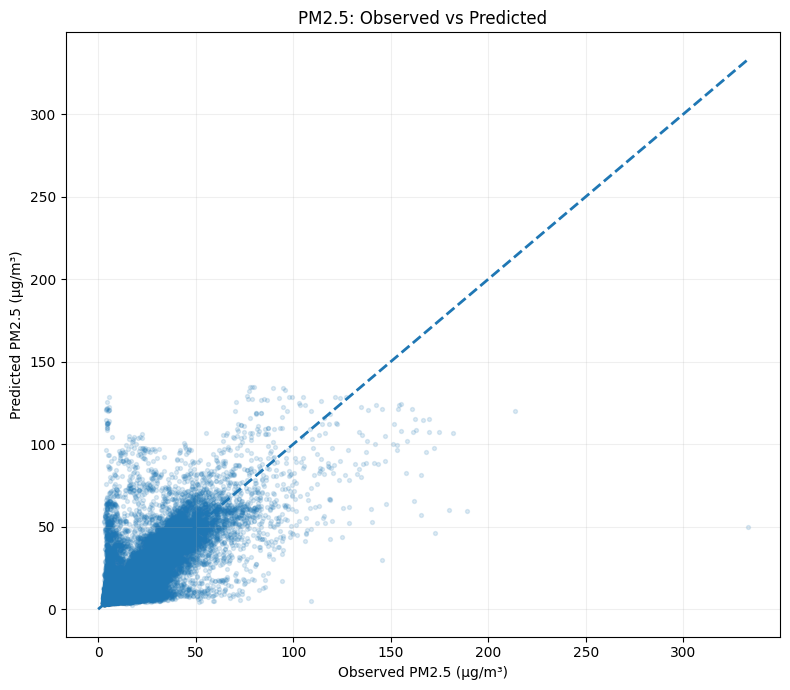

In [42]:
# ==========================================================
# 15.6 Observed vs Predicted
# ==========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    pm25_diagnostics["observed"],
    pm25_diagnostics["predicted"],
    alpha=0.15,
    s=8
)

# 1:1 reference line
max_value = max(
    pm25_diagnostics["observed"].max(),
    pm25_diagnostics["predicted"].max()
)

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2
)

ax.set_xlabel("Observed PM2.5 (µg/m³)")
ax.set_ylabel("Predicted PM2.5 (µg/m³)")
ax.set_title("PM2.5: Observed vs Predicted")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The observed-versus-predicted relationship shows that the tuned Random Forest captures the general variation in PM2.5 concentrations, but predictions are compressed toward the central range of the target distribution. The model particularly underpredicts high-concentration observations, with several observations substantially above the 1:1 reference line.

The increasing spread of predictions at higher observed concentrations also indicates that prediction error is not uniform across the concentration range. This suggests that the available traffic, spatial, temporal and site-level predictors capture part of the variation in PM2.5 but do not fully explain extreme pollution events.

These results are consistent with the earlier quartile-based error analysis, where prediction error was substantially larger in the highest observed concentration group.

# 15.6B NO₂: Observed vs Predicted

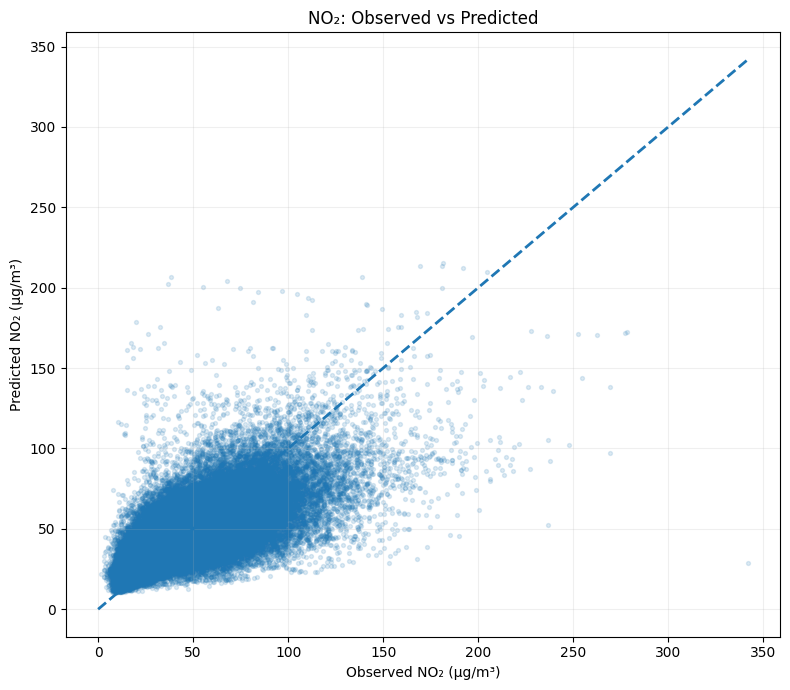

In [43]:
# ==========================================================
# 15.6B NO₂: Observed vs Predicted
# ==========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    no2_diagnostics["observed"],
    no2_diagnostics["predicted"],
    alpha=0.15,
    s=8
)

# 1:1 reference line
max_value = max(
    no2_diagnostics["observed"].max(),
    no2_diagnostics["predicted"].max()
)

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2
)

ax.set_xlabel("Observed NO₂ (µg/m³)")
ax.set_ylabel("Predicted NO₂ (µg/m³)")
ax.set_title("NO₂: Observed vs Predicted")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The observed-versus-predicted plot shows a clear positive relationship between measured and predicted NO₂ concentrations, indicating that the tuned Random Forest captures substantial variation in the target.

However, predictions are compressed toward the central range of the observed distribution. Lower concentrations are frequently overpredicted, while high concentrations are substantially underpredicted. The divergence from the 1:1 reference line becomes particularly pronounced at the upper end of the observed range.

This pattern is consistent with the quartile-based error analysis and indicates that the model captures typical NO₂ conditions better than extreme concentration events.

# 15.6C Numerical observed-predicted relationship

In [44]:
from scipy.stats import pearsonr, spearmanr

def observed_predicted_relationship(df, pollutant):
    observed = df["observed"]
    predicted = df["predicted"]

    pearson_r, pearson_p = pearsonr(observed, predicted)
    spearman_r, spearman_p = spearmanr(observed, predicted)

    print(f"{pollutant}")
    print("-" * 50)
    print(f"Pearson correlation : {pearson_r:.4f}")
    print(f"Pearson p-value     : {pearson_p:.6g}")
    print(f"Spearman correlation: {spearman_r:.4f}")
    print(f"Spearman p-value    : {spearman_p:.6g}")


observed_predicted_relationship(
    pm25_diagnostics,
    "PM2.5"
)

print()

observed_predicted_relationship(
    no2_diagnostics,
    "NO₂"
)

PM2.5
--------------------------------------------------
Pearson correlation : 0.8184
Pearson p-value     : 0
Spearman correlation: 0.8044
Spearman p-value    : 0

NO₂
--------------------------------------------------
Pearson correlation : 0.7373
Pearson p-value     : 0
Spearman correlation: 0.7548
Spearman p-value    : 0


The observed and predicted concentrations show substantial positive relationships for both pollutants. The Pearson correlations were 0.8184 for PM2.5 and 0.7373 for NO₂, while the corresponding Spearman correlations were 0.8044 and 0.7548.

These results indicate that the models generally track variation in measured pollutant concentrations. However, the correlations do not imply perfect prediction. The observed-versus-predicted plots showed substantial compression of extreme concentrations, particularly at the upper end of the distributions. Therefore, correlation should be interpreted alongside MAE, RMSE, R² and the residual diagnostics.

### 15.7 Residuals vs Predicted Values

A residual-versus-predicted plot helps determine whether prediction errors are randomly distributed around zero or whether systematic patterns remain.

A useful regression model should not show a strong structured pattern in the residuals. Increasing spread or a curved pattern can indicate non-uniform error or remaining structure that the model does not capture.

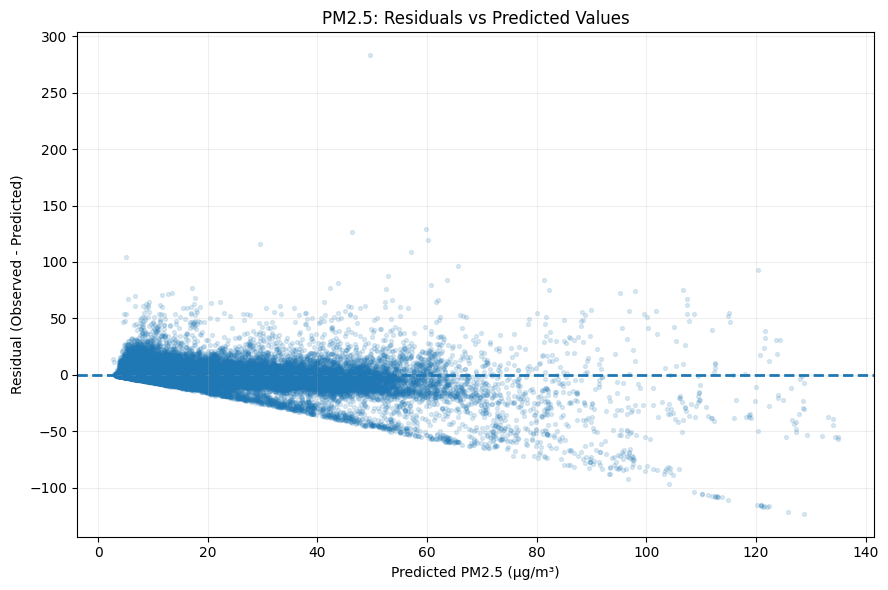

In [45]:
# ==========================================================
# 15.7A PM2.5: Residuals vs Predicted
# ==========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    pm25_diagnostics["predicted"],
    pm25_diagnostics["residual"],
    alpha=0.15,
    s=8
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=2
)

ax.set_xlabel("Predicted PM2.5 (µg/m³)")
ax.set_ylabel("Residual (Observed - Predicted)")
ax.set_title("PM2.5: Residuals vs Predicted Values")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The residual-versus-predicted plot shows a pronounced systematic pattern rather than a random cloud around zero. Residuals are predominantly positive at lower predicted PM2.5 concentrations and increasingly negative at higher predicted concentrations.

This indicates that the model tends to overpredict lower concentrations and underpredict higher concentrations, producing a regression-toward-the-centre pattern. The increasing spread of residuals at higher predicted concentrations also indicates that prediction error is not uniform across the concentration range.

Several large positive residuals remain, representing observed PM2.5 concentrations that were substantially higher than predicted. These results indicate that the model captures general concentration patterns but has limited ability to reproduce extreme PM2.5 observations.

# 15.7B NO₂ residual plot

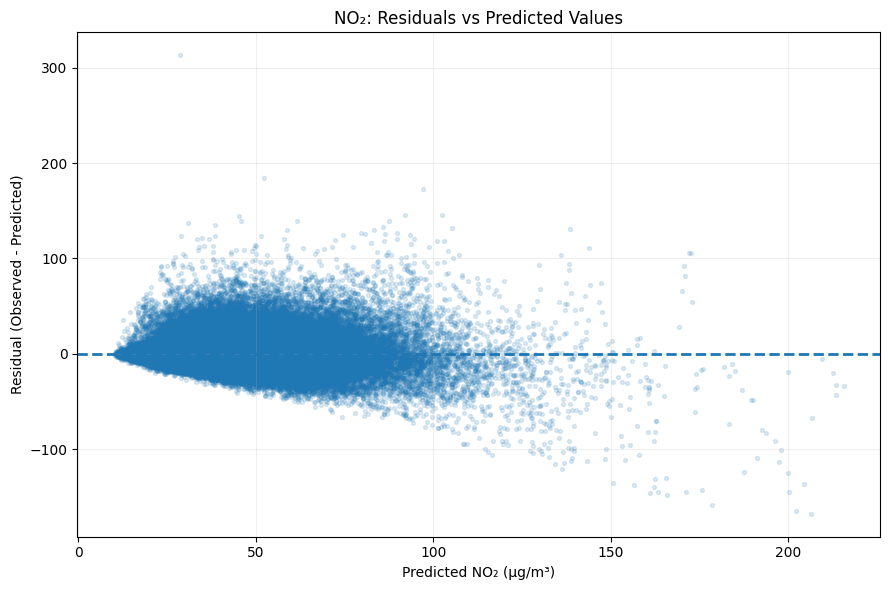

In [46]:
# ==========================================================
# 15.7B NO₂: Residuals vs Predicted
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    no2_diagnostics["predicted"],
    no2_diagnostics["residual"],
    alpha=0.15,
    s=8
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=2
)

ax.set_xlabel("Predicted NO₂ (µg/m³)")
ax.set_ylabel("Residual (Observed - Predicted)")
ax.set_title("NO₂: Residuals vs Predicted Values")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

The residual-versus-predicted plot shows that NO₂ prediction errors are broadly distributed around zero at moderate predicted concentrations, but the spread of residuals increases as predicted concentration increases.

The increasing residual spread indicates that prediction error is not uniform across the NO₂ concentration range. Several large positive and negative residuals are also present at higher predicted concentrations, showing that the model has difficulty reproducing some extreme observations.

Compared with PM2.5, the residual pattern is less strongly directional, but both models show increased uncertainty and poorer representation of extreme concentrations.

### 15.8 Error Across Predicted Concentration Levels

The residual plots suggest that prediction error changes across the concentration range. We quantify this by dividing predictions into concentration groups and comparing mean residual and MAE across those groups.

In [47]:
import pandas as pd
import numpy as np

def residual_by_prediction_group(df, pollutant, n_groups=4):
    temp = df.copy()

    temp["prediction_group"] = pd.qcut(
        temp["predicted"],
        q=n_groups,
        duplicates="drop"
    )

    summary = (
        temp.groupby("prediction_group", observed=True)
        .agg(
            n=("residual", "size"),
            mean_predicted=("predicted", "mean"),
            mean_observed=("observed", "mean"),
            mean_residual=("residual", "mean"),
            mae=("absolute_error", "mean"),
            residual_std=("residual", "std")
        )
        .reset_index()
    )

    print(f"\n{pollutant}")
    print("=" * 80)
    display(summary.round(4))

    return summary


pm25_prediction_error_groups = residual_by_prediction_group(
    pm25_diagnostics,
    "PM2.5"
)

no2_prediction_error_groups = residual_by_prediction_group(
    no2_diagnostics,
    "NO₂"
)


PM2.5


,prediction_group,n,mean_predicted,mean_observed,mean_residual,mae,residual_std
0,"(2.822, 6.017]",30082,5.1339,5.4829,0.3490,1.2146,2.4153
1,"(6.017, 8.052]",30081,6.9499,7.0950,0.1451,1.7588,3.1323
2,"(8.052, 12.936]",30081,10.0340,9.9759,-0.0581,2.6082,4.4800
3,"(12.936, 134.925]",30081,26.5991,23.8881,-2.7110,6.8201,12.1021



NO₂


,prediction_group,n,mean_predicted,mean_observed,mean_residual,mae,residual_std
0,"(10.048, 28.867]",34970,23.9328,23.5467,-0.3861,5.1911,8.2703
1,"(28.867, 37.302]",34969,33.0141,32.0069,-1.0071,8.2614,11.5525
2,"(37.302, 48.941]",34969,42.6047,41.1858,-1.4189,11.4548,15.3258
3,"(48.941, 215.582]",34969,64.5731,63.8660,-0.7071,16.7955,22.6090


Prediction-group diagnostics show that model error increases substantially with predicted concentration for both pollutants.

For PM2.5, MAE increased from 1.21 µg/m³ in the lowest prediction group to 6.82 µg/m³ in the highest group, while residual variability also increased substantially. Mean residuals changed from slightly positive to negative, indicating increasing systematic error at higher predicted concentrations.

For NO₂, MAE increased from 5.19 to 16.80 µg/m³ and residual standard deviation increased from 8.27 to 22.61 µg/m³ across the prediction groups. Mean residuals remained relatively close to zero, suggesting that increasing error variability is more prominent than systematic mean bias.

Overall, both models predict the central concentration range more consistently than the upper range, with substantially greater uncertainty at higher predicted concentrations.

### 15.9 Model Performance Across Unseen Deployments

The test set contains monitoring deployments that were completely excluded from model training. Evaluating error at the deployment level shows whether model performance is reasonably consistent across unseen locations or whether some deployments are substantially harder to predict than others.

In [50]:
# ==========================================================
# 15.9A: Attach Deployment IDs to Diagnostic DataFrames
# ==========================================================

# Preserve the existing diagnostic results and add the
# corresponding deployment identifier from the untouched test sets.

pm25_diagnostics = pm25_diagnostics.copy()
no2_diagnostics = no2_diagnostics.copy()

pm25_diagnostics["pod_id_location"] = pm25_test["pod_id_location"].to_numpy()
no2_diagnostics["pod_id_location"] = no2_test["pod_id_location"].to_numpy()

print("PM2.5 diagnostics shape:", pm25_diagnostics.shape)
print("NO₂ diagnostics shape:", no2_diagnostics.shape)

print("\nPM2.5 unique deployments:",
      pm25_diagnostics["pod_id_location"].nunique())

print("NO₂ unique deployments:",
      no2_diagnostics["pod_id_location"].nunique())

PM2.5 diagnostics shape: (120325, 5)
NO₂ diagnostics shape: (139877, 5)

PM2.5 unique deployments: 16
NO₂ unique deployments: 21


In [51]:
# ==========================================================
# 15.9B: Model Performance Across Unseen Deployments
# ==========================================================

pm25_site_performance = (
    pm25_diagnostics
    .groupby("pod_id_location")
    .agg(
        n=("observed", "size"),
        observed_mean=("observed", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        rmse=("residual", lambda x: np.sqrt(np.mean(x**2))),
        mean_residual=("residual", "mean")
    )
    .reset_index()
)

no2_site_performance = (
    no2_diagnostics
    .groupby("pod_id_location")
    .agg(
        n=("observed", "size"),
        observed_mean=("observed", "mean"),
        predicted_mean=("predicted", "mean"),
        mae=("absolute_error", "mean"),
        rmse=("residual", lambda x: np.sqrt(np.mean(x**2))),
        mean_residual=("residual", "mean")
    )
    .reset_index()
)

print("PM2.5 deployment-level performance")
print("=" * 80)

display(
    pm25_site_performance[
        ["mae", "rmse", "mean_residual", "n"]
    ].describe().round(4)
)

print("\nHighest-MAE PM2.5 deployments:")
display(
    pm25_site_performance
    .sort_values("mae", ascending=False)
    .head(10)
    .round(4)
)

print("\n" + "=" * 80)
print("NO₂ deployment-level performance")
print("=" * 80)

display(
    no2_site_performance[
        ["mae", "rmse", "mean_residual", "n"]
    ].describe().round(4)
)

print("\nHighest-MAE NO₂ deployments:")
display(
    no2_site_performance
    .sort_values("mae", ascending=False)
    .head(10)
    .round(4)
)

PM2.5 deployment-level performance


,mae,rmse,mean_residual,n
count,16.0000,16.0000,16.0000,16.0000
mean,3.0841,6.1081,-0.3539,7520.3125
std,1.2749,3.1990,2.1895,1652.0052
min,1.1436,1.9197,-5.6017,5195.0000
25%,2.4252,4.6981,-1.1623,6165.2500
50%,2.9004,5.4130,-0.1144,7330.0000
75%,3.7153,6.8496,1.2427,9367.0000
max,6.0813,13.7063,2.7045,9782.0000



Highest-MAE PM2.5 deployments:


,pod_id_location,n,observed_mean,predicted_mean,mae,rmse,mean_residual
5,35245,9466,10.3291,15.9308,6.0813,13.7063,-5.6017
9,42451,5777,13.3187,13.1942,5.0023,12.3678,0.1244
15,82245,6249,12.3846,11.0910,3.8251,6.5323,1.2935
11,57245,8298,11.1228,14.2381,3.7505,8.0711,-3.1153
2,16245,5784,12.2253,9.5207,3.7036,5.4715,2.7045
0,1245,6596,12.4764,12.9999,3.6212,7.8014,-0.5235
4,29245,9782,9.4558,12.2448,3.2514,5.0188,-2.7890
14,80245,6256,13.0228,11.0797,2.9312,5.3545,1.9431
8,40245,9334,13.1667,11.9409,2.8696,5.8247,1.2258
3,25245,8064,10.5177,12.8149,2.7031,4.9246,-2.2972



NO₂ deployment-level performance


,mae,rmse,mean_residual,n
count,21.0000,21.0000,21.0000,21.0000
mean,10.0438,13.7752,-0.7219,6660.8095
std,4.8375,6.5227,8.2186,2590.8270
min,3.0441,4.0565,-14.0416,324.0000
25%,7.3155,9.7977,-4.8564,4943.0000
50%,9.3805,12.7094,-1.9613,7427.0000
75%,11.1946,15.5454,1.4840,8360.0000
max,24.7915,33.5748,22.8409,9617.0000



Highest-MAE NO₂ deployments:


,pod_id_location,n,observed_mean,predicted_mean,mae,rmse,mean_residual
19,85245,4169,69.9393,47.0985,24.7915,33.5748,22.8409
6,36245,7636,34.8173,48.8589,15.4547,18.8137,-14.0416
15,73245,8360,53.7941,43.4595,14.9185,20.8087,10.3346
7,38245,9617,54.7019,46.0026,14.4653,21.7379,8.6993
14,72245,6639,32.0667,45.2554,13.7525,15.4507,-13.1887
18,84245,9435,35.1728,40.0292,11.1946,15.5454,-4.8564
2,15245,7510,45.8564,47.8177,11.1394,18.8545,-1.9613
3,21245,7851,42.1051,51.0571,11.1211,13.3644,-8.9520
9,50245,9472,43.0383,45.2678,10.1872,13.8970,-2.2295
20,95245,4734,33.0757,36.8604,10.0208,12.7094,-3.7847


Deployment-level evaluation shows that model performance varies across unseen monitoring deployments.

For PM2.5, deployment-level MAE ranged from 1.14 to 6.08 µg/m³, with a median of 2.90 µg/m³. Most deployments showed relatively similar performance, although a small number had substantially larger errors.

NO₂ showed greater variation across deployments. Deployment-level MAE ranged from 3.04 to 24.79 µg/m³, with a median of 9.38 µg/m³. Mean residuals also varied considerably between deployments, indicating that some locations experienced systematic overprediction while others experienced systematic underprediction.

These results demonstrate that overall test-set metrics do not fully describe model behaviour across locations. The models generalize to unseen deployments, but prediction accuracy is heterogeneous across monitoring locations, particularly for NO₂.

In [52]:
# ==========================================================
# 15.10 Deployment Size vs Model Error
# ==========================================================

print("PM2.5: Correlation between deployment size and MAE")
print("-" * 60)

print(
    pm25_site_performance[["n", "mae", "rmse"]]
    .corr(method="spearman")
    .round(4)
)

print("\nNO₂: Correlation between deployment size and MAE")
print("-" * 60)

print(
    no2_site_performance[["n", "mae", "rmse"]]
    .corr(method="spearman")
    .round(4)
)

PM2.5: Correlation between deployment size and MAE
------------------------------------------------------------
           n     mae    rmse
n     1.0000  0.0059 -0.1000
mae   0.0059  1.0000  0.8735
rmse -0.1000  0.8735  1.0000

NO₂: Correlation between deployment size and MAE
------------------------------------------------------------
           n     mae    rmse
n     1.0000  0.3571  0.4260
mae   0.3571  1.0000  0.9662
rmse  0.4260  0.9662  1.0000


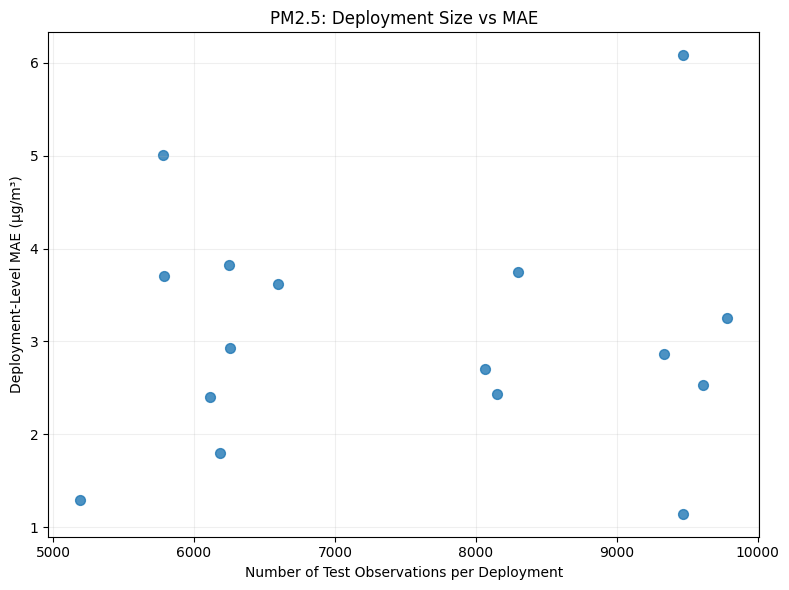

In [53]:
# ==========================================================
# 15.10A Deployment Size vs MAE
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    pm25_site_performance["n"],
    pm25_site_performance["mae"],
    alpha=0.8,
    s=50
)

ax.set_xlabel("Number of Test Observations per Deployment")
ax.set_ylabel("Deployment-Level MAE (µg/m³)")
ax.set_title("PM2.5: Deployment Size vs MAE")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

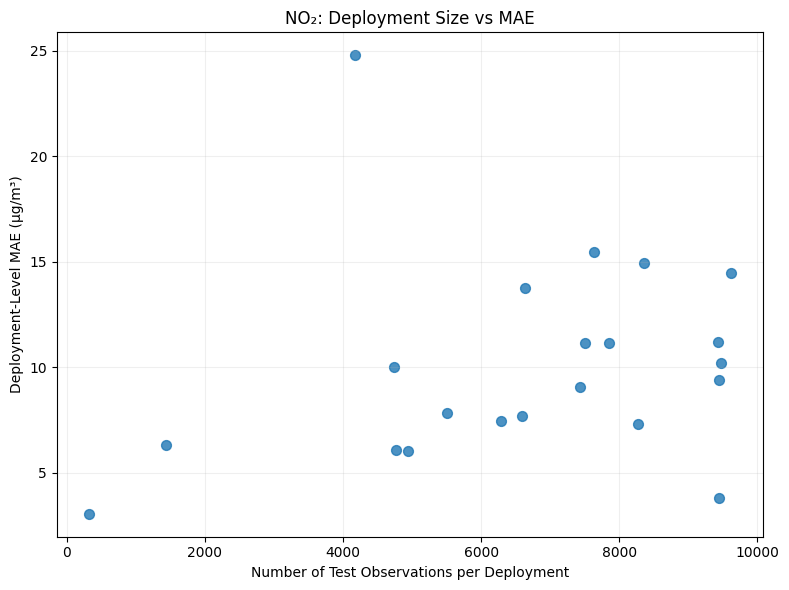

In [54]:
# ==========================================================
# NO₂: Deployment Size vs MAE
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    no2_site_performance["n"],
    no2_site_performance["mae"],
    alpha=0.8,
    s=50
)

ax.set_xlabel("Number of Test Observations per Deployment")
ax.set_ylabel("Deployment-Level MAE (µg/m³)")
ax.set_title("NO₂: Deployment Size vs MAE")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Deployment size showed essentially no relationship with PM2.5 MAE (Spearman ρ = 0.0059), indicating that differences in PM2.5 deployment-level error were not explained by the number of test observations available for each deployment.

For NO₂, deployment size showed a modest positive relationship with MAE (Spearman ρ = 0.3571) and RMSE (ρ = 0.4260). However, the number of deployments was limited, so these relationships are treated as descriptive rather than explanatory.

Overall, deployment-level differences in model performance cannot be attributed primarily to the number of observations per deployment. Other location-specific or environmental factors may contribute to the observed variation in prediction error.

### 15.11 Final Model Comparison

The final comparison evaluates whether the tuned Random Forest improves predictive performance relative to the baseline Linear Regression, Random Forest, Gradient Boosting and XGBoost models.

All comparisons use the same untouched group-based test sets. MAE and RMSE measure prediction error, while R² measures the proportion of variation explained by the model on the test data.

In [55]:
# ==========================================================
# 15.11 Final Model Comparison
# ==========================================================

model_comparison = pd.DataFrame([
    # PM2.5
    ["PM2.5", "Linear Regression", 7.0560, 10.7619, 0.0762],
    ["PM2.5", "Random Forest", 3.1921, 7.4556, 0.5566],
    ["PM2.5", "Gradient Boosting", 5.1623, 8.2249, 0.4604],
    ["PM2.5", "XGBoost", 3.9002, 6.6123, 0.6513],
    ["PM2.5", "Tuned Random Forest", 3.1004, 6.8859, 0.6218],

    # NO2
    ["NO₂", "Linear Regression", 15.4709, 21.3309, 0.1230],
    ["NO₂", "Random Forest", 9.6668, 15.0134, 0.5655],
    ["NO₂", "Gradient Boosting", 13.6690, 19.1431, 0.2936],
    ["NO₂", "XGBoost", 11.4627, 16.6216, 0.4675],
    ["NO₂", "Tuned Random Forest", 10.4257, 15.4236, 0.5415],
], columns=[
    "Pollutant",
    "Model",
    "MAE",
    "RMSE",
    "R2"
])

display(
    model_comparison.round(4)
)

,Pollutant,Model,MAE,RMSE,R2
0,PM2.5,Linear Regression,7.0560,10.7619,0.0762
1,PM2.5,Random Forest,3.1921,7.4556,0.5566
2,PM2.5,Gradient Boosting,5.1623,8.2249,0.4604
3,PM2.5,XGBoost,3.9002,6.6123,0.6513
4,PM2.5,Tuned Random Forest,3.1004,6.8859,0.6218
5,NO₂,Linear Regression,15.4709,21.3309,0.1230
6,NO₂,Random Forest,9.6668,15.0134,0.5655
7,NO₂,Gradient Boosting,13.6690,19.1431,0.2936
8,NO₂,XGBoost,11.4627,16.6216,0.4675
9,NO₂,Tuned Random Forest,10.4257,15.4236,0.5415


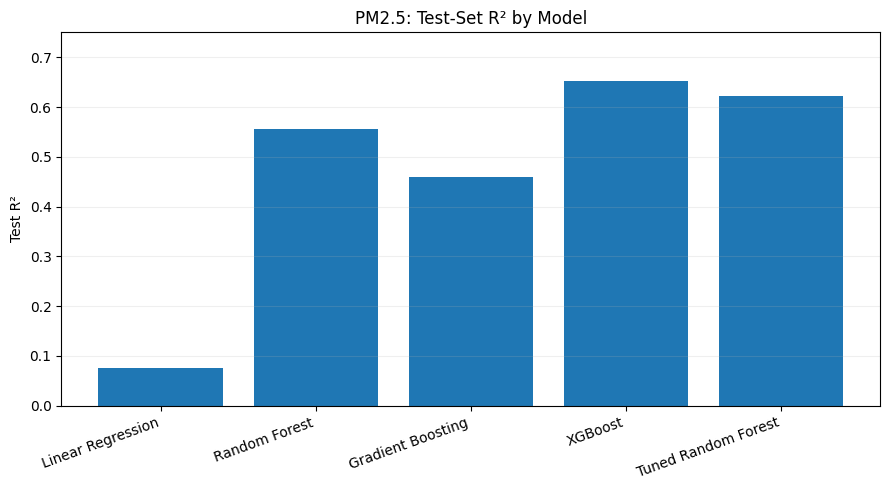

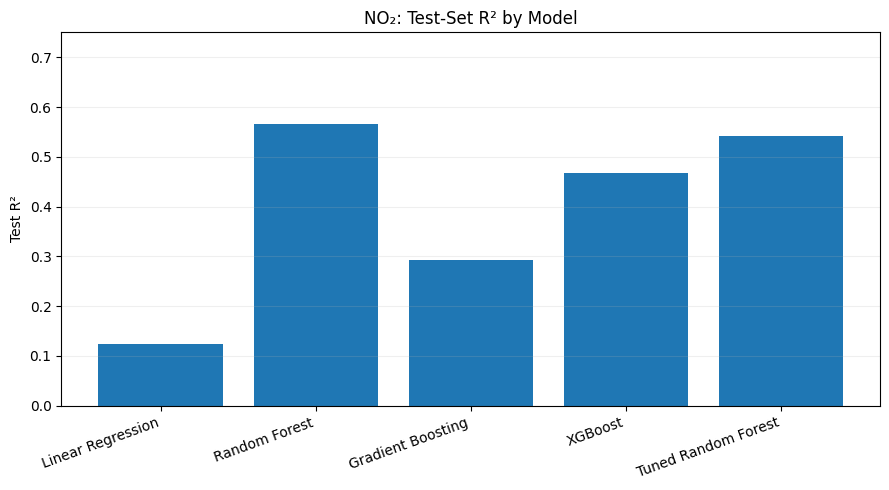

In [56]:
# ==========================================================
# R² Comparison
# ==========================================================

for pollutant in ["PM2.5", "NO₂"]:

    subset = model_comparison[
        model_comparison["Pollutant"] == pollutant
    ]

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(
        subset["Model"],
        subset["R2"]
    )

    ax.set_ylabel("Test R²")
    ax.set_title(f"{pollutant}: Test-Set R² by Model")
    ax.set_ylim(0, 0.75)

    plt.xticks(rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

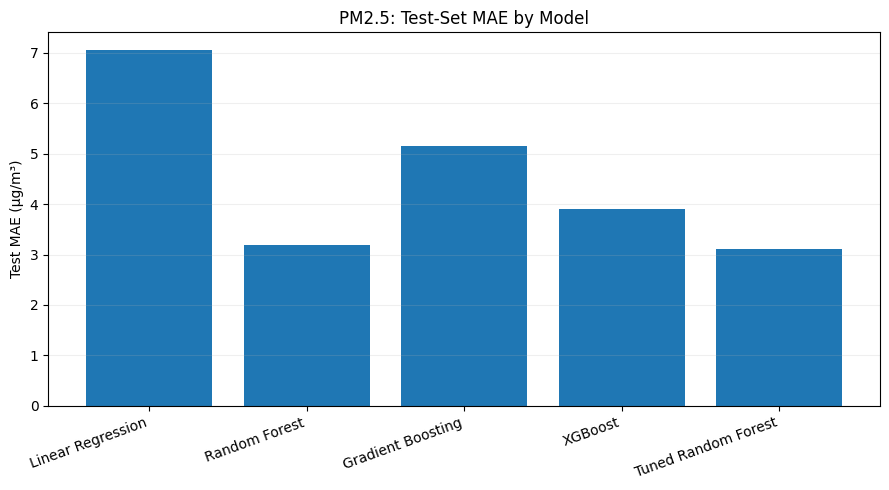

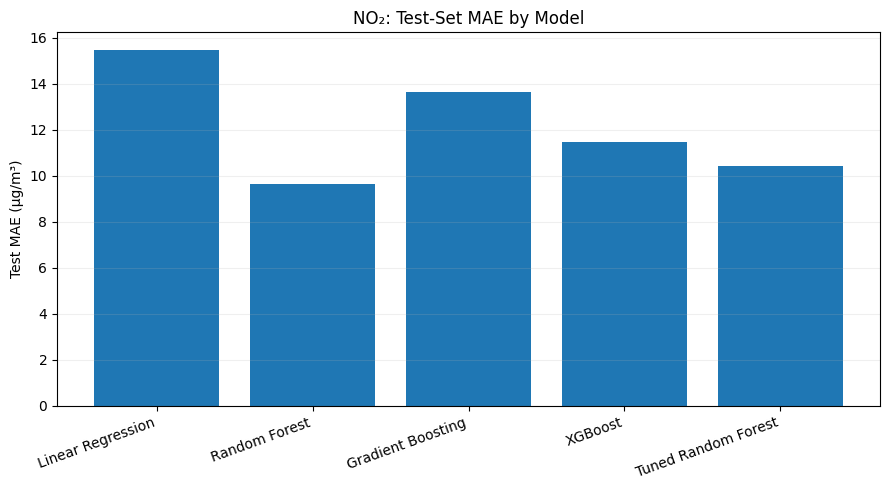

In [57]:
# ==========================================================
# MAE Comparison
# ==========================================================

for pollutant in ["PM2.5", "NO₂"]:

    subset = model_comparison[
        model_comparison["Pollutant"] == pollutant
    ]

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(
        subset["Model"],
        subset["MAE"]
    )

    ax.set_ylabel("Test MAE (µg/m³)")
    ax.set_title(f"{pollutant}: Test-Set MAE by Model")

    plt.xticks(rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

The model comparison shows that nonlinear tree-based models substantially outperform the Linear Regression baseline for both pollutants. This indicates that the relationship between the available spatial, traffic, temporal and site-level predictors and pollutant concentrations is not adequately represented by a simple linear model.

For PM2.5, XGBoost achieved the highest test R² (0.6513) and lowest RMSE (6.6123 µg/m³), while the tuned Random Forest achieved the lowest MAE (3.1004 µg/m³).

For NO₂, the untuned Random Forest achieved the highest test R² (0.5655) and lowest MAE (9.6668 µg/m³) among the evaluated models. The tuned Random Forest produced slightly lower R² (0.5415) and higher MAE (10.4257 µg/m³).

The results demonstrate that model performance depends on both the pollutant and the evaluation metric. Hyperparameter tuning under a specific optimization objective does not necessarily improve every test-set metric.

# 16. Model Explainability

Machine-learning performance metrics describe how accurately a model predicts pollutant concentrations, but they do not explain which predictors contribute most to those predictions.

This chapter examines feature importance in the final models to identify the spatial, traffic, temporal and site-level variables most influential in model predictions. Feature importance is interpreted as model behaviour, not as evidence of causation.

### 16.1 Why Feature Importance?

Understanding feature importance helps connect model predictions back to the research questions. It allows us to determine whether traffic, road proximity, temporal characteristics, spatial variables or site characteristics contribute most to predictive performance.

Because the model uses preprocessing and one-hot encoding, feature names must first be recovered from the fitted preprocessing pipeline before importance values can be interpreted.

### 16.2 Raw Feature Importance:

The Random Forest models place substantial importance on temporal features for both pollutants.

For PM2.5, the strongest individual features are the annual-cycle variables `day_of_year_cos` and `day_of_year_sin`, followed by the time-of-day variables `hour_sin` and `hour_cos`. The day-of-week variables also contribute meaningfully. Spatial variables such as latitude, longitude, height, and distance from road contribute smaller amounts, while `log_minor_total_vkm` has relatively low individual impurity-based importance.

For NO₂, the same annual and daily temporal patterns dominate. However, site type, latitude, longitude, traffic exposure, height, and distance from road have more visible contributions than they do in the PM2.5 model.

These results indicate that the models rely strongly on temporal and spatial structure when predicting pollutant concentrations. However, feature importance describes how the Random Forest uses variables for prediction; it does not establish that a variable causes changes in pollutant concentration.

The `day_of_year_sin` and `day_of_year_cos` variables are also two components of the same cyclical annual representation, so their individual importance values should not be interpreted as completely independent effects.

Because these are impurity-based Random Forest importances, they can also be influenced by correlated predictors and categorical encoding. Therefore, this analysis should be treated as an initial model-explanation step rather than the final evidence for feature influence.

In [84]:
# ==========================================================
# 16.2 Raw Feature Importance
# ==========================================================

# Recreate the fitted preprocessing objects used in Chapter 11.
# These use the same feature definitions and preprocessing
# structure as the final models.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------------------------------------
# PM2.5 preprocessing structure
# ----------------------------------------------------------

pm25_explain_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median")
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            model_numeric_features
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=True
                        )
                    )
                ]
            ),
            final_categorical_features
        )
    ],
    remainder="drop"
)

# Fit only to the PM2.5 training data
pm25_explain_preprocessor.fit(
    pm25_train[
        model_numeric_features +
        final_categorical_features
    ]
)

# ----------------------------------------------------------
# NO₂ preprocessing structure
# ----------------------------------------------------------

no2_explain_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="median")
                    ),
                    (
                        "scaler",
                        StandardScaler()
                    )
                ]
            ),
            model_numeric_features
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=True
                        )
                    )
                ]
            ),
            final_categorical_features
        )
    ],
    remainder="drop"
)

# Fit only to the NO₂ training data
no2_explain_preprocessor.fit(
    no2_train[
        model_numeric_features +
        final_categorical_features
    ]
)

# ----------------------------------------------------------
# Retrieve transformed feature names
# ----------------------------------------------------------

pm25_feature_names = (
    pm25_explain_preprocessor
    .get_feature_names_out()
)

no2_feature_names = (
    no2_explain_preprocessor
    .get_feature_names_out()
)

# ----------------------------------------------------------
# Create raw impurity-based importance tables
# ----------------------------------------------------------

pm25_importance = pd.DataFrame({
    "feature": pm25_feature_names,
    "importance": pm25_rf_tuned.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

no2_importance = pd.DataFrame({
    "feature": no2_feature_names,
    "importance": no2_rf_tuned.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 15 PM2.5 features")
print("=" * 60)
display(
    pm25_importance.head(15).round(6)
)

print("\nTop 15 NO₂ features")
print("=" * 60)
display(
    no2_importance.head(15).round(6)
)

Top 15 PM2.5 features


,feature,importance
10,numeric__day_of_year_cos,0.311070
9,numeric__day_of_year_sin,0.260832
5,numeric__hour_sin,0.096738
6,numeric__hour_cos,0.063581
7,numeric__day_of_week_sin,0.050965
8,numeric__day_of_week_cos,0.049417
0,numeric__latitude,0.024253
1,numeric__longitude,0.020752
37,categorical__borough_Lambeth,0.016895
3,numeric__height,0.012849



Top 15 NO₂ features


,feature,importance
9,numeric__day_of_year_sin,0.208015
10,numeric__day_of_year_cos,0.197024
5,numeric__hour_sin,0.088789
6,numeric__hour_cos,0.071900
7,numeric__day_of_week_sin,0.054177
17,categorical__type_Urban Background,0.049466
8,numeric__day_of_week_cos,0.035245
0,numeric__latitude,0.035153
1,numeric__longitude,0.034181
4,numeric__log_minor_total_vkm,0.033668


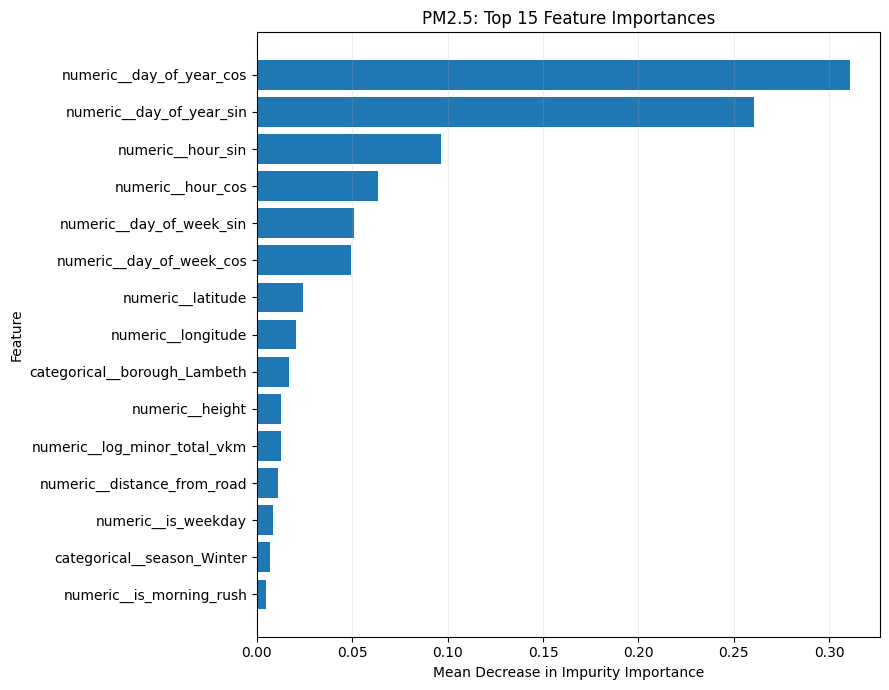

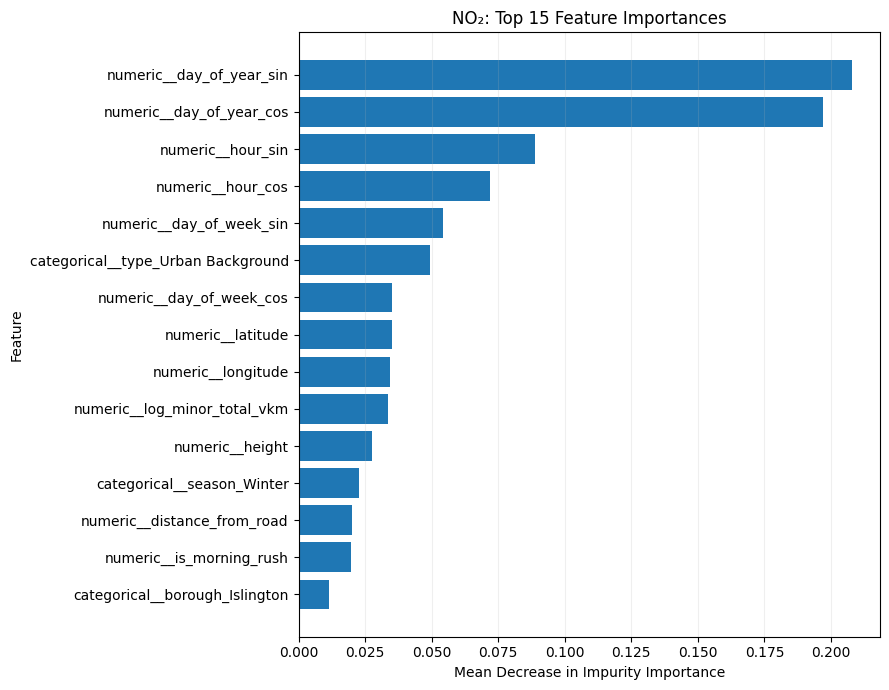

In [67]:
# ==========================================================
# 16.2B: Top 15 Raw Feature Importance
# ==========================================================

for importance_df, pollutant in [
    (pm25_importance, "PM2.5"),
    (no2_importance, "NO₂")
]:

    top_features = importance_df.head(15).sort_values(
        "importance",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.barh(
        top_features["feature"],
        top_features["importance"]
    )

    ax.set_xlabel("Mean Decrease in Impurity Importance")
    ax.set_ylabel("Feature")
    ax.set_title(f"{pollutant}: Top 15 Feature Importances")

    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

### 16.3 Aggregating Feature Importance

The raw Random Forest importance table represents categorical variables and cyclical variables as separate transformed features. For example, annual seasonality is represented by `day_of_year_sin` and `day_of_year_cos`, while borough is represented by multiple one-hot encoded columns.

To make the results easier to interpret at the research-variable level, these transformed features will be grouped back into their original variables. This allows us to compare the overall contribution of concepts such as annual timing, daily timing, traffic exposure, spatial location, road distance, site type, borough, and season.

In [85]:
def aggregate_feature_importance(importance_df):
    df = importance_df.copy()

    def original_feature(feature):
        feature = feature.replace("numeric__", "").replace("categorical__", "")

        if feature.startswith("day_of_year_"):
            return "day_of_year"
        elif feature.startswith("day_of_week_"):
            return "day_of_week"
        elif feature.startswith("hour_"):
            return "hour"
        elif feature.startswith("type_"):
            return "type"
        elif feature.startswith("ulez_"):
            return "ulez"
        elif feature.startswith("borough_"):
            return "borough"
        elif feature.startswith("season_"):
            return "season"
        elif feature == "distance_from_road_missing":
            return "distance_from_road_missing"
        else:
            return feature

    df["original_feature"] = df["feature"].apply(original_feature)

    return (
        df.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )


pm25_aggregated_importance = aggregate_feature_importance(pm25_importance)
no2_aggregated_importance = aggregate_feature_importance(no2_importance)

print("PM2.5: Aggregated Feature Importance")
display(pm25_aggregated_importance.round(6))

print("\nNO₂: Aggregated Feature Importance")
display(no2_aggregated_importance.round(6))

PM2.5: Aggregated Feature Importance


,original_feature,importance
2,day_of_year,0.571901
6,hour,0.160319
1,day_of_week,0.100382
0,borough,0.042484
10,latitude,0.024253
12,longitude,0.020752
13,season,0.014149
5,height,0.012849
11,log_minor_total_vkm,0.012497
3,distance_from_road,0.010807



NO₂: Aggregated Feature Importance


,original_feature,importance
2,day_of_year,0.405040
6,hour,0.160690
1,day_of_week,0.089422
0,borough,0.062152
14,type,0.058172
10,latitude,0.035153
12,longitude,0.034181
11,log_minor_total_vkm,0.033668
13,season,0.030819
5,height,0.027667


After combining the encoded and cyclical components back into their original variables, temporal structure remains the dominant source of predictive information for both pollutants.

For PM2.5, `day_of_year` has an aggregated importance of 0.5719, followed by `hour` at 0.1603 and `day_of_week` at 0.1004. Together, these temporal variables account for approximately 83.3% of the total impurity-based importance. Borough contributes 0.0425, while latitude and longitude contribute 0.0243 and 0.0208 respectively. The traffic exposure variable `log_minor_total_vkm` contributes 0.0125.

For NO₂, `day_of_year` also has the largest importance at 0.4050, followed by `hour` at 0.1607 and `day_of_week` at 0.0894. Borough contributes 0.0622 and site `type` contributes 0.0582. Spatial variables, traffic exposure, season, height, and distance from road also contribute to the model.

The models therefore rely heavily on temporal patterns, while spatial, site, and traffic-related variables provide additional predictive information. The relative contribution of traffic exposure is larger in the NO₂ model than in the PM2.5 model.

These results describe predictive model behavior rather than causal effects. In particular, the importance of `day_of_year` should not be interpreted as a direct causal effect of the calendar date. It represents recurring annual patterns captured by the model.

The impurity-based importance values can also be affected by correlations between predictors. Therefore, a second explainability method is needed before drawing stronger conclusions about which variables materially contribute to predictive performance.

### 16.4 Final Comparison of Feature Importance Methods

Permutation importance is calculated on a reproducible 10,000-observation sample from each untouched test set to make the analysis computationally efficient while preserving the held-out evaluation design.

For cyclical variables, the sine and cosine components represent a single underlying variable. Therefore, `day_of_year_sin` and `day_of_year_cos` are jointly permuted using the same random ordering. The same procedure is applied to the hour and day-of-week representations.

The resulting importance value represents the increase in test-set MAE after disrupting the original variable. Larger positive values indicate greater predictive information associated with that variable. These results are interpreted as predictive importance rather than causal importance.

In [92]:
# ============================================================
# 16.4 Final Comparison of Feature Importance Methods
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Create reproducible permutation samples
# ------------------------------------------------------------

PERM_SAMPLE_SIZE = 10000
PERM_RANDOM_STATE = 42

pm25_perm_sample = pm25_test.sample(
    n=min(PERM_SAMPLE_SIZE, len(pm25_test)),
    random_state=PERM_RANDOM_STATE
).copy()

no2_perm_sample = no2_test.sample(
    n=min(PERM_SAMPLE_SIZE, len(no2_test)),
    random_state=PERM_RANDOM_STATE
).copy()


# ------------------------------------------------------------
# 2. Extract targets
# ------------------------------------------------------------

pm25_perm_target = pm25_perm_sample["pm2_5_ugm3"].copy()
no2_perm_target = no2_perm_sample["no2_ugm3"].copy()


# ------------------------------------------------------------
# 3. Select model predictors
# ------------------------------------------------------------

pm25_perm_X = pm25_perm_sample[
    model_numeric_features + final_categorical_features
].copy()

no2_perm_X = no2_perm_sample[
    model_numeric_features + final_categorical_features
].copy()


# ------------------------------------------------------------
# 4. Function to build original-feature groups
# ------------------------------------------------------------

def build_feature_groups(preprocessor):
    """
    Map original model features to their transformed columns.

    Numeric cyclical components are grouped jointly.
    One-hot encoded categorical columns are grouped back
    to their original categorical feature.
    """

    transformed_features = list(
        preprocessor.get_feature_names_out()
    )

    feature_groups = {}

    # Numeric features
    feature_groups["distance_from_road"] = [
        "numeric__distance_from_road"
    ]

    feature_groups["distance_from_road_missing"] = [
        "numeric__distance_from_road_missing"
    ]

    feature_groups["height"] = [
        "numeric__height"
    ]

    feature_groups["latitude"] = [
        "numeric__latitude"
    ]

    feature_groups["longitude"] = [
        "numeric__longitude"
    ]

    feature_groups["log_minor_total_vkm"] = [
        "numeric__log_minor_total_vkm"
    ]

    feature_groups["is_evening_rush"] = [
        "numeric__is_evening_rush"
    ]

    feature_groups["is_morning_rush"] = [
        "numeric__is_morning_rush"
    ]

    feature_groups["is_weekday"] = [
        "numeric__is_weekday"
    ]

    # Joint cyclical variables
    feature_groups["hour"] = [
        "numeric__hour_sin",
        "numeric__hour_cos"
    ]

    feature_groups["day_of_week"] = [
        "numeric__day_of_week_sin",
        "numeric__day_of_week_cos"
    ]

    feature_groups["day_of_year"] = [
        "numeric__day_of_year_sin",
        "numeric__day_of_year_cos"
    ]

    # --------------------------------------------------------
    # One-hot encoded categorical variables
    # --------------------------------------------------------

    categorical_prefixes = {
        "borough": "categorical__borough_",
        "season": "categorical__season_",
        "type": "categorical__type_",
        "ulez": "categorical__ulez_"
    }

    for original_feature, prefix in categorical_prefixes.items():

        matching_columns = [
            feature
            for feature in transformed_features
            if feature.startswith(prefix)
        ]

        feature_groups[original_feature] = matching_columns

    return feature_groups


# ------------------------------------------------------------
# 5. Joint permutation importance function
# ------------------------------------------------------------

def joint_permutation_importance(
    preprocessor,
    model,
    X,
    y,
    feature_groups,
    n_repeats=5,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    # Transform predictor data
    X_transformed = preprocessor.transform(X)

    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    X_transformed = np.asarray(X_transformed)

    # Transformed feature names
    transformed_feature_names = list(
        preprocessor.get_feature_names_out()
    )

    feature_to_index = {
        feature: i
        for i, feature in enumerate(
            transformed_feature_names
        )
    }

    # Baseline prediction
    baseline_predictions = model.predict(
        X_transformed
    )

    baseline_mae = np.mean(
        np.abs(
            np.asarray(y) - baseline_predictions
        )
    )

    results = []

    # --------------------------------------------------------
    # Permute each original feature
    # --------------------------------------------------------

    for original_feature, transformed_features in feature_groups.items():

        indices = [
            feature_to_index[f]
            for f in transformed_features
            if f in feature_to_index
        ]

        if len(indices) == 0:
            continue

        importance_scores = []

        for _ in range(n_repeats):

            X_permuted = X_transformed.copy()

            # Same permutation applied to all components
            # belonging to this original feature
            permutation = rng.permutation(
                len(X_permuted)
            )

            X_permuted[:, indices] = (
                X_transformed[
                    permutation
                ][:, indices]
            )

            permuted_predictions = model.predict(
                X_permuted
            )

            permuted_mae = np.mean(
                np.abs(
                    np.asarray(y)
                    - permuted_predictions
                )
            )

            importance_scores.append(
                permuted_mae - baseline_mae
            )

        results.append({
            "original_feature": original_feature,
            "importance_mean": np.mean(
                importance_scores
            ),
            "importance_std": np.std(
                importance_scores
            )
        })

    results = pd.DataFrame(results)

    results = results.sort_values(
        "importance_mean",
        ascending=False
    ).reset_index(drop=True)

    results["permutation_rank"] = (
        np.arange(1, len(results) + 1)
    )

    return results


# ------------------------------------------------------------
# 6. Build feature groups for each pollutant
# ------------------------------------------------------------

pm25_feature_groups = build_feature_groups(
    pm25_explain_preprocessor
)

no2_feature_groups = build_feature_groups(
    no2_explain_preprocessor
)


# ------------------------------------------------------------
# 7. Verify that all expected original features are included
# ------------------------------------------------------------

print("PM2.5 feature groups:")
for feature, columns in pm25_feature_groups.items():
    print(f"{feature}: {len(columns)} transformed column(s)")

print("\nNO₂ feature groups:")
for feature, columns in no2_feature_groups.items():
    print(f"{feature}: {len(columns)} transformed column(s)")


# ------------------------------------------------------------
# 8. Calculate PM2.5 permutation importance
# ------------------------------------------------------------

pm25_importance_final = joint_permutation_importance(
    preprocessor=pm25_explain_preprocessor,
    model=pm25_rf_tuned,
    X=pm25_perm_X,
    y=pm25_perm_target,
    feature_groups=pm25_feature_groups,
    n_repeats=5,
    random_state=42
)


# ------------------------------------------------------------
# 9. Calculate NO₂ permutation importance
# ------------------------------------------------------------

no2_importance_final = joint_permutation_importance(
    preprocessor=no2_explain_preprocessor,
    model=no2_rf_tuned,
    X=no2_perm_X,
    y=no2_perm_target,
    feature_groups=no2_feature_groups,
    n_repeats=5,
    random_state=42
)


# ------------------------------------------------------------
# 10. Add impurity importance
# ------------------------------------------------------------

pm25_importance_final = pm25_importance_final.merge(
    pm25_aggregated_importance[
        ["original_feature", "importance"]
    ].rename(
        columns={
            "importance": "impurity_importance"
        }
    ),
    on="original_feature",
    how="left"
)

no2_importance_final = no2_importance_final.merge(
    no2_aggregated_importance[
        ["original_feature", "importance"]
    ].rename(
        columns={
            "importance": "impurity_importance"
        }
    ),
    on="original_feature",
    how="left"
)


# ------------------------------------------------------------
# 11. Add impurity ranks
# ------------------------------------------------------------

pm25_importance_final["impurity_rank"] = (
    pm25_importance_final[
        "impurity_importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

no2_importance_final["impurity_rank"] = (
    no2_importance_final[
        "impurity_importance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


# ------------------------------------------------------------
# 12. Final column order
# ------------------------------------------------------------

pm25_importance_final = pm25_importance_final[
    [
        "original_feature",
        "impurity_importance",
        "impurity_rank",
        "importance_mean",
        "importance_std",
        "permutation_rank"
    ]
]

no2_importance_final = no2_importance_final[
    [
        "original_feature",
        "impurity_importance",
        "impurity_rank",
        "importance_mean",
        "importance_std",
        "permutation_rank"
    ]
]


# ------------------------------------------------------------
# 13. Display final comparison
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PM2.5: FINAL FEATURE IMPORTANCE COMPARISON")
print("=" * 75)

display(
    pm25_importance_final
    .sort_values("permutation_rank")
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("NO₂: FINAL FEATURE IMPORTANCE COMPARISON")
print("=" * 75)

display(
    no2_importance_final
    .sort_values("permutation_rank")
    .reset_index(drop=True)
)

PM2.5 feature groups:
distance_from_road: 1 transformed column(s)
distance_from_road_missing: 1 transformed column(s)
height: 1 transformed column(s)
latitude: 1 transformed column(s)
longitude: 1 transformed column(s)
log_minor_total_vkm: 1 transformed column(s)
is_evening_rush: 1 transformed column(s)
is_morning_rush: 1 transformed column(s)
is_weekday: 1 transformed column(s)
hour: 2 transformed column(s)
day_of_week: 2 transformed column(s)
day_of_year: 2 transformed column(s)
borough: 28 transformed column(s)
season: 4 transformed column(s)
type: 3 transformed column(s)
ulez: 2 transformed column(s)

NO₂ feature groups:
distance_from_road: 1 transformed column(s)
distance_from_road_missing: 1 transformed column(s)
height: 1 transformed column(s)
latitude: 1 transformed column(s)
longitude: 1 transformed column(s)
log_minor_total_vkm: 1 transformed column(s)
is_evening_rush: 1 transformed column(s)
is_morning_rush: 1 transformed column(s)
is_weekday: 1 transformed column(s)
hour: 2

,original_feature,impurity_importance,impurity_rank,importance_mean,importance_std,permutation_rank
0,day_of_year,0.571901,1,5.699478,0.047657,1
1,hour,0.160319,2,2.085911,0.049457,2
2,day_of_week,0.100382,3,1.534102,0.033536,3
3,season,0.014149,7,0.294077,0.006246,4
4,distance_from_road,0.010807,10,0.104829,0.004780,5
5,latitude,0.024253,5,0.103383,0.005395,6
6,longitude,0.020752,6,0.082485,0.012626,7
7,type,0.006402,12,0.078816,0.007734,8
8,log_minor_total_vkm,0.012497,9,0.062685,0.009580,9
9,is_weekday,0.008638,11,0.045812,0.005077,10



NO₂: FINAL FEATURE IMPORTANCE COMPARISON


,original_feature,impurity_importance,impurity_rank,importance_mean,importance_std,permutation_rank
0,day_of_year,0.405040,1,6.248720,0.063104,1
1,hour,0.160690,2,3.797566,0.023523,2
2,season,0.030819,9,2.616249,0.056690,3
3,day_of_week,0.089422,3,2.089822,0.020363,4
4,type,0.058172,5,1.712238,0.038216,5
5,is_morning_rush,0.019575,12,0.734509,0.017806,6
6,is_weekday,0.011539,13,0.596672,0.028919,7
7,latitude,0.035153,6,0.580241,0.025046,8
8,longitude,0.034181,7,0.188418,0.017764,9
9,height,0.027667,10,0.108806,0.016451,10


The impurity-based and joint permutation importance methods show strong agreement on the dominant predictors for both pollutants. Temporal variables, particularly day of year, hour, and day of week, consistently occupy the highest importance positions.

For PM2.5, day of year, hour, and day of week dominate the predictive structure, while season, road distance, spatial coordinates, and traffic exposure provide smaller additional contributions. For NO₂, temporal variables also dominate, with season, monitoring-site type, rush-hour status, and spatial variables showing comparatively greater importance than in the PM2.5 model.

Differences between the two importance methods are expected because impurity importance measures how much features contribute to tree splitting, whereas permutation importance measures the increase in prediction error when information associated with a feature is disrupted. Differences are particularly visible for categorical and potentially correlated predictors.

The permutation results should therefore be interpreted as evidence of predictive contribution, not causal effects or direct pollutant impacts. Small negative permutation values indicate that shuffling a feature slightly improved the model's MAE in this finite test sample; they should not be interpreted as negative environmental effects.

### 16.5 Final Permutation Importance Comparison

Permutation importance is used for the final visualization because it directly measures the increase in held-out test-set MAE after disrupting each predictor.

The comparison is presented separately for PM2.5 and NO₂ because the pollutants have different predictive structures and error scales. The plot is intended to summarize the variables that contribute most to predictive performance rather than establish causal importance.

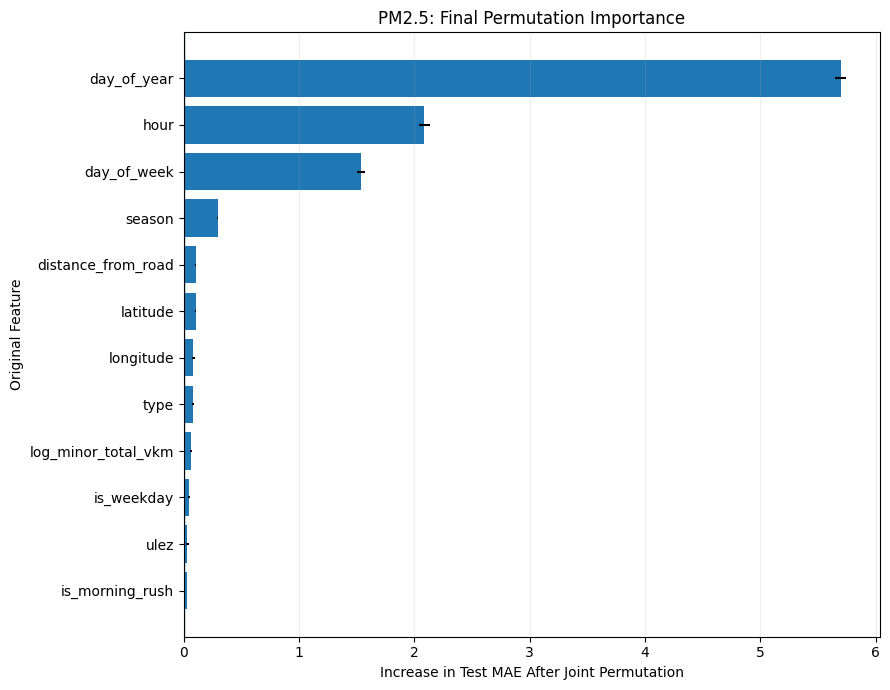

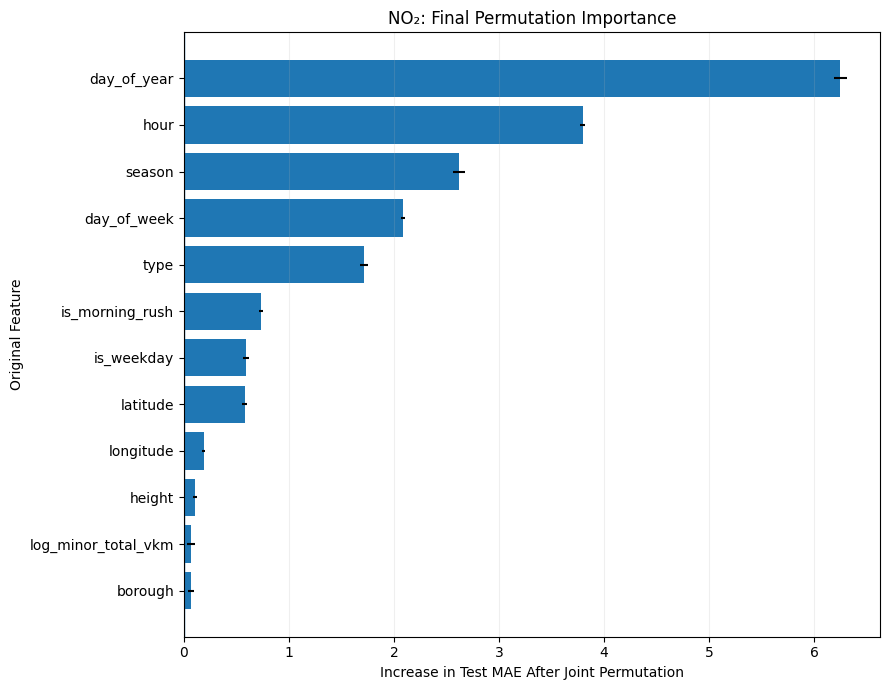

In [101]:
# ==============================================================
# 16.5 Final Permutation Importance Comparison
# ==============================================================

for importance_df, pollutant in [
    (pm25_importance_final, "PM2.5"),
    (no2_importance_final, "NO₂")
]:

    top_features = (
        importance_df
        .sort_values(
            "importance_mean",
            ascending=True
        )
        .tail(12)
    )

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    ax.barh(
        top_features["original_feature"],
        top_features["importance_mean"],
        xerr=top_features["importance_std"]
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_xlabel(
        "Increase in Test MAE After Joint Permutation"
    )

    ax.set_ylabel(
        "Original Feature"
    )

    ax.set_title(
        f"{pollutant}: Final Permutation Importance"
    )

    ax.grid(
        axis="x",
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

Joint permutation importance confirms that temporal structure is the dominant source of predictive information for both PM2.5 and NO₂. Day of year, hour, and day of week produce the largest increases in prediction error when their information is disrupted.

For PM2.5, season, distance from road, latitude, longitude, monitoring-site type, and traffic exposure provide smaller additional predictive contributions. Traffic exposure remains informative to the model, but its contribution is substantially smaller than the temporal variables.

For NO₂, temporal variables again dominate, while season, monitoring-site type, morning rush status, weekday status, and latitude show comparatively stronger contributions than in the PM2.5 model. Traffic exposure and road distance have smaller permutation importance.

The results describe predictive contribution rather than causal influence. A larger permutation importance means that disrupting the information associated with a feature increased model error; it does not establish that the feature causes higher or lower pollutant concentrations.

Small negative permutation importance values indicate that shuffling a feature slightly improved prediction error in this finite test sample. These values should not be interpreted as negative environmental effects.

## 16.6 Chapter 16 Summary

The explainability analysis showed that temporal variables were the dominant predictors of both PM2.5 and NO₂ concentrations. Day of year, hour, and day of week consistently ranked highly across impurity-based and joint permutation importance methods.

For PM2.5, predictions were primarily associated with annual and daily temporal structure, with smaller contributions from season, distance from road, spatial coordinates, monitoring-site type, and traffic exposure. For NO₂, temporal variables also dominated, while season, monitoring-site type, rush-hour status, weekday status, and spatial characteristics showed comparatively stronger contributions.

The agreement between impurity-based and permutation importance for the dominant temporal variables strengthens the interpretation that temporal structure is central to the predictive models. Differences between the two importance methods for some spatial and categorical variables also demonstrate why feature importance should not be interpreted using a single measure.

Traffic-related variables contributed predictive information, but their importance was smaller than the dominant temporal features. These results describe predictive relationships rather than causal effects.

Overall, the explainability analysis provides a transparent interpretation of the tuned Random Forest models and connects the machine learning results back to the research questions concerning traffic exposure, spatial characteristics, and temporal variation in urban air pollution.

# Chapter 17: Research Findings & Interpretation

This chapter integrates the statistical analysis, machine learning evaluation, residual diagnostics, deployment-level performance, and model explainability results.

The purpose is to answer the research questions using the evidence generated throughout the study. Statistical tests are interpreted as evidence of association, while machine learning results are interpreted as evidence of predictive performance.

The study does not establish causal relationships between traffic exposure, road proximity, meteorological or spatial characteristics, and pollutant concentrations.

## 17.2 Research Question Findings

### RQ1. Is traffic intensity associated with NO₂ concentration?

The statistical analysis did not provide sufficient evidence of a statistically significant association between the traffic exposure measure and NO₂ concentration at the selected significance level (p = 0.0950).

The null hypothesis was therefore not rejected.

However, traffic exposure remained a predictive variable in the machine learning models, indicating that predictive contribution and statistical significance in a marginal association test are not equivalent concepts.

### RQ2. Is traffic intensity associated with PM2.5 concentration?

The statistical analysis did not provide sufficient evidence of a statistically significant association between traffic exposure and PM2.5 concentration (p = 0.5424).

The null hypothesis was therefore not rejected.

Traffic exposure nevertheless contributed measurable predictive information in the final PM2.5 model, although its contribution was substantially smaller than the dominant temporal variables.

### RQ3. Is proximity to roads associated with pollutant concentration?

For PM2.5, the analysis did not identify a statistically significant association between road distance and concentration (p = 0.3006).

For NO₂, the analysis identified a statistically significant negative association between road distance and concentration (p = 0.0012). The negative direction indicates that higher road distance was associated with lower NO₂ values in the observed data.

This finding is an observational association and should not be interpreted as evidence of causation.

### RQ4. Do these relationships remain after accounting for temporal, spatial and other characteristics?

The machine learning analysis demonstrates that pollutant concentrations can be predicted using a combination of temporal, spatial, traffic and site characteristics. However, the machine learning models do not provide a causal adjustment framework.

Therefore, the study can demonstrate predictive relationships after jointly incorporating these variables, but it cannot establish that an individual traffic-related factor has an independent causal effect.

### RQ5. Do pollutant concentrations differ across traffic-exposure groups?

The Kruskal-Wallis tests did not identify statistically significant differences across the traffic-exposure groups for either PM2.5 (p = 0.1981) or NO₂ (p = 0.6792).

The null hypothesis was therefore not rejected for either pollutant.

### RQ6. Can traffic, spatial, temporal and site characteristics predict NO₂?

Yes, the models demonstrated meaningful predictive performance on unseen deployments.

The tuned Random Forest achieved:

- MAE: 10.43 µg/m³
- RMSE: 15.42 µg/m³
- R²: 0.542

The model therefore captured substantial variation in unseen NO₂ observations, although the residual analysis showed increasing error at higher concentrations and substantial variation between deployments.

### RQ7. Can the same types of variables predict PM2.5?

Yes.

The tuned Random Forest achieved:

- MAE: 3.10 µg/m³
- RMSE: 6.89 µg/m³
- R²: 0.622

The model captured a substantial proportion of the variation in unseen PM2.5 observations. However, prediction errors increased at higher concentrations, particularly for extreme observations.

### RQ8. Which variables contribute most to prediction?

Temporal characteristics were consistently the dominant predictive information for both pollutants.

Permutation importance identified `day_of_year`, `hour`, and `day_of_week` as the strongest contributors for PM2.5. For NO₂, `day_of_year`, `hour`, `season`, and `day_of_week` were dominant, with site type also contributing substantially.

Traffic exposure and road distance contributed measurable predictive information but were not the dominant predictors in the final models.

These results describe model behavior rather than causal importance.

## 17.3 Statistical Findings Summary

The hypothesis tests produced one statistically significant association among the tested relationships.

Traffic exposure was not significantly associated with PM2.5 or NO₂ concentration in the tested data. Road distance was not significantly associated with PM2.5, but it showed a statistically significant negative association with NO₂.

The traffic-exposure group comparisons did not identify statistically significant differences for either pollutant.

Overall, the statistical analysis provides limited evidence for simple marginal relationships between the traffic exposure measures and pollutant concentrations. The machine learning analysis provides a different perspective by evaluating whether combinations of temporal, spatial, traffic and site variables can predict pollutant concentrations.

## 17.4 Machine Learning Findings

The machine learning results show a substantial improvement over the linear regression baselines.

For PM2.5, the linear regression model achieved an R² of 0.076, compared with 0.622 for the tuned Random Forest. For NO₂, linear regression achieved an R² of 0.123, compared with 0.542 for the tuned Random Forest.

This indicates that the predictive relationships captured by the feature set are not adequately represented by a simple linear model.

However, model comparison also showed that no single model dominated across every evaluation metric. For PM2.5, XGBoost produced the highest R² and lowest RMSE among the tested baseline and tuned models, while the tuned Random Forest produced the lowest MAE. For NO₂, the untuned Random Forest produced stronger test-set metrics than the tuned Random Forest on the evaluated metrics.

The tuning procedure optimized mean absolute error through group-aware cross-validation. Therefore, improvement in the tuning objective does not necessarily guarantee improvement across every test-set metric.

## 17.5 Evidence Summary

The following table consolidates the principal statistical and predictive findings for the two pollutants. It separates statistical evidence from machine learning performance so that association and prediction are not treated as the same type of evidence.

In [79]:
# ==============================================================
# 17.5 EVIDENCE SUMMARY
# ==============================================================

evidence_summary = pd.DataFrame([
    {
        "Pollutant": "PM2.5",
        "Traffic exposure association": "Not statistically significant",
        "Traffic exposure p-value": 0.542379,
        "Road distance association": "Not statistically significant",
        "Road distance p-value": 0.300584,
        "Traffic group difference": "Not statistically significant",
        "Group test p-value": 0.198054,
        "Tuned RF MAE": 3.1004,
        "Tuned RF RMSE": 6.8859,
        "Tuned RF R2": 0.6218,
        "Dominant predictive structure": "Temporal"
    },
    {
        "Pollutant": "NO₂",
        "Traffic exposure association": "Not statistically significant",
        "Traffic exposure p-value": 0.095036,
        "Road distance association": "Statistically significant negative association",
        "Road distance p-value": 0.001163,
        "Traffic group difference": "Not statistically significant",
        "Group test p-value": 0.679205,
        "Tuned RF MAE": 10.4257,
        "Tuned RF RMSE": 15.4236,
        "Tuned RF R2": 0.5415,
        "Dominant predictive structure": "Temporal + site/spatial"
    }
])

display(evidence_summary)

,Pollutant,Traffic exposure association,Traffic exposure p-value,Road distance association,Road distance p-value,Traffic group difference,Group test p-value,Tuned RF MAE,Tuned RF RMSE,Tuned RF R2,Dominant predictive structure
0,PM2.5,Not statistically significant,0.542379,Not statistically significant,0.300584,Not statistically significant,0.198054,3.1004,6.8859,0.6218,Temporal
1,NO₂,Not statistically significant,0.095036,Statistically significant negative association,0.001163,Not statistically significant,0.679205,10.4257,15.4236,0.5415,Temporal + site/spatial


### Interpretation

The evidence summary shows that neither pollutant had a statistically significant marginal association with the traffic exposure measure used in this study.

Road distance showed a statistically significant negative association with NO₂, while the corresponding PM2.5 association was not statistically significant.

The machine learning models nevertheless achieved meaningful predictive performance for both pollutants. The tuned Random Forest explained approximately 62.2% of the held-out PM2.5 variation and 54.2% of the held-out NO₂ variation.

The explainability analysis indicates that temporal variables provide the dominant predictive information for both pollutants. NO₂ additionally showed stronger contributions from site type and other spatial or temporal characteristics.

These findings demonstrate that statistical association and predictive contribution are not interchangeable. A variable may contribute to prediction without showing a statistically significant marginal association, particularly when the model combines multiple interacting or correlated sources of information.

## 17.6 Key Findings

Five findings emerge consistently from the analysis:

1. **Temporal structure dominates prediction.**
   Annual timing, hour of day, and day of week were the strongest contributors to predictive performance for both PM2.5 and NO₂.

2. **Traffic exposure was not statistically significant in the tested marginal associations.**
   The traffic exposure measure did not show statistically significant associations with either pollutant.

3. **Road proximity showed a pollutant-specific pattern.**
   Road distance was not statistically significant for PM2.5 but showed a statistically significant negative association with NO₂.

4. **Nonlinear models substantially outperformed the linear baseline.**
   Tree-based models captured relationships that were not adequately represented by the linear regression models.

5. **Prediction errors were concentrated at higher pollution levels and varied across deployments.**
   Both pollutants showed increasing errors at higher observed concentrations, while NO₂ displayed greater heterogeneity in performance across unseen deployments.

Together, these findings indicate that pollutant prediction in this dataset depends on a combination of temporal, spatial, site and traffic-related information, with temporal structure providing the strongest predictive signal.

## 17.7 Research Limitations

Several limitations should be considered when interpreting the findings.

### 1. Temporal mismatch between traffic and air-quality data

The air-quality observations cover 2018–2019, while the LAEI traffic data represent 2022 conditions. Therefore, the traffic variables should be interpreted as spatial exposure proxies rather than measurements of traffic conditions occurring at the exact time of each air-quality observation.

This temporal mismatch limits the extent to which the traffic variables can be interpreted as contemporaneous exposure measurements.

### 2. Observational study design

The study uses observational data. Associations identified through statistical testing and predictive relationships identified through machine learning cannot establish causality.

In particular, the significant negative association between road distance and NO₂ should not be interpreted as proof that increasing distance from a road directly causes lower NO₂ concentrations.

### 3. Uneven monitoring coverage

The monitoring network contains different numbers of observations across deployments, and some locations have substantially different observation coverage. Some monitoring locations were also associated with multiple deployment records.

Group-aware splitting reduced the risk of the same deployment appearing in both training and test sets, but differences in monitoring coverage remain a limitation.

### 4. Missing data

PM2.5 and NO₂ have different levels of missingness, and distance from road is missing for a subset of observations. The study retained these observations where possible rather than applying blanket deletion.

Missingness may nevertheless introduce uncertainty into the analysis and model estimates.

### 5. Extreme pollutant observations

Both pollutants contain substantial right-skew and extreme observations. The models reproduced the general concentration patterns but showed greater errors at higher pollution levels and compressed the predicted extremes.

Consequently, overall metrics should not be interpreted as evidence that the models perform equally well across the entire concentration range.

### 6. Traffic representation

The traffic exposure measure is derived from the nearest LAEI minor-road grid rather than a direct measurement of traffic at each monitoring observation. It therefore represents a spatial proxy for traffic intensity.

Major-road and minor-road datasets also have different spatial structures and traffic measures, which limits direct combination without introducing additional assumptions.

### 7. Feature importance limitations

Feature importance measures describe model behavior rather than causal influence. Correlated predictors can share or substitute for predictive information, while impurity-based importance can be affected by feature characteristics and encoding.

Permutation importance provides a complementary assessment but is also dependent on the model, test sample, and relationships among predictors.

### 8. Generalizability

The models were evaluated on unseen monitoring deployments within this dataset and study period. Therefore, their performance should not automatically be assumed to generalize to other cities, monitoring networks, years, or substantially different environmental conditions.

These limitations do not invalidate the analysis, but they define the scope within which the findings should be interpreted.

## 17.8 Implications of the Findings

The findings suggest that predicting urban PM2.5 and NO₂ concentrations requires more than a single traffic-related exposure measure.

Temporal characteristics provided the strongest predictive information in both models, while spatial location, monitoring-site characteristics, road proximity and traffic exposure provided additional information.

The results also demonstrate the value of separating statistical association from predictive modelling. The traffic exposure measure did not show statistically significant marginal associations with either pollutant, yet traffic-related and spatial variables still contributed measurable information to the machine learning models.

For future studies, contemporaneous traffic measurements, meteorological observations, road-network characteristics and additional spatial variables could provide a stronger basis for estimating short-term pollutant exposure.

The findings therefore support a multi-dimensional approach to urban air-quality modelling rather than relying on traffic intensity alone.

## 17.9 Research Conclusion

This study investigated whether traffic-related, spatial, temporal and site characteristics could explain and predict urban PM2.5 and NO₂ concentrations in London.

The statistical analysis found no statistically significant marginal association between the selected traffic exposure measure and either pollutant. Road distance was not significantly associated with PM2.5 but showed a statistically significant negative association with NO₂.

Machine learning models captured substantially more predictive structure than the linear baselines. The tuned Random Forest achieved an R² of 0.622 for PM2.5 and 0.542 for NO₂ on unseen monitoring deployments.

Model explainability showed that temporal characteristics, particularly annual timing and time of day, provided the dominant predictive information. Spatial, site and traffic-related variables contributed additional predictive information, with their relative importance differing between PM2.5 and NO₂.

The results demonstrate that urban pollutant concentrations in this dataset can be modelled using integrated temporal, spatial, site and traffic information. However, the temporal mismatch between the 2018–2019 air-quality observations and 2022 traffic data, the observational study design, missing data, monitoring heterogeneity and difficulty predicting extreme concentrations limit causal interpretation and broader generalization.

Overall, the study demonstrates a complete environmental data-science workflow from multi-source data integration and quality assessment through statistical inference, feature engineering, group-aware machine learning, model evaluation and explainability.

## 17.10 Chapter Summary

The research findings can be summarized as follows:

- Traffic exposure did not show statistically significant marginal associations with PM2.5 or NO₂.
- Road distance showed a statistically significant negative association with NO₂ but not PM2.5.
- Traffic-exposure groups did not show statistically significant differences in either pollutant.
- Nonlinear machine learning models substantially outperformed the linear baselines.
- The tuned Random Forest achieved R² values of 0.622 for PM2.5 and 0.542 for NO₂ on unseen deployments.
- Temporal variables were the dominant predictive features.
- Spatial, site and traffic-related variables provided additional predictive information.
- Prediction errors increased at higher pollutant concentrations.
- Performance varied across unseen monitoring deployments, particularly for NO₂.
- The results support predictive modelling but do not establish causal effects.

The next chapter will translate these findings into practical recommendations, future research directions, and the final study conclusion.

# Chapter 18: Recommendations, Future Research & Final Conclusion

This chapter translates the research findings into practical recommendations, identifies opportunities for improving the analysis, and presents the final conclusion of the study.

The recommendations are based on the observed limitations, statistical results, predictive performance, and model explainability findings.

## 18.1 Study Limitations

Several limitations should be considered when interpreting the findings of this study.

First, the traffic data represent the 2022 LAEI traffic inventory, whereas the air-quality observations cover 2018–2019. Traffic variables therefore function primarily as spatial exposure proxies rather than measurements of traffic conditions at the exact time of each air-quality observation.

Second, the study uses an observational design. The statistical analyses identify associations, while the machine learning models identify predictive relationships. Neither provides evidence of causal effects.

Third, monitoring coverage was uneven across deployments, with differences in observation counts, missing pollutant measurements, and deployment periods. This may affect the representativeness of some locations and time periods.

Fourth, PM2.5 and NO₂ contained substantial missing observations. Missing values were handled through the documented preprocessing pipeline rather than blanket deletion, but missingness may still influence model performance.

Fifth, pollutant concentrations contained substantial right-skew and extreme observations. The models showed greater prediction errors at higher concentration levels, indicating difficulty reproducing some extreme pollution events.

Sixth, traffic exposure was represented using spatial matching to LAEI traffic data. Major and minor road datasets also have different spatial structures, limiting the extent to which the available traffic variables can represent the complete road environment around each monitoring site.

Finally, model explainability methods describe predictive contribution rather than causal importance. Feature importance can also be affected by correlated predictors and characteristics of the fitted model.

## 18.2 Recommendations for Future Research

Future studies could strengthen the analysis by incorporating traffic measurements that are temporally aligned with the air-quality observations.

More detailed spatial exposure measures could also be developed, including distance to multiple road classes, road density, traffic volume within defined buffers, road-network characteristics, and directional relationships between monitoring sites and nearby roads.

Meteorological variables should be incorporated where available, particularly wind speed, wind direction, temperature, humidity, precipitation, and atmospheric stability. These variables could help distinguish temporal and meteorological influences from spatial traffic-related patterns.

Future modelling should also consider approaches specifically designed to improve prediction of high-concentration events, since the current models showed increased errors at the upper end of the observed pollutant distributions.

External validation using data from different years, monitoring networks, or cities would provide a stronger assessment of model generalizability.

Finally, future research could investigate missingness mechanisms and deployment-specific differences more explicitly, particularly where monitoring locations have substantially different observation coverage.

## 18.3 Conclusion

This study developed an integrated environmental data science framework for investigating traffic-related air pollution exposure in London. Air-quality observations were combined with spatial characteristics, traffic exposure variables, and temporal information to examine relationships with PM2.5 and NO₂ concentrations.

The statistical analysis found no statistically significant association between the selected traffic exposure measure and either pollutant. Road distance showed a statistically significant association with NO₂, while the corresponding PM2.5 relationship was not statistically significant. Traffic-exposure group comparisons also did not show statistically significant differences for either pollutant.

Machine learning models demonstrated substantially stronger predictive performance than the linear baseline. The final tuned Random Forest achieved an R² of 0.6218 for PM2.5 and 0.5415 for NO₂ on previously unseen monitoring deployments. However, model diagnostics showed that prediction errors increased at higher pollution levels and that performance varied across deployments.

The explainability analysis identified temporal variables, particularly day of year, hour, and day of week, as the dominant sources of predictive information. Traffic exposure and road-distance variables contributed additional predictive information but were smaller than the dominant temporal features.

Overall, the findings demonstrate the value of integrating environmental, spatial, traffic, and temporal data within a reproducible data science workflow. At the same time, the results highlight the importance of distinguishing predictive relationships from causal effects and of accounting for temporal mismatch, monitoring coverage, missing data, and spatial representation when interpreting traffic-related air pollution models.

## 18.4 Chapter Summary

- Traffic exposure was not statistically significantly associated with PM2.5 or NO₂ in the tested marginal relationships.
- Road distance showed a statistically significant association with NO₂ but not PM2.5.
- Traffic-exposure groups did not show statistically significant pollutant differences.
- Nonlinear machine learning models substantially outperformed the linear baseline.
- The tuned Random Forest achieved R² = 0.6218 for PM2.5 and R² = 0.5415 for NO₂.
- Prediction errors increased at higher pollution concentrations.
- Model performance varied across unseen monitoring deployments.
- Temporal variables were the dominant predictive features.
- Traffic and spatial variables contributed additional predictive information but were not dominant.
- The traffic data's 2022 temporal mismatch with the 2018–2019 air-quality observations is an important limitation.
- The findings represent associations and predictive relationships, not causal effects.